In [9]:
!copy %cd%\..\Ebay\Server\Controllers\Contracts\Ebay.yaml %cd%
!rmdir %cd%\openapi_client\ /s /q
!docker run --rm -v %cd%:/local openapitools/openapi-generator-cli:v7.3.0 generate -i /local/Ebay.yaml -g python-pydantic-v1 -o /local/client --additional-properties=generateSourceCodeOnly=true
!move %cd%/client/openapi_client %cd%/openapi_client
!rmdir %cd%\client\ /s /q

        1 file(s) copied.
[main] INFO  o.o.codegen.DefaultGenerator - Generating with dryRun=false
[main] INFO  o.o.codegen.DefaultGenerator - OpenAPI Generator: python-pydantic-v1 (client)
[main] INFO  o.o.codegen.DefaultGenerator - Generator 'python-pydantic-v1' is considered stable.
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may not be properly formatted. To define it, try 'export PYTHON_POST_PROCESS_FILE="/usr/local/bin/yapf -i"' (Linux/Mac)
[main] INFO  o.o.c.l.AbstractPythonPydanticV1Codegen - NOTE: To enable file post-processing, 'enablePostProcessFile' must be set to `true` (--enable-post-process-file for CLI).
[main] INFO  o.o.c.l.PythonPydanticV1ClientCodegen - Environment variable PYTHON_POST_PROCESS_FILE not defined so the Python code may not be properly formatted. To define it, try 'export PYTHON_POST_PROCESS_FILE="/usr/local/bin/yapf -i"' (Linux/Mac)
[main] INFO  o.o.c.l.PythonPydanti

In [1]:
from openapi_client import LotInfoShort, ProductWithId
from openapi_client import ApiClient, Configuration
from openapi_client.api import DefaultApi
import requests
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from datetime import datetime
from termcolor import colored
from IPython.display import display
import seaborn as sns

In [2]:
server = "naks42.ru"
port = 17443
clientId = "Ebay.Python"
secret = "ac4ab670-ae20-451a-ab4a-3a20275e807d"

In [3]:
unknown_price_discount = 0.8

In [4]:
def extract_check_state(x:str):
    if 'NotTested' in x:
        return 'not tested'
    if 'AndTested' in x:
        return 'tested'
    if 'AndMatched' in x:
        return 'matched'
    raise Exception ("unable to map " + x)

In [8]:
def extract_state(x:str):
    if 'new' in x:
        return 'new'
    if 'used' in x:
        return 'used'
    if 'dismantled' in x:
        return 'used'
    raise Exception ("unable to map " + x)

################################################## 12Z1L POLAM ##################################################
Продано штук:  20 

Распределение по состоянию (проданных штук): 
newAndTested    20 

Гистограмма цены для всех категорий:


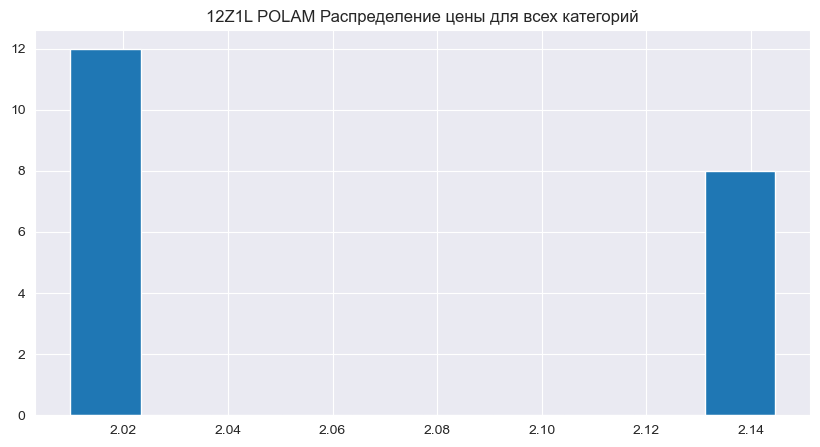

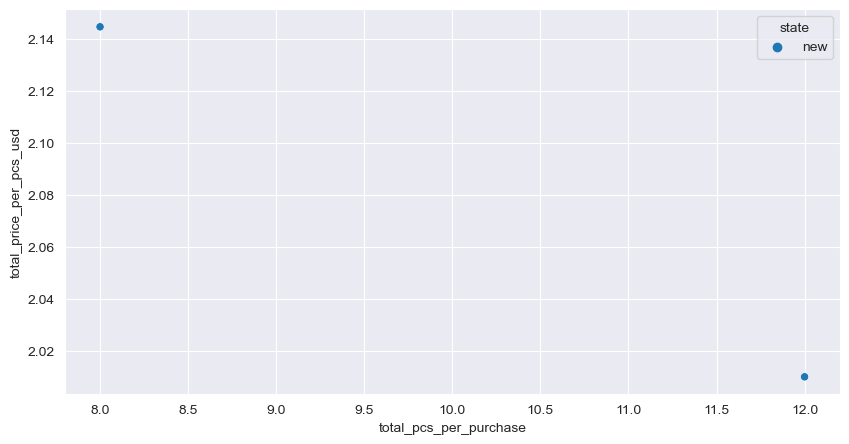

new


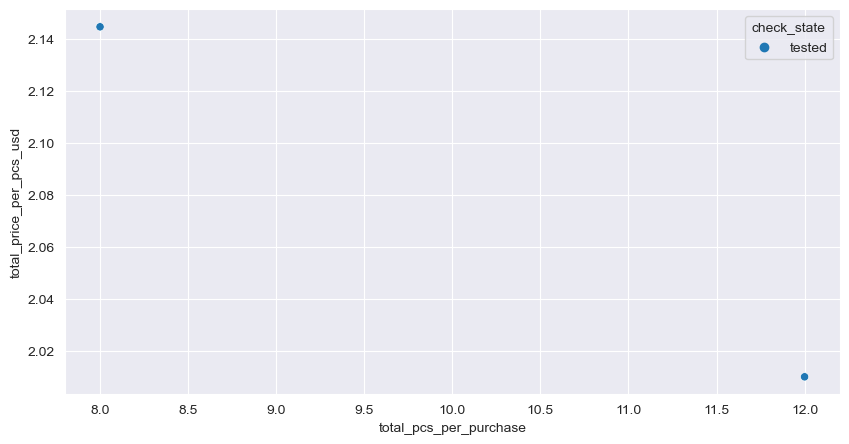

used


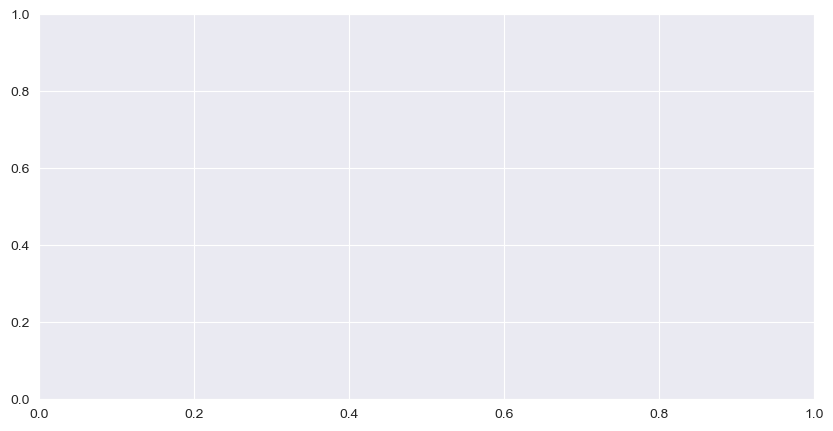


################################################## 12Ж1Л ##################################################
Продано штук:  44 

Распределение по состоянию (проданных штук): 
newAndMatched     4
newNotTested     40 

Гистограмма цены для всех категорий:


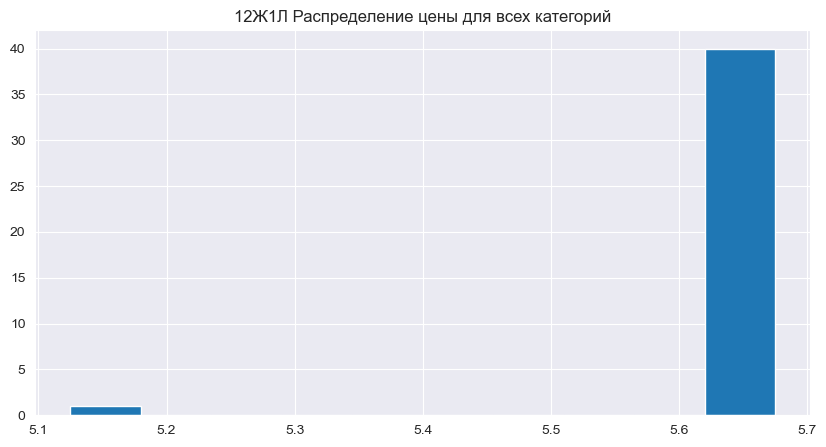

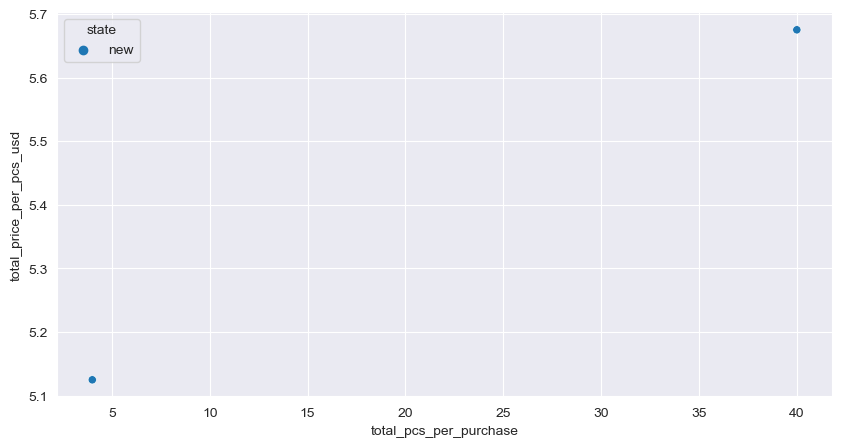

new


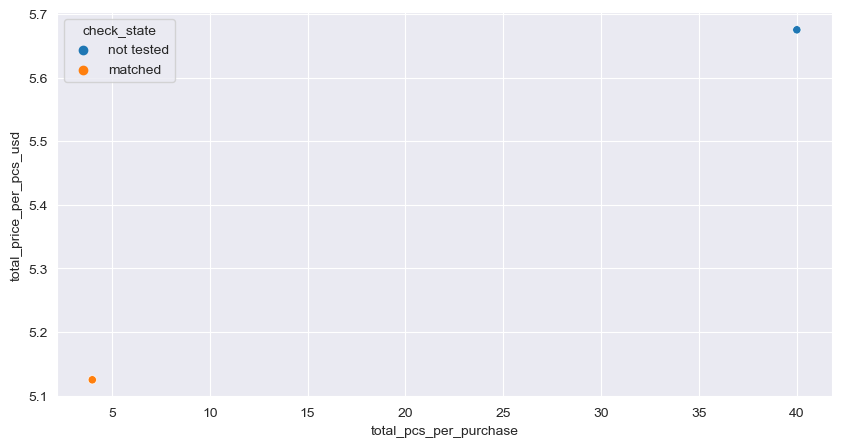

used


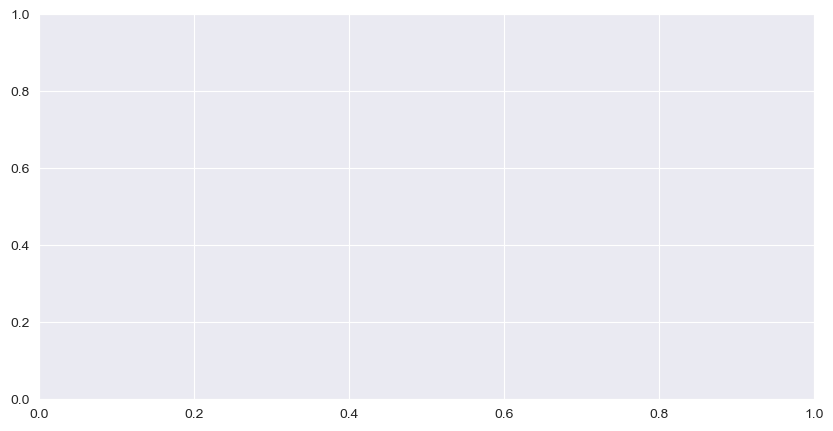


################################################## 12П17Л ##################################################
Нет продаж для лота 

################################################## 1Б10-17 ##################################################
Нет продаж для лота 

################################################## 220ПФ ##################################################
Нет продаж для лота 

################################################## 2Ж27Л ##################################################
Продано штук:  59 

Распределение по состоянию (проданных штук): 
dismantledAndMatched    10
newAndTested            11
newNotTested            38 

Гистограмма цены для всех категорий:


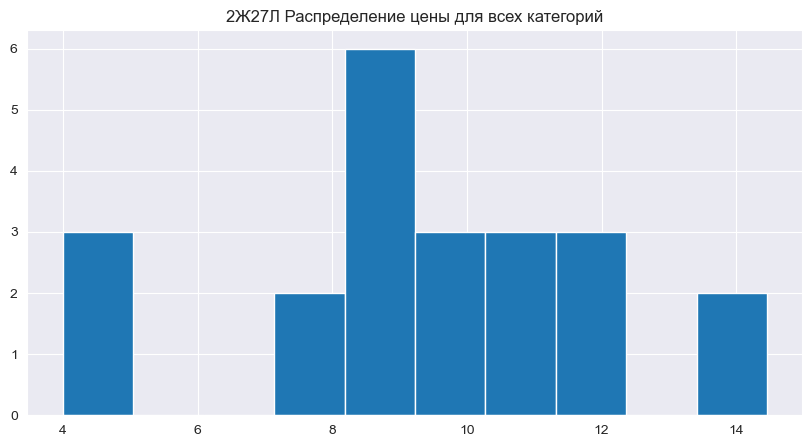

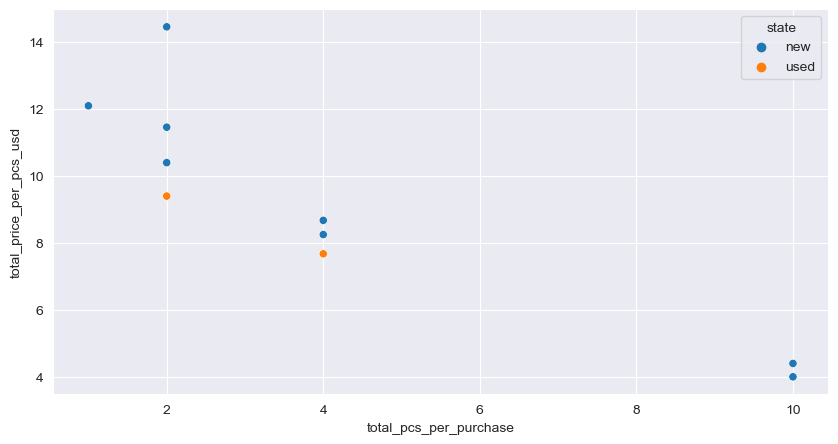

new


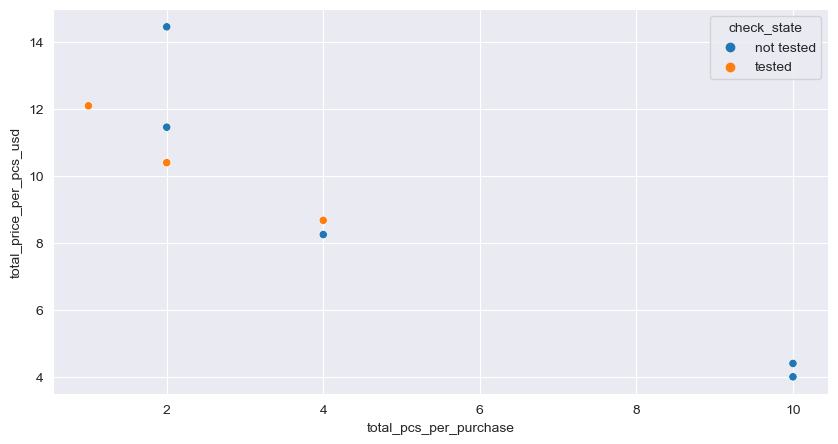

used


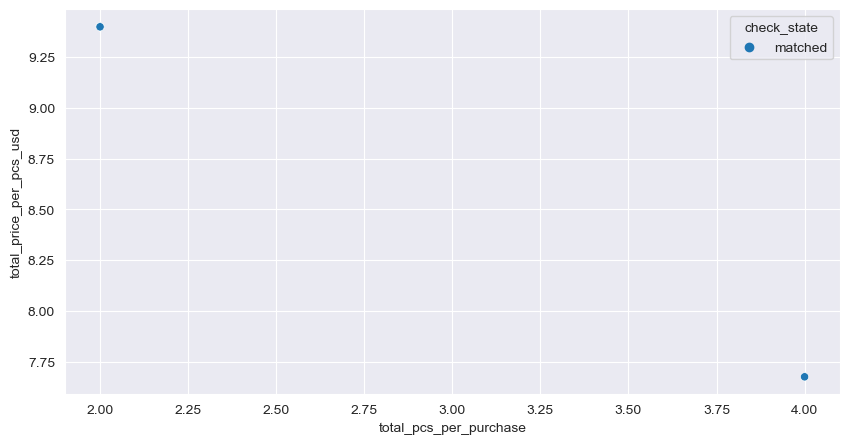


################################################## 6CC31 TESLA ##################################################
Продано штук:  3 

Распределение по состоянию (проданных штук): 
newAndTested    2
newNotTested    1 

Гистограмма цены для всех категорий:


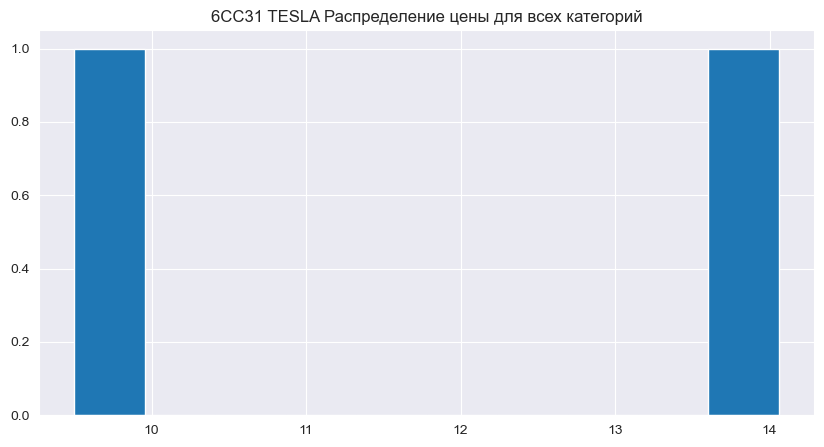

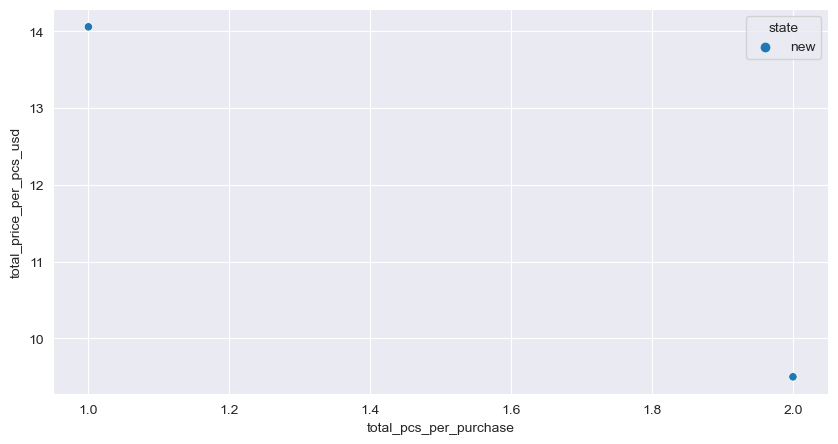

new


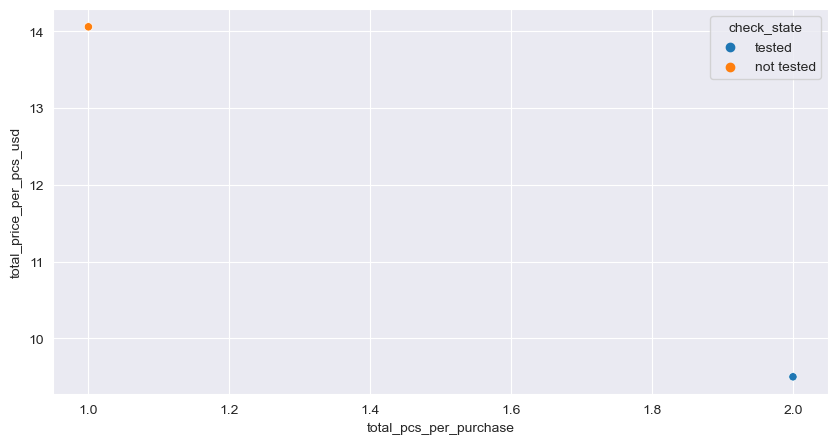

used


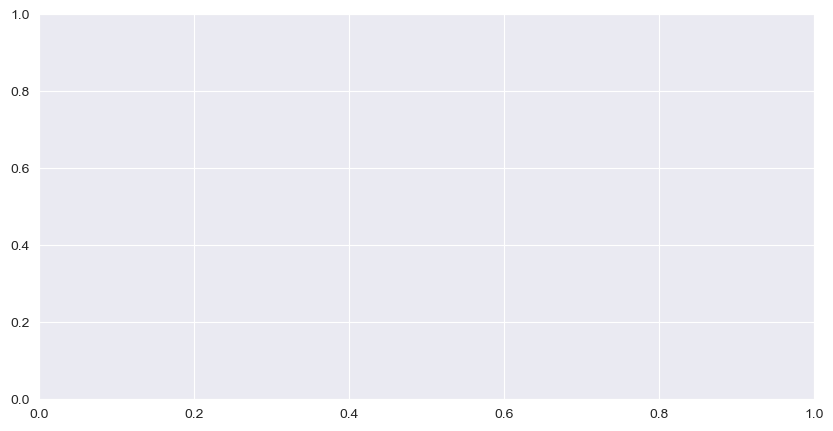


################################################## 6Е1П ##################################################
Продано штук:  186 

Распределение по состоянию (проданных штук): 
newAndTested       4
newNotTested     148
usedAndTested     34 

Гистограмма цены для всех категорий:


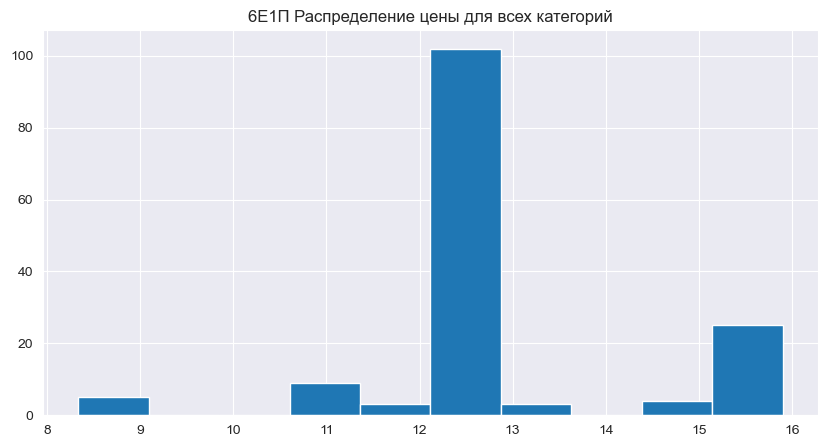

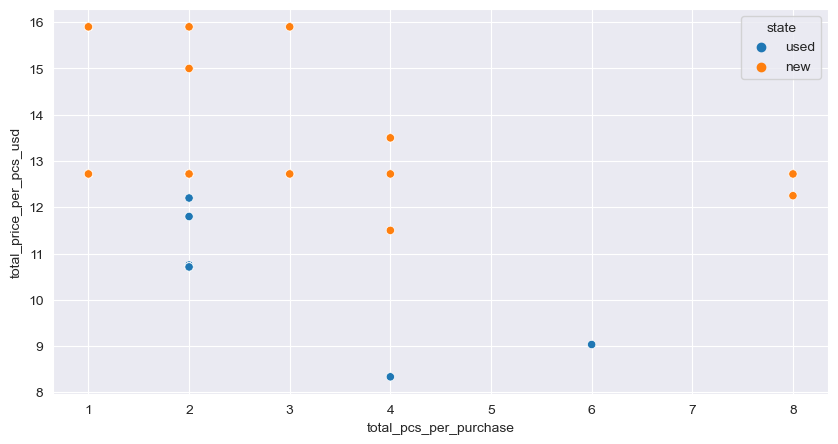

new


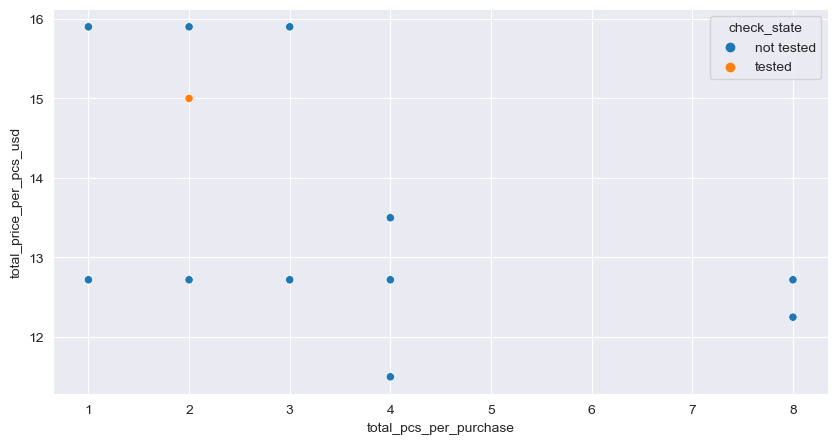

used


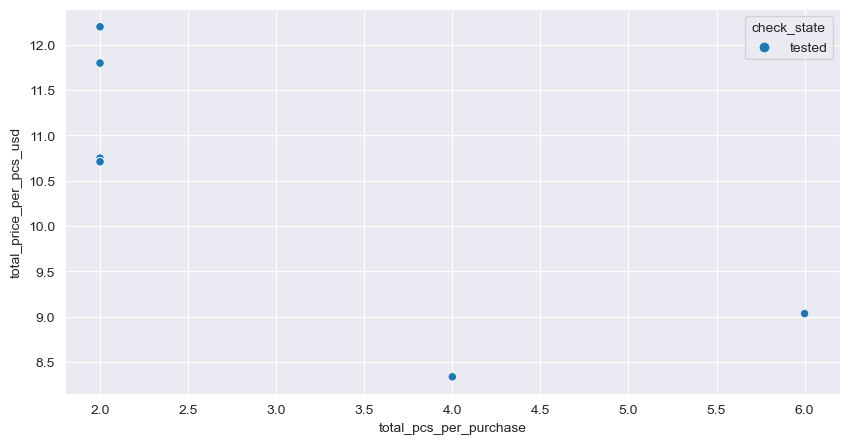


################################################## 6Е3П ##################################################
Продано штук:  39 

Распределение по состоянию (проданных штук): 
newAndTested        18
newNotTested         4
usedAndNotTested     1
usedAndTested       16 

Гистограмма цены для всех категорий:


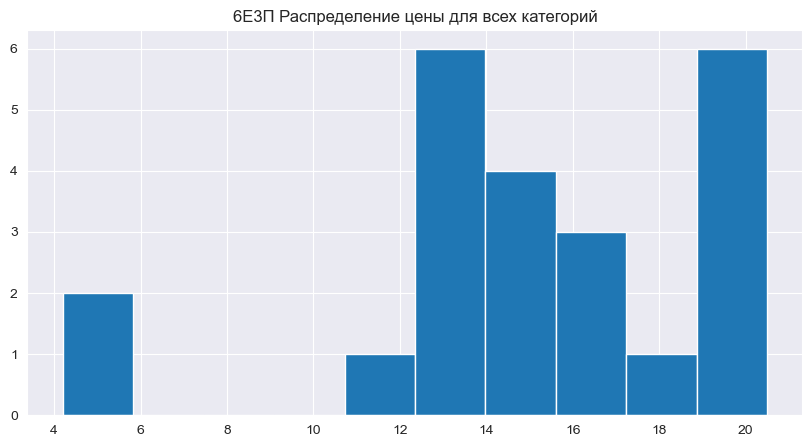

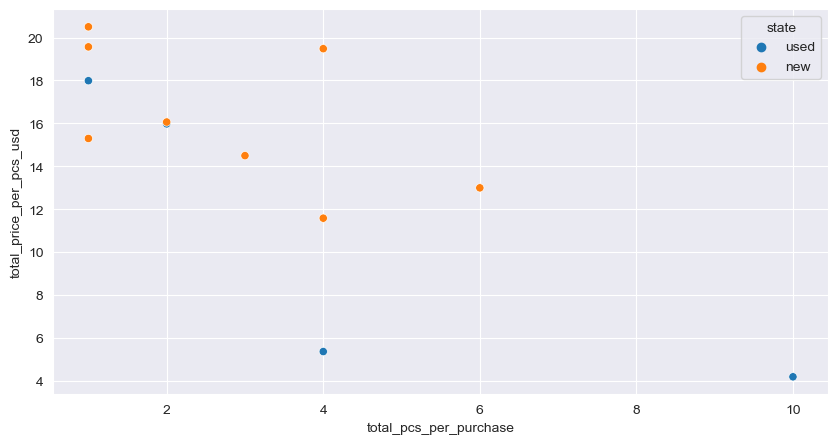

new


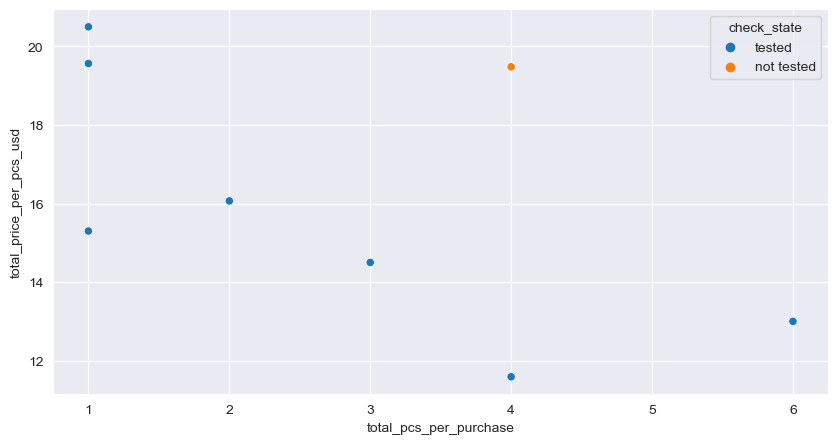

used


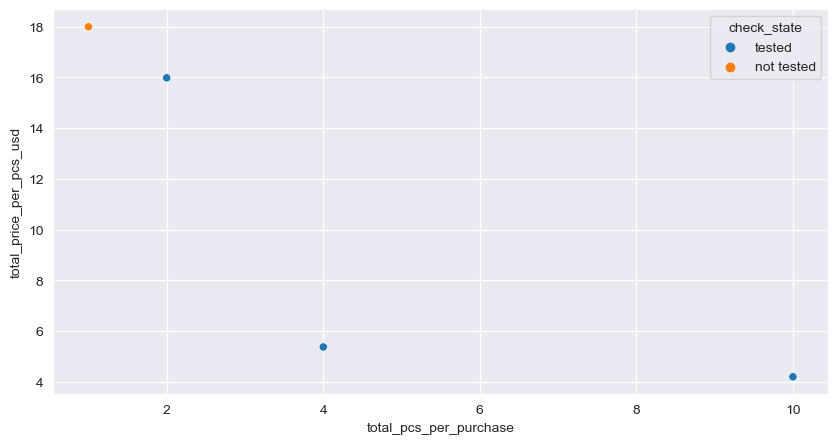


################################################## 6И1П ##################################################
Продано штук:  105 

Распределение по состоянию (проданных штук): 
newAndTested    40
newNotTested    65 

Гистограмма цены для всех категорий:


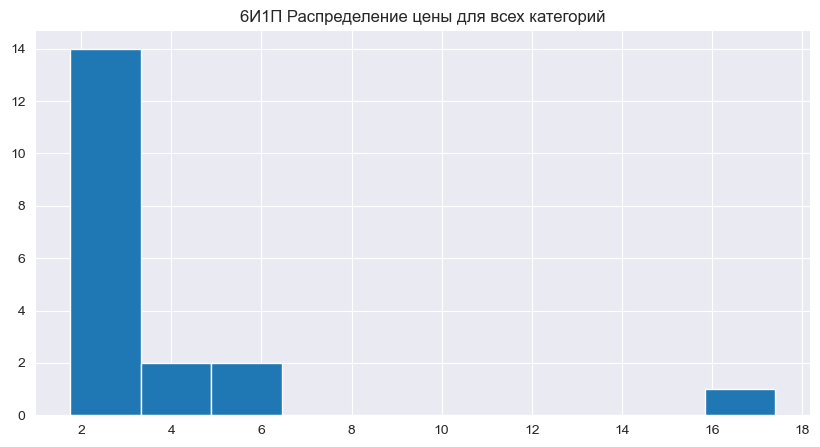

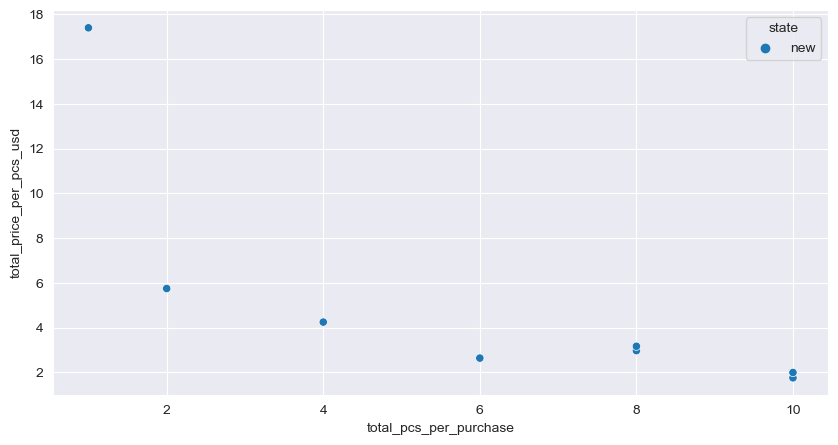

new


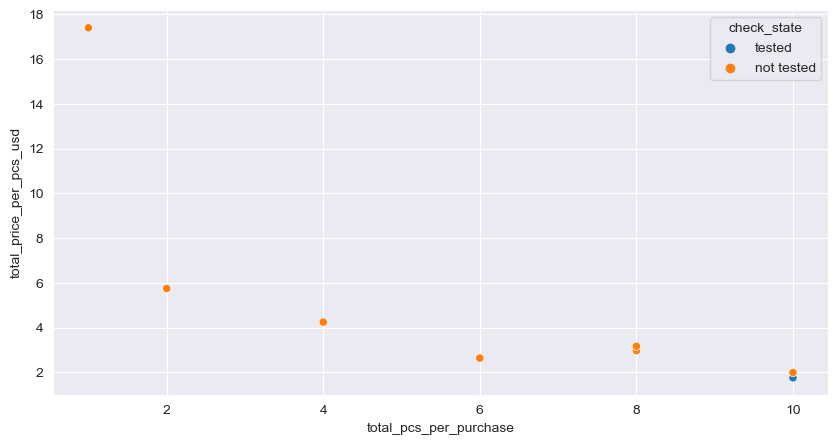

used


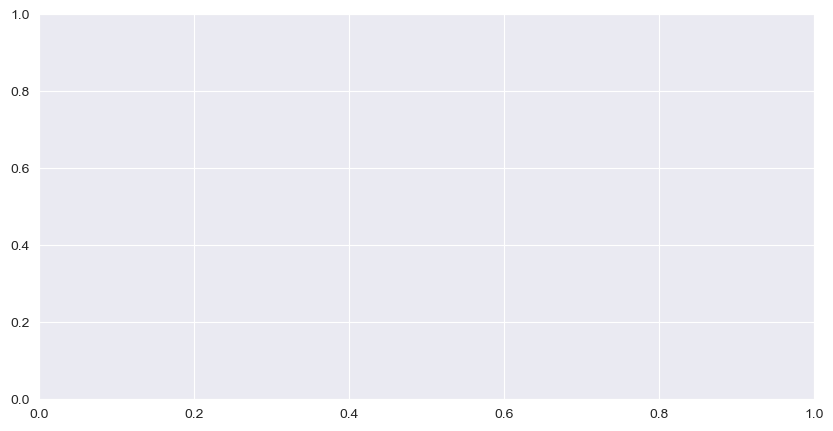


################################################## 6И1П-ЕВ ##################################################
Продано штук:  33 

Распределение по состоянию (проданных штук): 
newAndMatched    18
newNotTested     15 

Гистограмма цены для всех категорий:


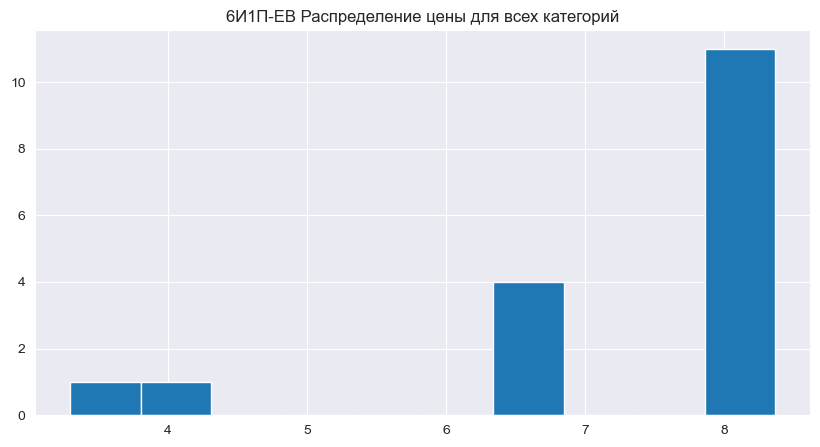

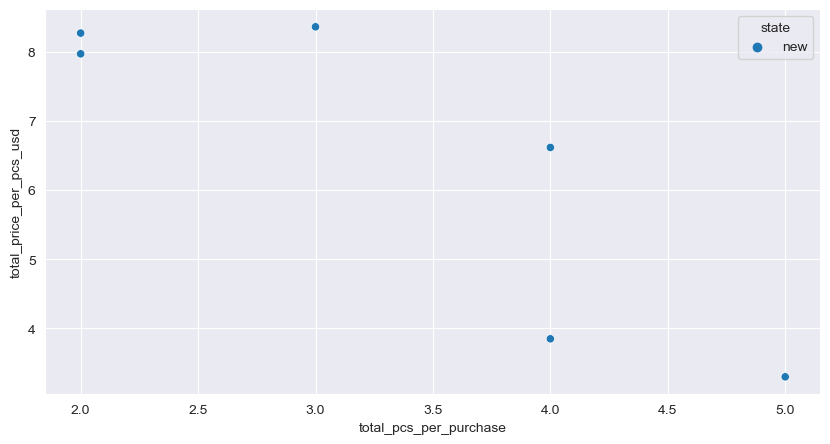

new


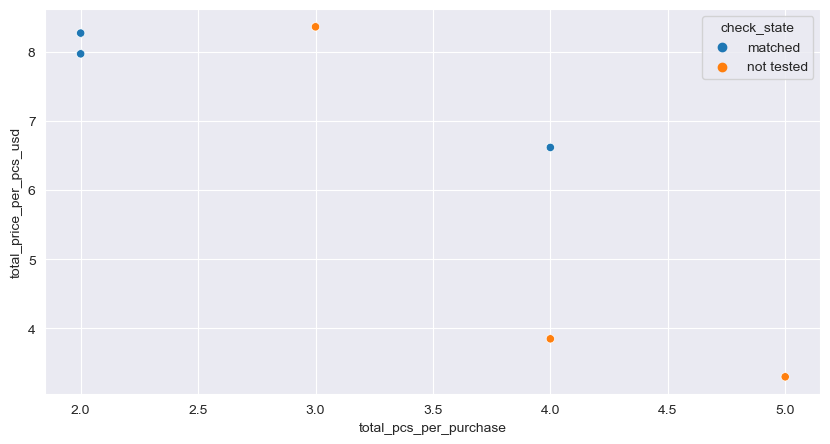

used


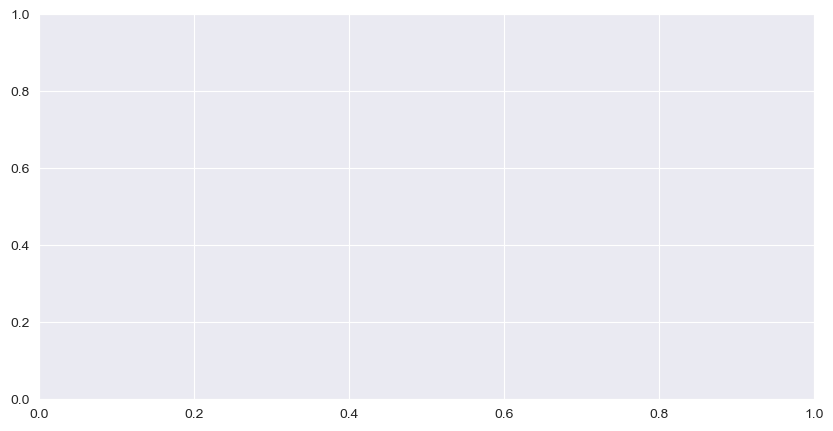


################################################## 6Н15П ##################################################
Продано штук:  48 

Распределение по состоянию (проданных штук): 
newNotTested    48 

Гистограмма цены для всех категорий:


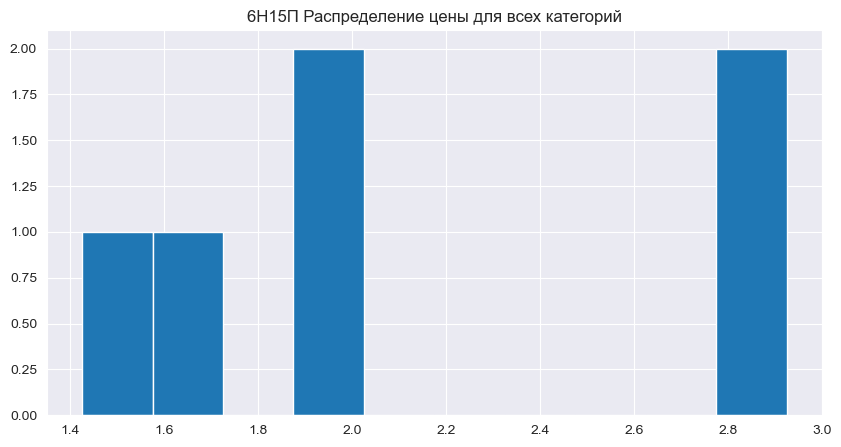

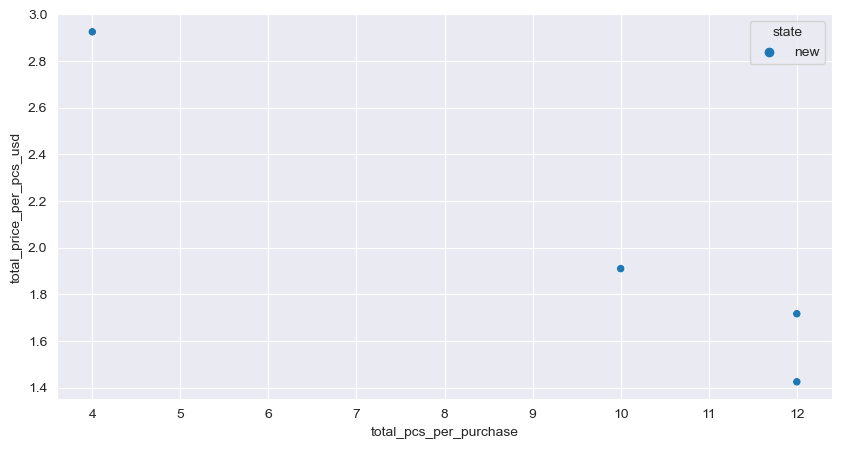

new


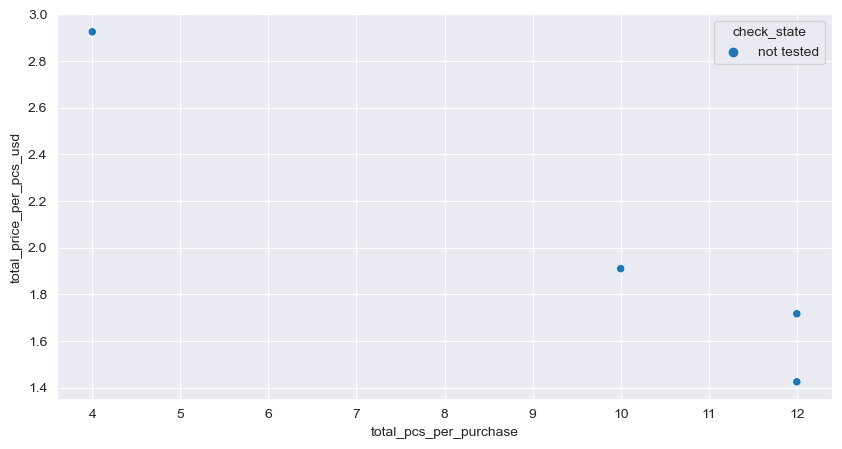

used


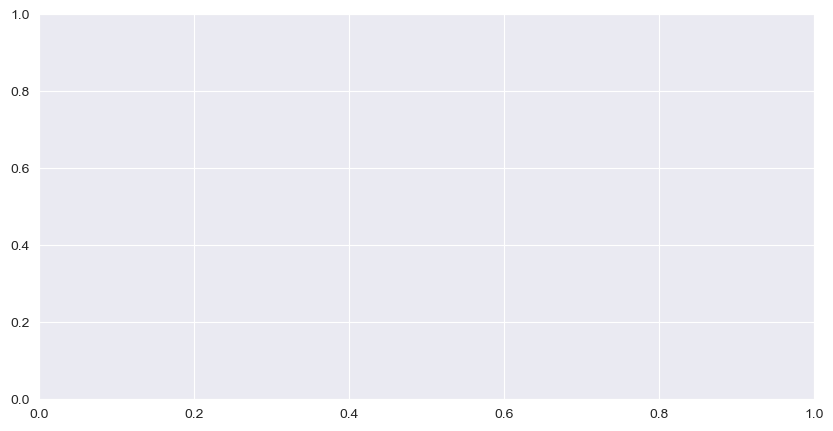


################################################## 6Н16Б-В ##################################################
Продано штук:  120 

Распределение по состоянию (проданных штук): 
newNotTested    120 

Гистограмма цены для всех категорий:


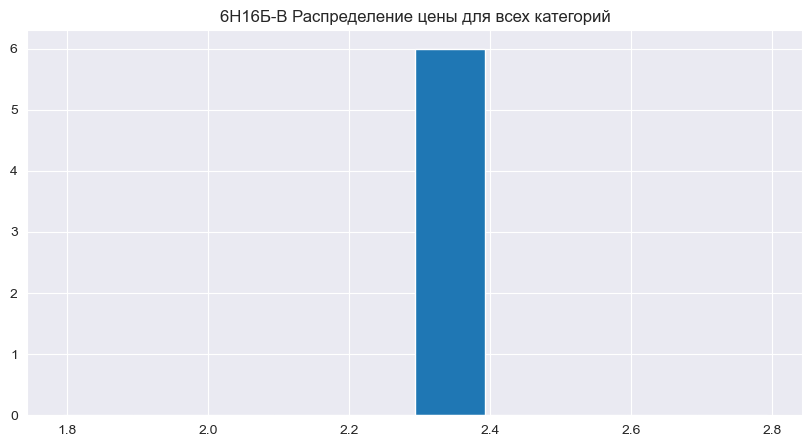

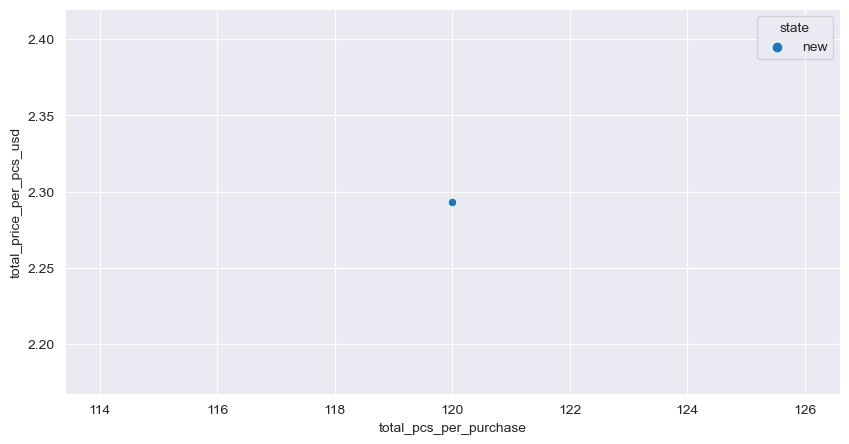

new


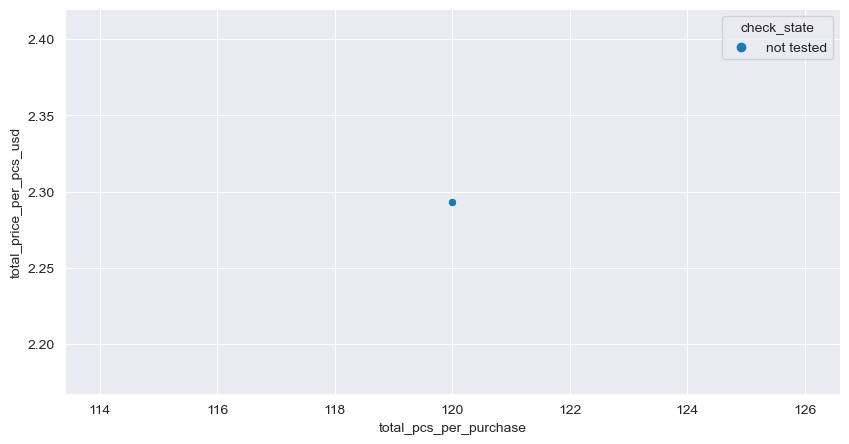

used


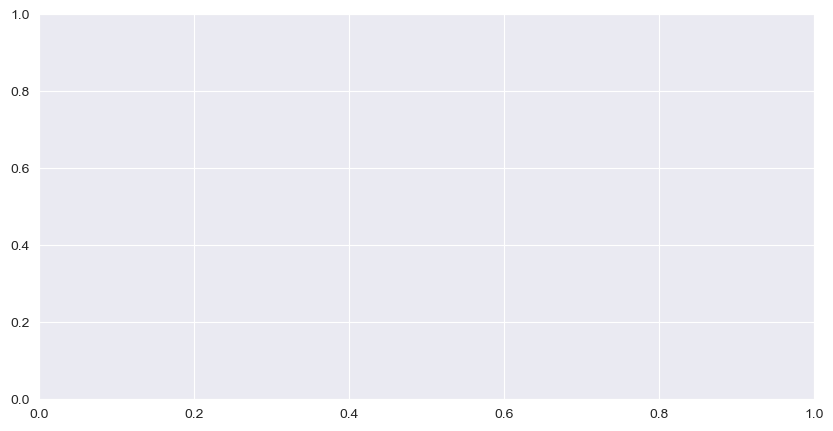


################################################## 6Н18Б-В ##################################################
Продано штук:  5 

Распределение по состоянию (проданных штук): 
newNotTested    5 

Гистограмма цены для всех категорий:


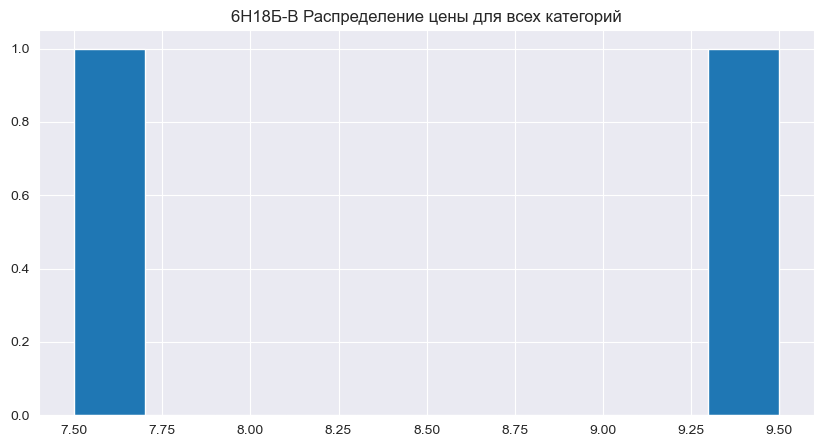

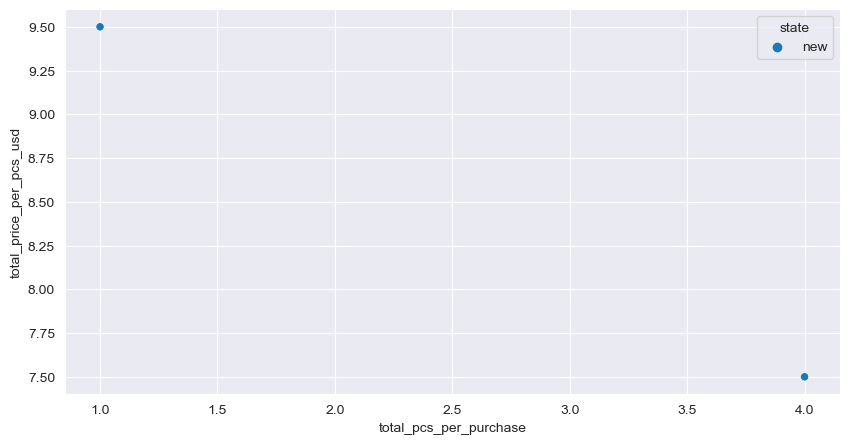

new


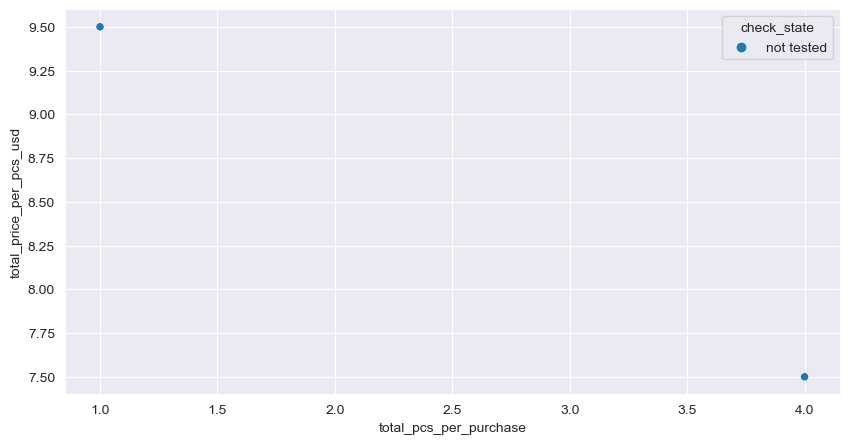

used


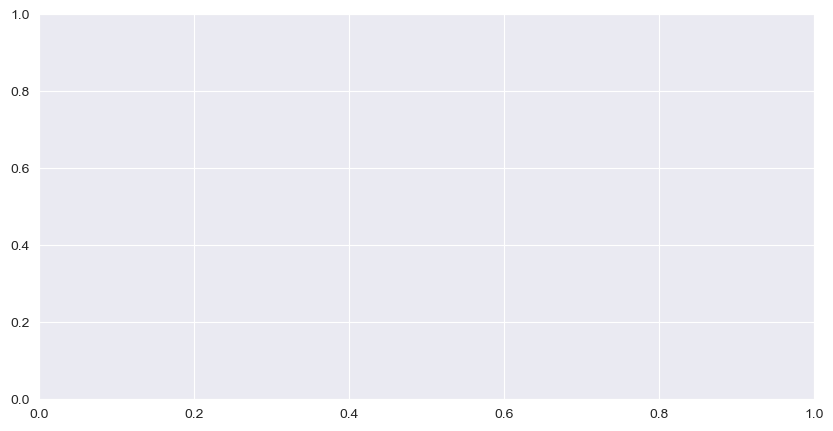


################################################## 6Н1П ##################################################
Продано штук:  1484 

Распределение по состоянию (проданных штук): 
newAndMatched        80
newAndTested        119
newNotTested        923
usedAndMatched        8
usedAndNotTested    324
usedAndTested        30 

Гистограмма цены для всех категорий:


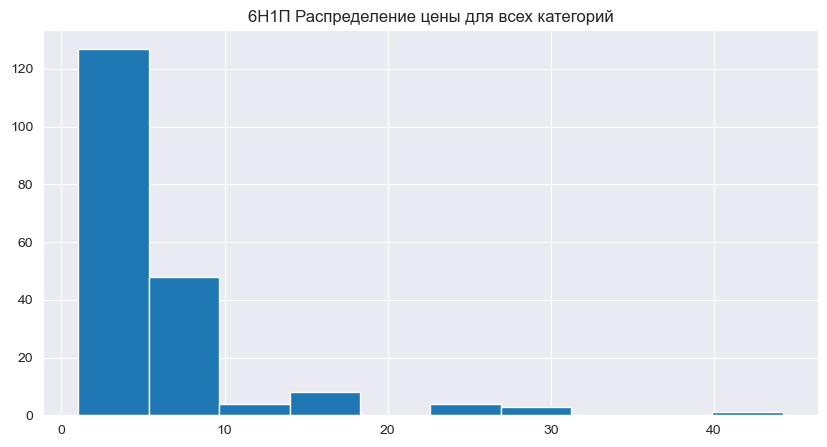

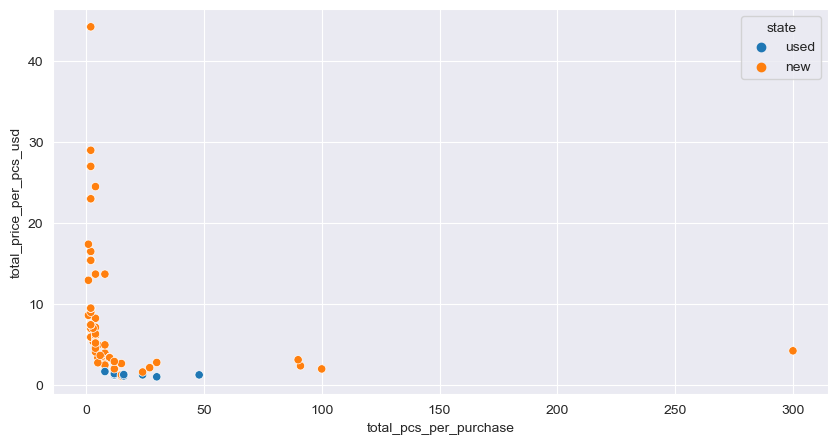

new


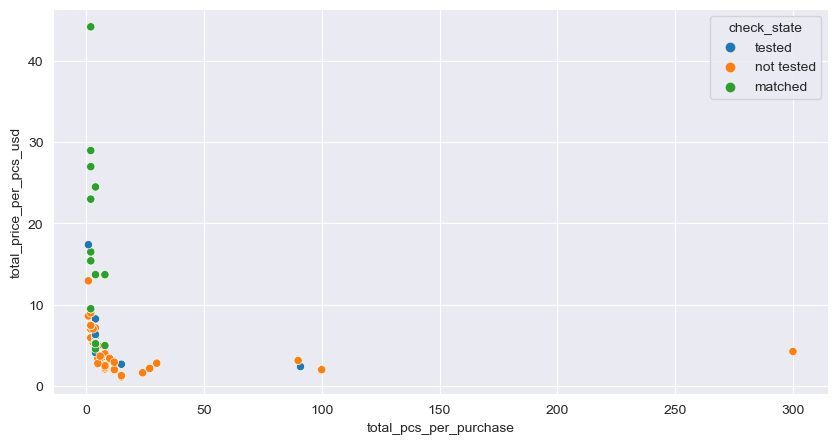

used


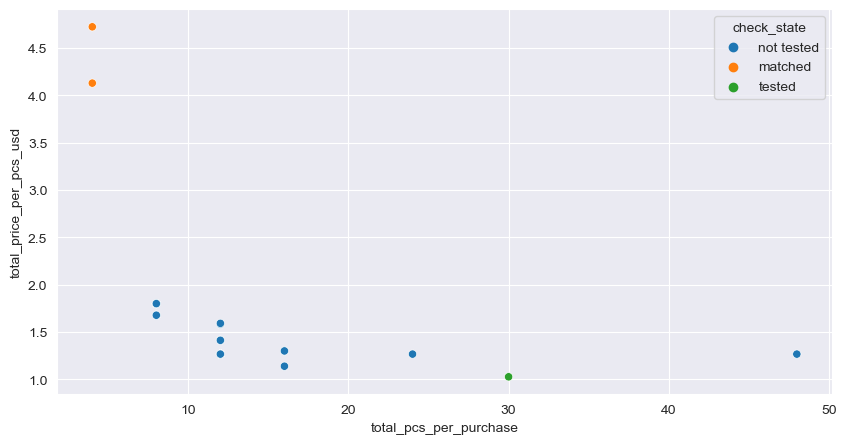


################################################## 6Н1П-В ##################################################
Продано штук:  13 

Распределение по состоянию (проданных штук): 
newAndMatched    8
newNotTested     4
usedAndTested    1 

Гистограмма цены для всех категорий:


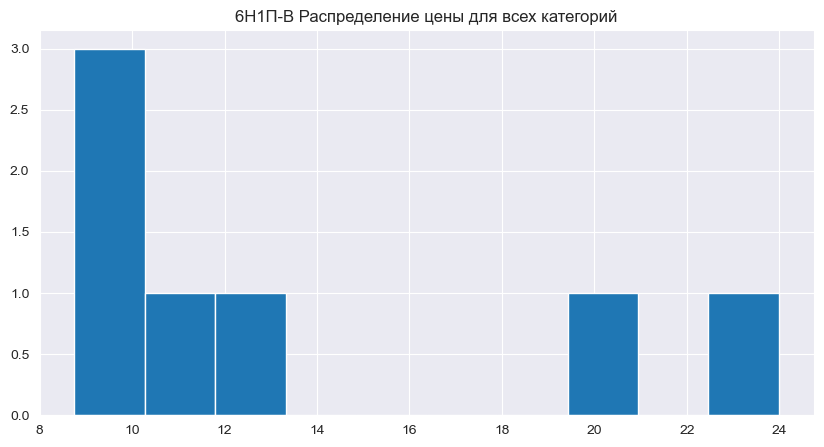

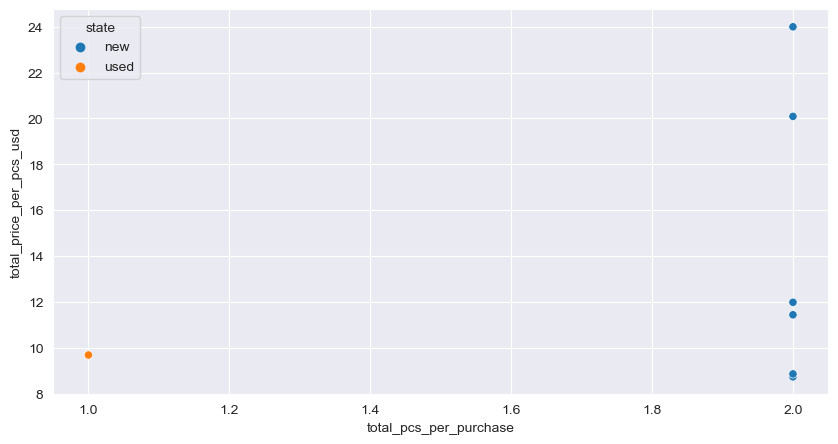

new


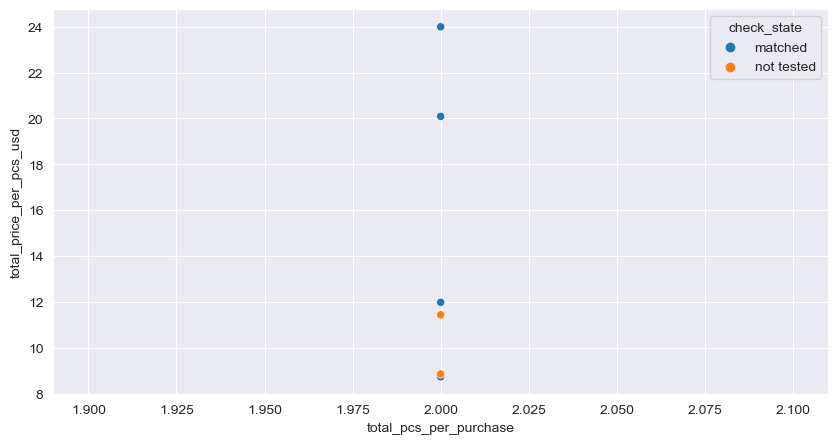

used


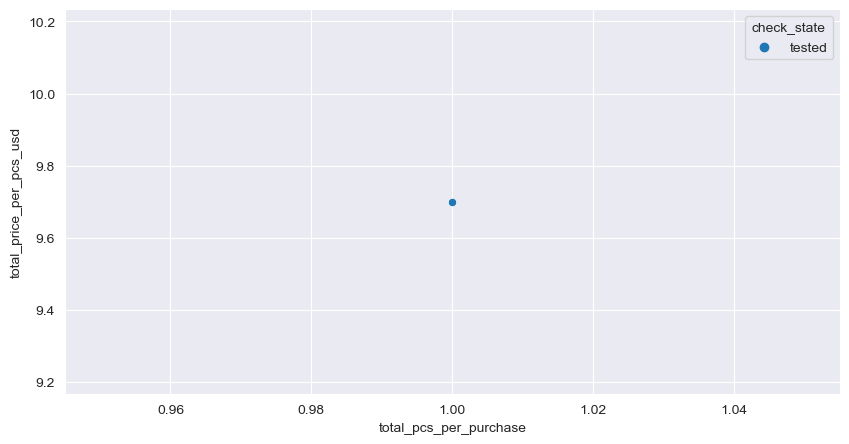


################################################## 6Н1П-ВИ ##################################################
Продано штук:  205 

Распределение по состоянию (проданных штук): 
newAndMatched         4
newAndTested          3
newNotTested        174
usedAndNotTested     24 

Гистограмма цены для всех категорий:


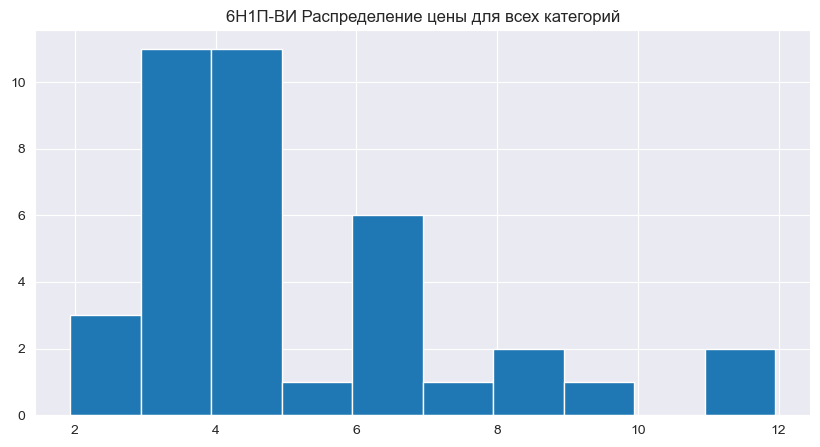

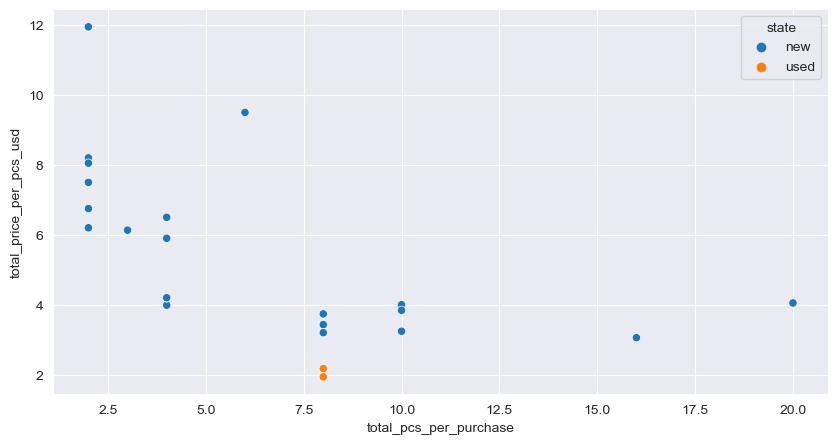

new


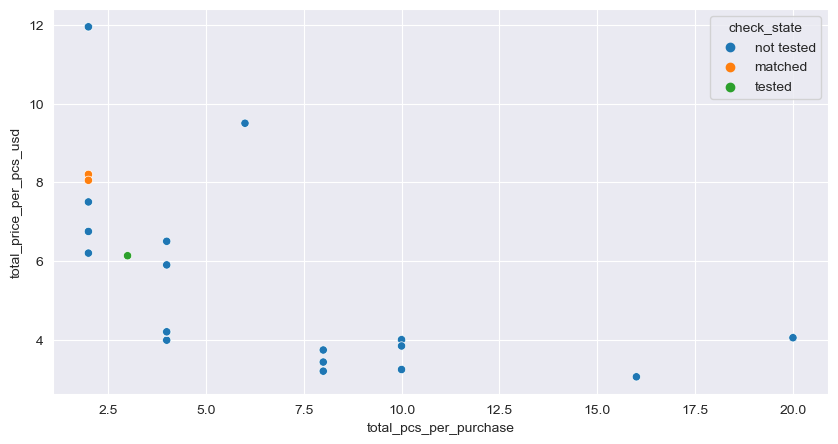

used


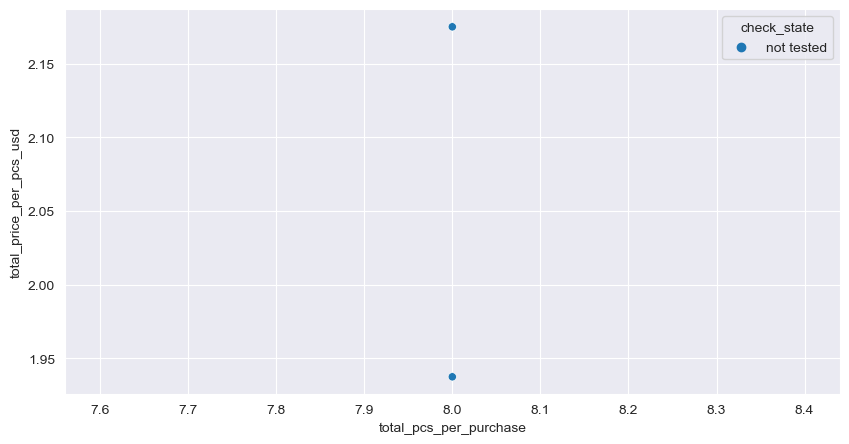


################################################## 6Н1П-Е ##################################################
Продано штук:  6 

Распределение по состоянию (проданных штук): 
newAndMatched    6 

Гистограмма цены для всех категорий:


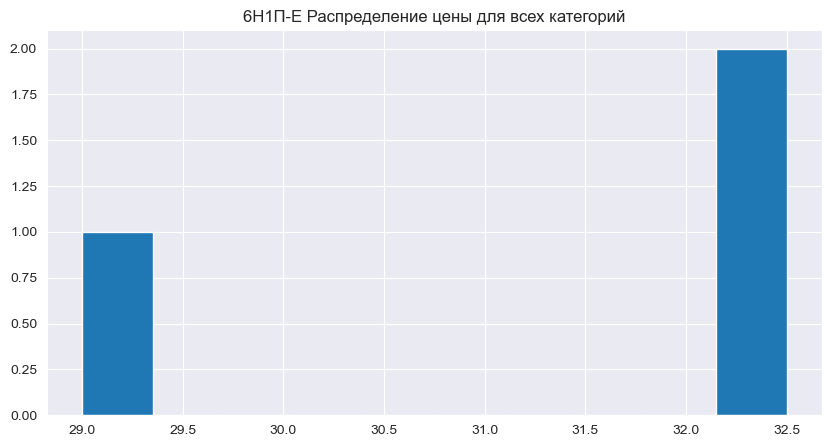

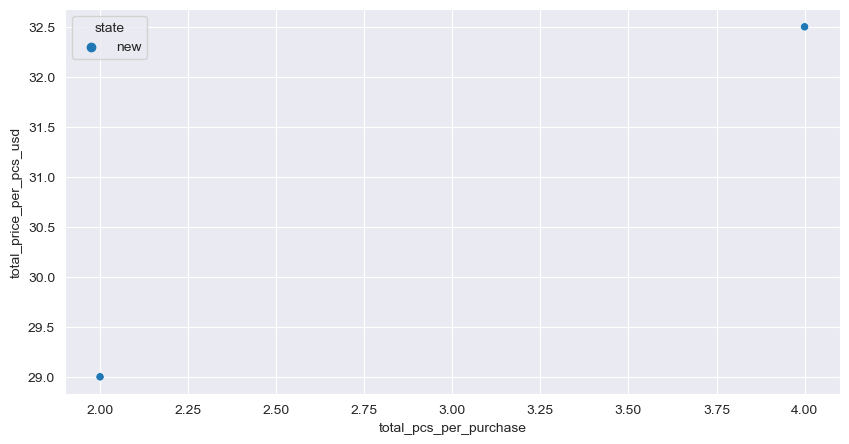

new


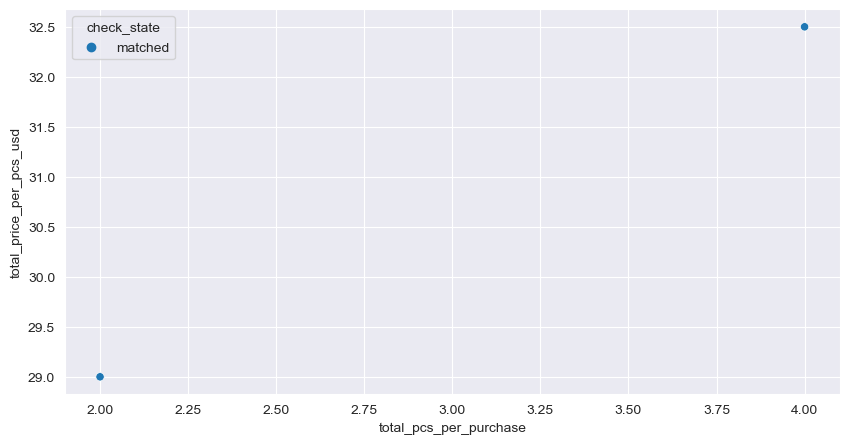

used


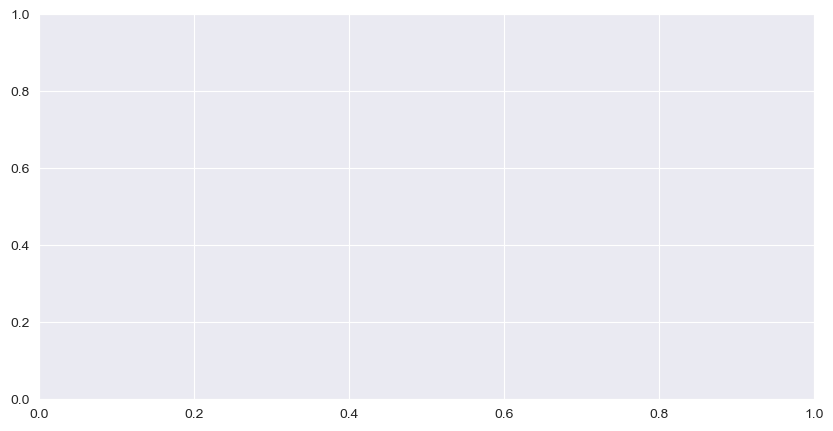


################################################## 6Н1П-ЕВ ##################################################
Продано штук:  706 

Распределение по состоянию (проданных штук): 
newAndMatched       340
newAndTested         29
newNotTested        241
usedAndMatched       16
usedAndNotTested     64
usedAndTested        16 

Гистограмма цены для всех категорий:


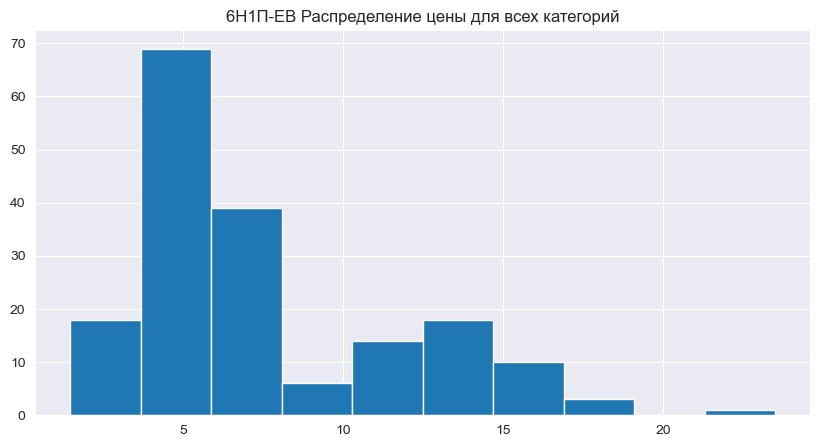

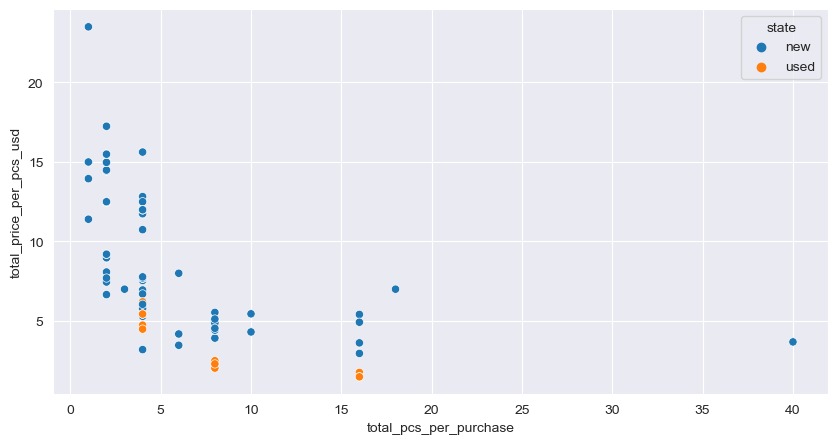

new


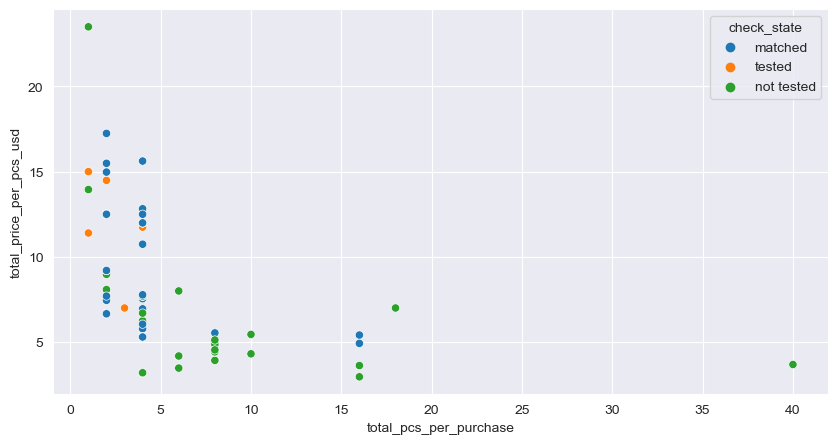

used


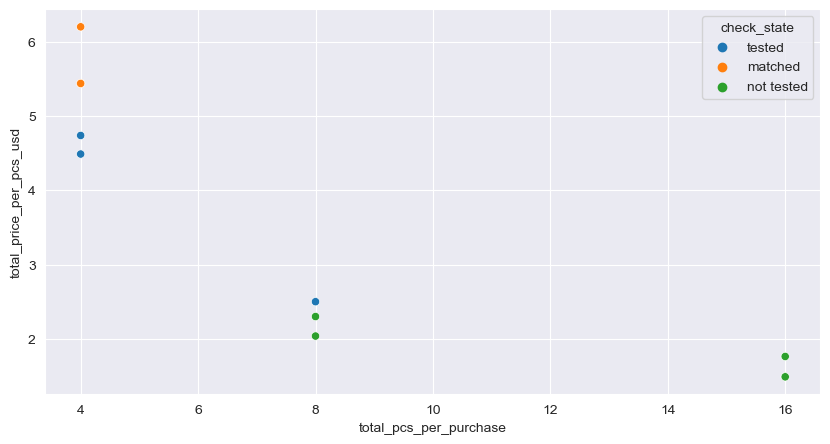


################################################## 6Н1П-ЕВ СОВТЕК ##################################################
Продано штук:  3 

Распределение по состоянию (проданных штук): 
newAndTested    3 

Гистограмма цены для всех категорий:


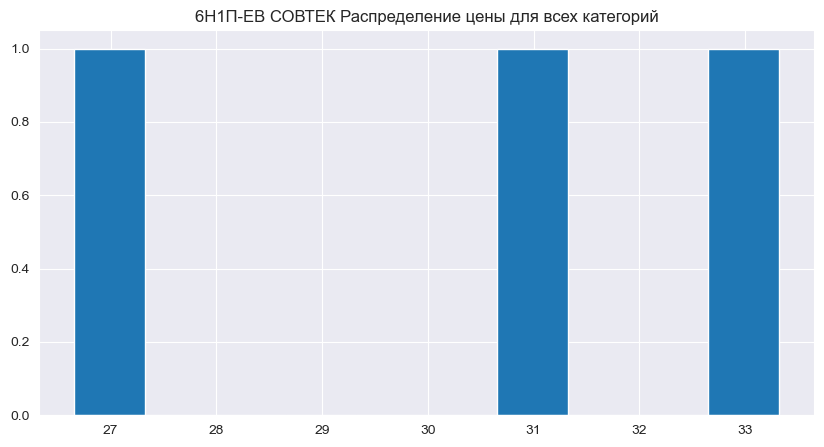

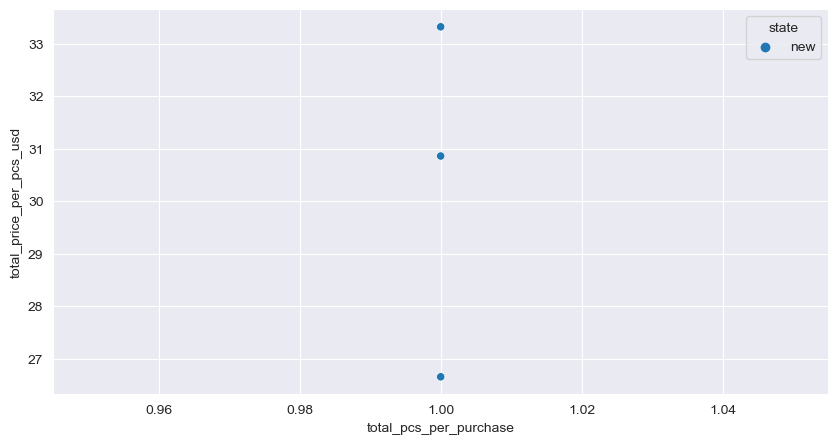

new


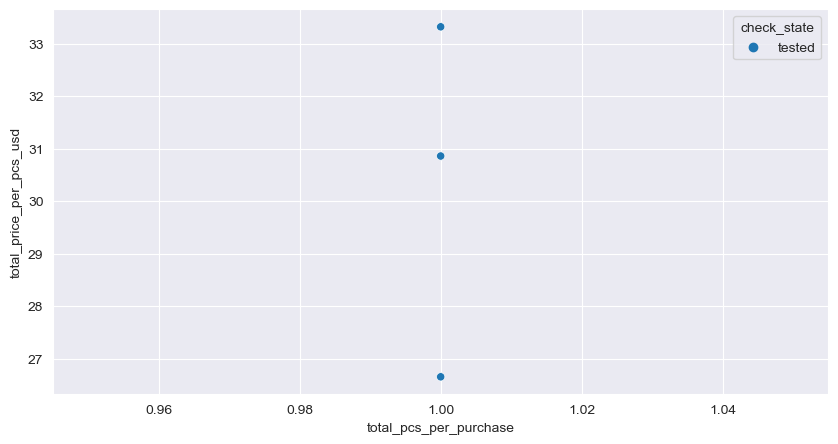

used


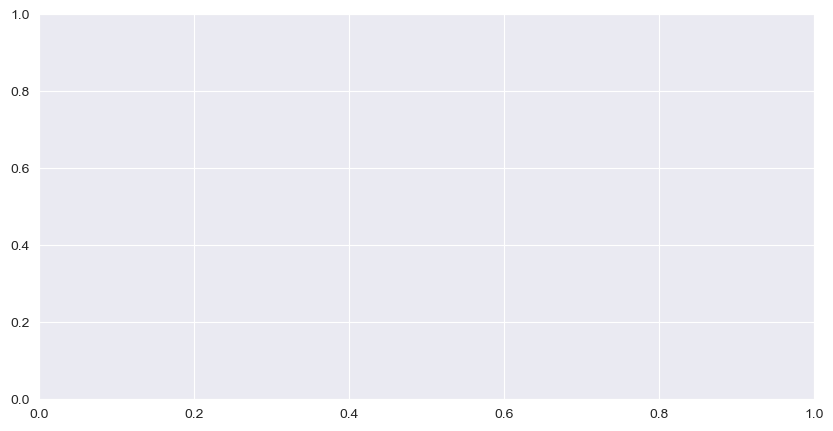


################################################## 6Н1П Совтек ##################################################
Продано штук:  2 

Распределение по состоянию (проданных штук): 
newAndMatched    2 

Гистограмма цены для всех категорий:


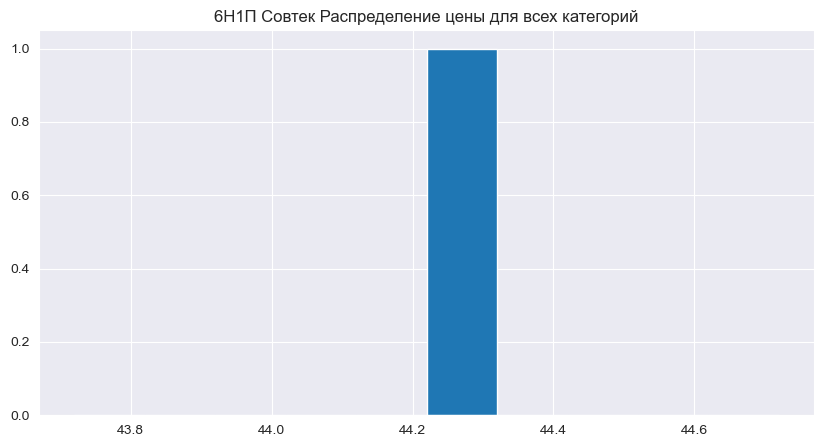

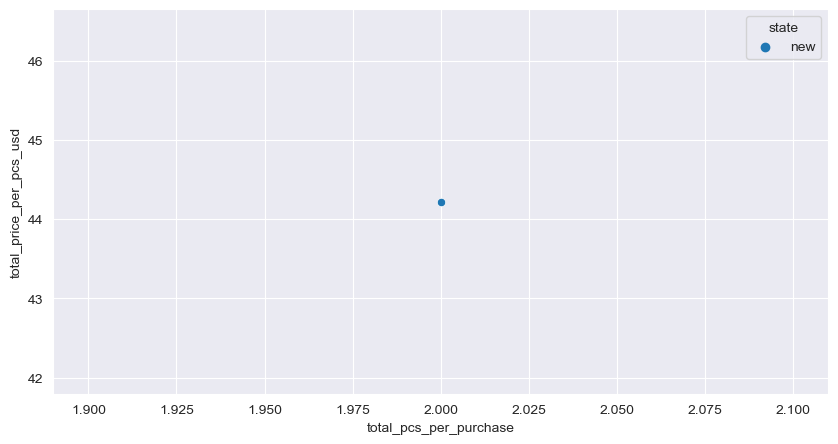

new


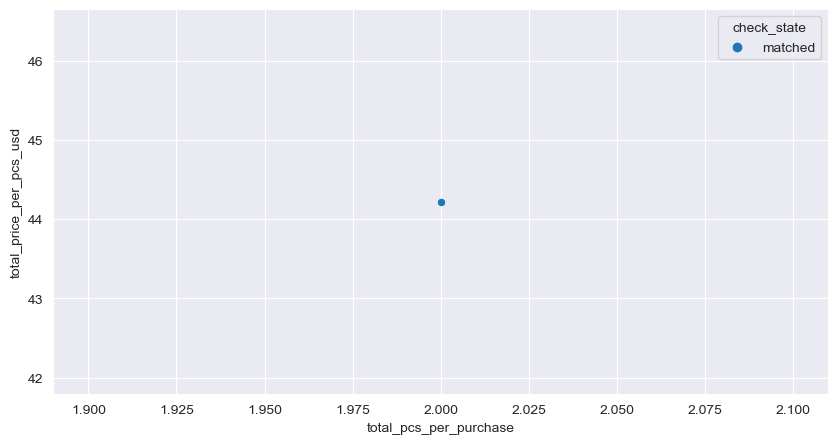

used


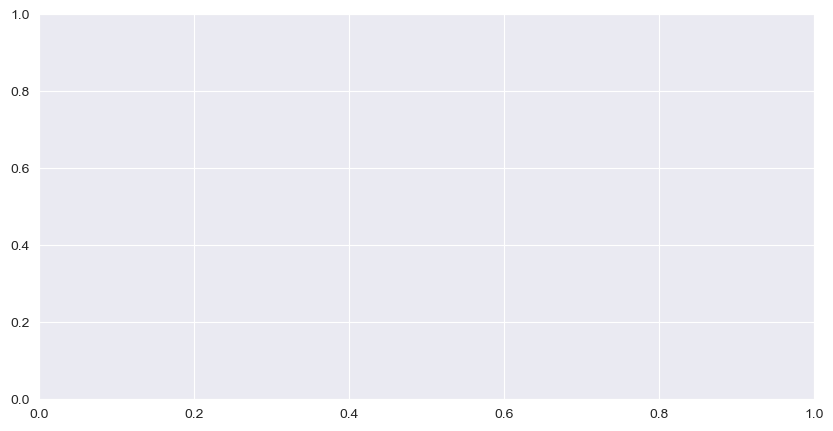


################################################## 6Н2П ##################################################
Продано штук:  1416 

Распределение по состоянию (проданных штук): 
newAndMatched        66
newAndTested         50
newNotTested        983
usedAndMatched       40
usedAndNotTested     60
usedAndTested       217 

Гистограмма цены для всех категорий:


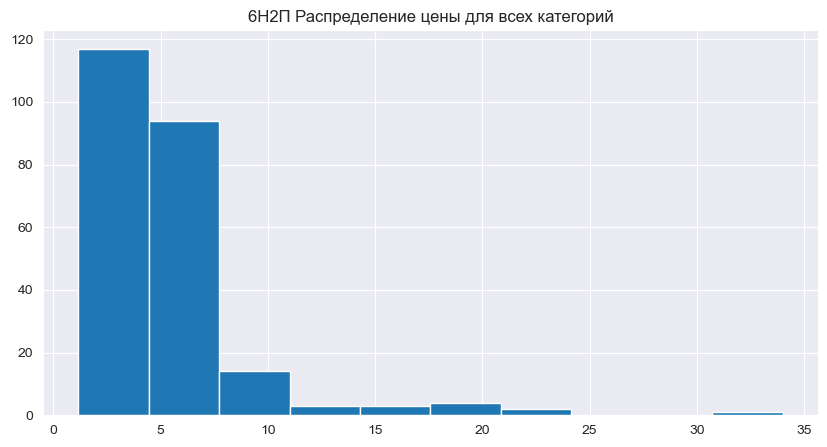

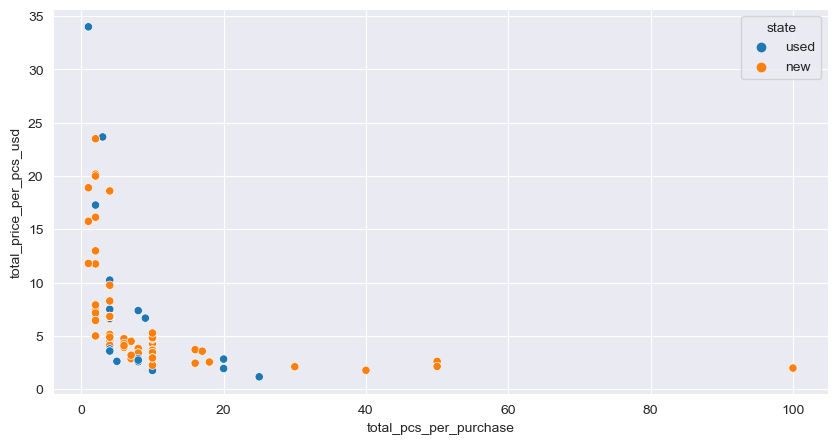

new


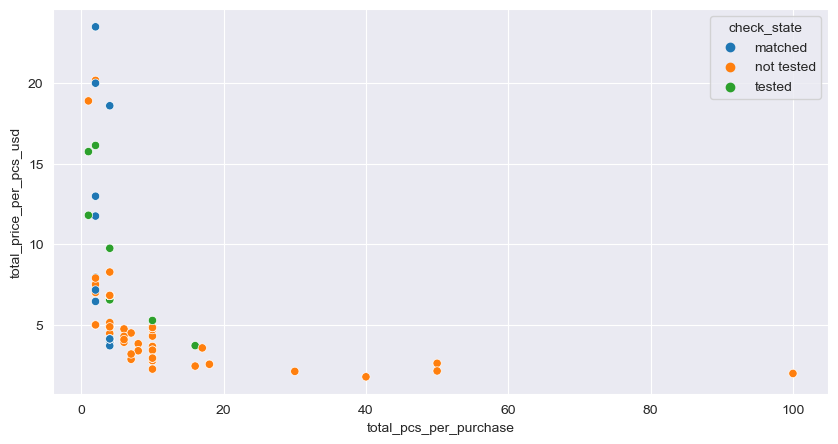

used


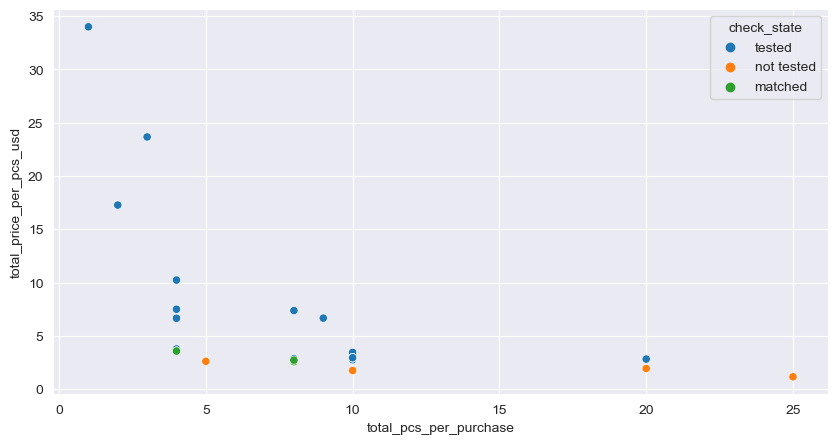


################################################## 6Н2П-В ##################################################
Продано штук:  70 

Распределение по состоянию (проданных штук): 
newAndMatched    34
newAndTested      4
newNotTested     32 

Гистограмма цены для всех категорий:


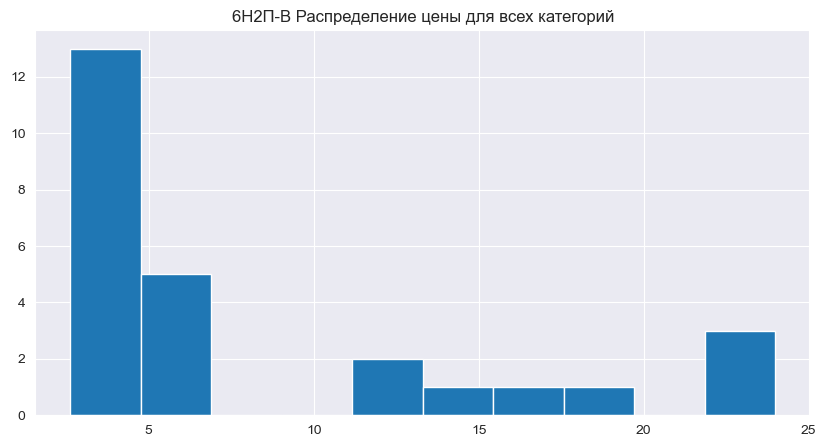

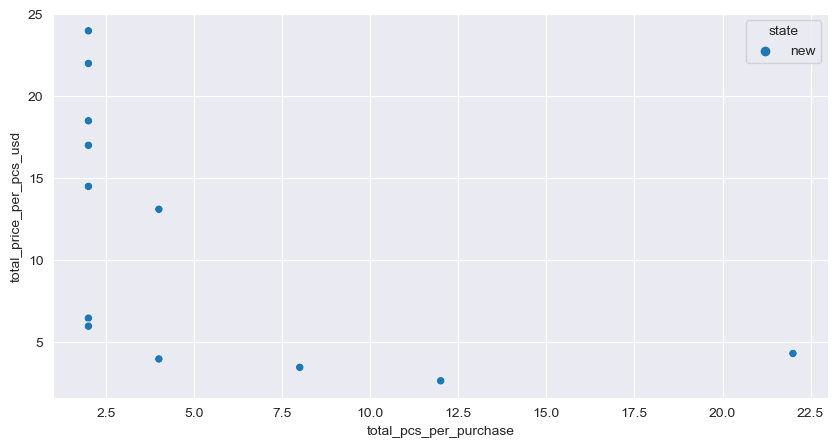

new


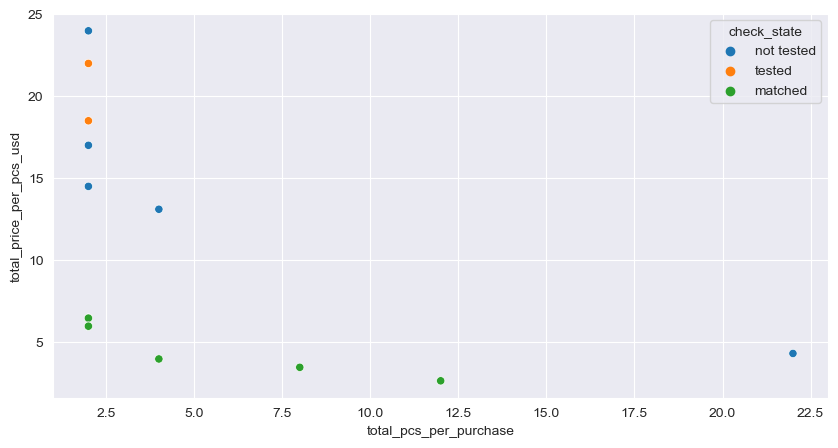

used


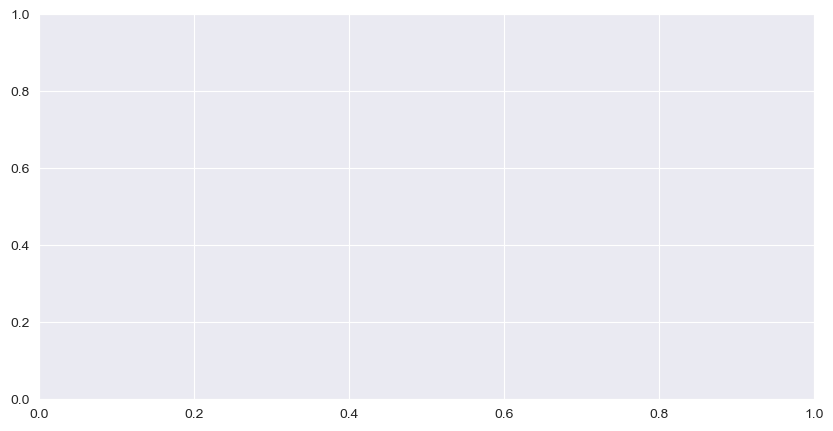


################################################## 6Н2П-Е ##################################################
Продано штук:  13 

Распределение по состоянию (проданных штук): 
newNotTested    13 

Гистограмма цены для всех категорий:


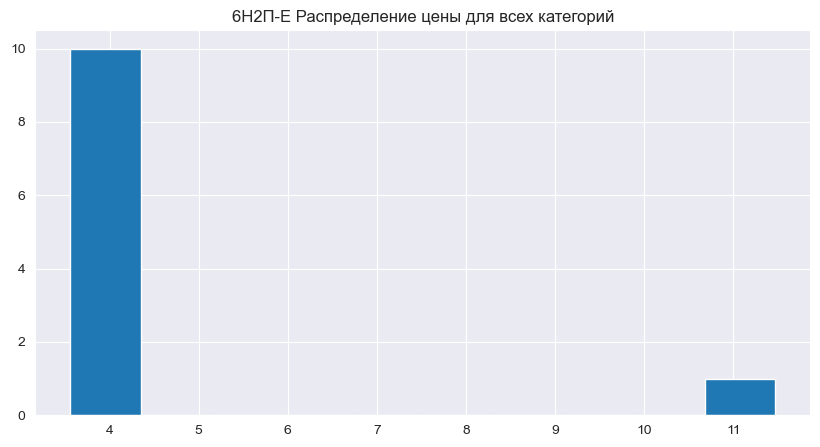

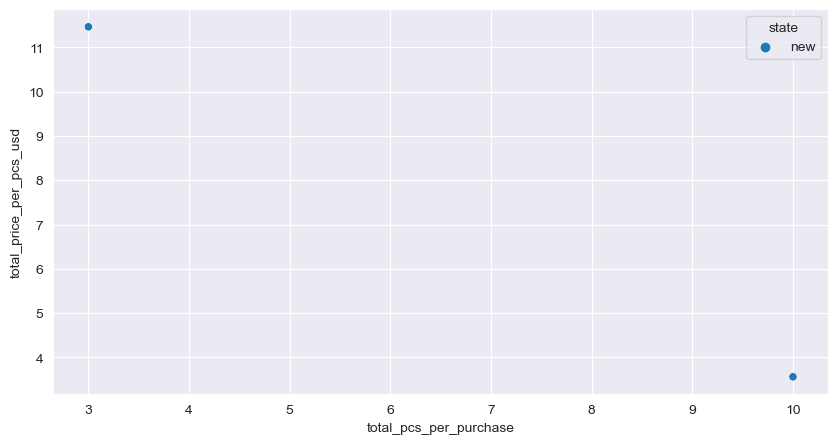

new


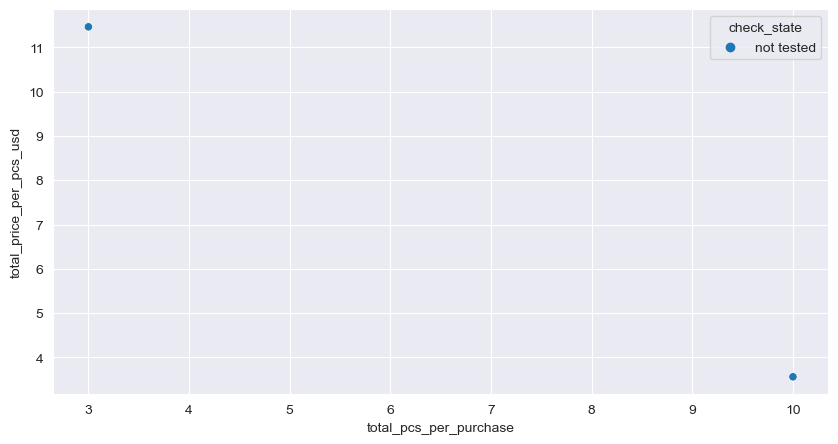

used


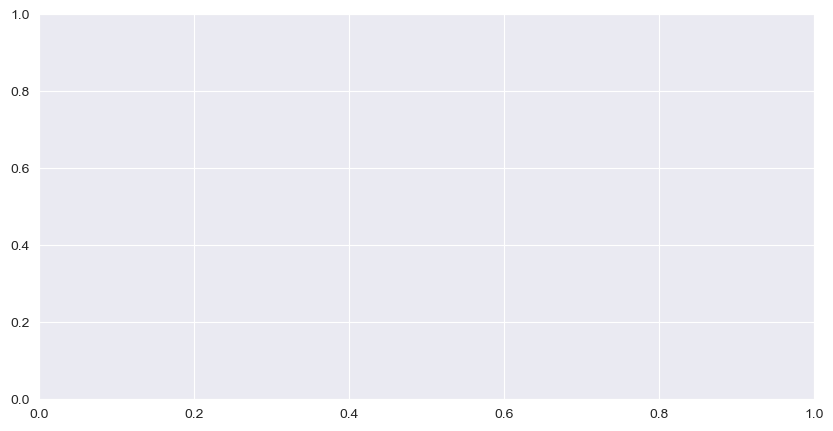


################################################## 6Н2П-ЕВ ##################################################
Продано штук:  2009 

Распределение по состоянию (проданных штук): 
newAndMatched      438
newAndTested        55
newNotTested      1469
usedAndMatched      40
usedAndTested        7 

Гистограмма цены для всех категорий:


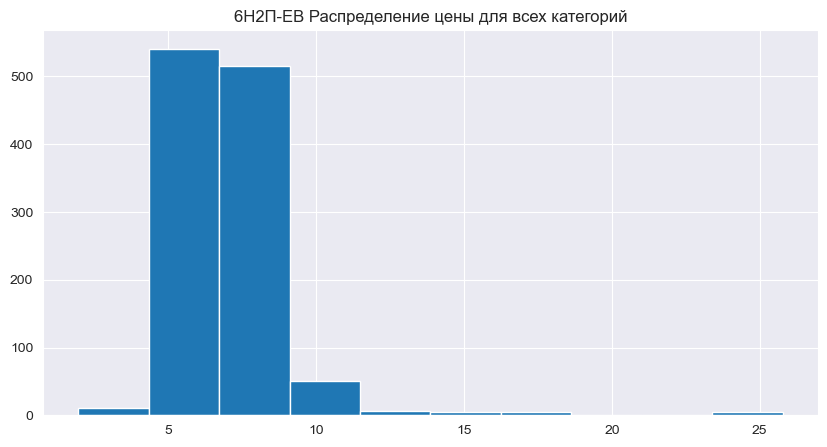

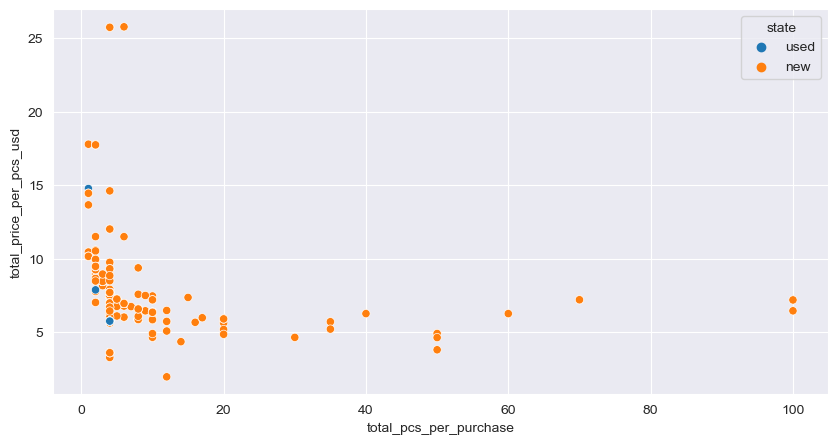

new


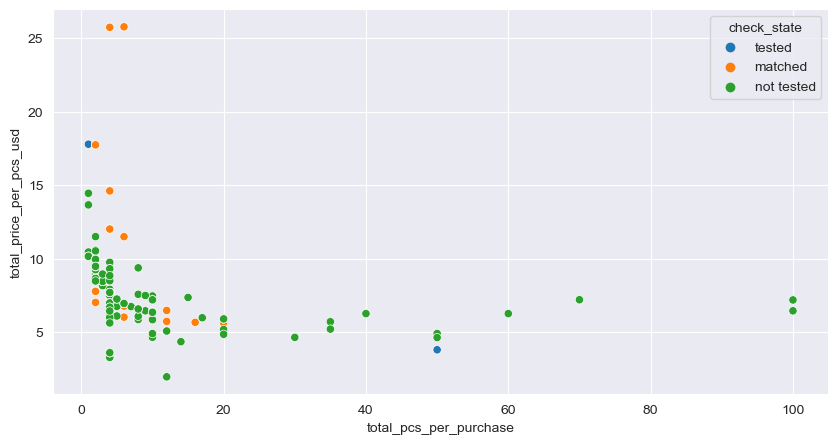

used


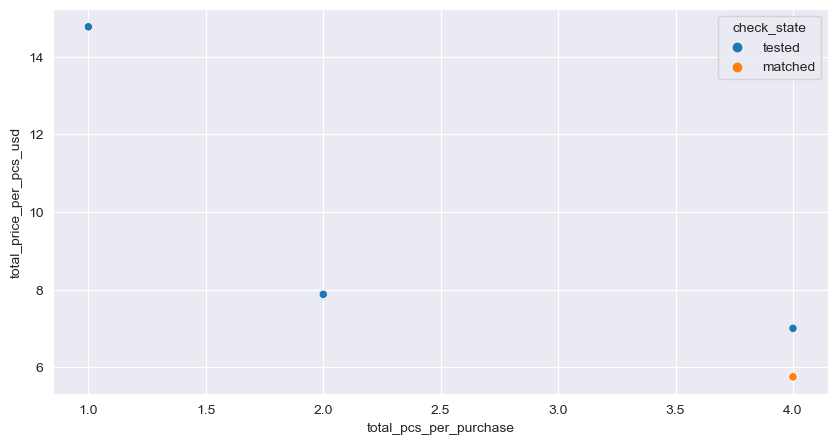


################################################## 6Н2П-ЕР ##################################################
Продано штук:  19 

Распределение по состоянию (проданных штук): 
newNotTested    19 

Гистограмма цены для всех категорий:


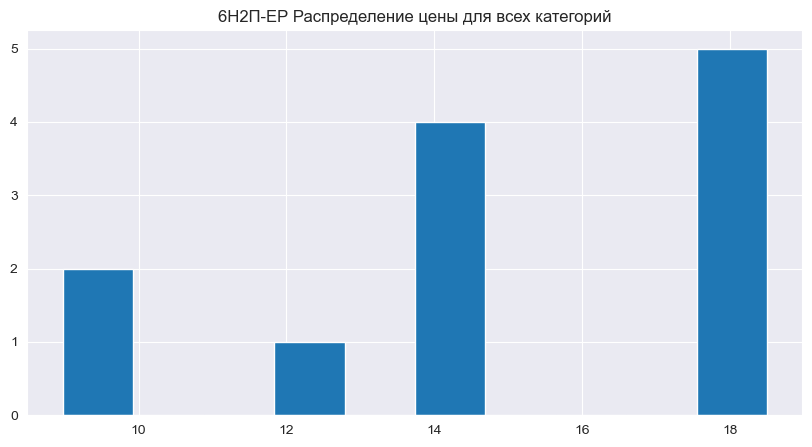

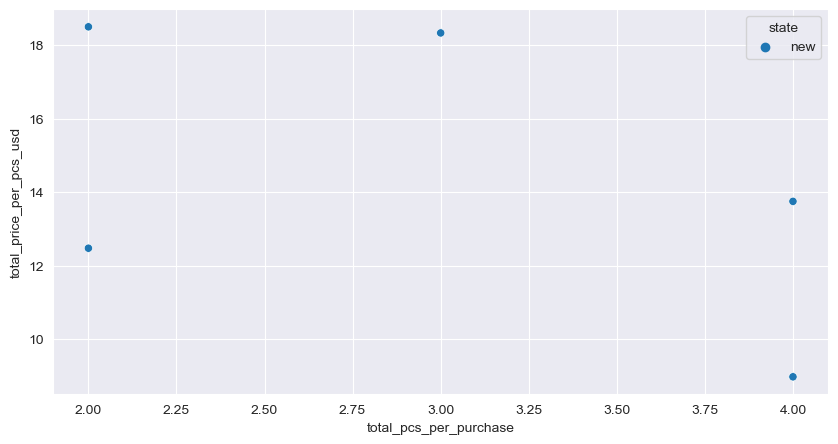

new


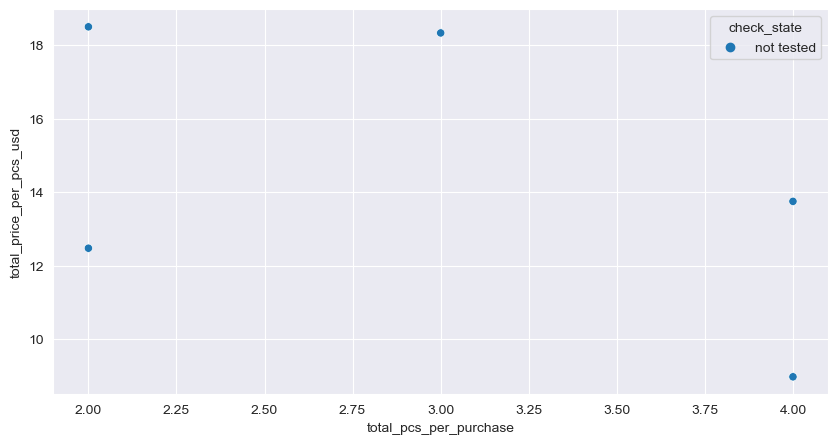

used


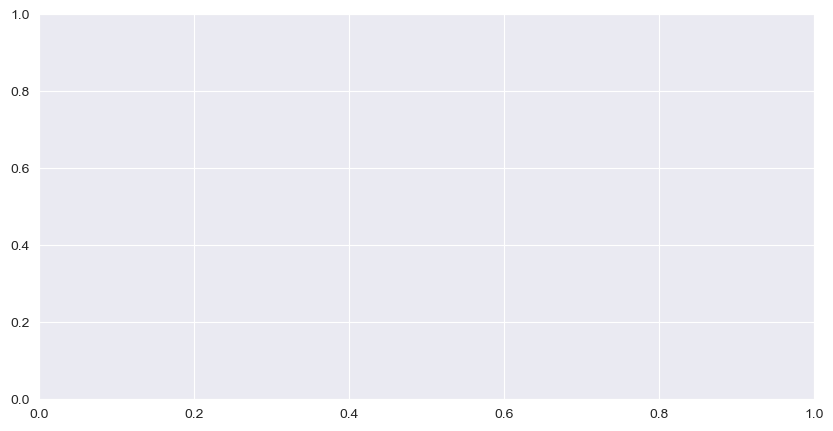


################################################## 6Н2П КИТАЙ ##################################################
Продано штук:  2 

Распределение по состоянию (проданных штук): 
newNotTested    2 

Гистограмма цены для всех категорий:


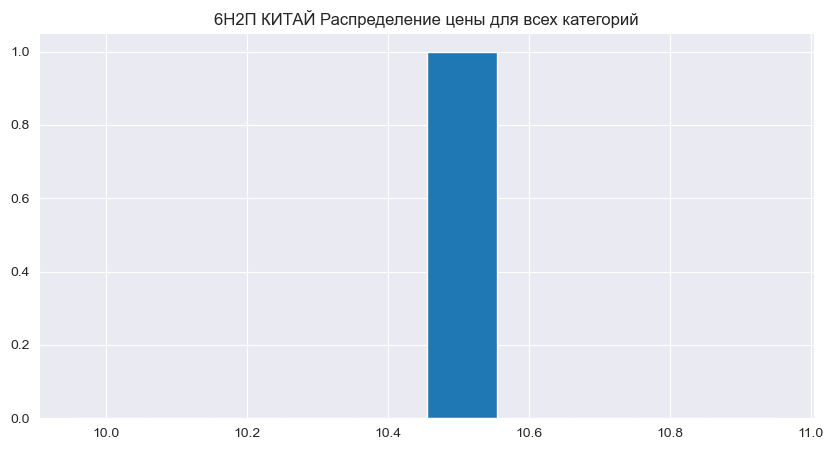

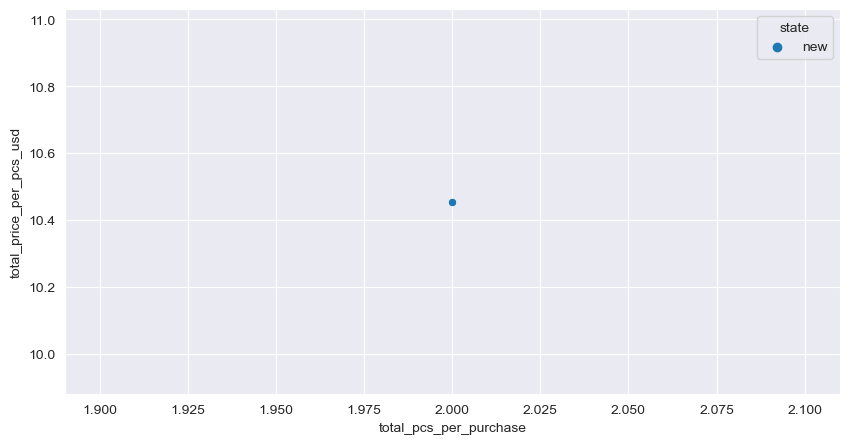

new


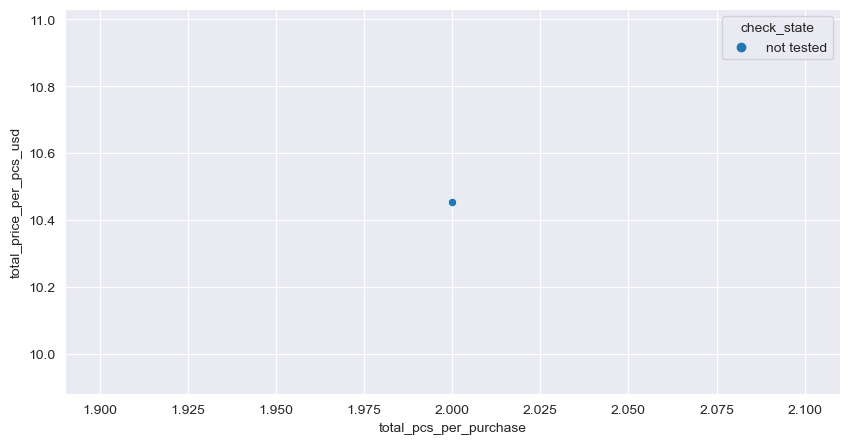

used


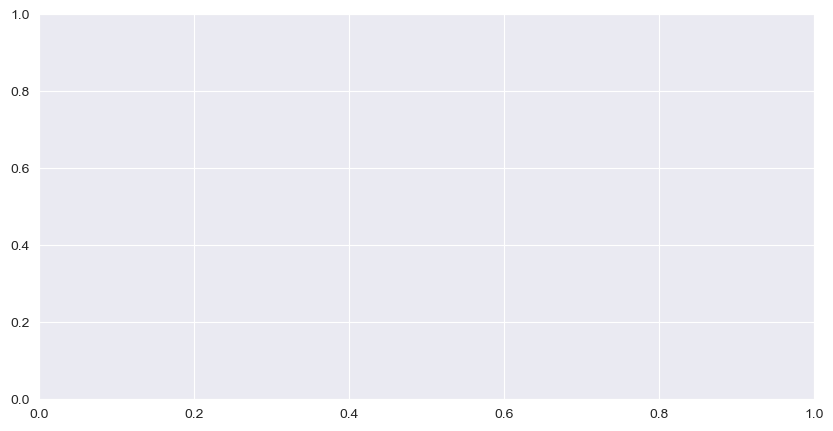


################################################## 6Н3П ##################################################
Продано штук:  758 

Распределение по состоянию (проданных штук): 
newAndMatched        32
newAndTested         82
newNotTested        244
usedAndNotTested    400 

Гистограмма цены для всех категорий:


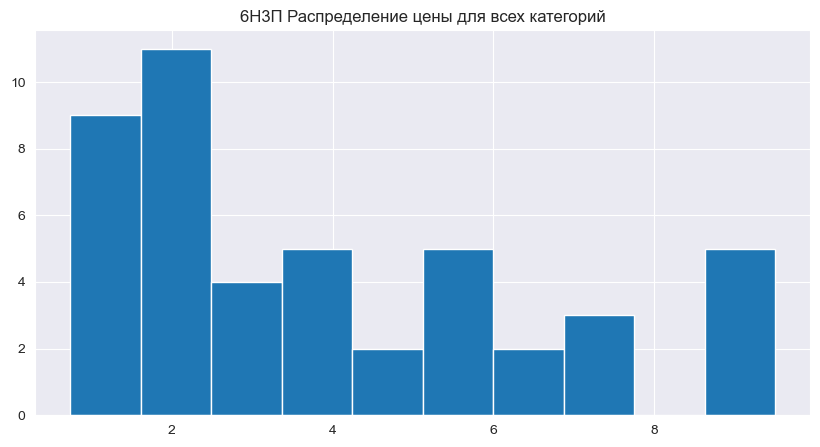

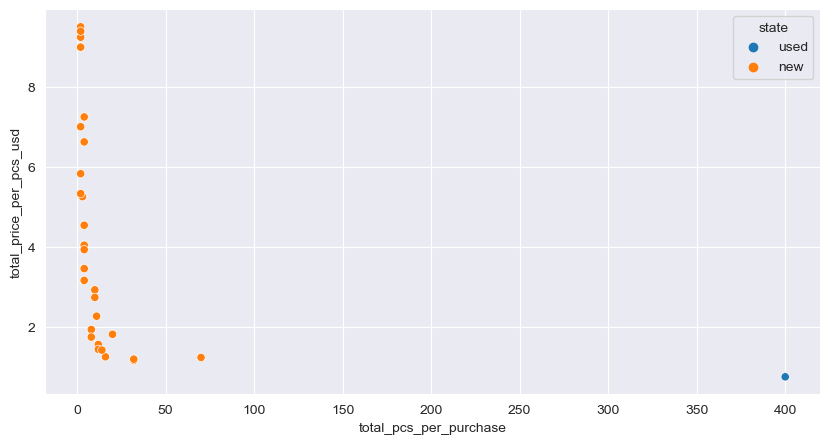

new


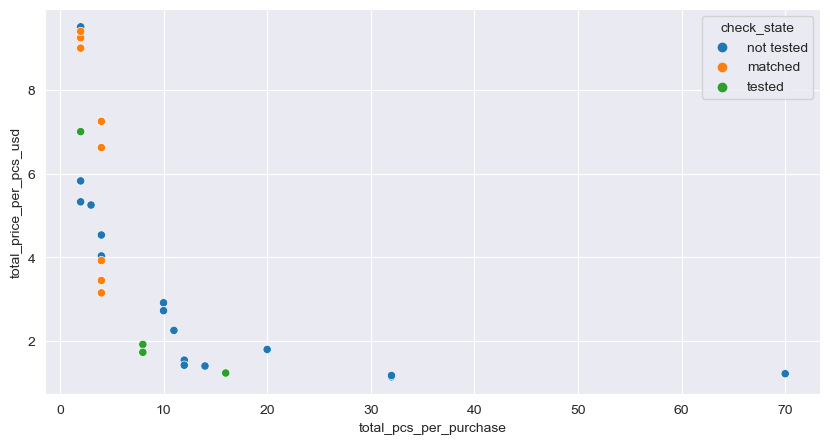

used


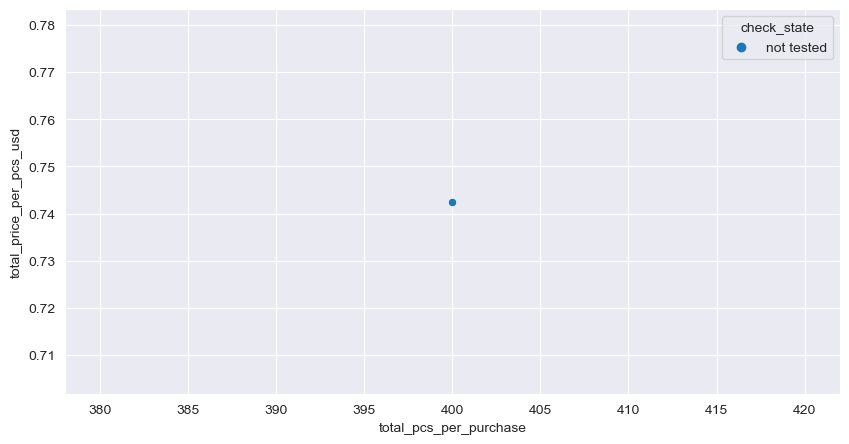


################################################## 6Н3П-ДР ##################################################
Продано штук:  58 

Распределение по состоянию (проданных штук): 
newAndMatched    52
newAndTested      4
newNotTested      2 

Гистограмма цены для всех категорий:


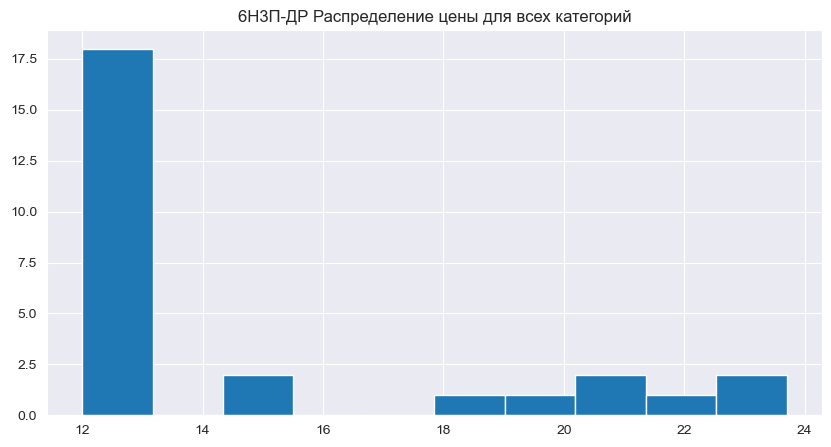

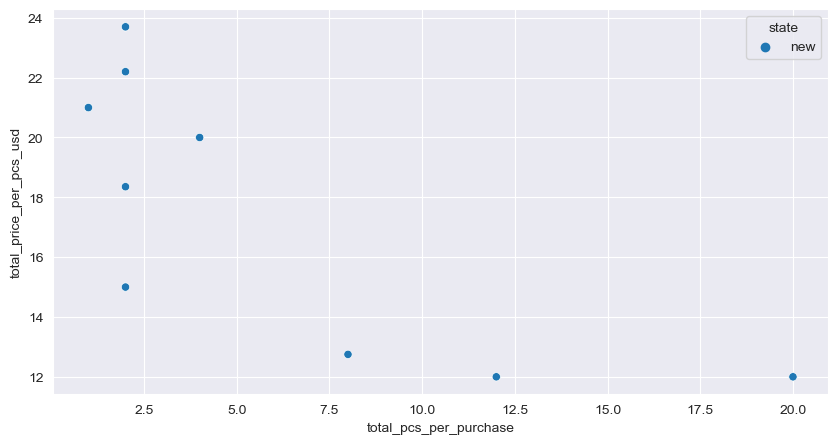

new


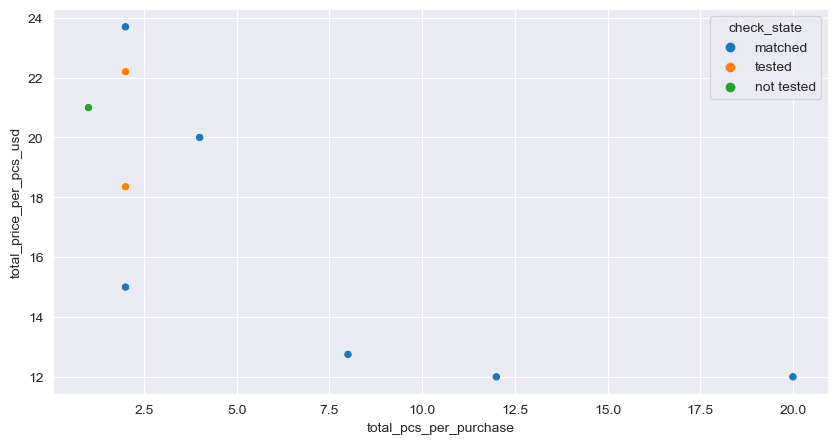

used


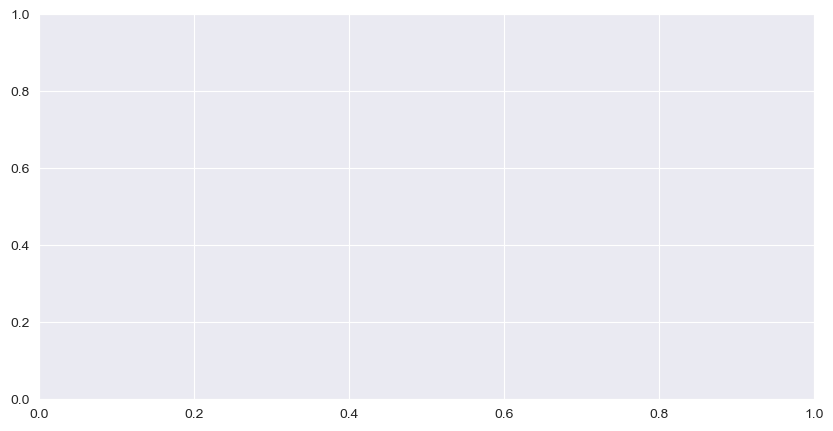


################################################## 6Н3П-Е ##################################################
Продано штук:  1093 

Распределение по состоянию (проданных штук): 
newAndMatched     14
newAndTested     140
newNotTested     939 

Гистограмма цены для всех категорий:


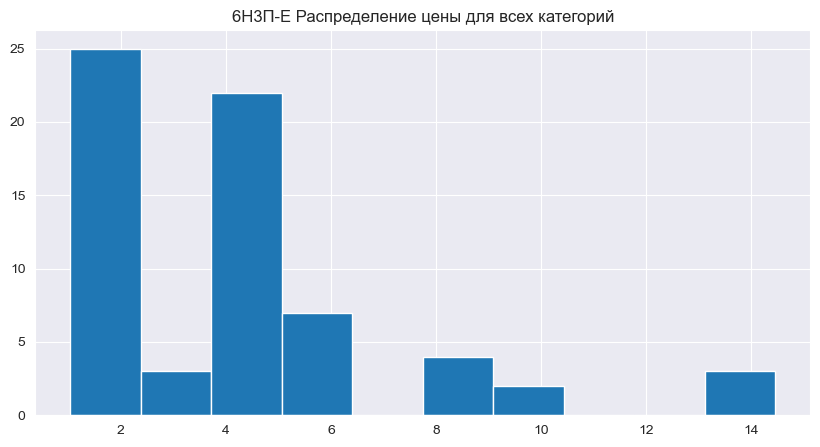

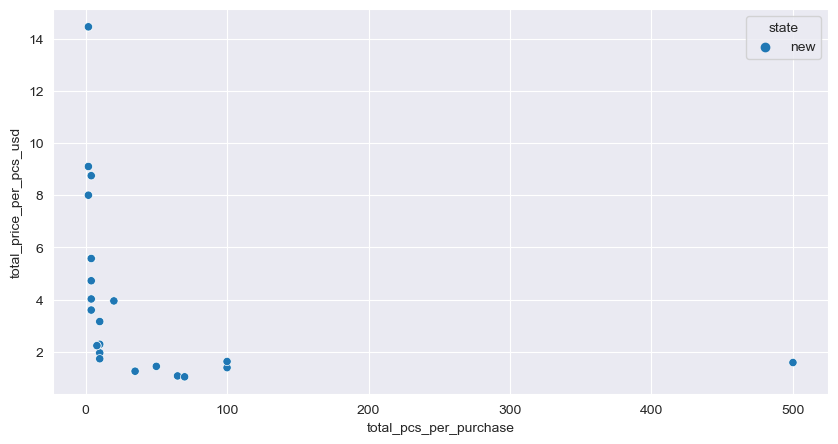

new


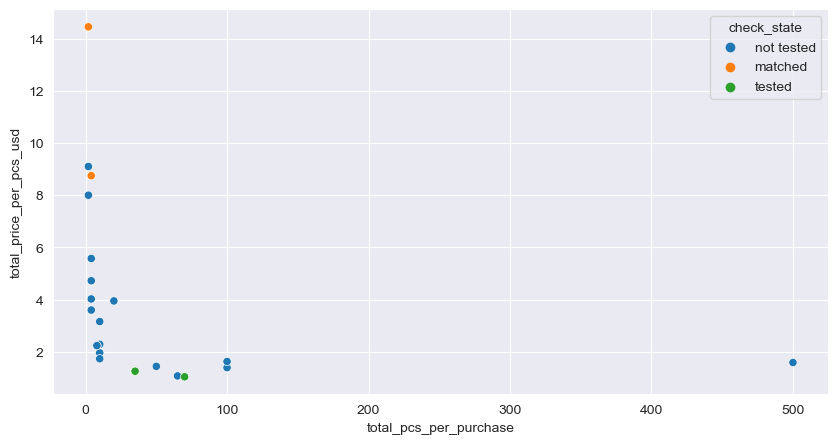

used


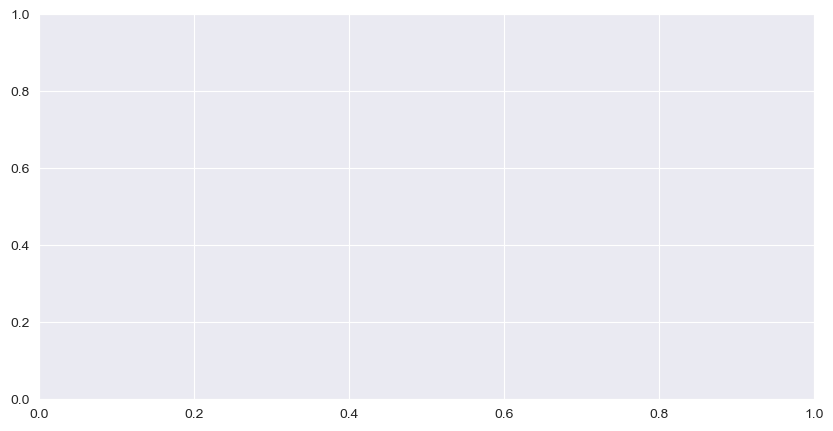


################################################## 6Н3П-ЕВ ##################################################
Продано штук:  329 

Распределение по состоянию (проданных штук): 
newAndMatched      4
newAndTested       2
newNotTested     323 

Гистограмма цены для всех категорий:


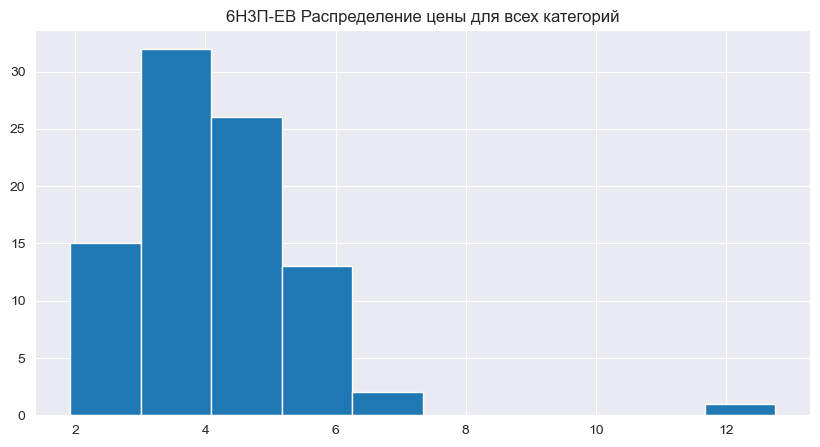

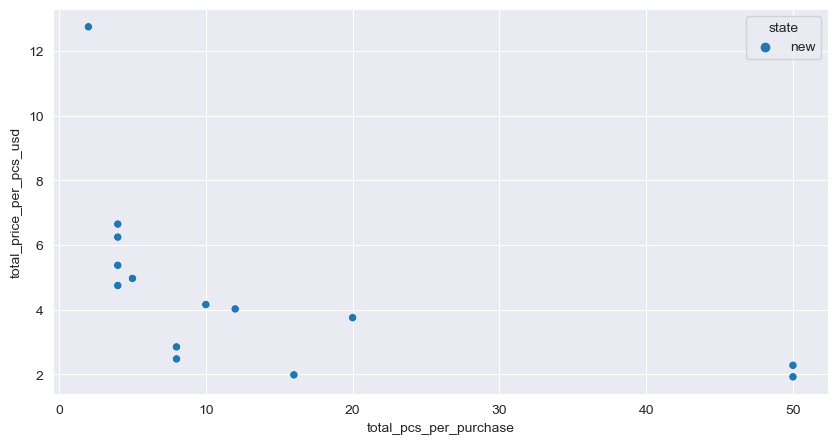

new


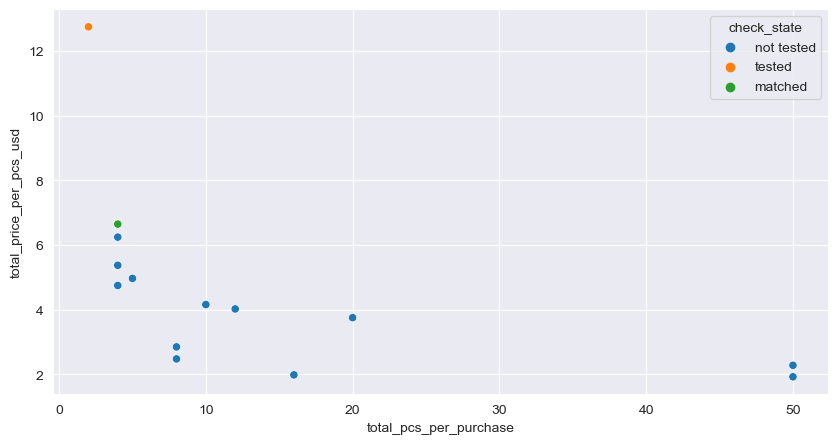

used


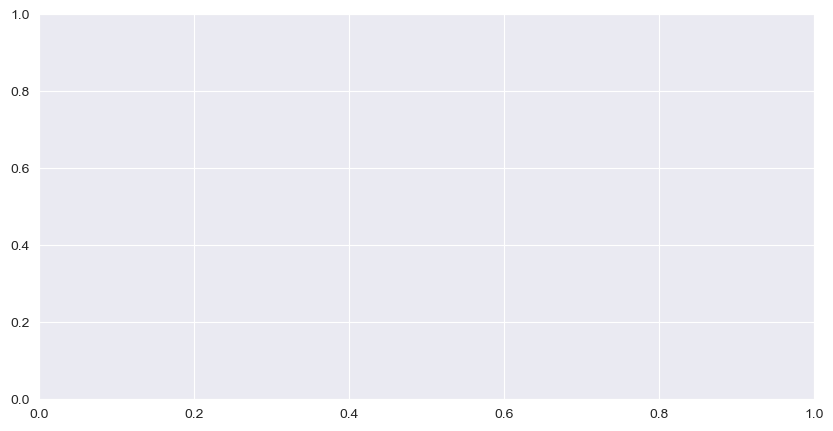


################################################## 6Н3П-И ##################################################
Продано штук:  406 

Распределение по состоянию (проданных штук): 
newAndMatched      4
newNotTested     402 

Гистограмма цены для всех категорий:


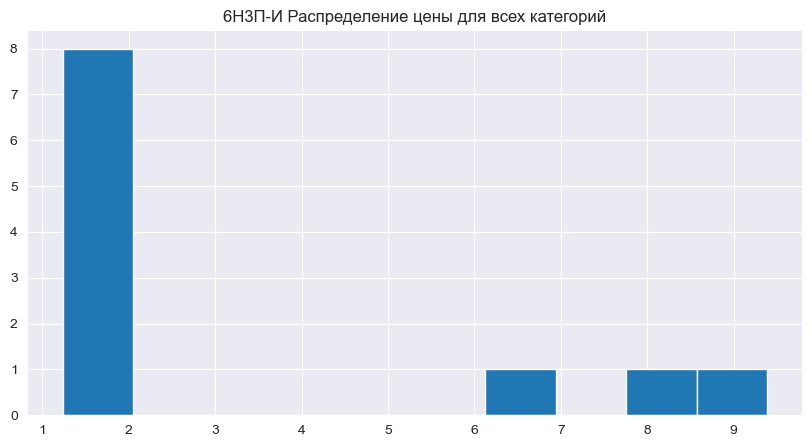

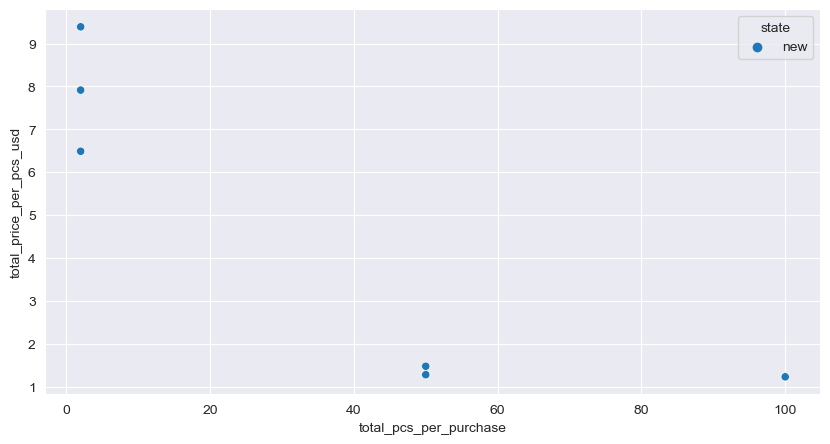

new


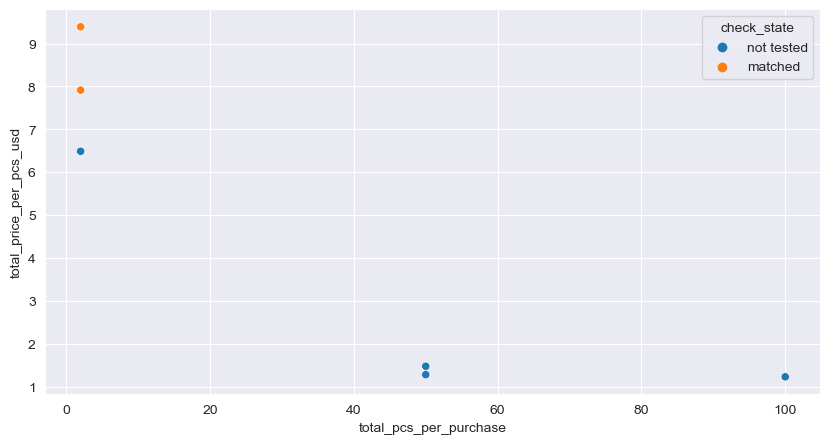

used


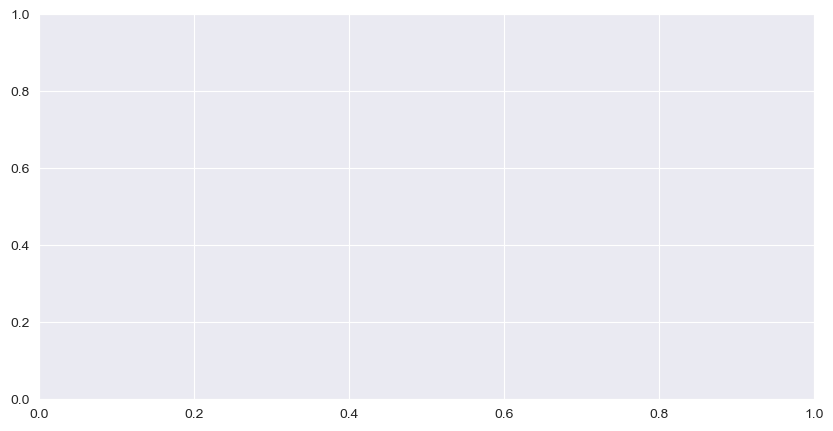


################################################## 6Н5П ##################################################
Продано штук:  8 

Распределение по состоянию (проданных штук): 
newAndMatched    2
newNotTested     6 

Гистограмма цены для всех категорий:


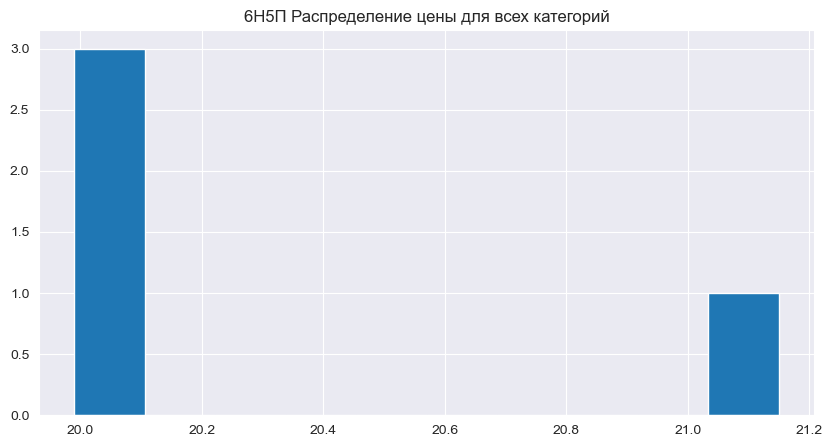

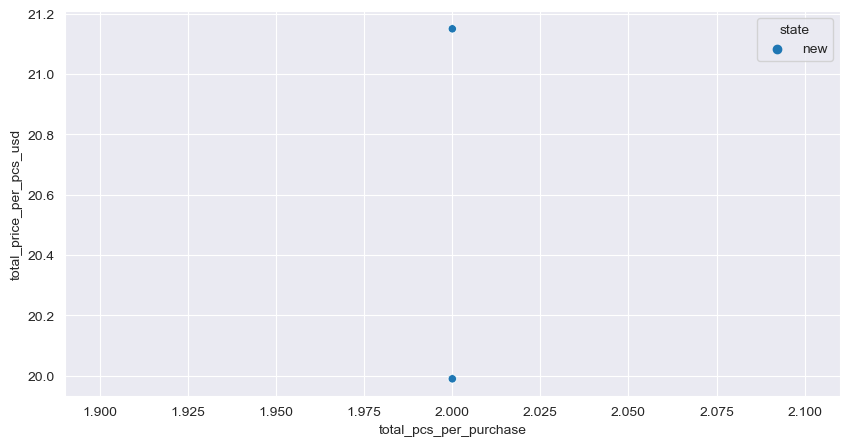

new


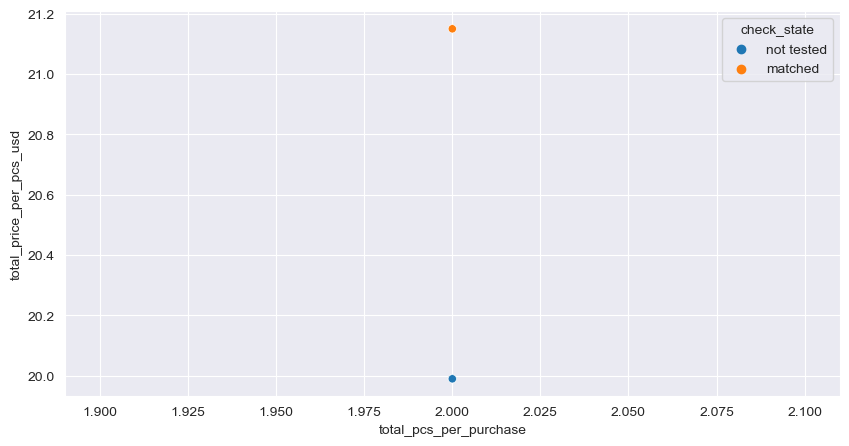

used


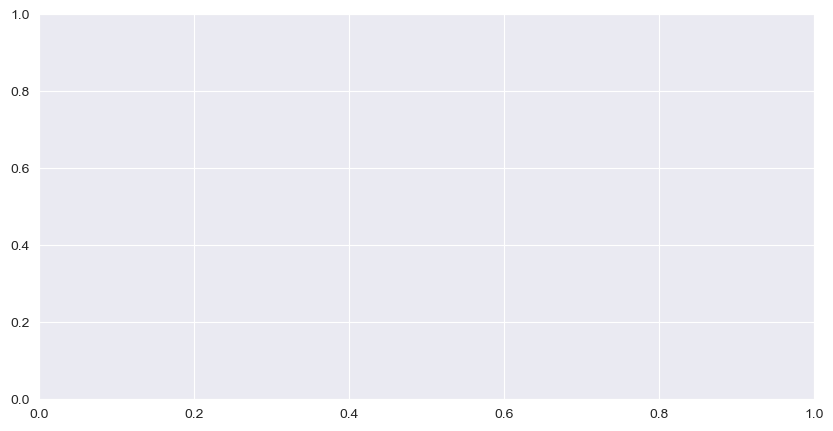


################################################## 6Н7С ##################################################
Продано штук:  144 

Распределение по состоянию (проданных штук): 
newAndMatched     10
newAndTested       2
newNotTested     124
usedAndTested      8 

Гистограмма цены для всех категорий:


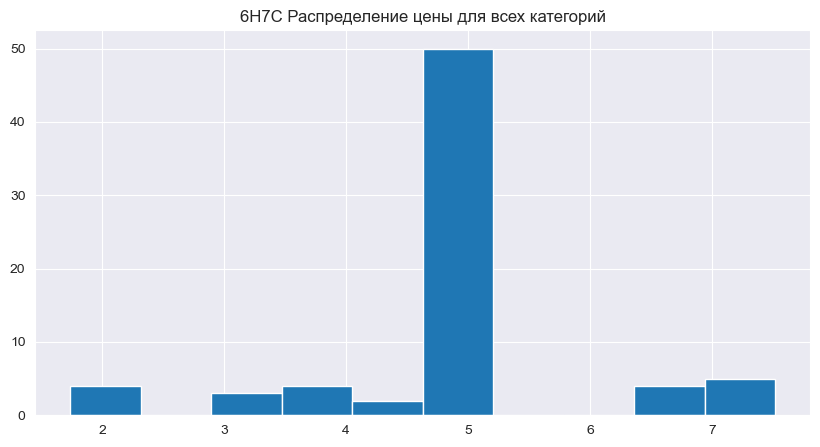

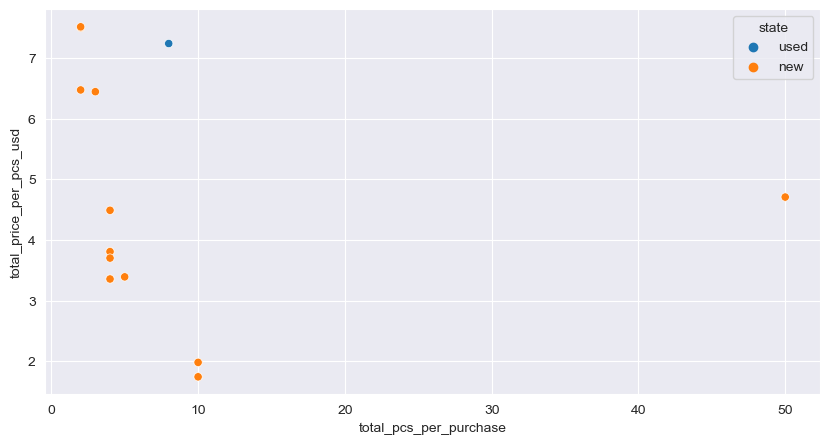

new


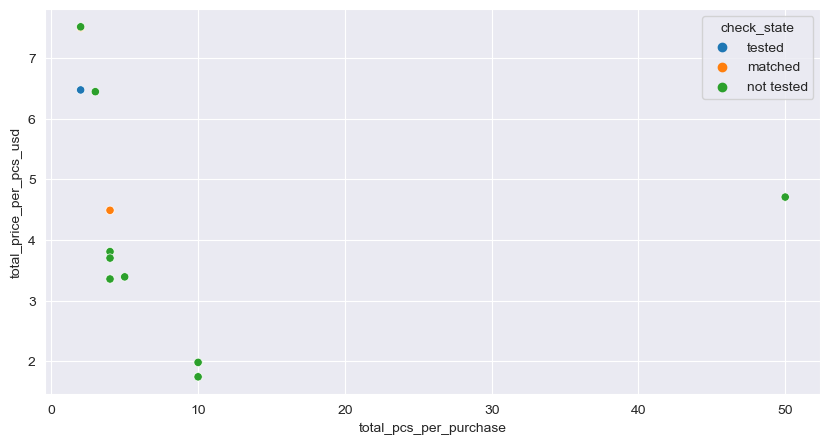

used


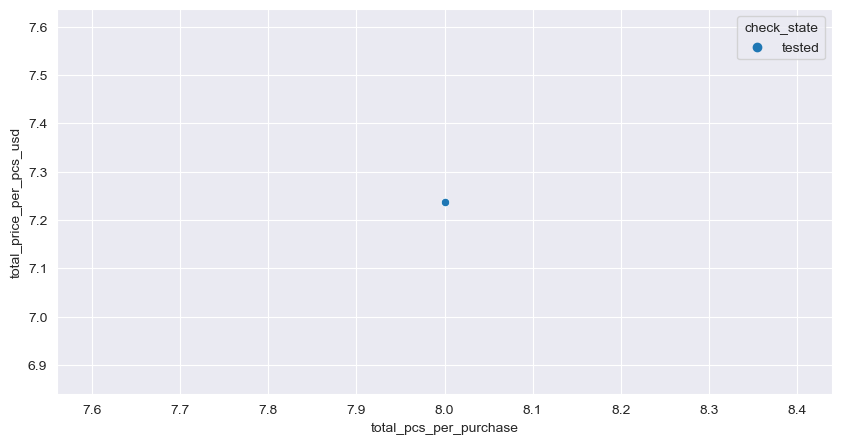


################################################## 6Н9С ##################################################
Продано штук:  14 

Распределение по состоянию (проданных штук): 
newAndMatched    12
newAndTested      2 

Гистограмма цены для всех категорий:


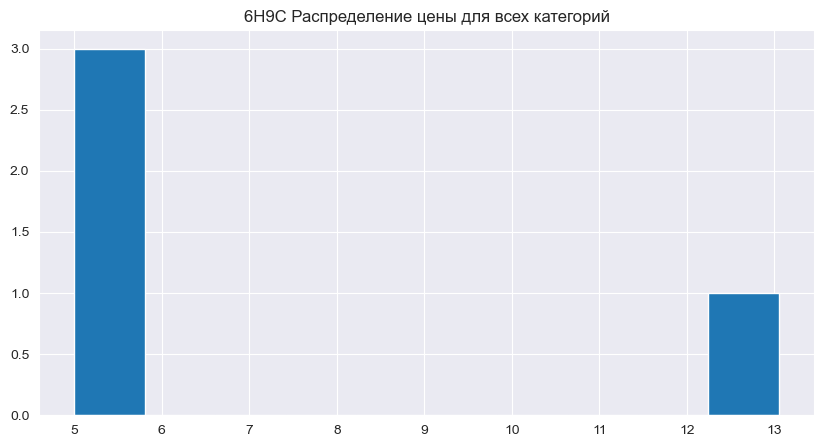

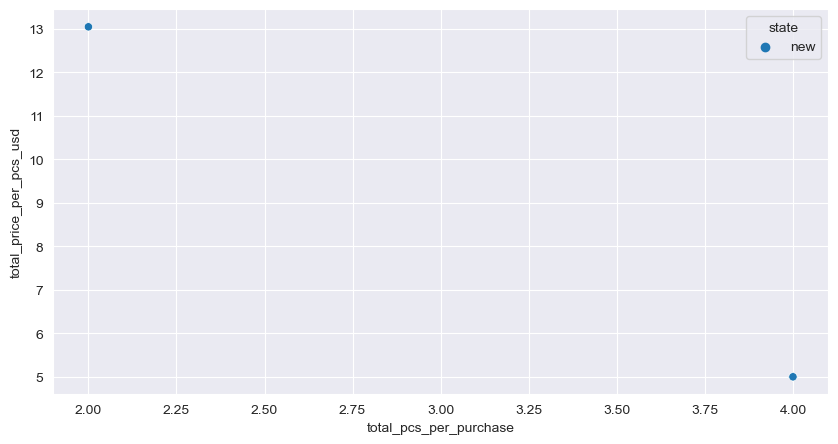

new


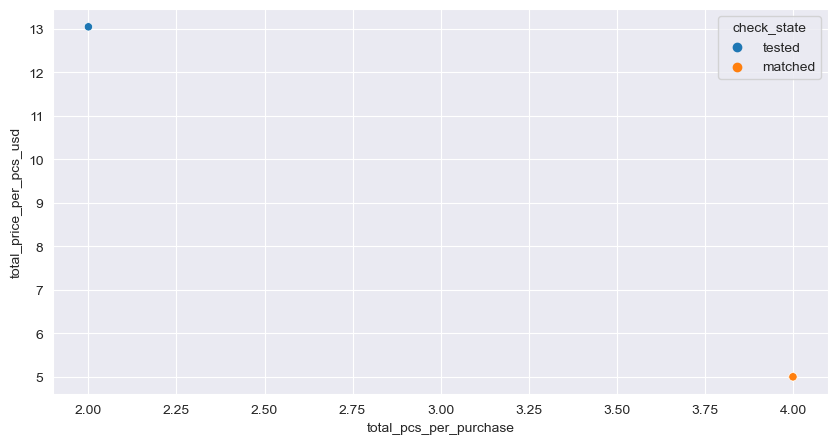

used


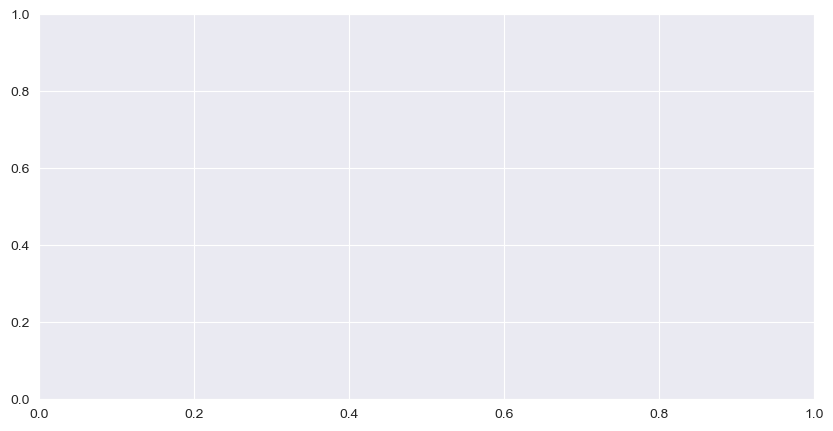


################################################## 6П13С ##################################################
Продано штук:  47 

Распределение по состоянию (проданных штук): 
newNotTested     46
usedAndTested     1 

Гистограмма цены для всех категорий:


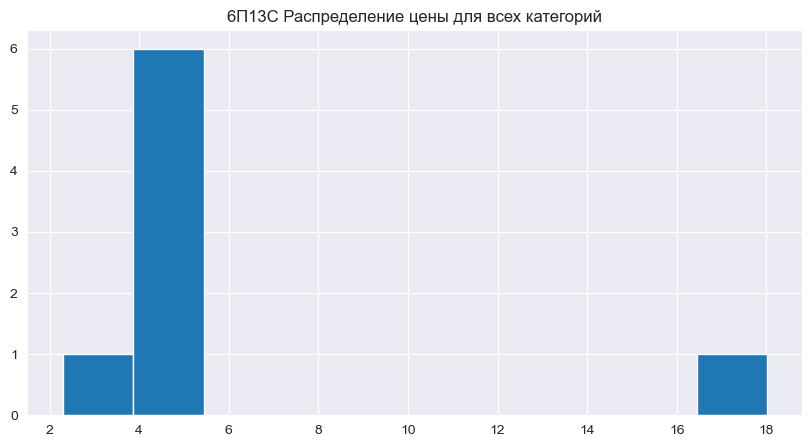

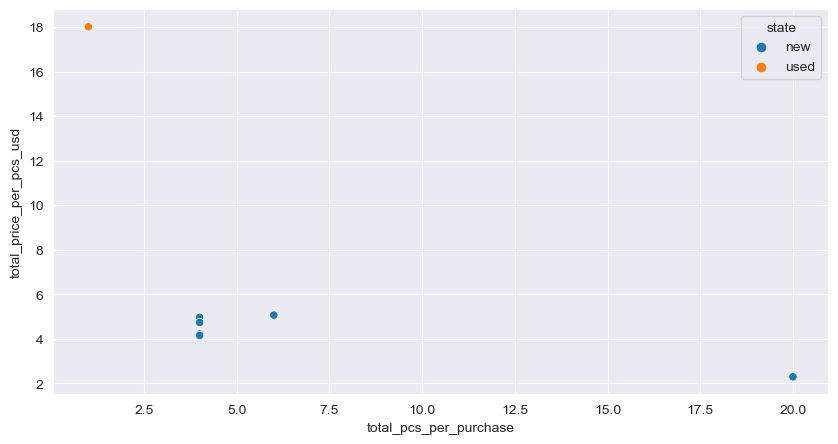

new


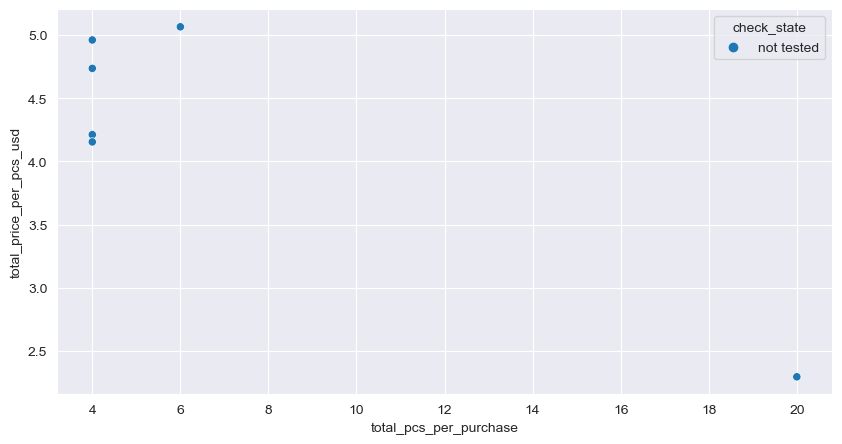

used


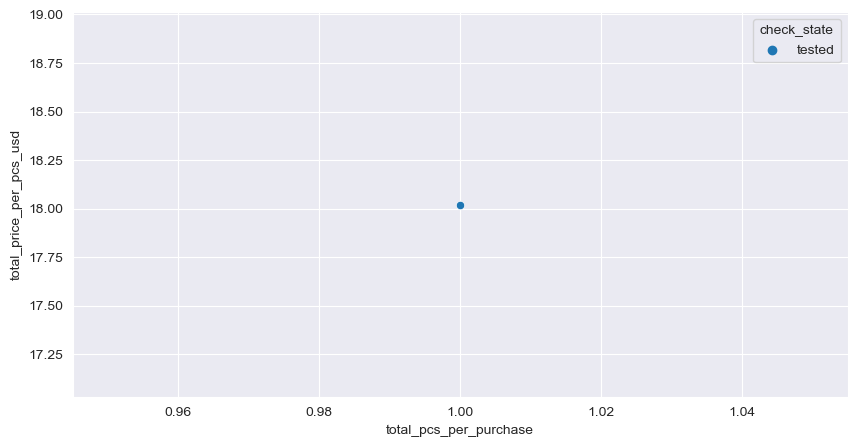


################################################## 6П14П ##################################################
Продано штук:  3355 

Распределение по состоянию (проданных штук): 
newAndMatched        218
newAndTested          66
newNotTested          21
usedAndMatched      1386
usedAndNotTested     619
usedAndTested       1045 

Гистограмма цены для всех категорий:


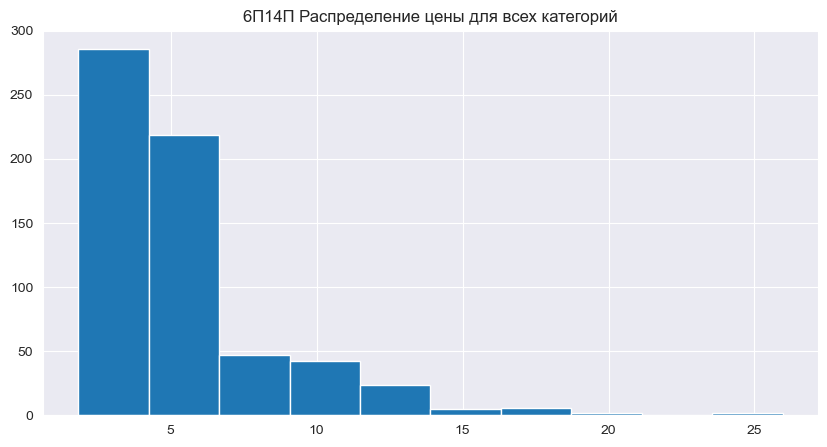

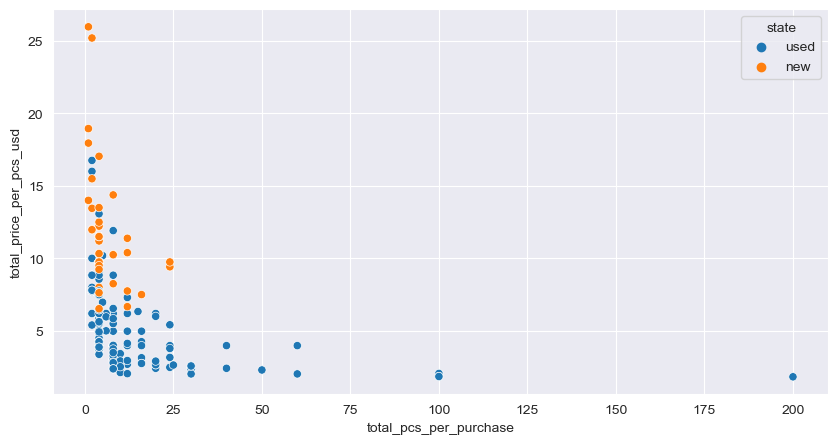

new


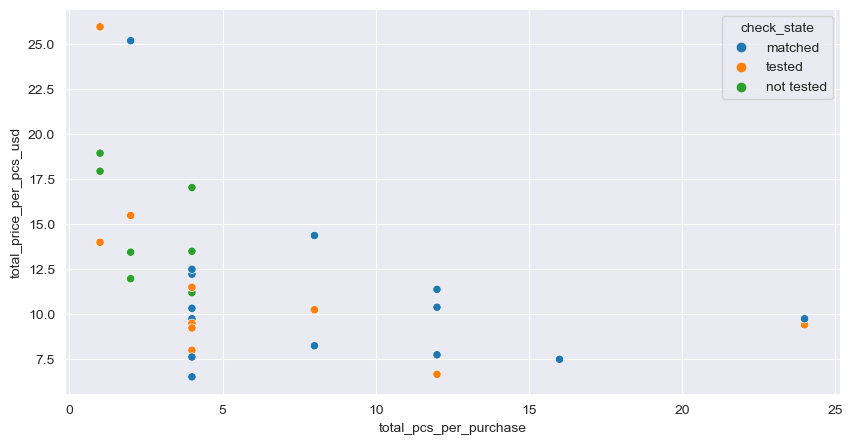

used


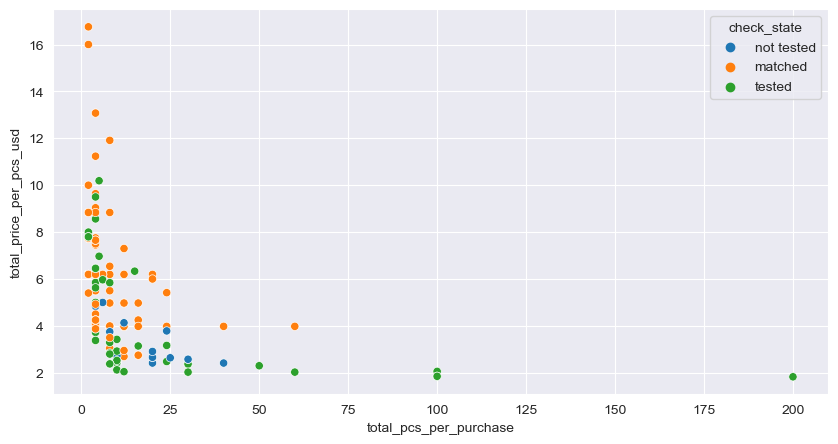


################################################## 6П14П-В ##################################################
Продано штук:  17 

Распределение по состоянию (проданных штук): 
usedAndMatched      4
usedAndNotTested    8
usedAndTested       5 

Гистограмма цены для всех категорий:


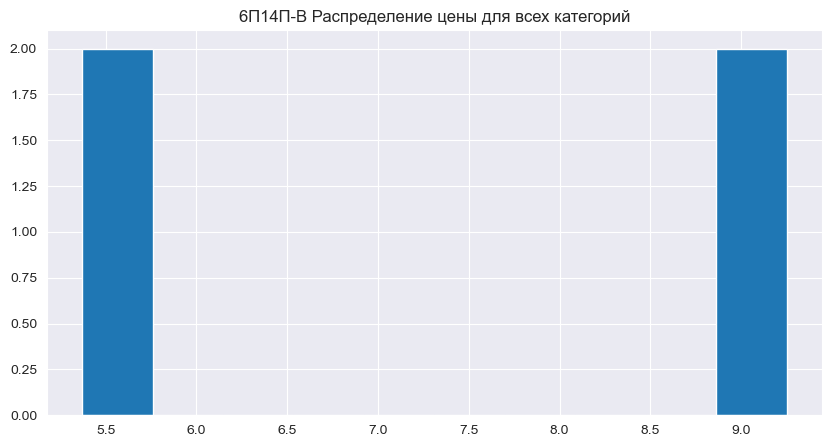

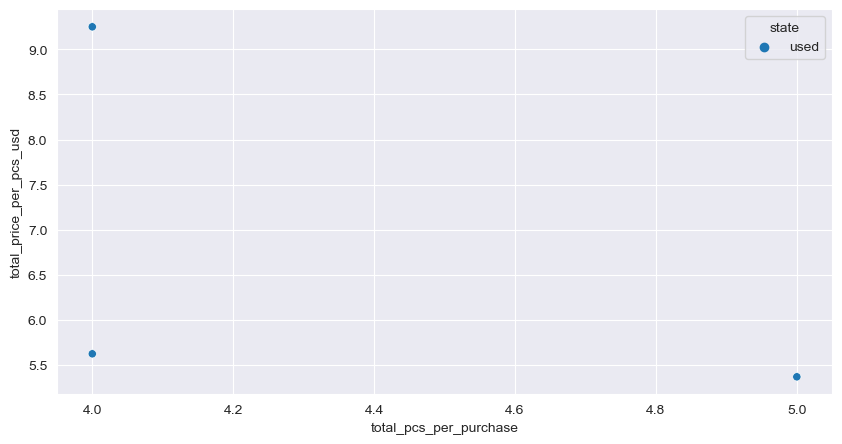

new


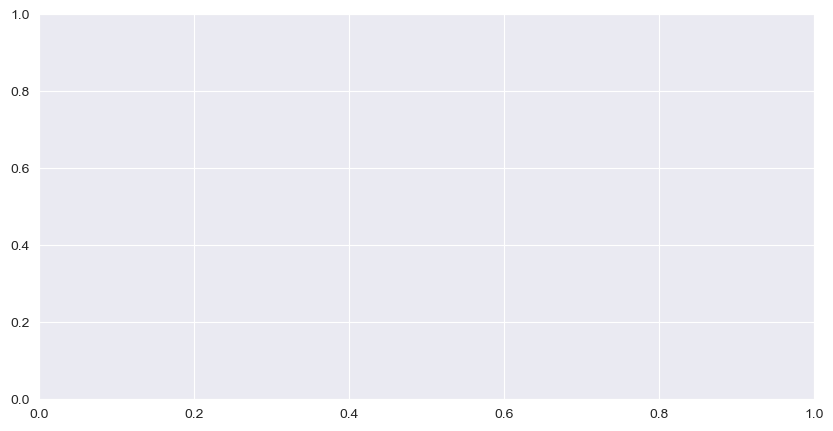

used


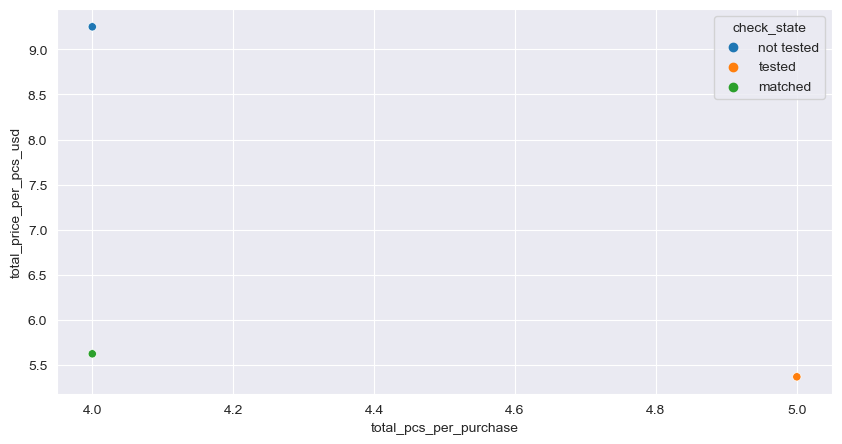


################################################## 6П14П-ЕВ ##################################################
Продано штук:  647 

Распределение по состоянию (проданных штук): 
newAndMatched     202
newAndTested       23
newNotTested       66
usedAndMatched     26
usedAndTested     330 

Гистограмма цены для всех категорий:


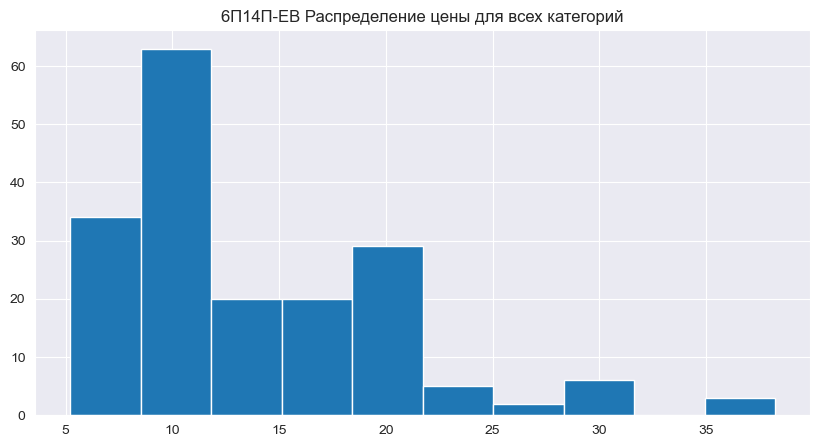

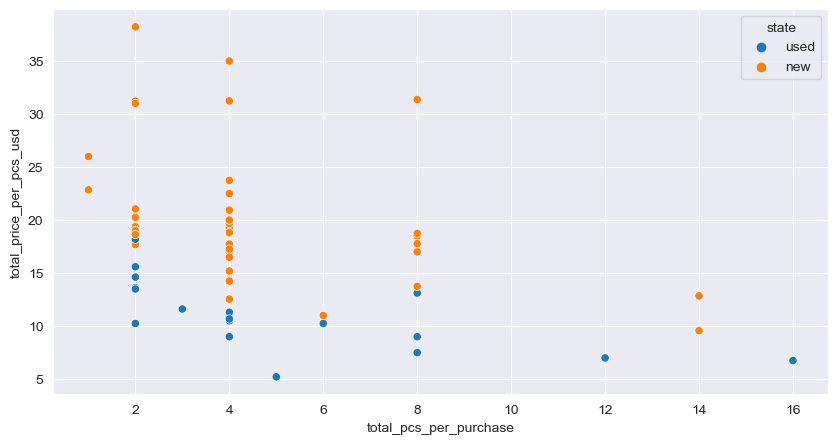

new


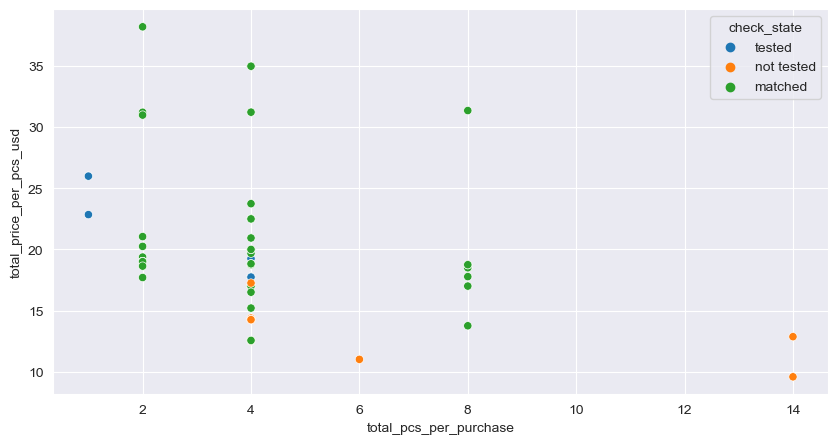

used


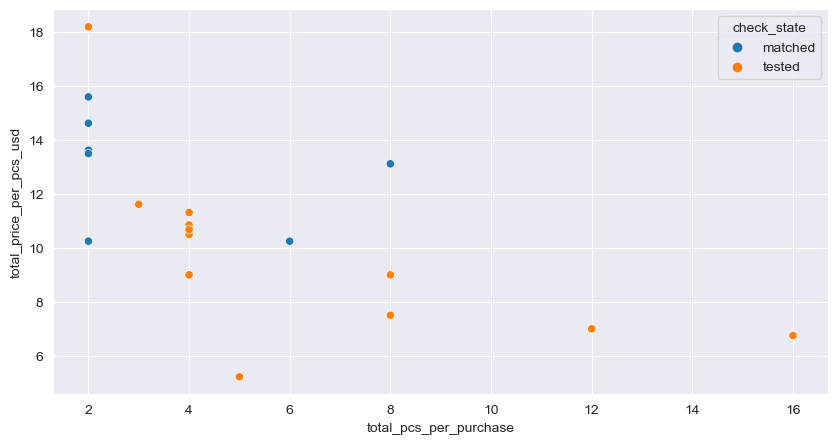


################################################## 6П14П-ЕР ##################################################
Продано штук:  124 

Распределение по состоянию (проданных штук): 
newAndMatched    80
newAndTested     16
newNotTested     28 

Гистограмма цены для всех категорий:


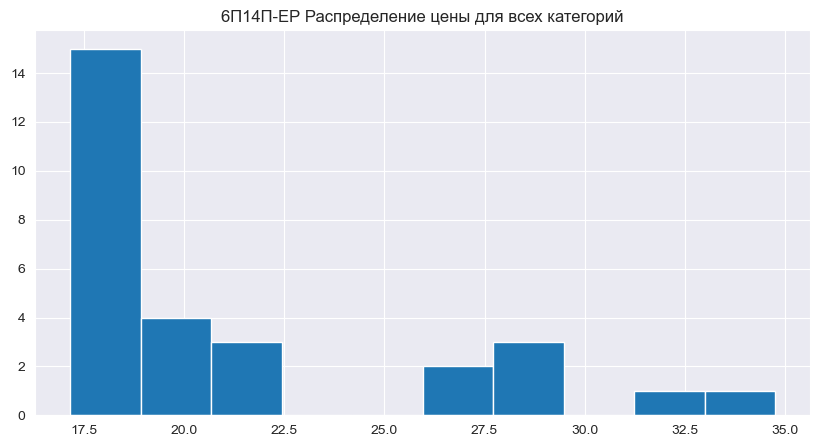

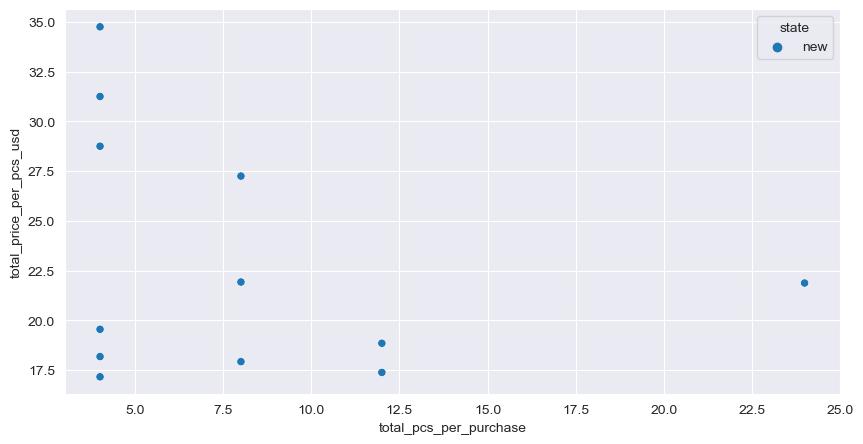

new


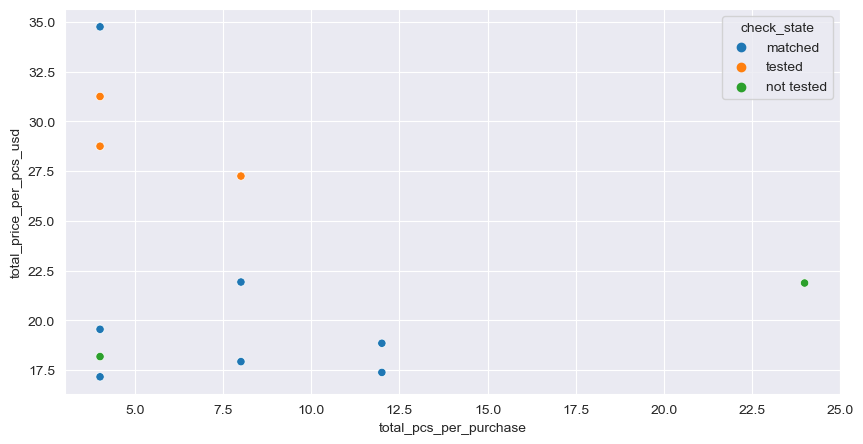

used


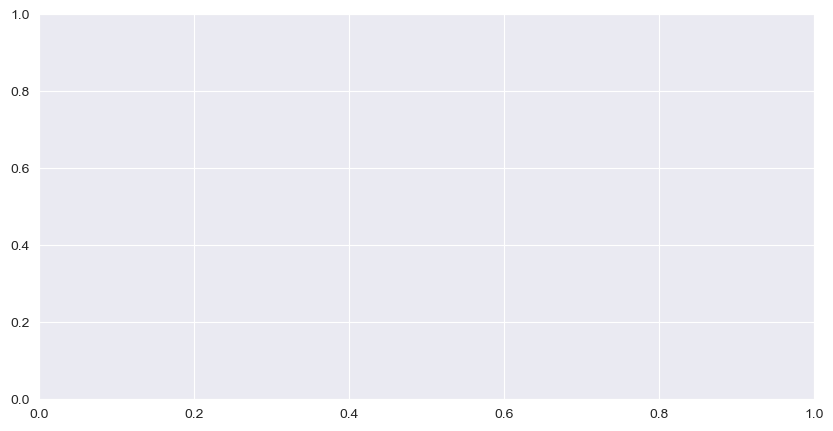


################################################## 6П14П-К ##################################################
Продано штук:  693 

Распределение по состоянию (проданных штук): 
newAndMatched        70
newAndTested         24
usedAndMatched      480
usedAndNotTested     24
usedAndTested        95 

Гистограмма цены для всех категорий:


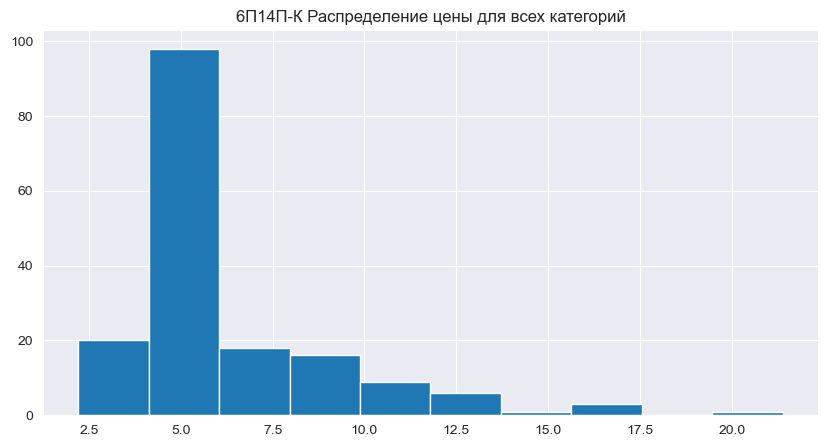

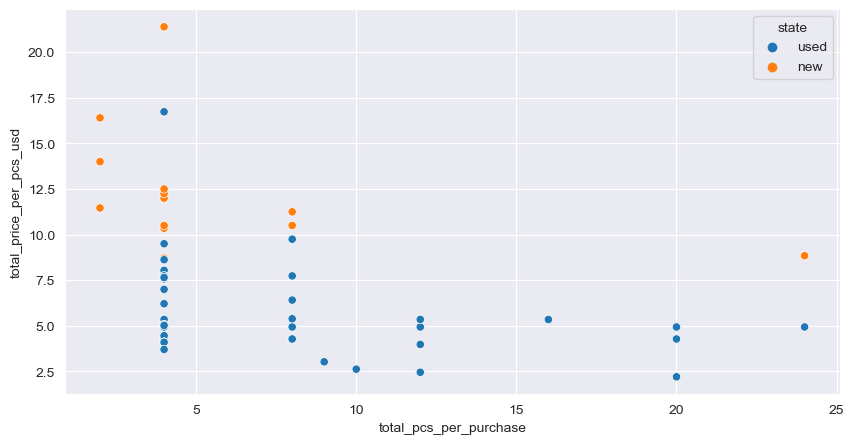

new


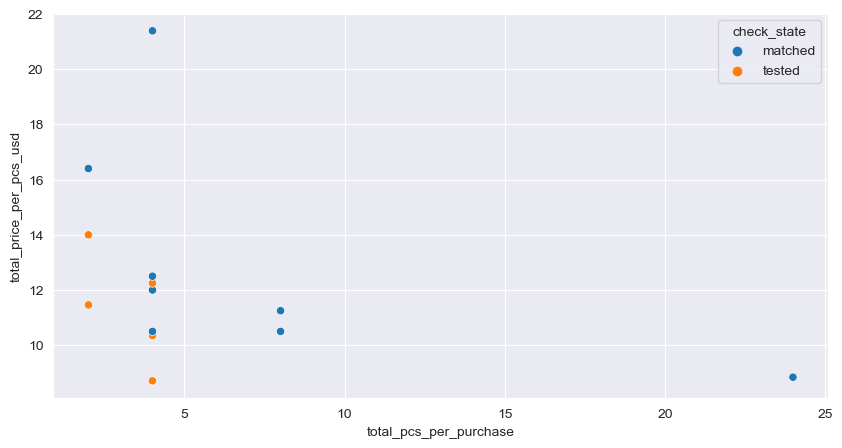

used


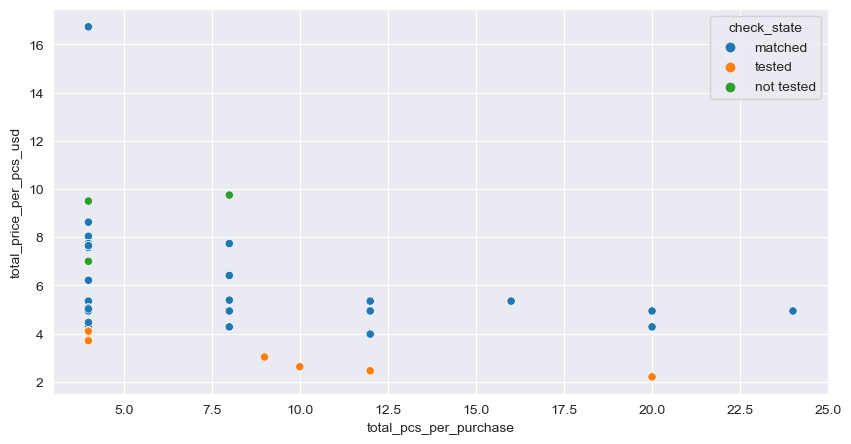


################################################## 6П15П ##################################################
Продано штук:  434 

Распределение по состоянию (проданных штук): 
newAndMatched        70
newNotTested        102
usedAndNotTested    210
usedAndTested        52 

Гистограмма цены для всех категорий:


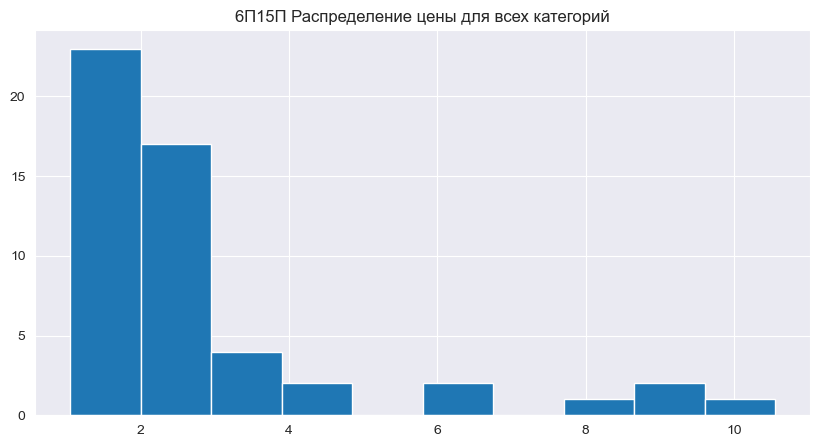

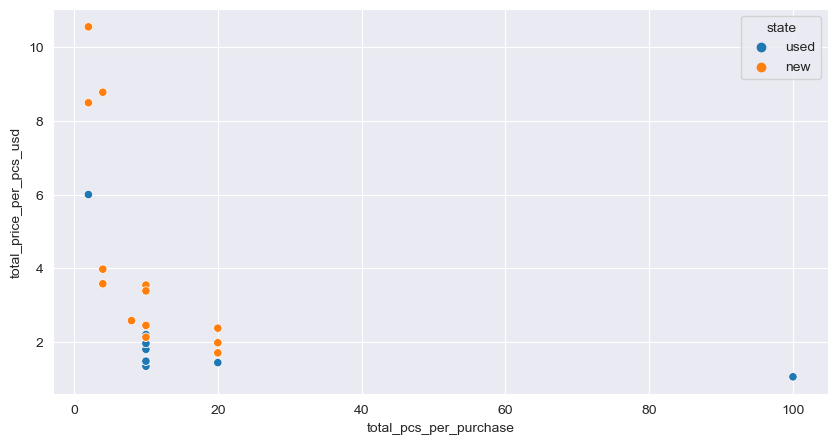

new


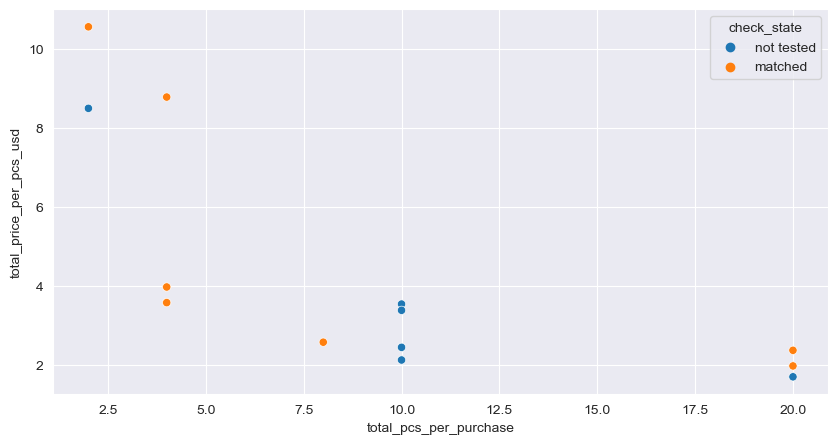

used


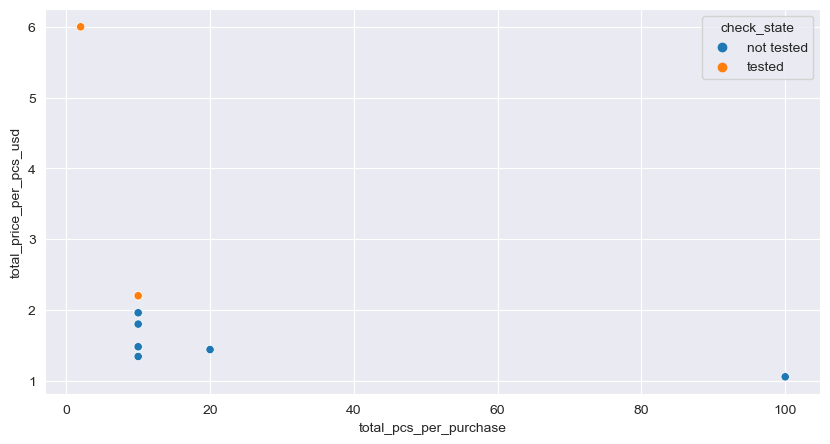


################################################## 6П15П-ЕВ ##################################################
Продано штук:  1084 

Распределение по состоянию (проданных штук): 
newAndMatched         18
newAndTested           8
newNotTested        1042
usedAndNotTested      16 

Гистограмма цены для всех категорий:


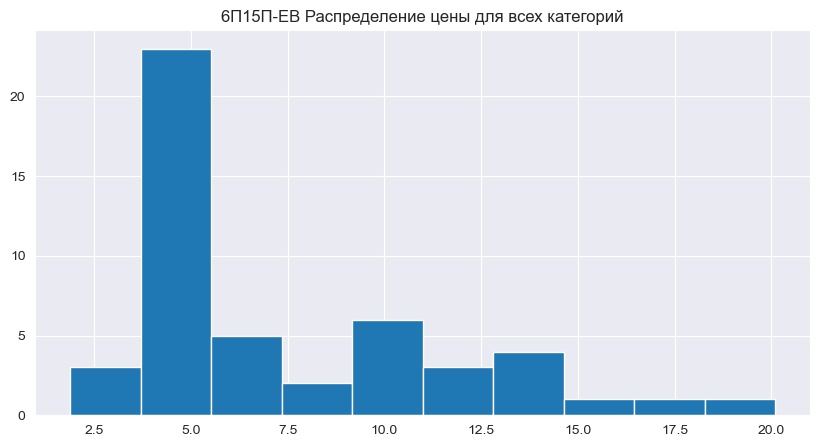

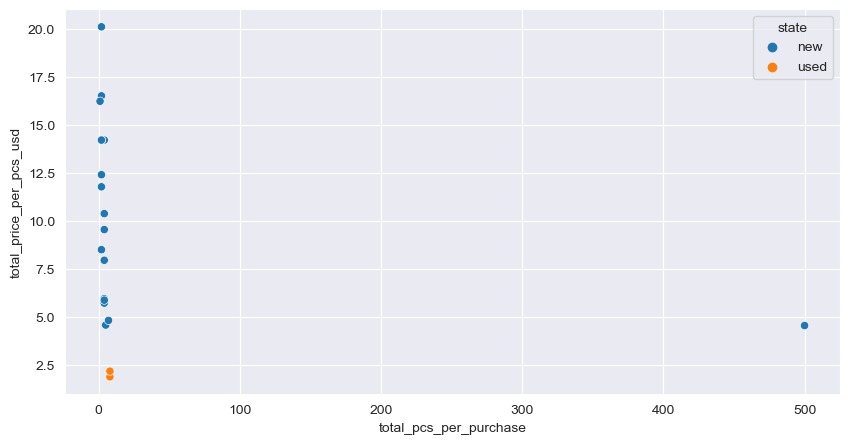

new


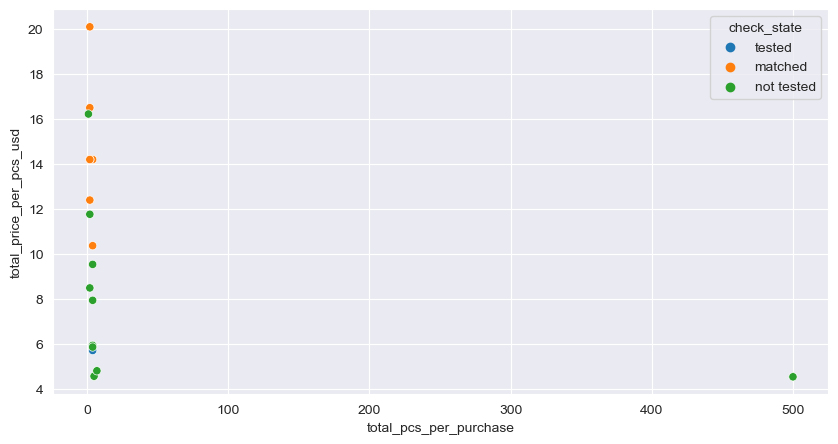

used


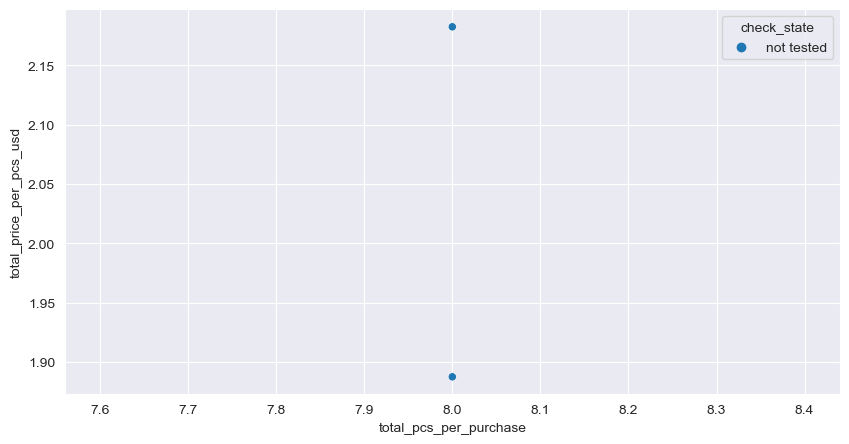


################################################## 6П15П-ЕР ##################################################
Продано штук:  36 

Распределение по состоянию (проданных штук): 
newAndMatched    24
newNotTested     12 

Гистограмма цены для всех категорий:


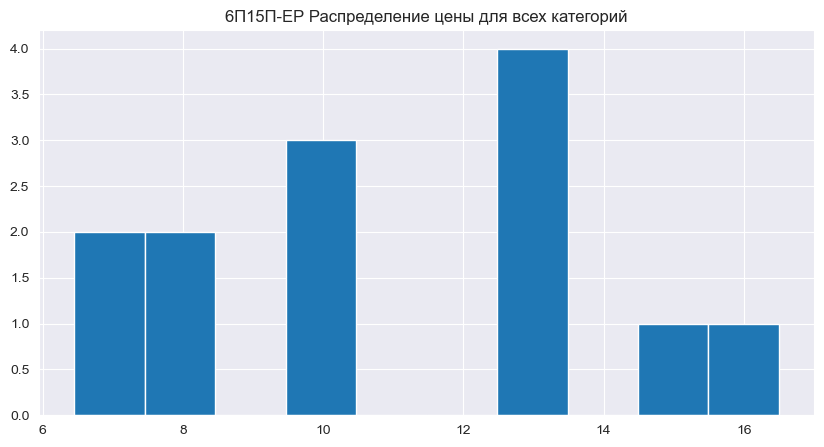

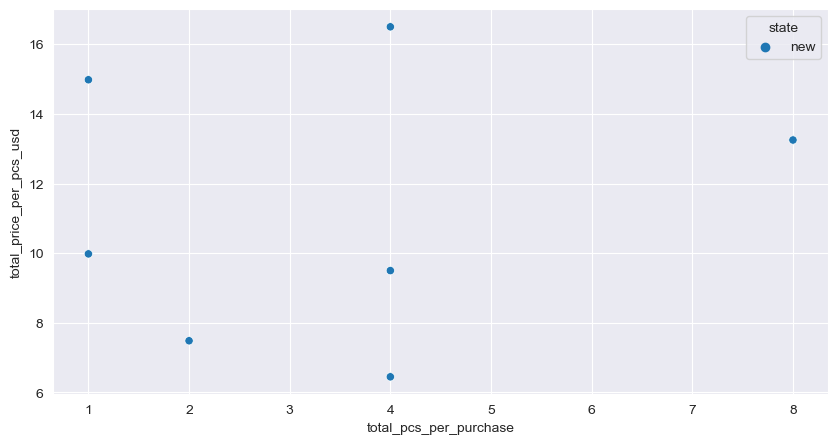

new


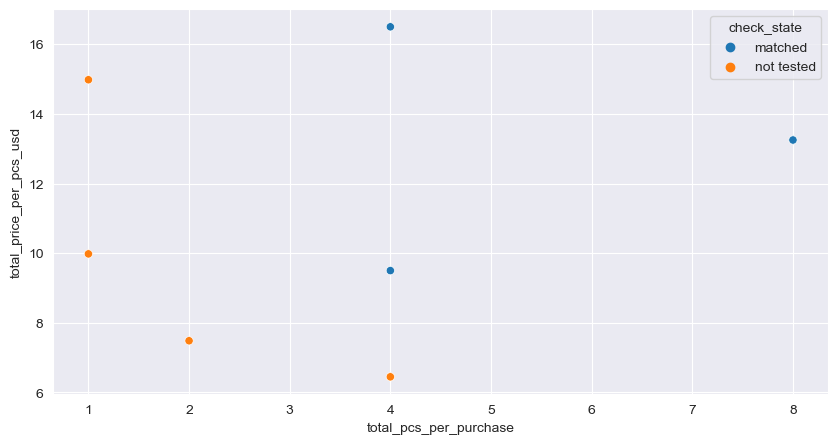

used


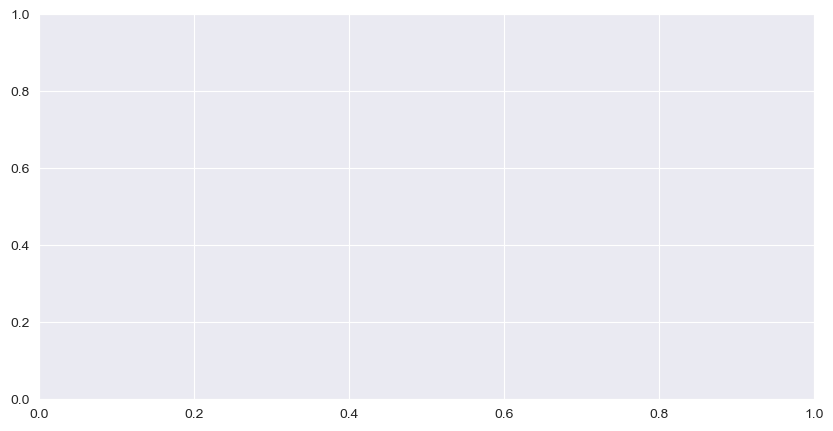


################################################## 6П1П ##################################################
Продано штук:  145 

Распределение по состоянию (проданных штук): 
newAndMatched       84
newNotTested        45
usedAndNotTested     8
usedAndTested        8 

Гистограмма цены для всех категорий:


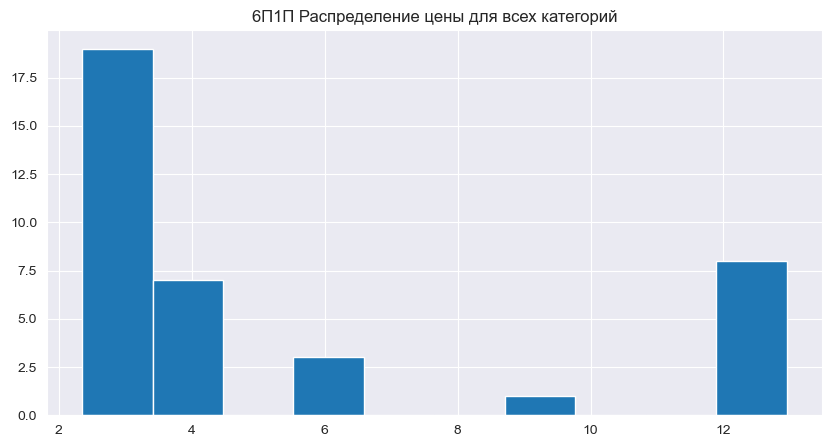

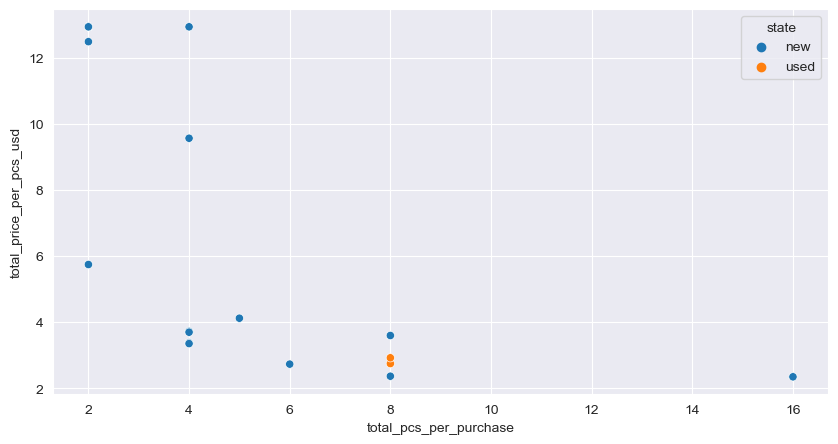

new


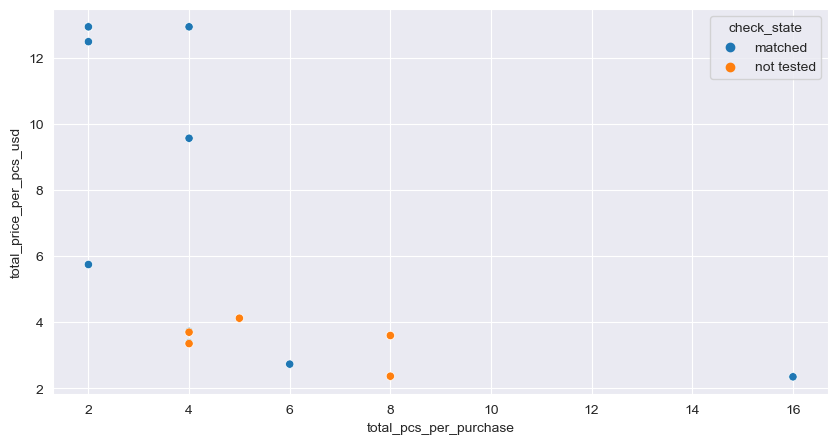

used


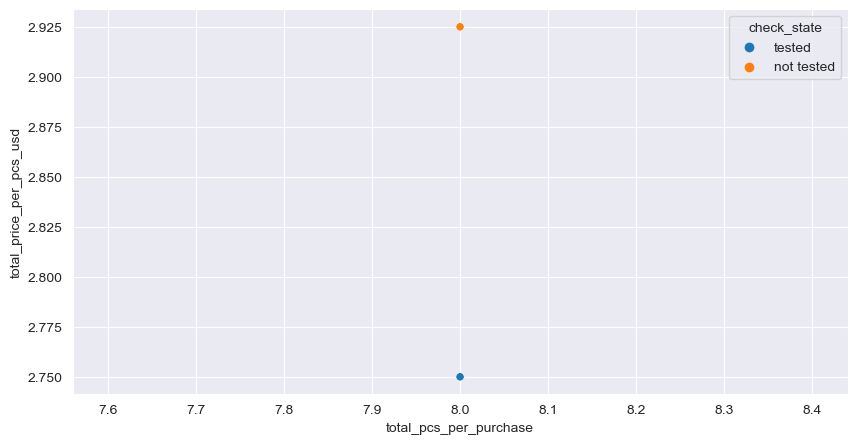


################################################## 6П1П-В ##################################################
Продано штук:  8 

Распределение по состоянию (проданных штук): 
newAndMatched    8 

Гистограмма цены для всех категорий:


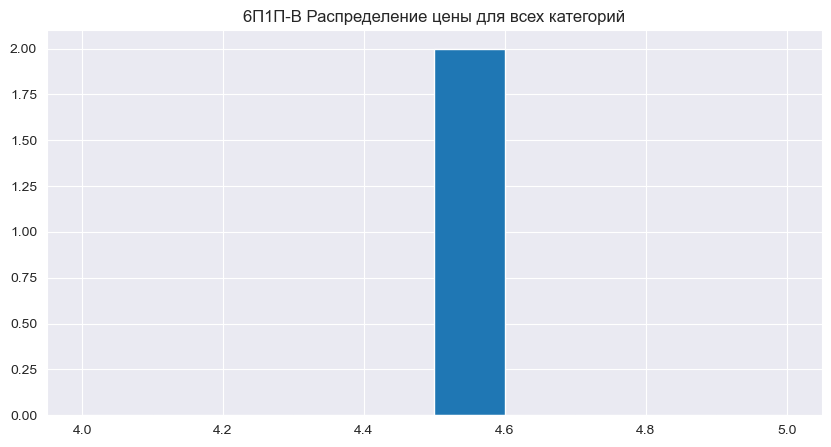

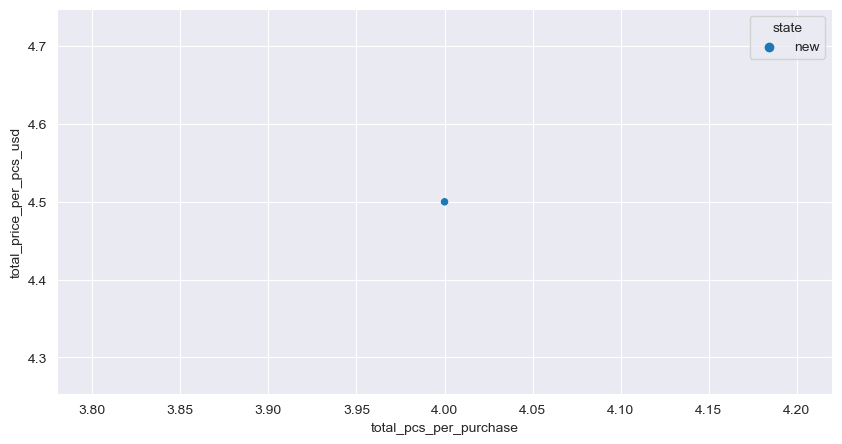

new


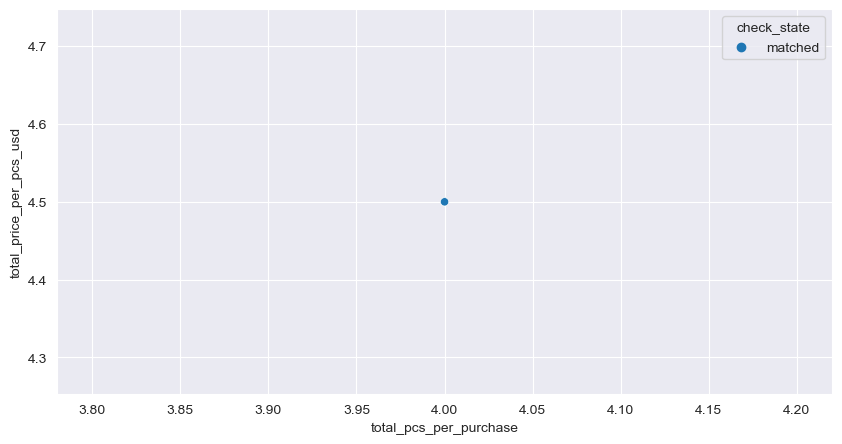

used


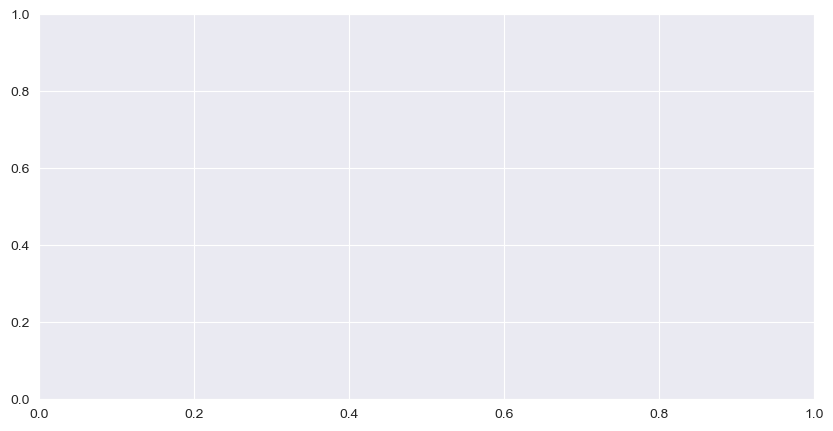


################################################## 6П1П-Е ##################################################
Продано штук:  8 

Распределение по состоянию (проданных штук): 
newNotTested    8 

Гистограмма цены для всех категорий:


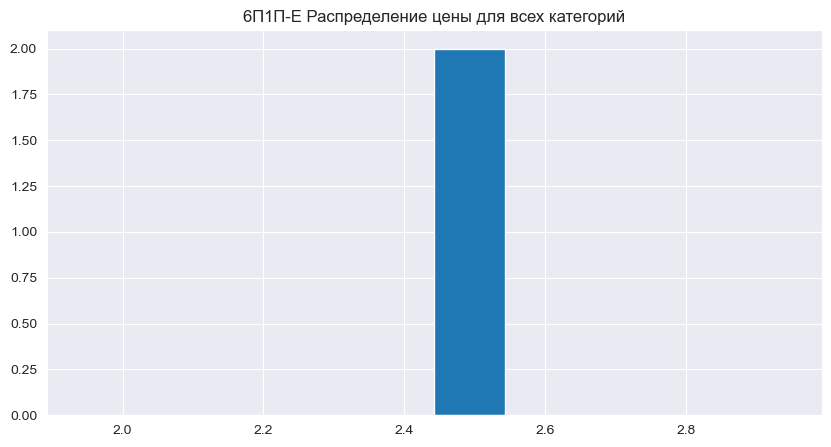

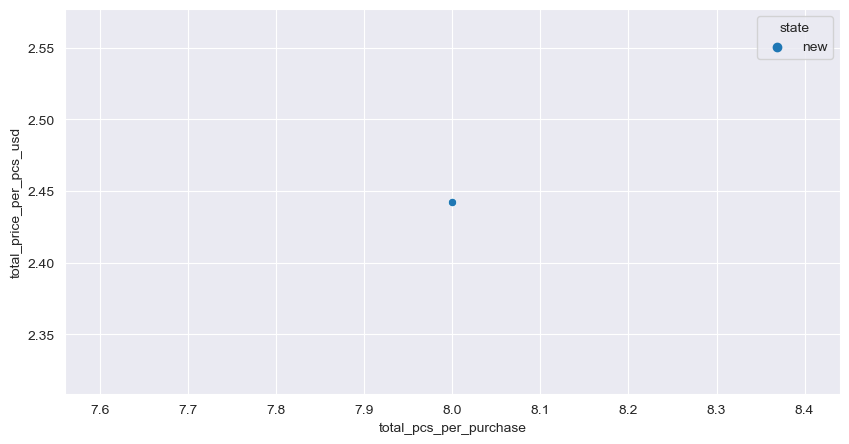

new


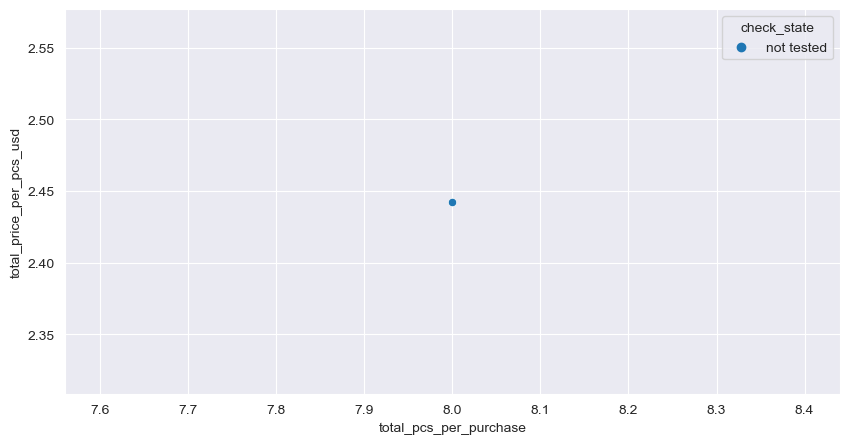

used


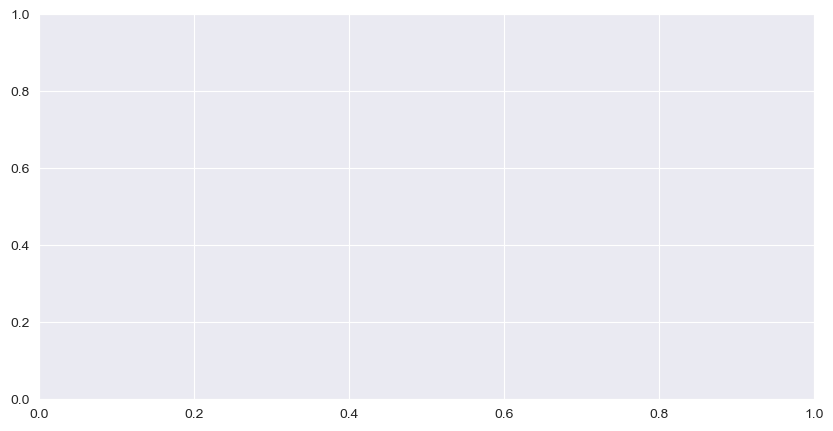


################################################## 6П1П-ЕВ ##################################################
Продано штук:  589 

Распределение по состоянию (проданных штук): 
newAndMatched     66
newNotTested     523 

Гистограмма цены для всех категорий:


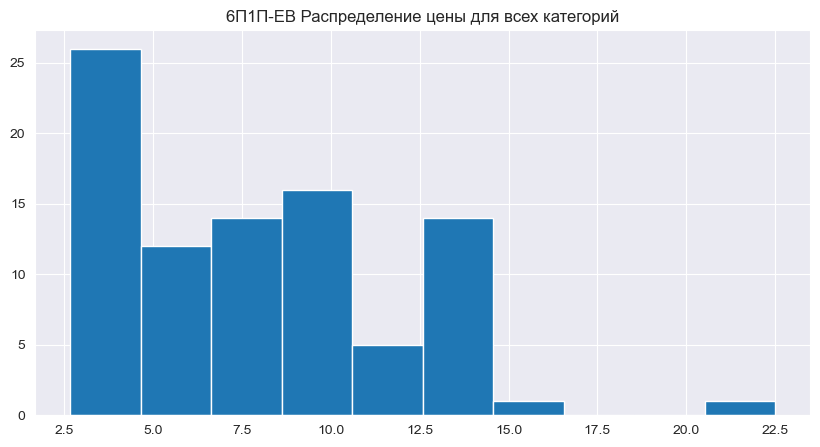

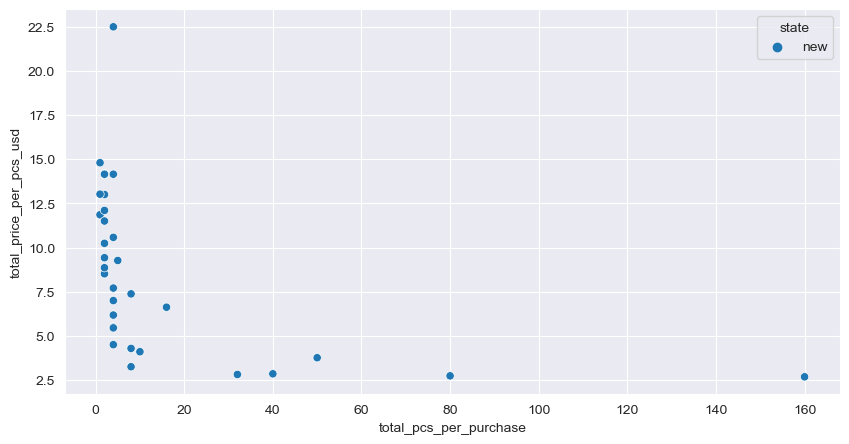

new


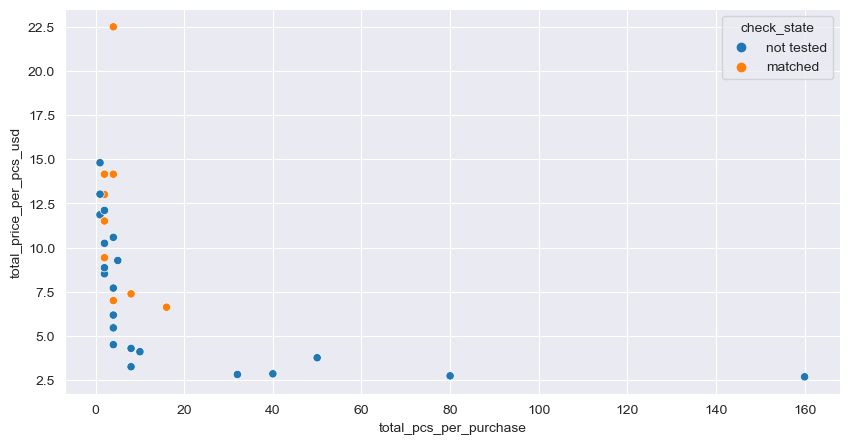

used


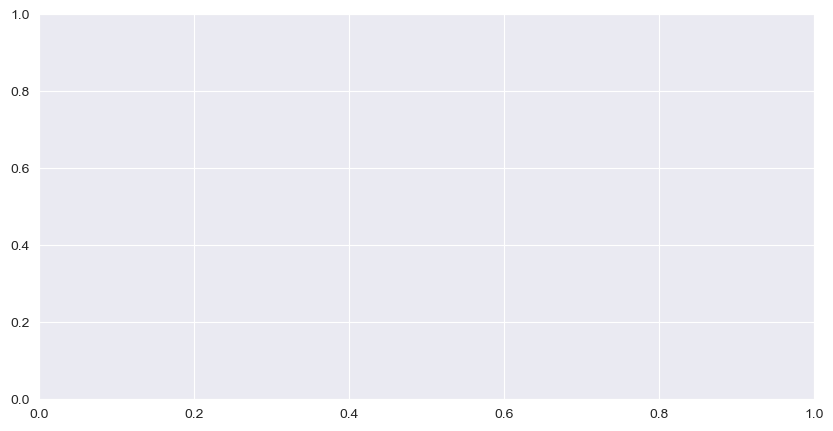


################################################## 6П21С ##################################################
Продано штук:  14 

Распределение по состоянию (проданных штук): 
newAndTested     2
newNotTested    12 

Гистограмма цены для всех категорий:


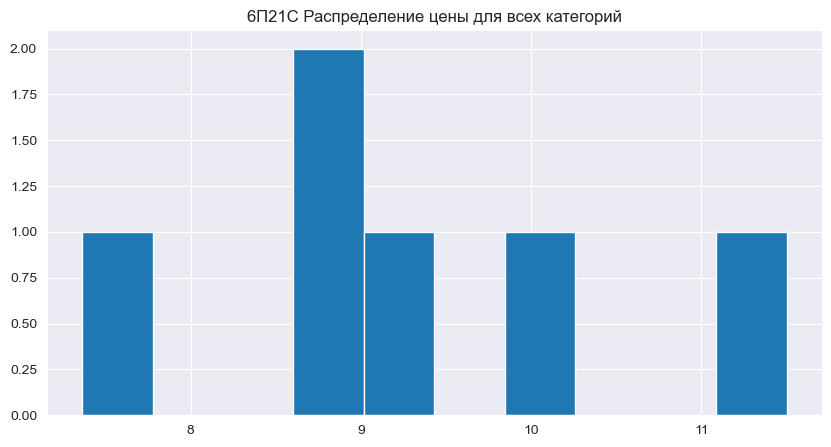

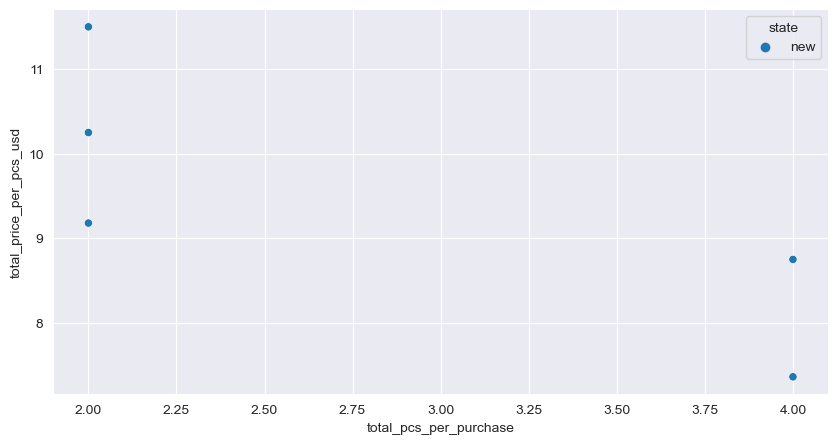

new


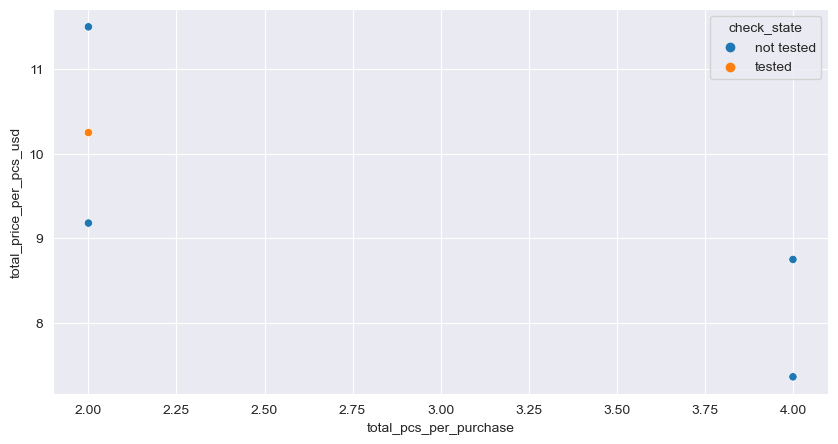

used


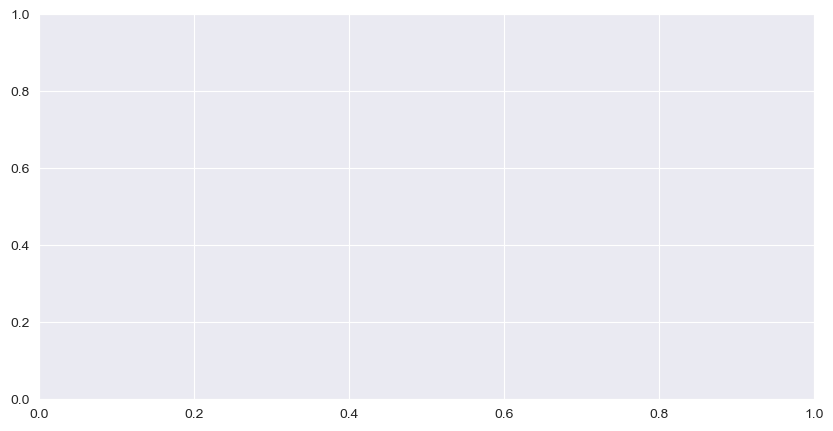


################################################## 6П7С ##################################################
Продано штук:  39 

Распределение по состоянию (проданных штук): 
newAndMatched     2
newNotTested     37 

Гистограмма цены для всех категорий:


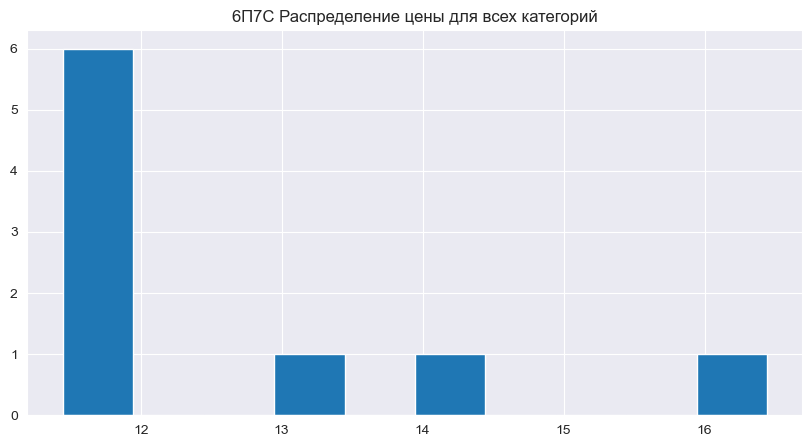

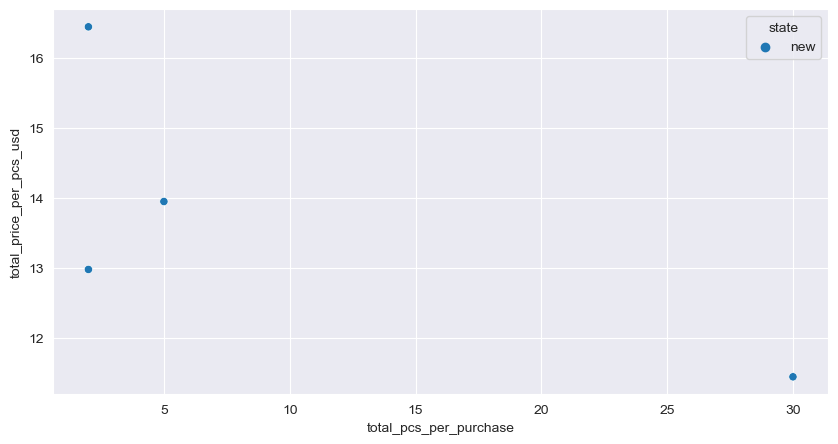

new


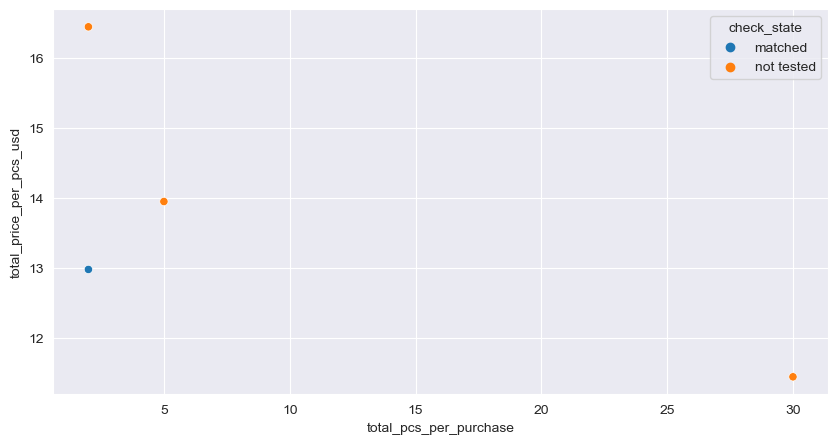

used


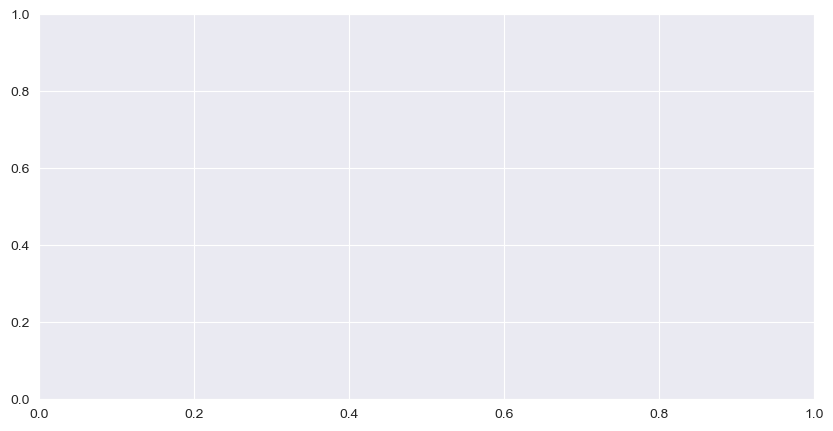


################################################## 6С19П ##################################################
Продано штук:  72 

Распределение по состоянию (проданных штук): 
newAndMatched     6
newNotTested     66 

Гистограмма цены для всех категорий:


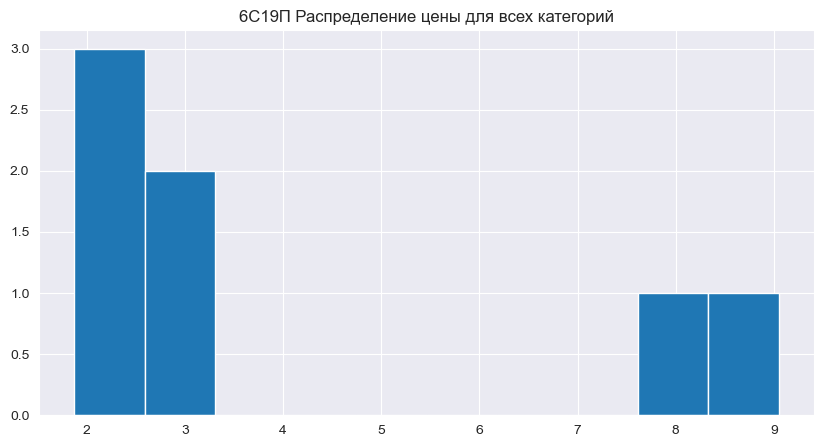

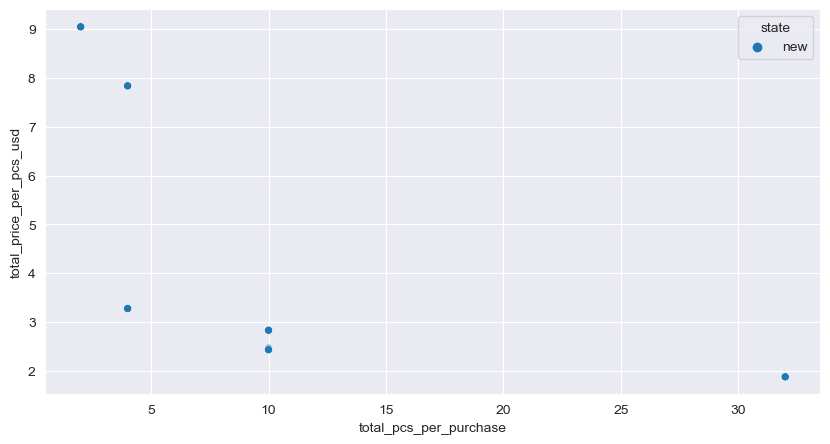

new


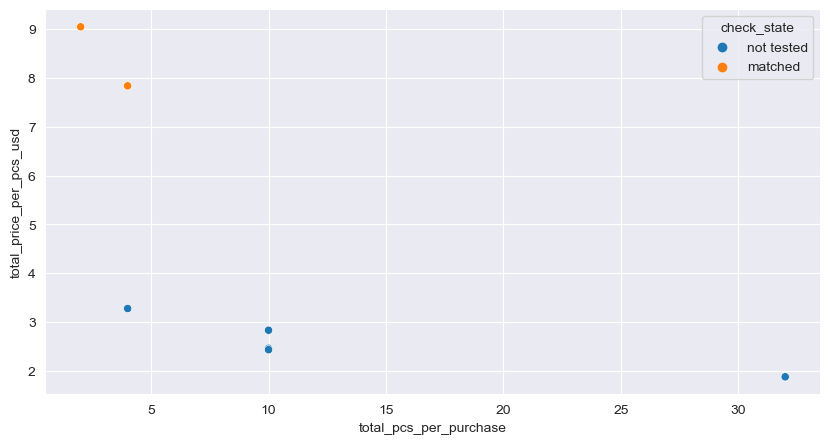

used


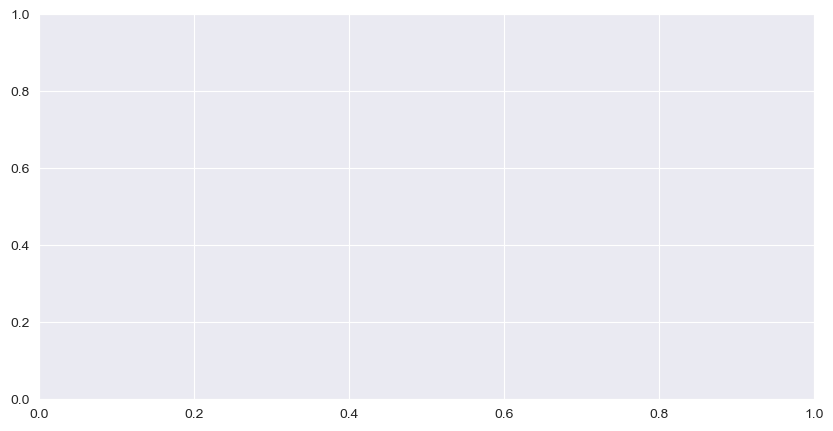


################################################## 6С19П-В ##################################################
Продано штук:  83 

Распределение по состоянию (проданных штук): 
newAndTested     4
newNotTested    79 

Гистограмма цены для всех категорий:


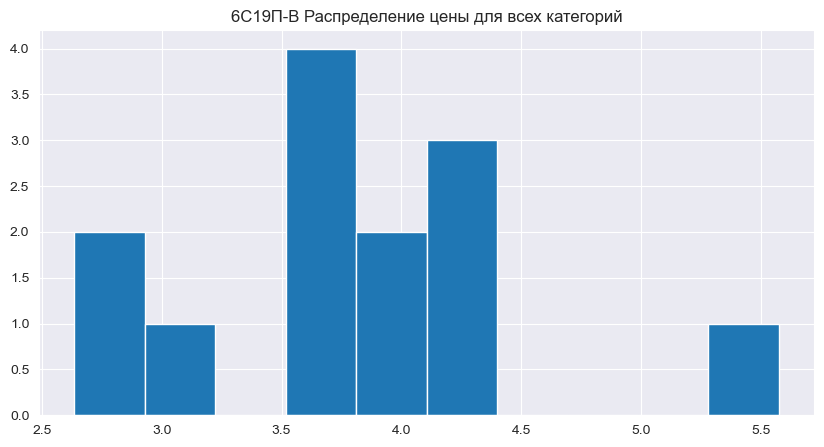

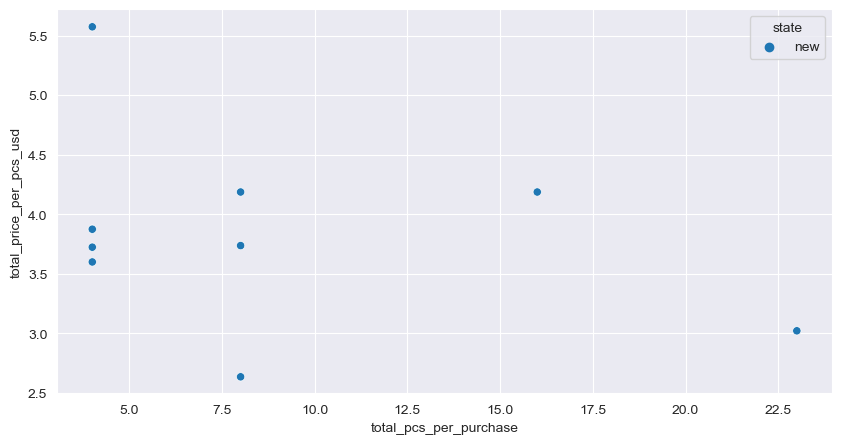

new


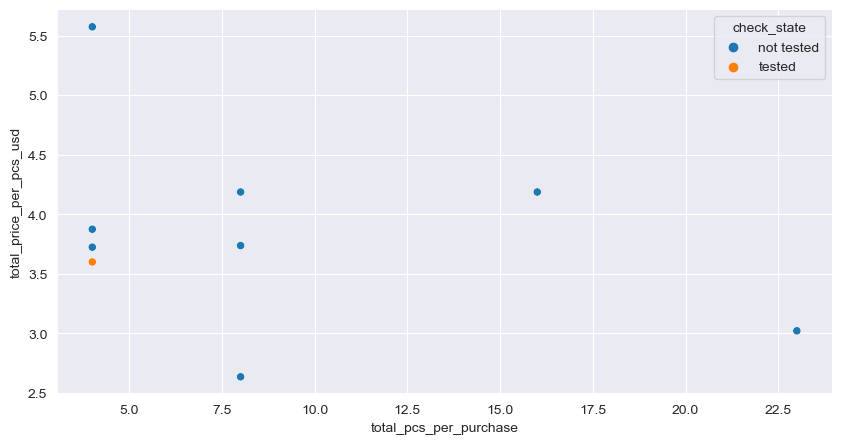

used


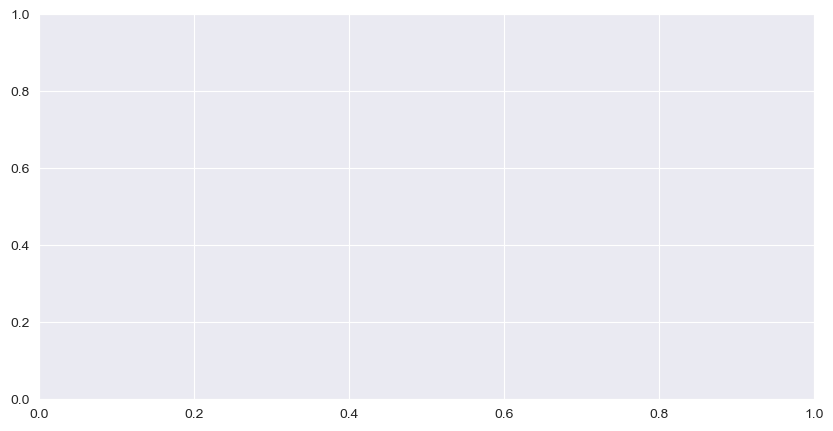


################################################## 6С19П-ВР ##################################################
Продано штук:  8 

Распределение по состоянию (проданных штук): 
newNotTested    8 

Гистограмма цены для всех категорий:


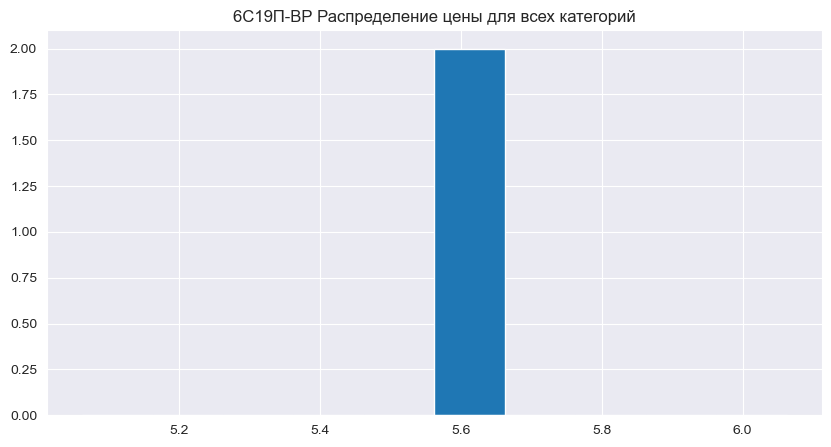

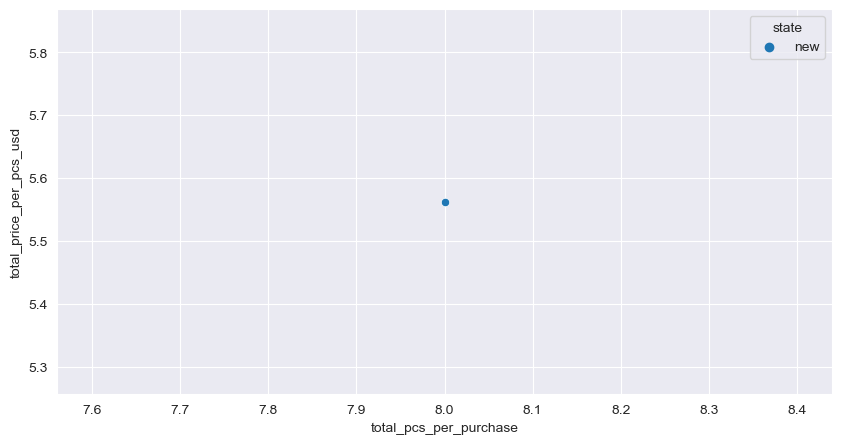

new


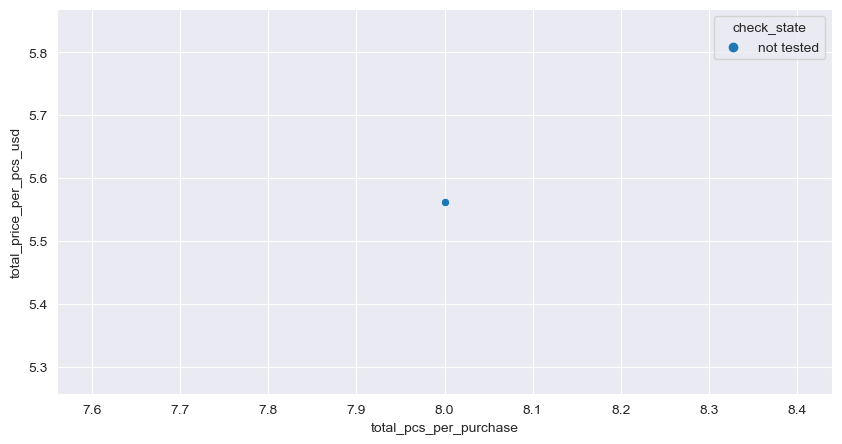

used


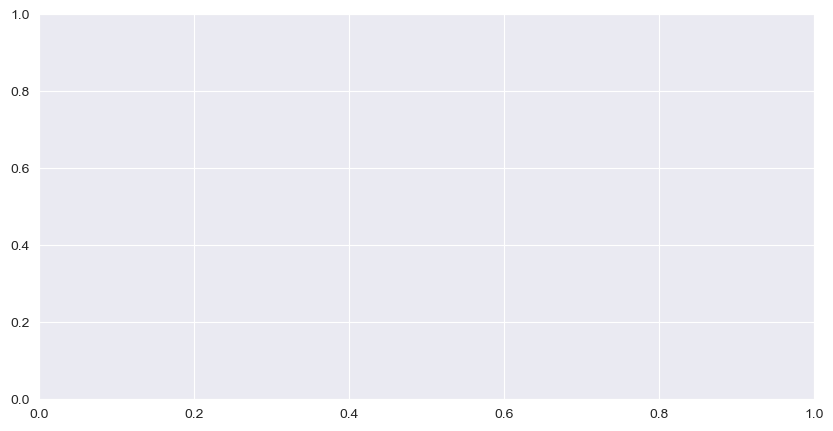


################################################## 6С1П ##################################################
Продано штук:  10 

Распределение по состоянию (проданных штук): 
newNotTested    10 

Гистограмма цены для всех категорий:


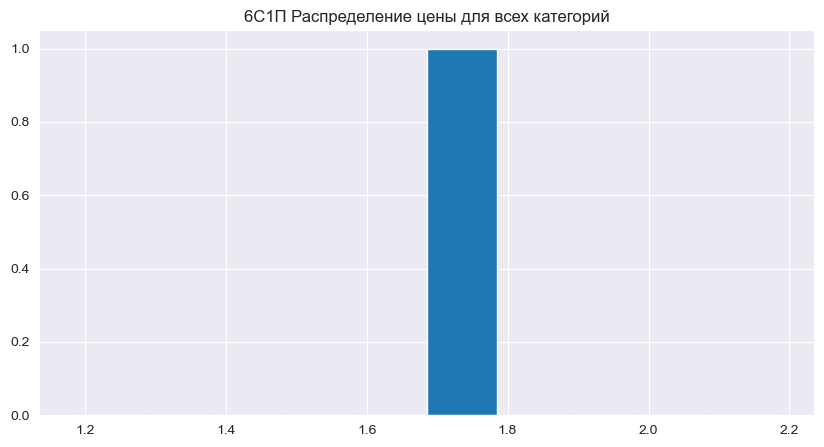

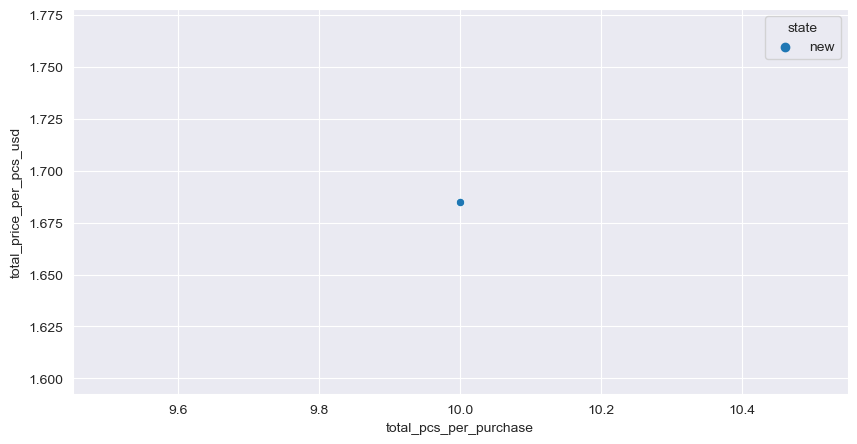

new


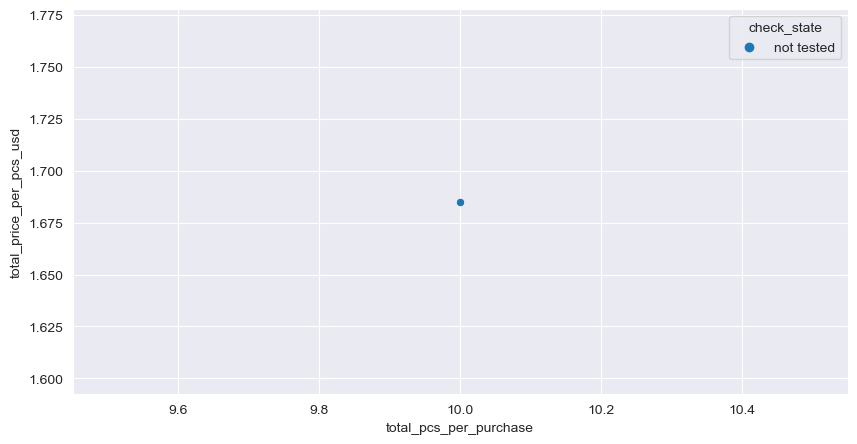

used


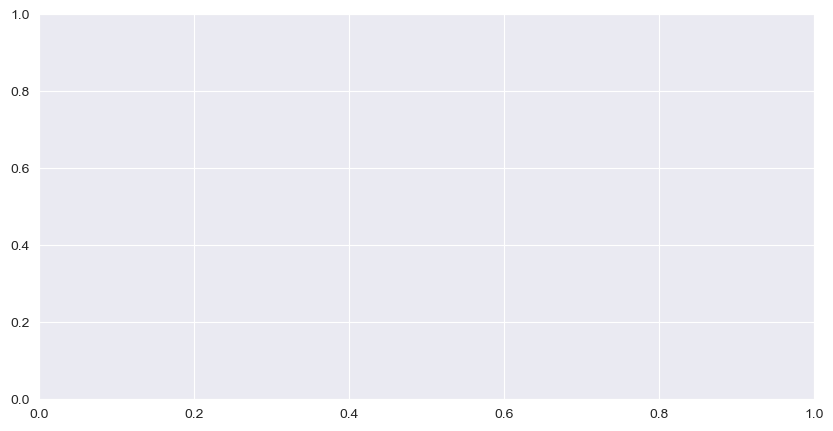


################################################## 6С2П ##################################################
Продано штук:  14 

Распределение по состоянию (проданных штук): 
newNotTested    14 

Гистограмма цены для всех категорий:


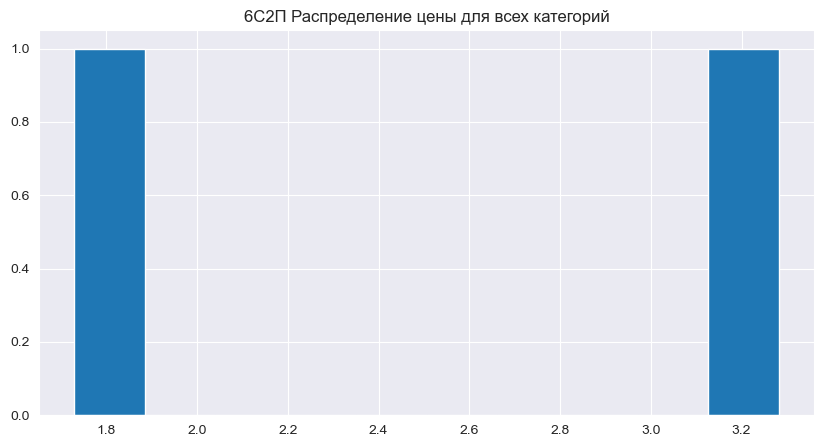

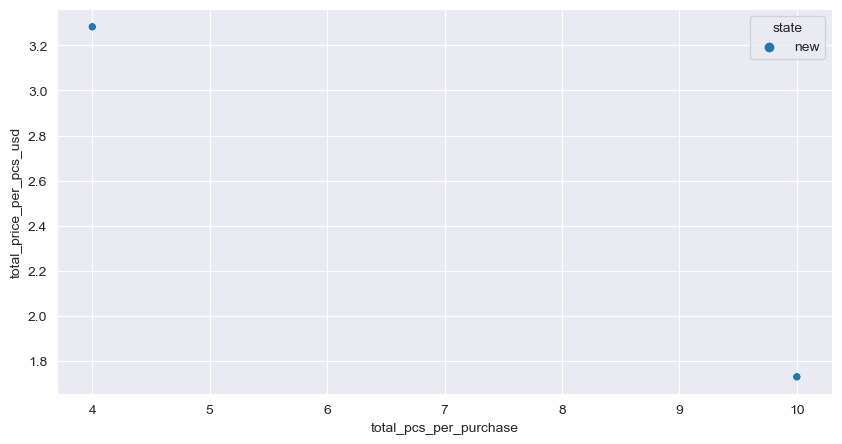

new


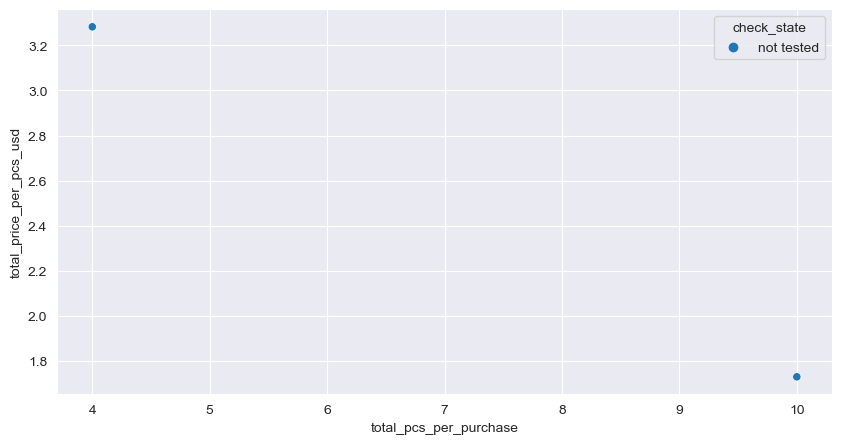

used


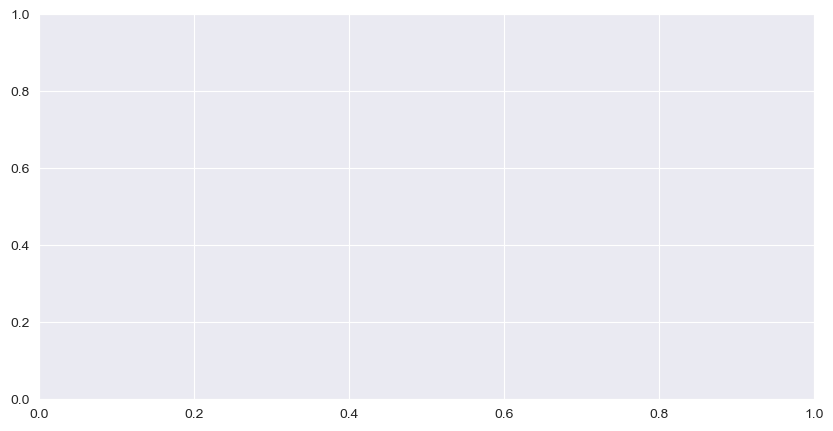


################################################## 6С32Б ##################################################
Продано штук:  12 

Распределение по состоянию (проданных штук): 
newNotTested    12 

Гистограмма цены для всех категорий:


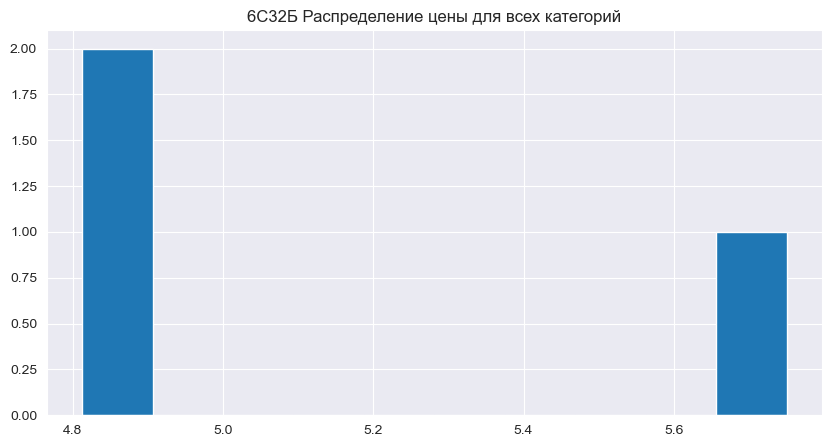

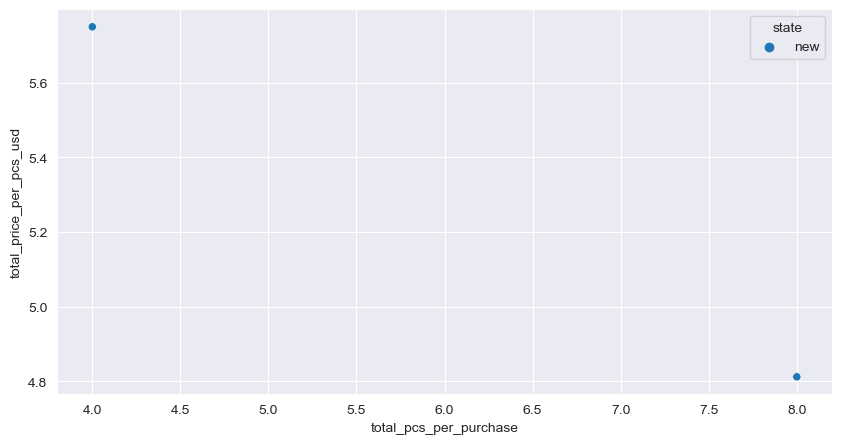

new


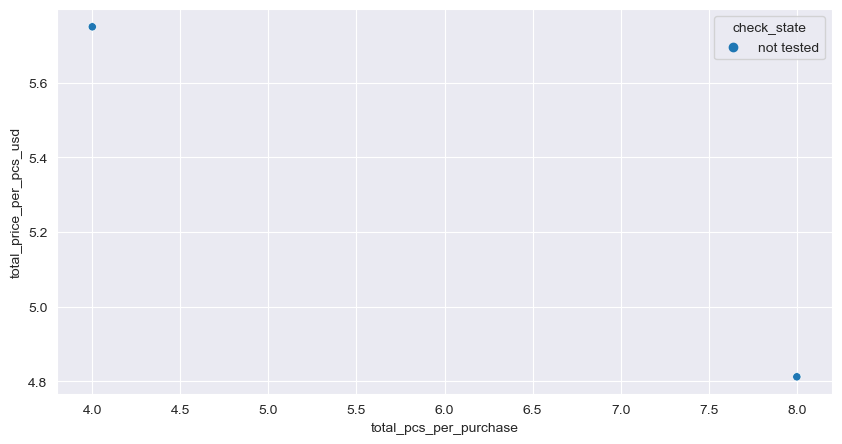

used


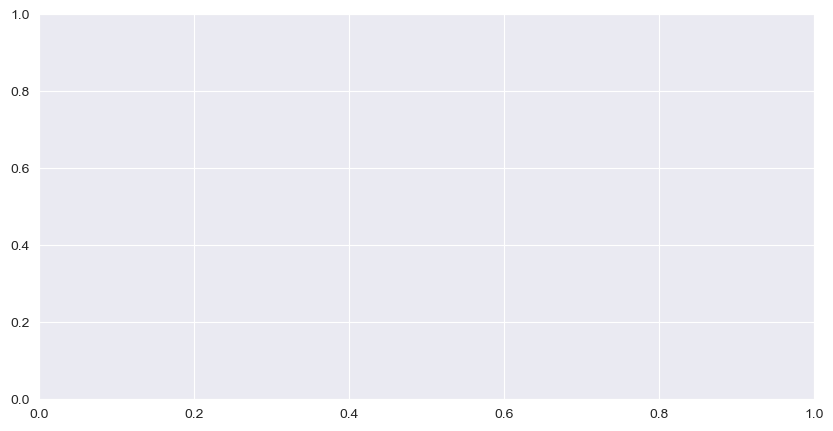


################################################## 6С4П-Е ##################################################
Нет продаж для лота 

################################################## 6С4П-ЕВ ##################################################
Продано штук:  32 

Распределение по состоянию (проданных штук): 
newAndTested     8
newNotTested    24 

Гистограмма цены для всех категорий:


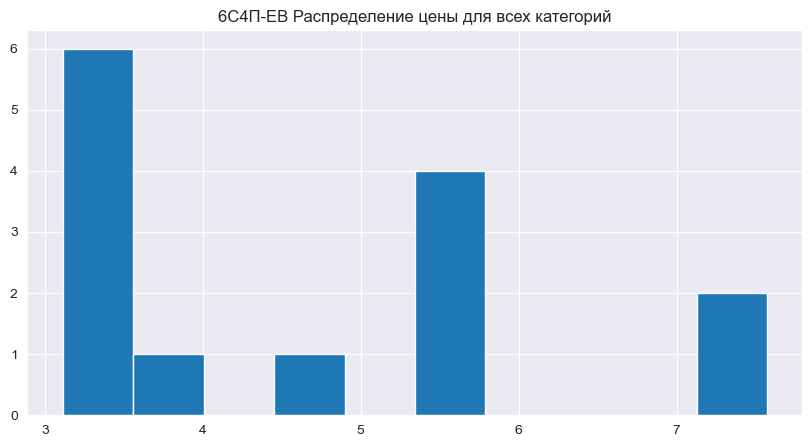

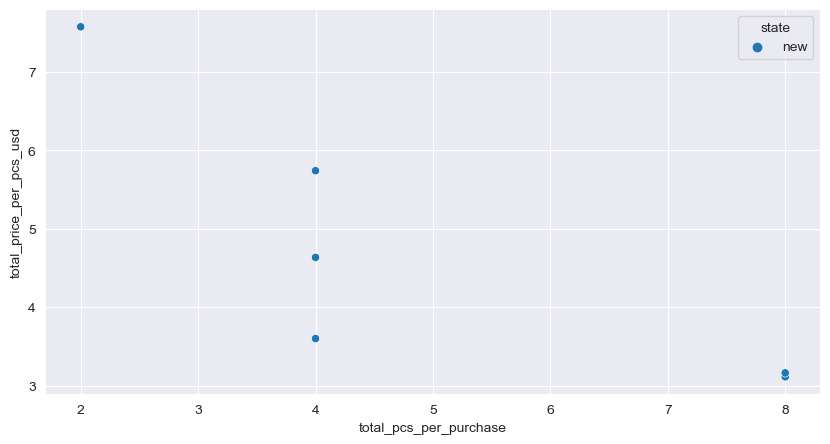

new


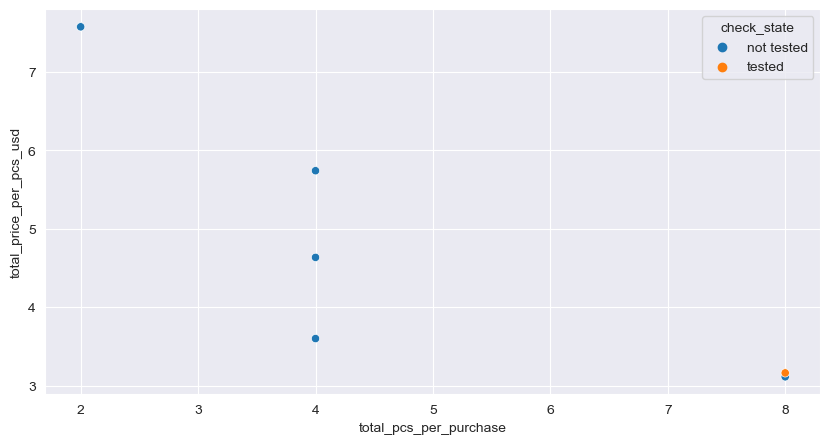

used


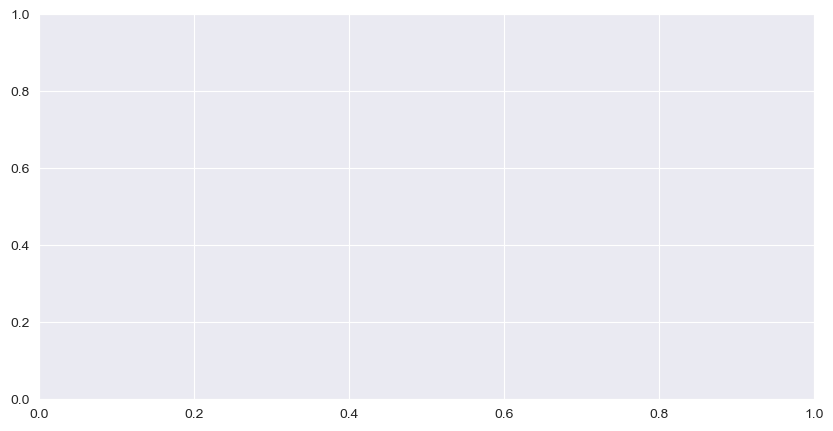


################################################## 6С51Н-В ##################################################
Продано штук:  26 

Распределение по состоянию (проданных штук): 
newNotTested    26 

Гистограмма цены для всех категорий:


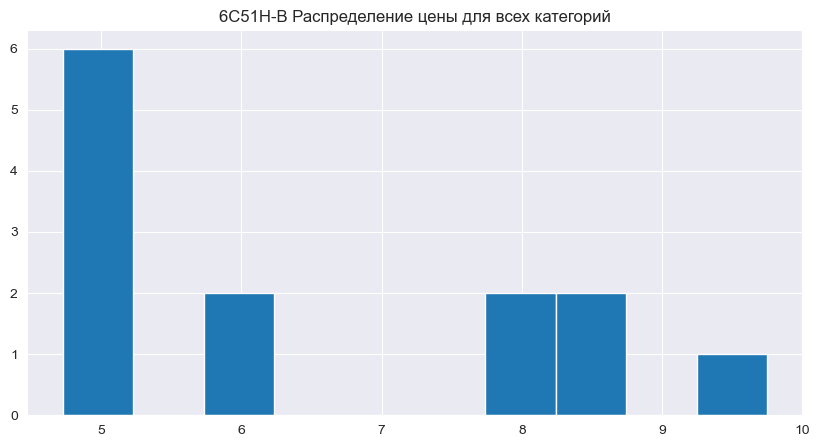

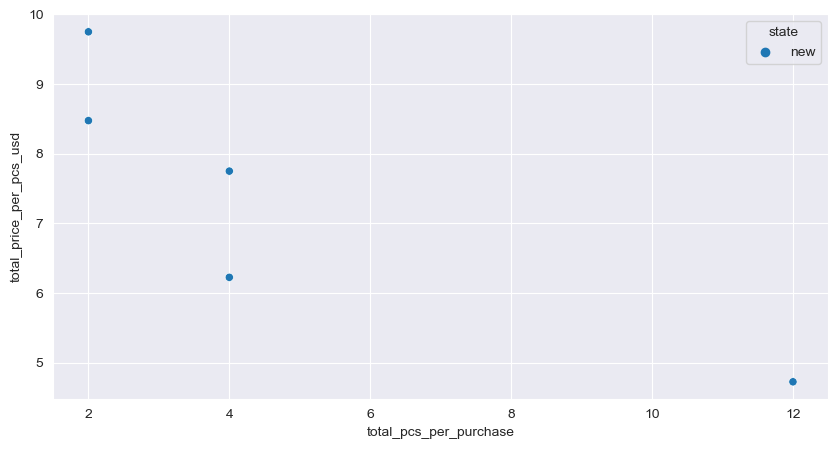

new


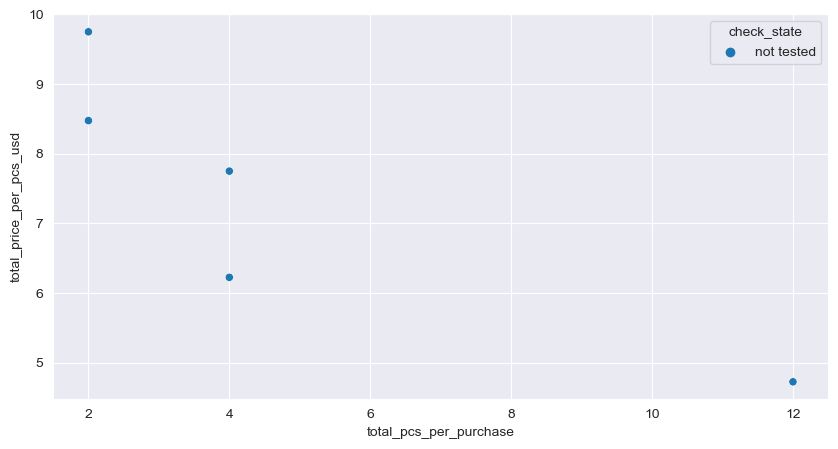

used


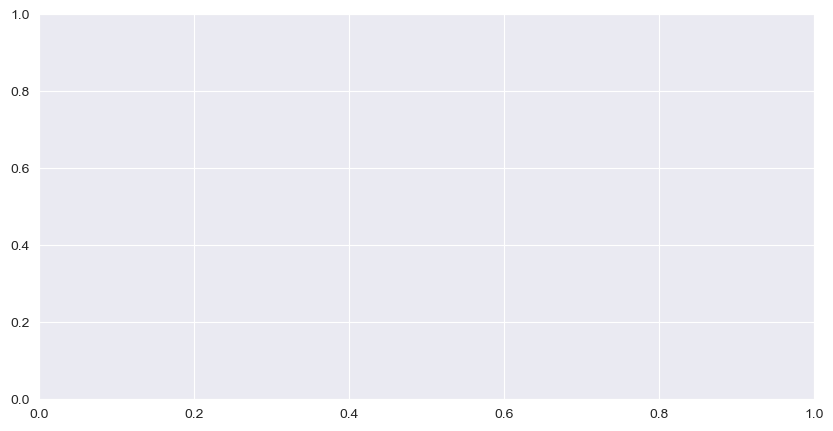


################################################## 6С52Н-В ##################################################
Продано штук:  52 

Распределение по состоянию (проданных штук): 
newNotTested    52 

Гистограмма цены для всех категорий:


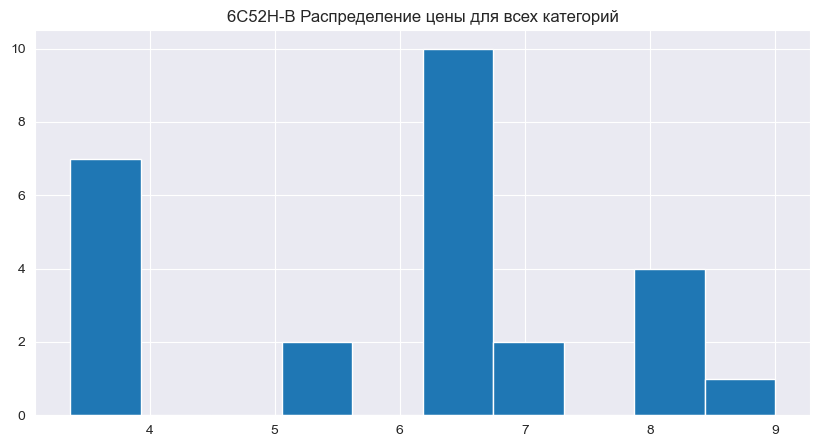

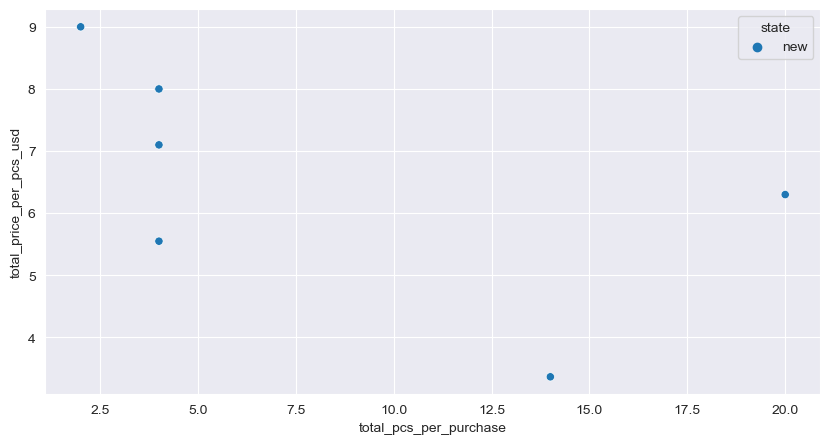

new


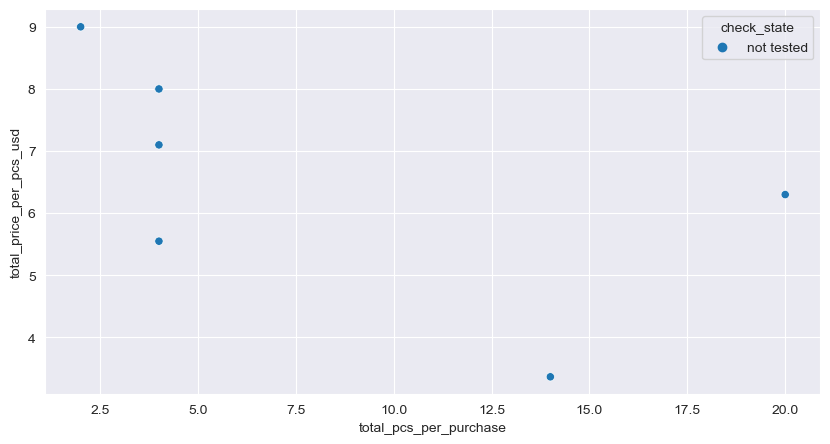

used


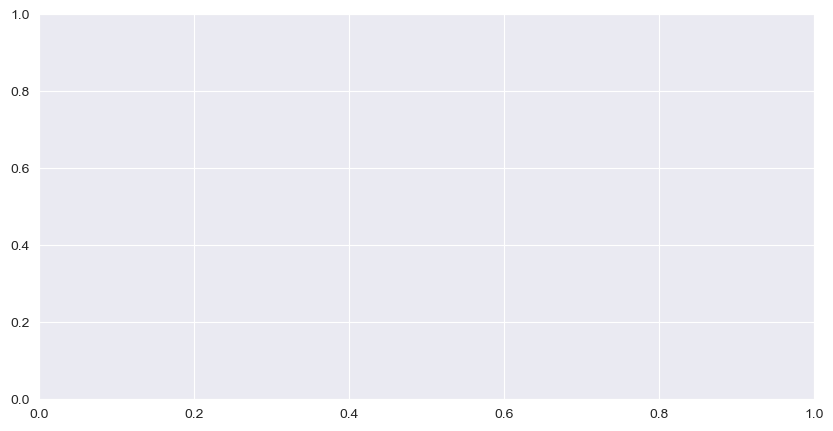


################################################## 6С53Н-В ##################################################
Нет продаж для лота 

################################################## 6Ф12П ##################################################
Продано штук:  173 

Распределение по состоянию (проданных штук): 
newNotTested    173 

Гистограмма цены для всех категорий:


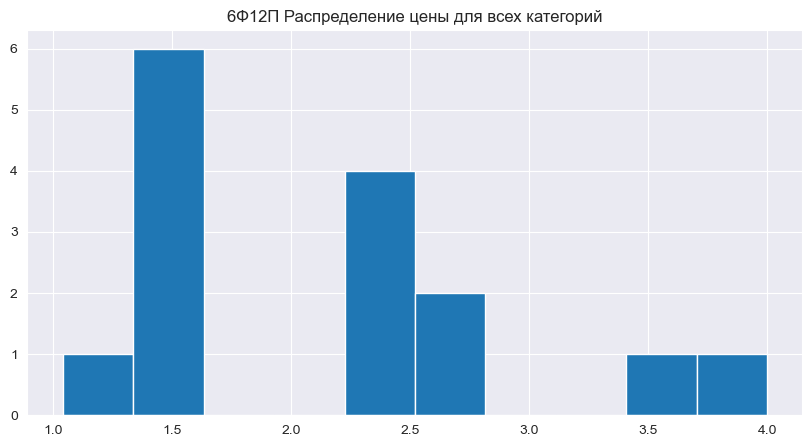

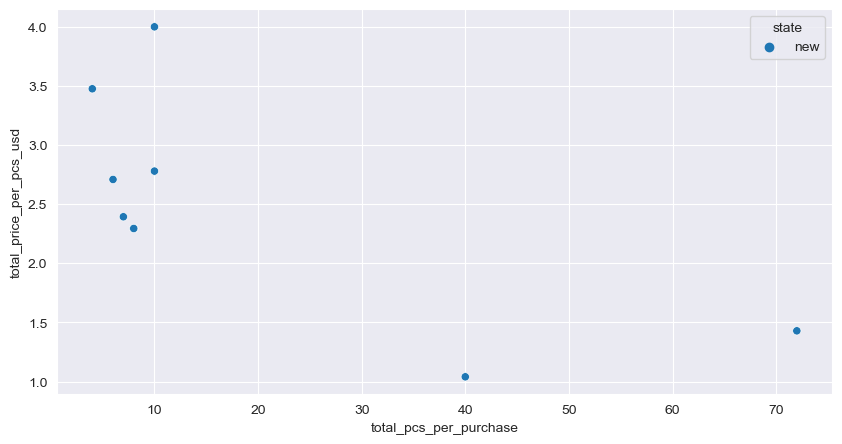

new


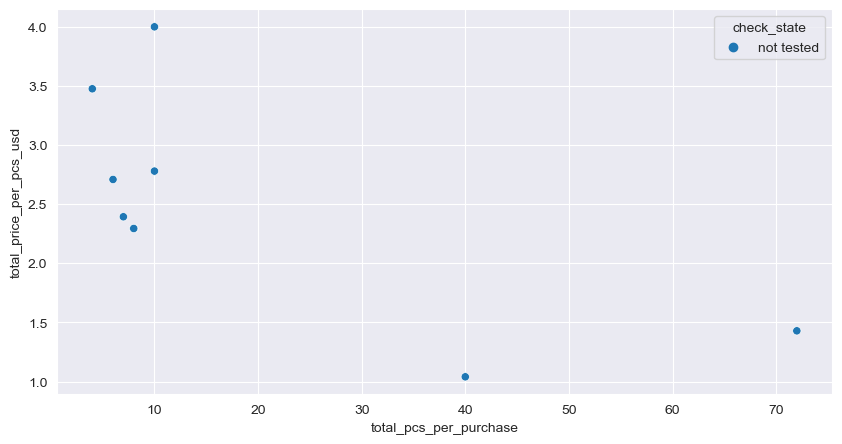

used


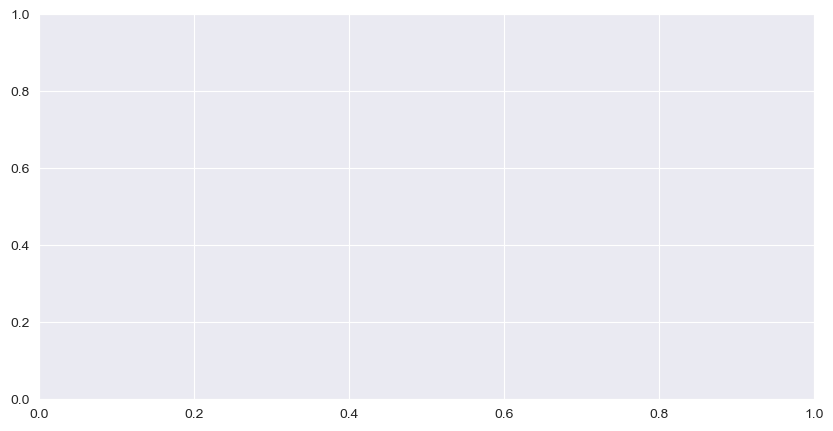


################################################## 6Ф3П ##################################################
Продано штук:  158 

Распределение по состоянию (проданных штук): 
newAndMatched     12
newAndTested      14
newNotTested      92
usedAndMatched    20
usedAndTested     20 

Гистограмма цены для всех категорий:


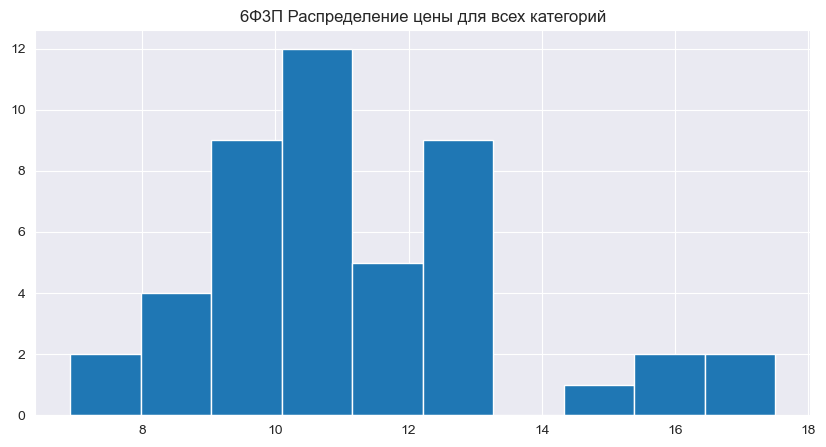

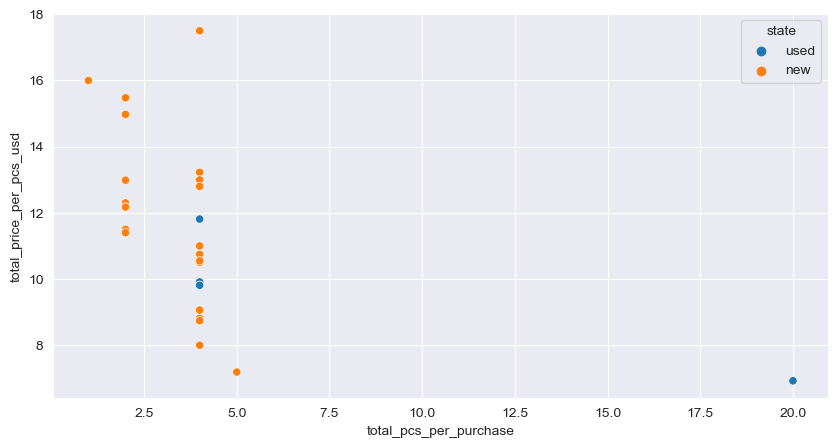

new


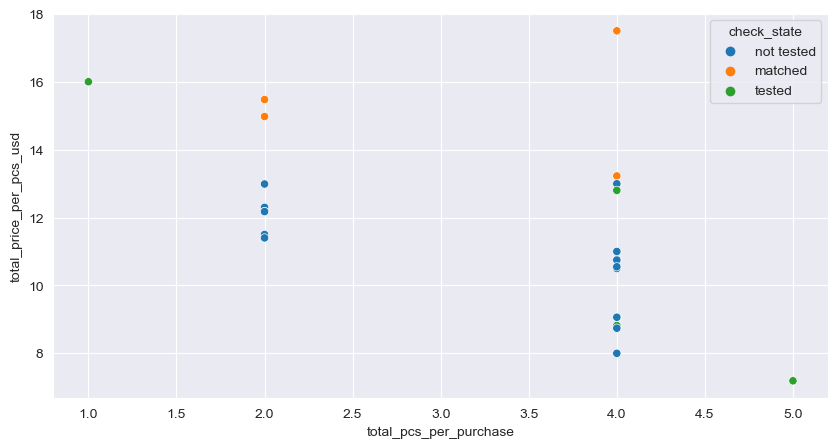

used


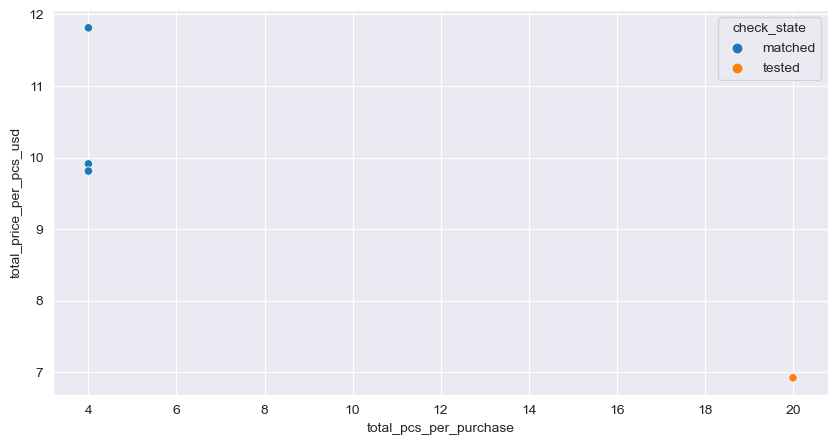


################################################## 6Ф5П ##################################################
Продано штук:  44 

Распределение по состоянию (проданных штук): 
newNotTested    44 

Гистограмма цены для всех категорий:


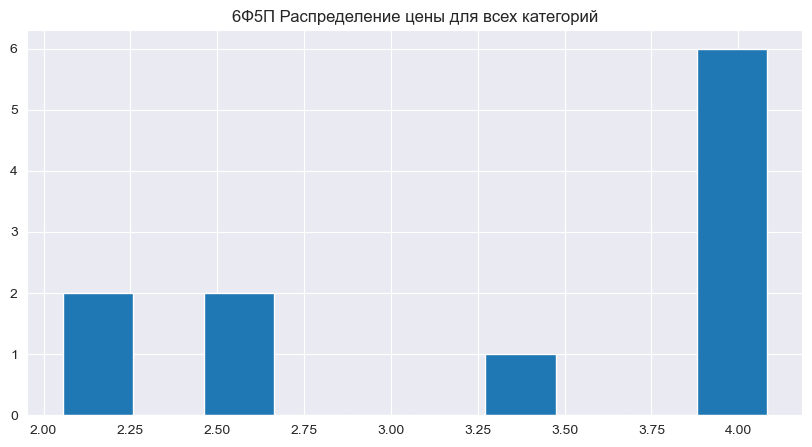

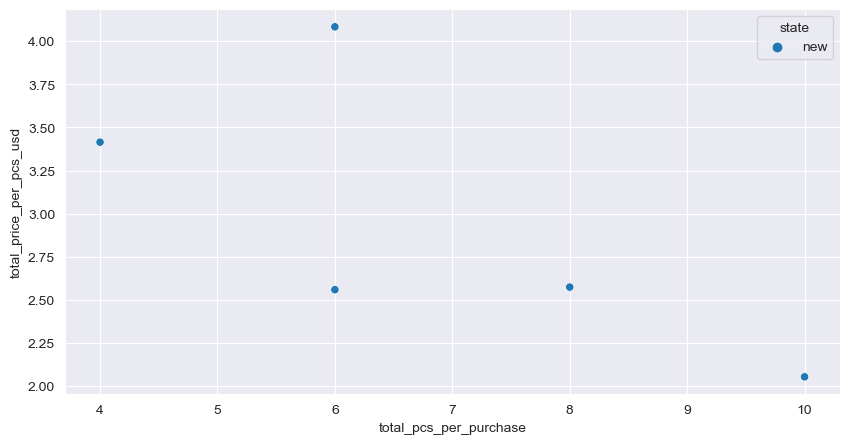

new


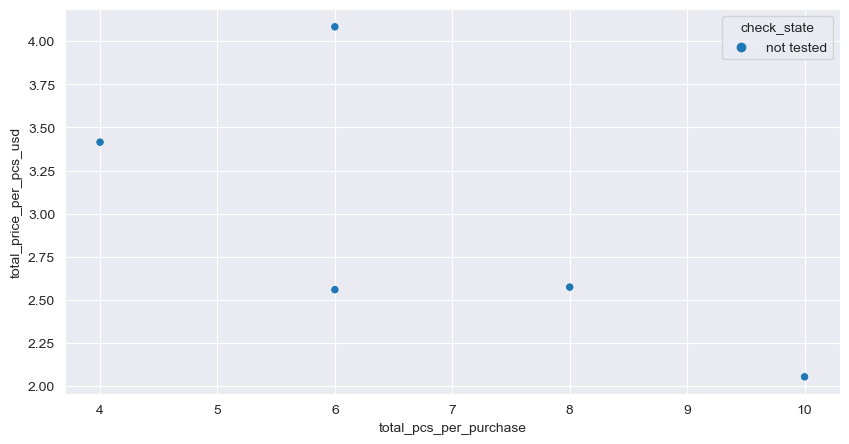

used


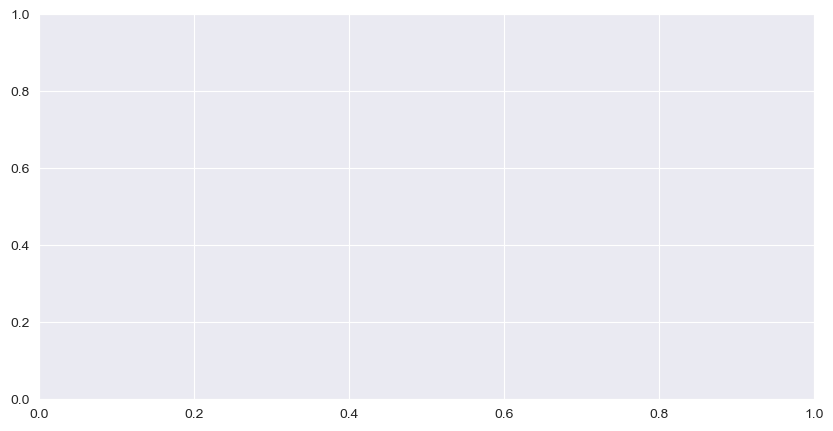


################################################## 6Х2П ##################################################
Продано штук:  100 

Распределение по состоянию (проданных штук): 
newNotTested    100 

Гистограмма цены для всех категорий:


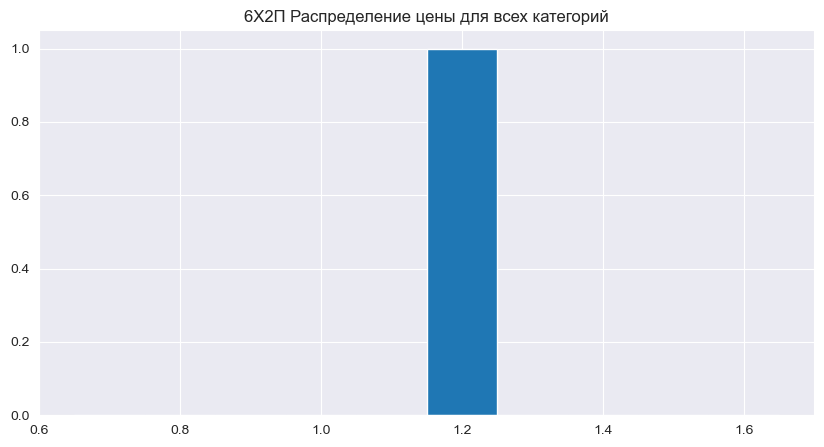

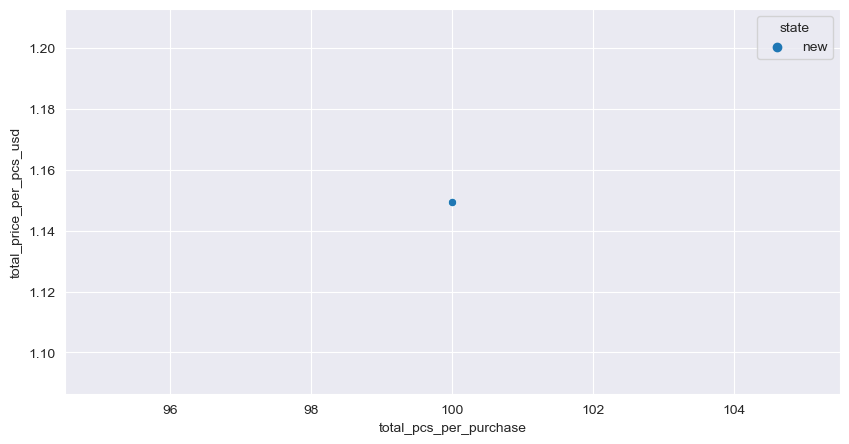

new


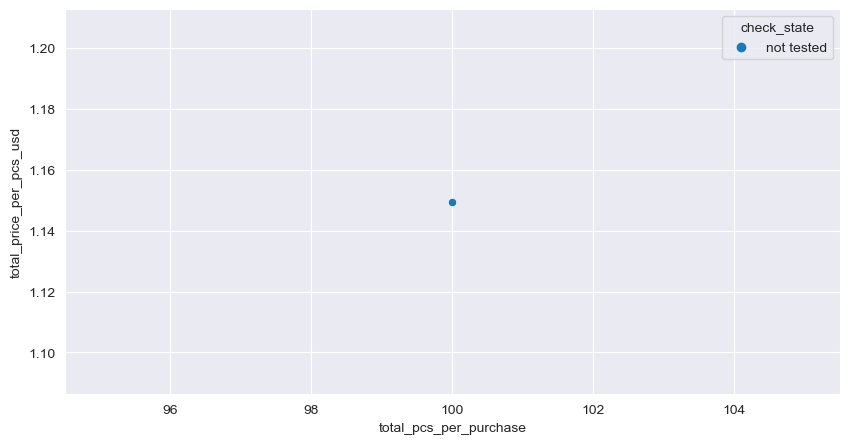

used


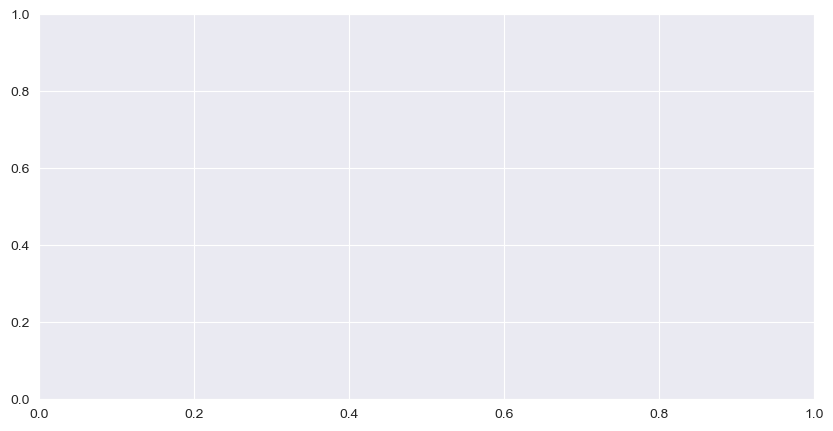


################################################## 6Х2П-ЕР ##################################################
Нет продаж для лота 

################################################## 6Ц19П ##################################################
Нет продаж для лота 

################################################## 6Ц4П ##################################################
Продано штук:  145 

Распределение по состоянию (проданных штук): 
newAndTested       13
newNotTested      130
usedAndMatched      2 

Гистограмма цены для всех категорий:


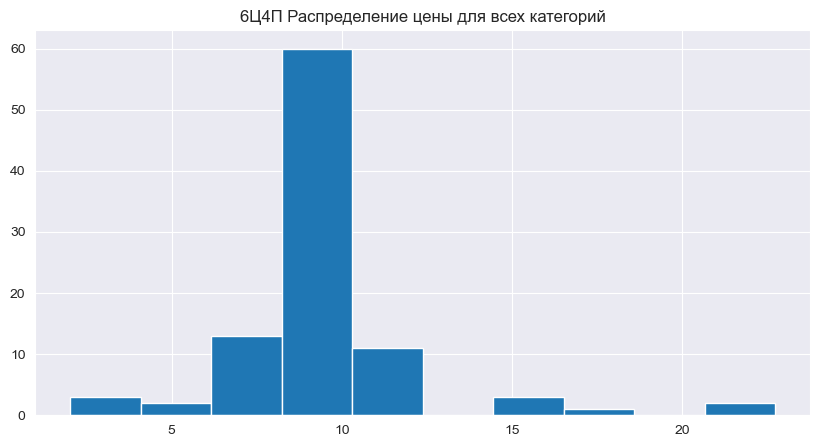

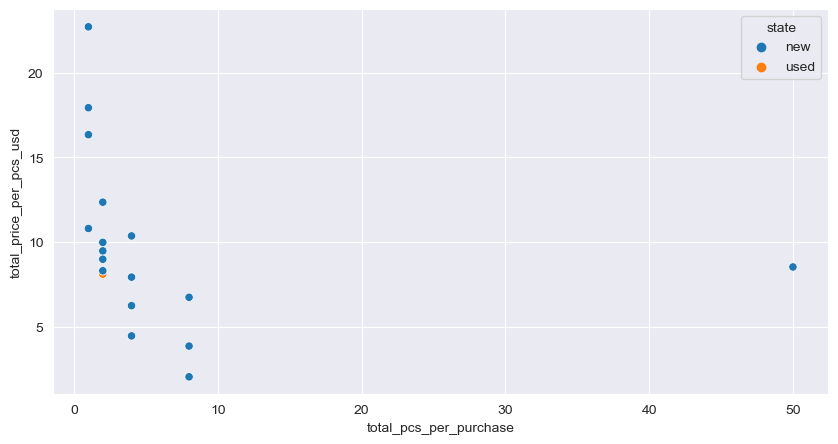

new


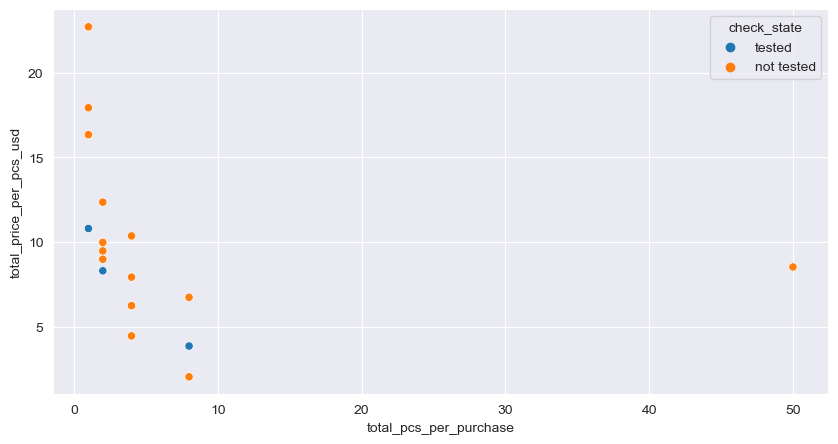

used


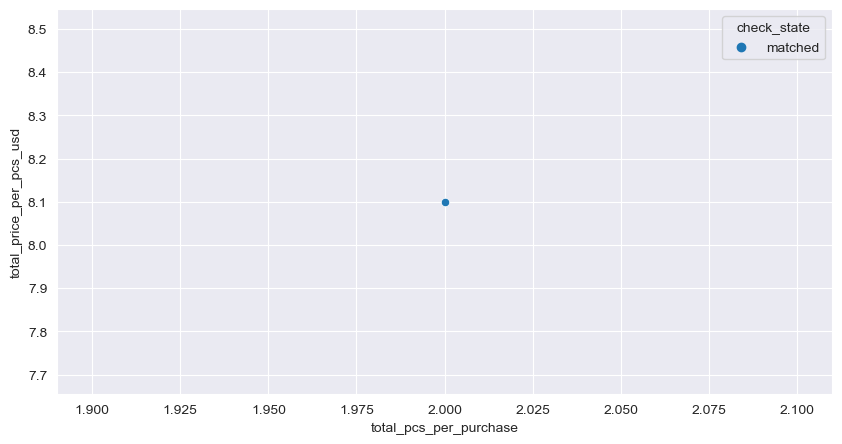


################################################## 6Ц4П-ЕВ ##################################################
Продано штук:  49 

Распределение по состоянию (проданных штук): 
newAndMatched     4
newNotTested     45 

Гистограмма цены для всех категорий:


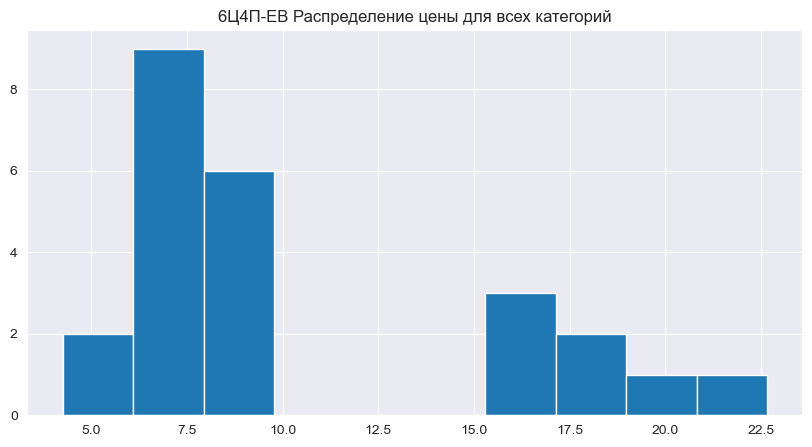

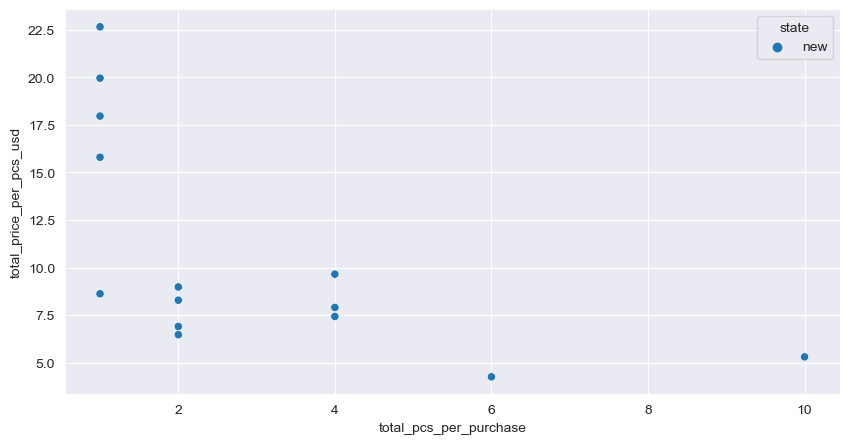

new


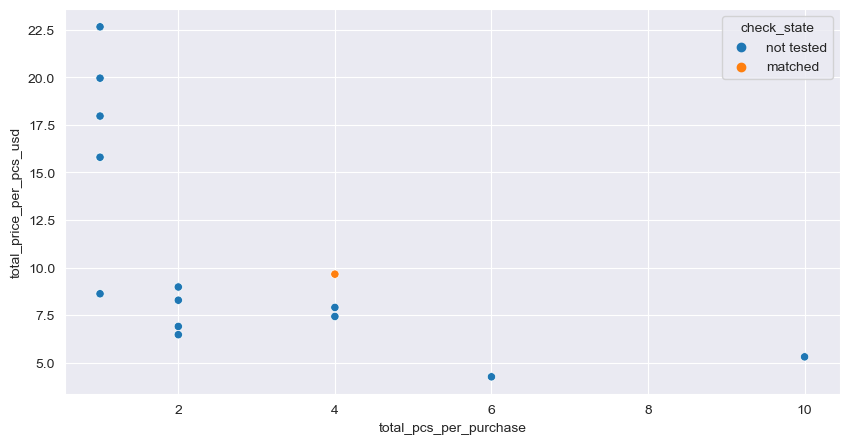

used


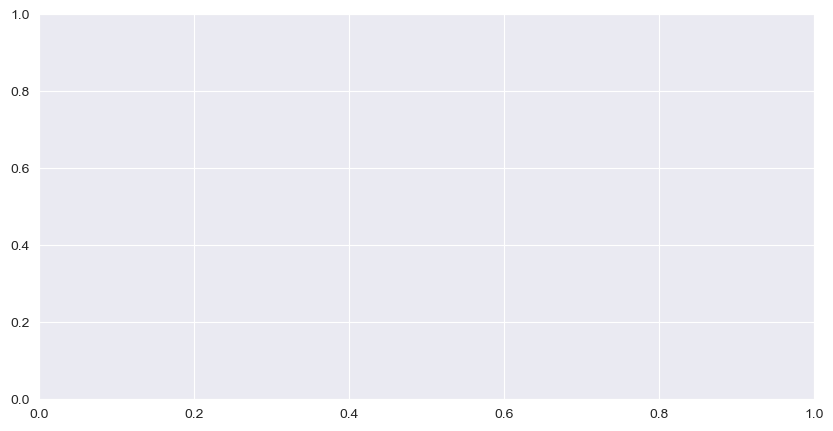


################################################## 6Э12Н-В ##################################################
Нет продаж для лота 

################################################## 6Э5П ##################################################
Продано штук:  123 

Распределение по состоянию (проданных штук): 
newAndMatched     30
newAndTested      24
newNotTested      61
usedAndMatched     8 

Гистограмма цены для всех категорий:


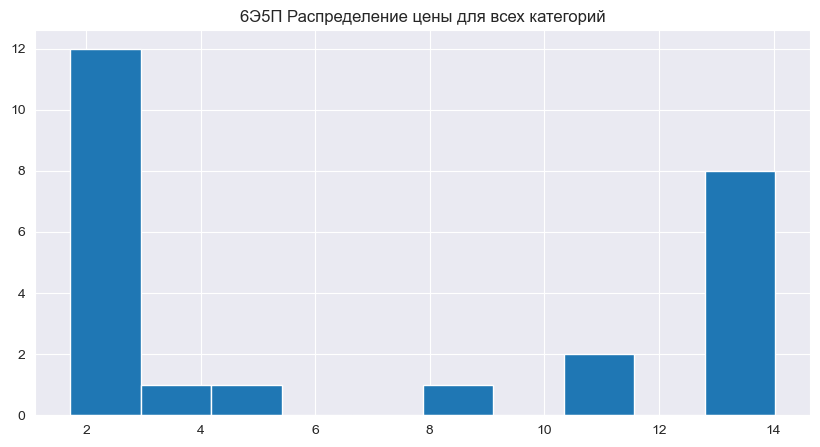

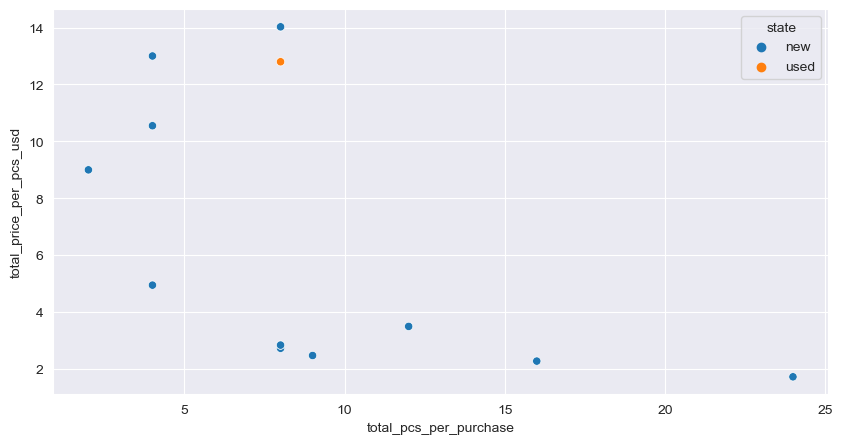

new


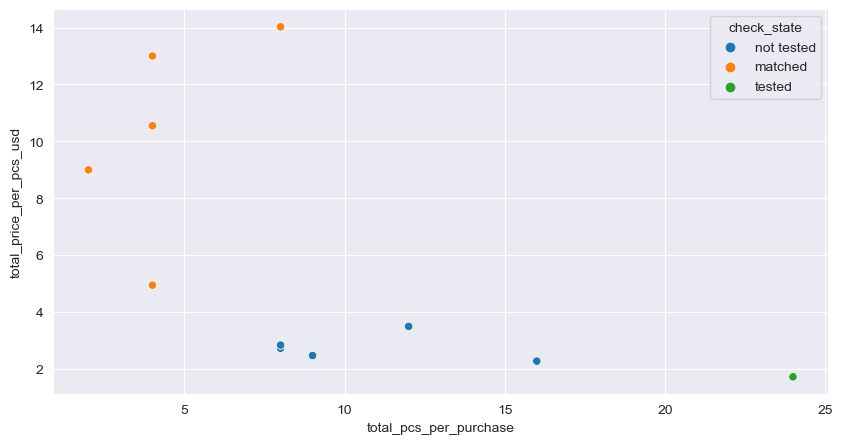

used


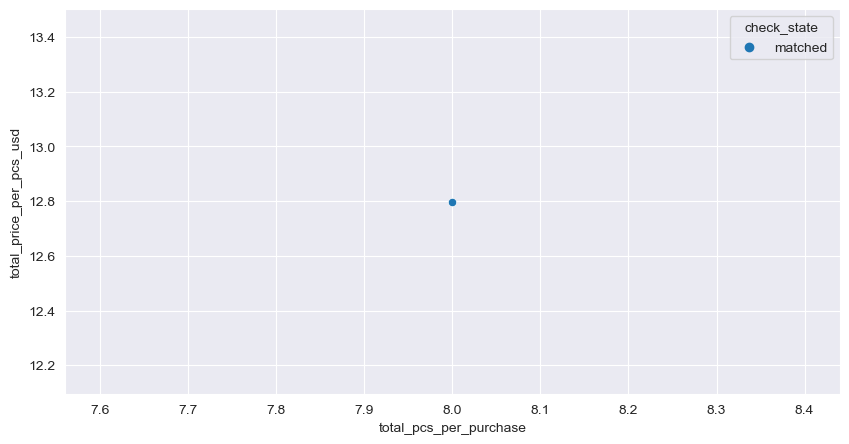


################################################## 6Э5П-И ##################################################
Продано штук:  20 

Распределение по состоянию (проданных штук): 
usedAndMatched    20 

Гистограмма цены для всех категорий:


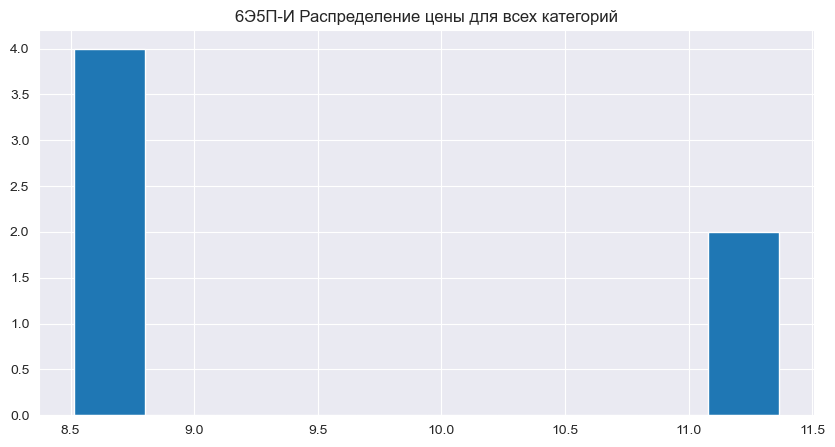

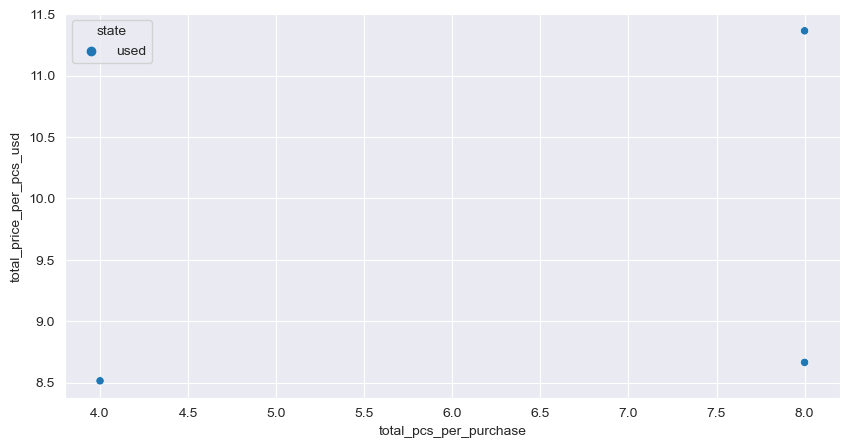

new


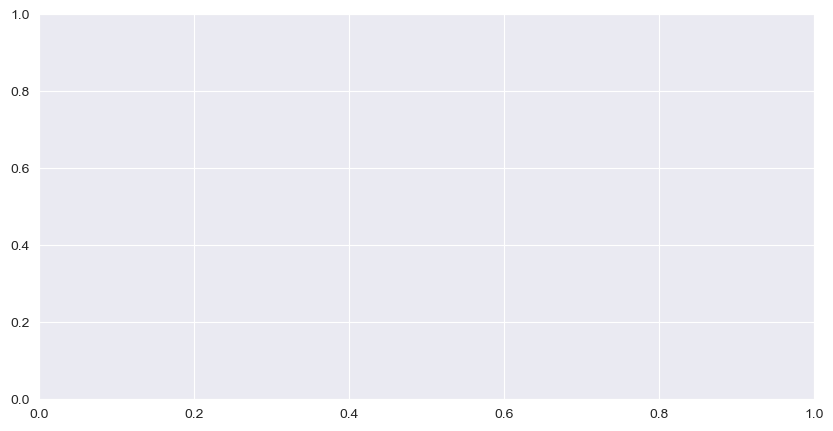

used


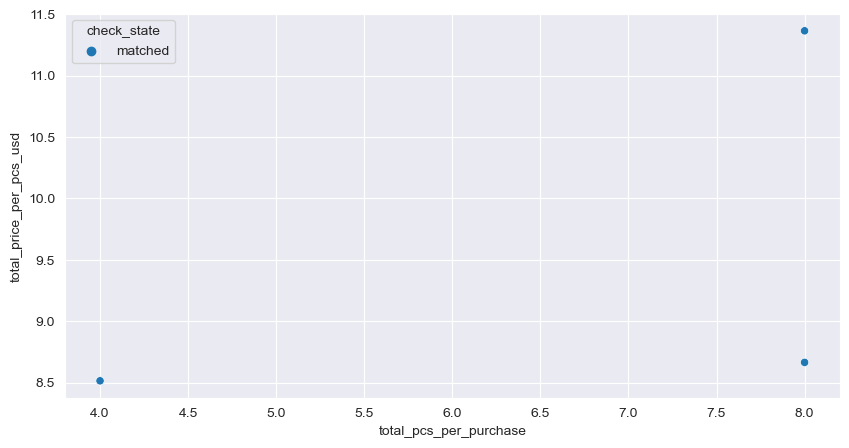


################################################## 8ЛО39В ##################################################
Нет продаж для лота 

################################################## ECH81 TESLA ##################################################
Продано штук:  2 

Распределение по состоянию (проданных штук): 
newNotTested    2 

Гистограмма цены для всех категорий:


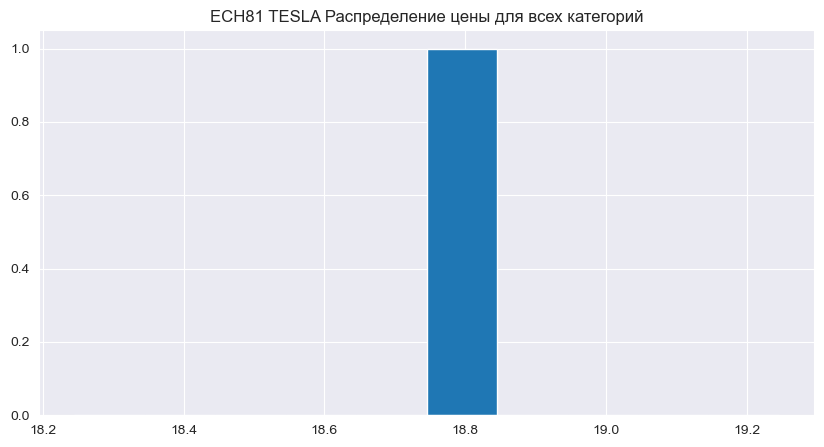

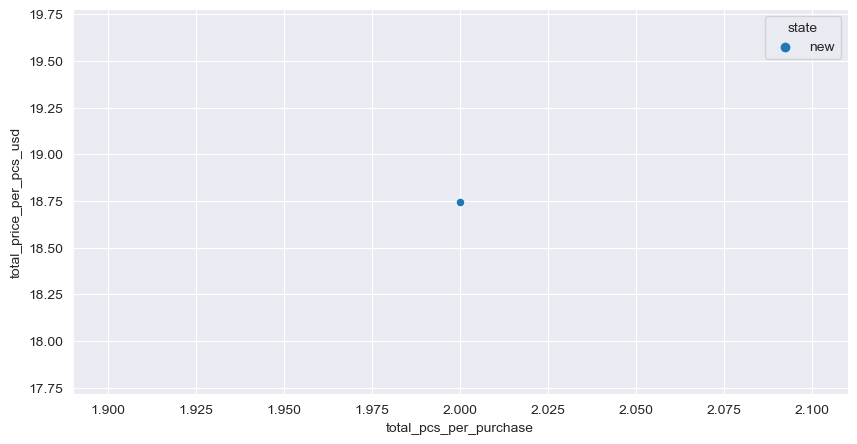

new


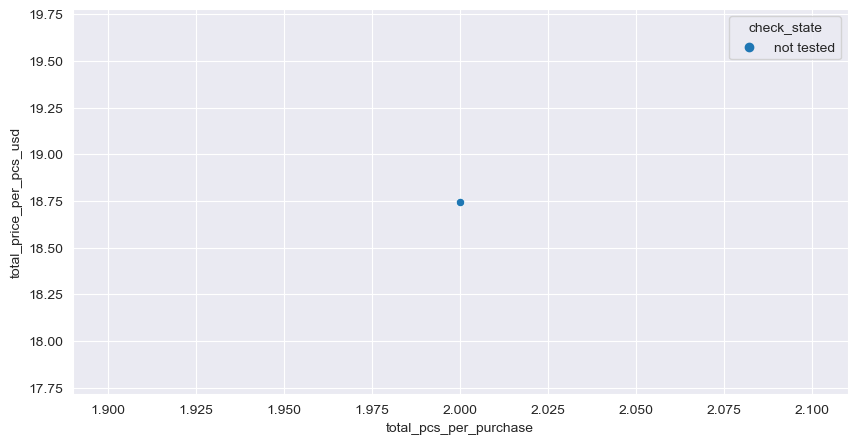

used


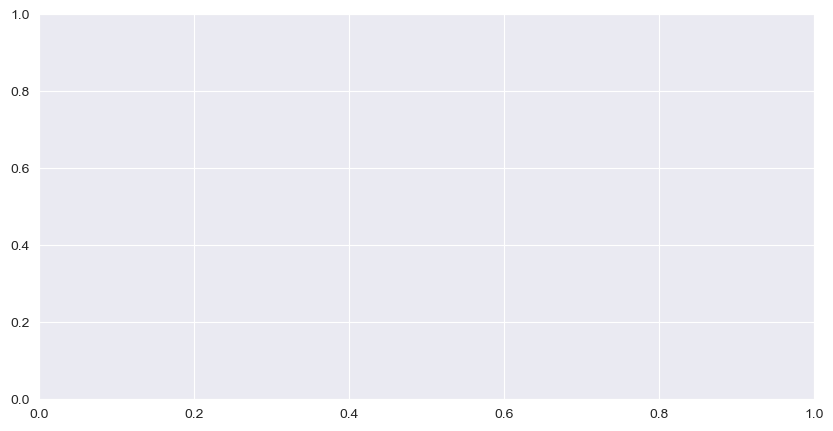


################################################## ECL82 TELAM ##################################################
Продано штук:  3 

Распределение по состоянию (проданных штук): 
newNotTested    3 

Гистограмма цены для всех категорий:


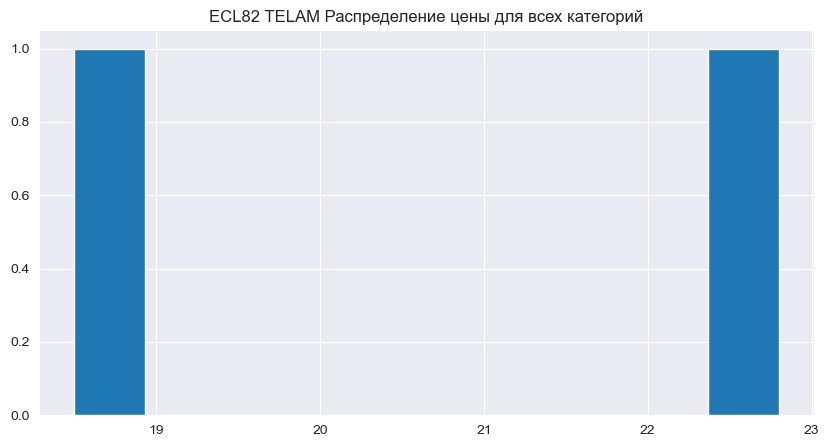

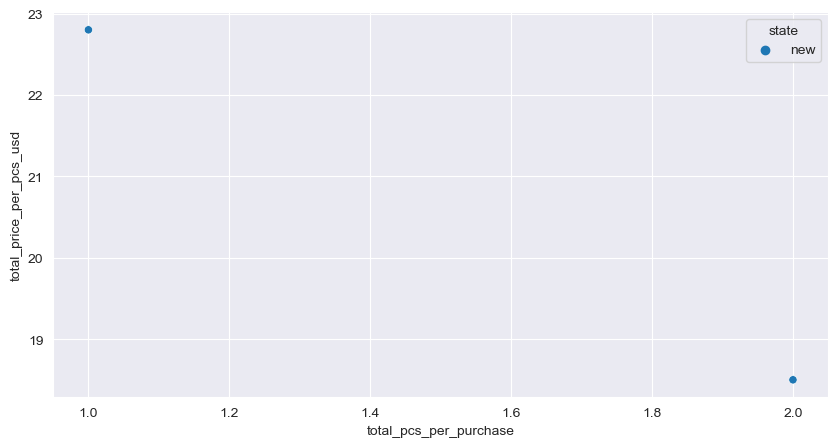

new


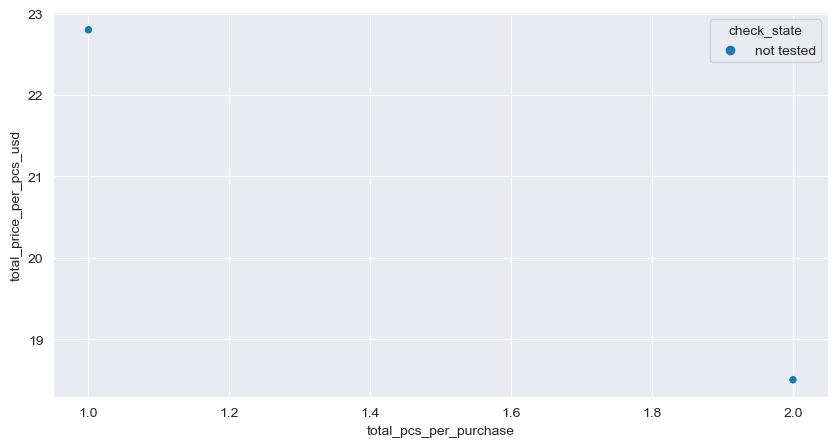

used


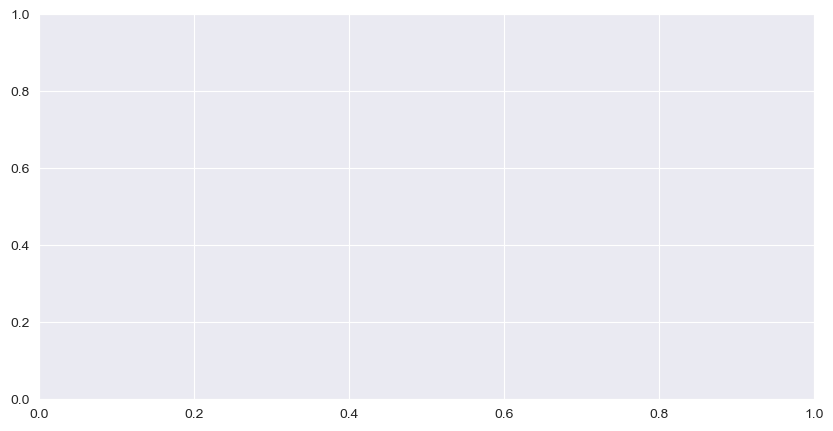


################################################## EL83 TESLA ##################################################
Продано штук:  9 

Распределение по состоянию (проданных штук): 
newAndMatched    9 

Гистограмма цены для всех категорий:


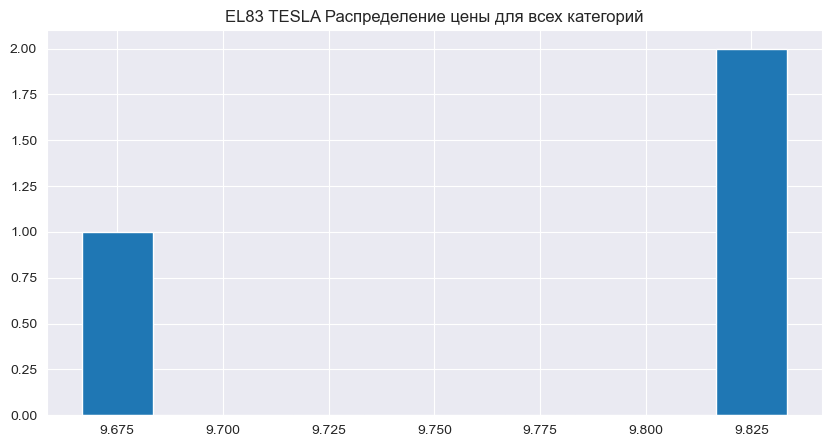

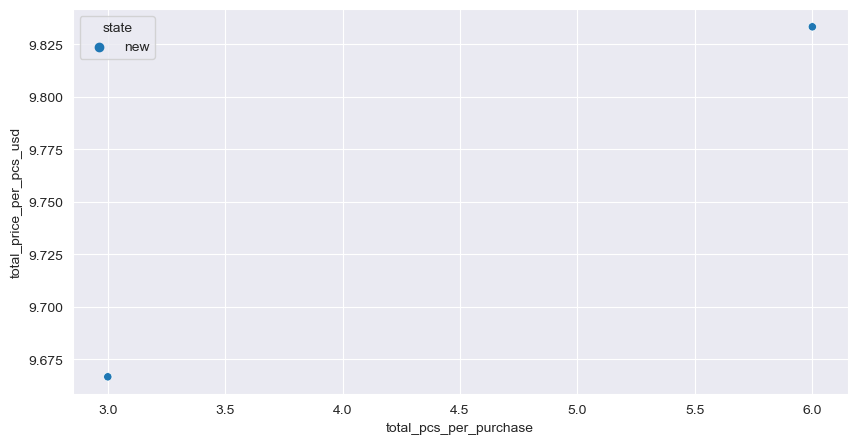

new


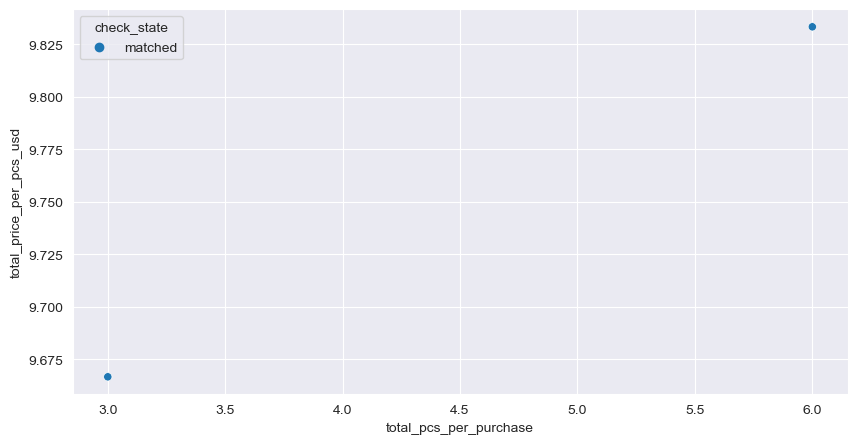

used


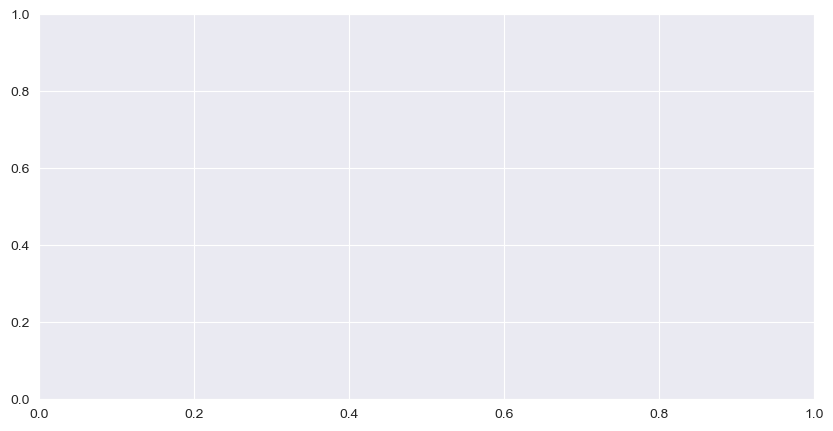


################################################## EL84 POLAM ##################################################
Продано штук:  54 

Распределение по состоянию (проданных штук): 
newAndTested        12
usedAndMatched      24
usedAndNotTested    18 

Гистограмма цены для всех категорий:


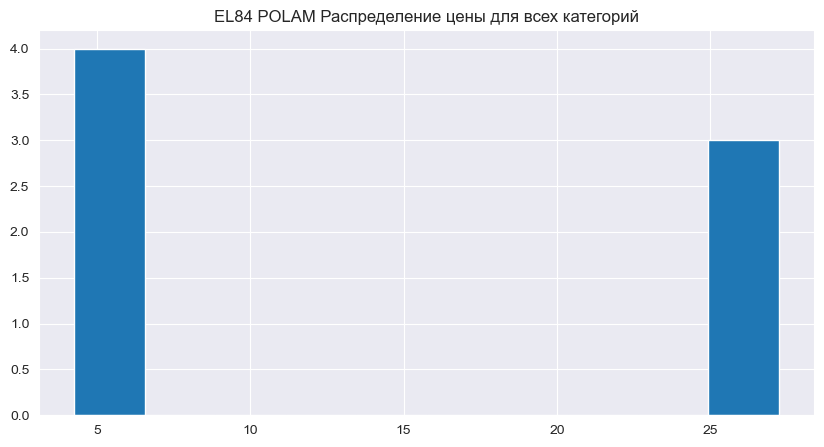

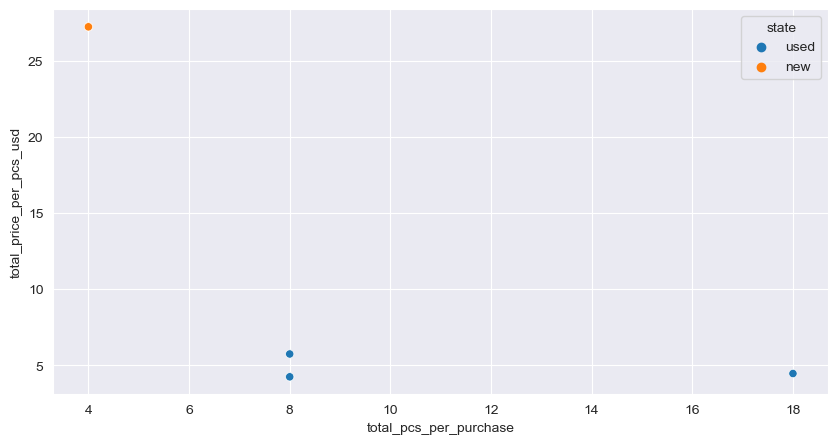

new


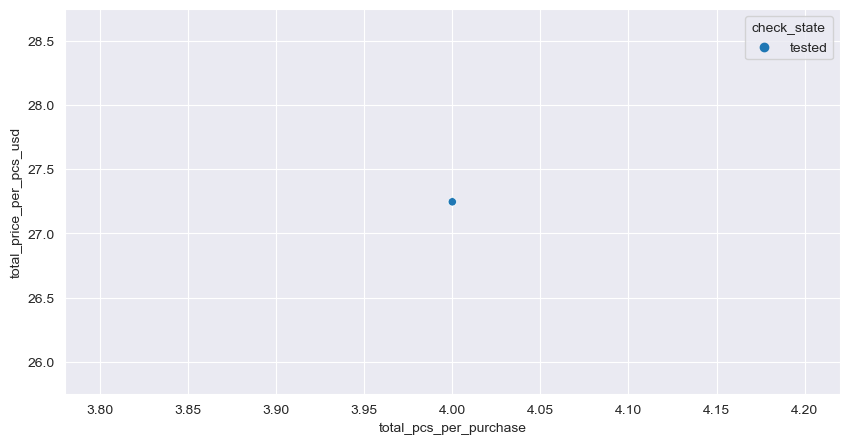

used


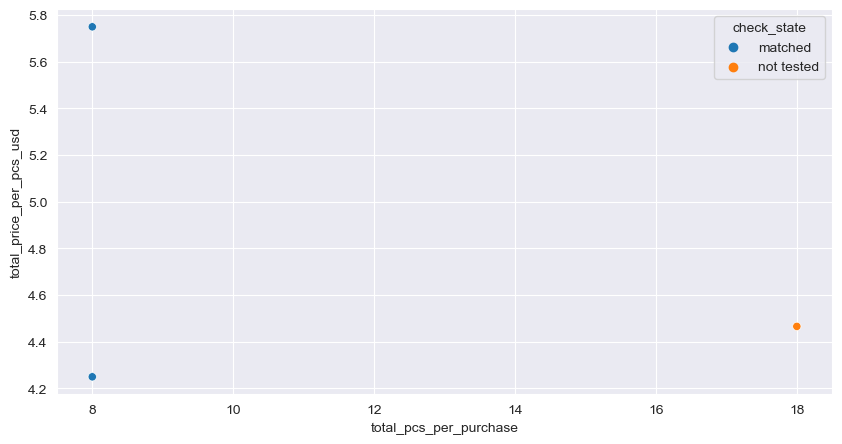


################################################## EL84 TELAM ##################################################
Продано штук:  126 

Распределение по состоянию (проданных штук): 
newAndMatched     24
newAndTested       8
usedAndMatched    80
usedAndTested     14 

Гистограмма цены для всех категорий:


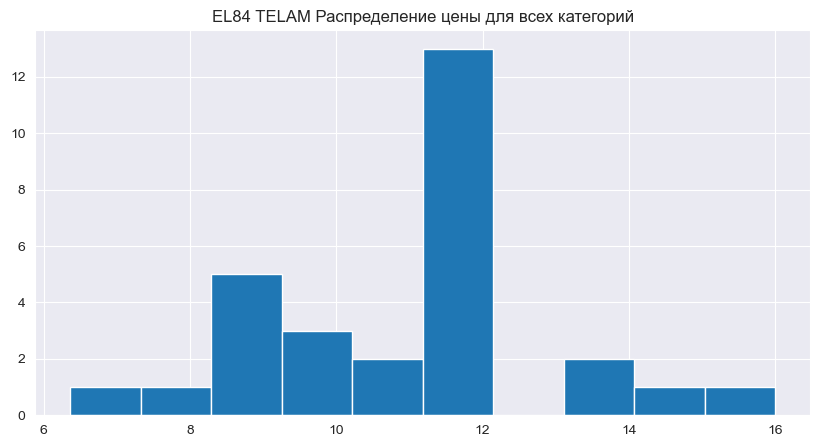

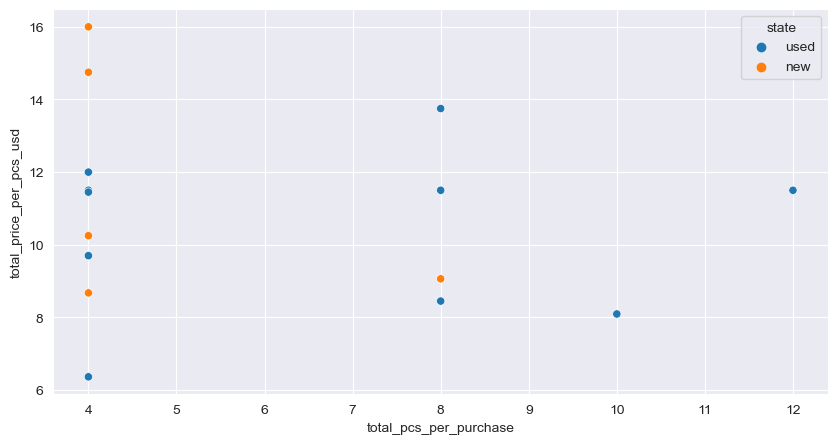

new


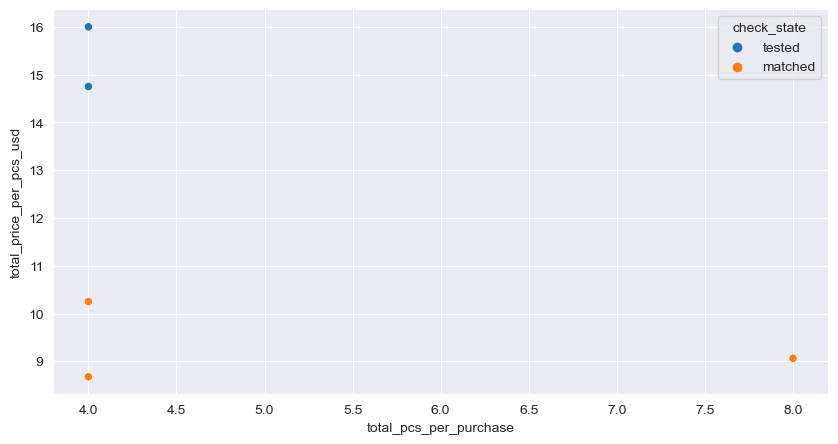

used


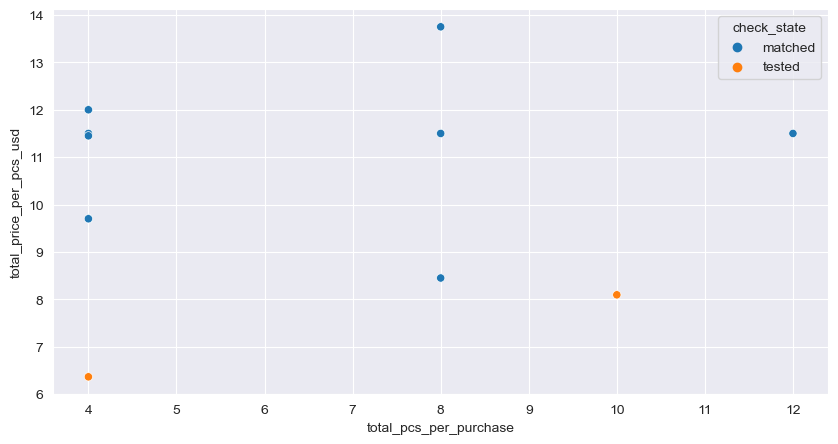


################################################## EL84 TESLA ##################################################
Продано штук:  29 

Распределение по состоянию (проданных штук): 
newAndMatched     22
usedAndMatched     4
usedAndTested      3 

Гистограмма цены для всех категорий:


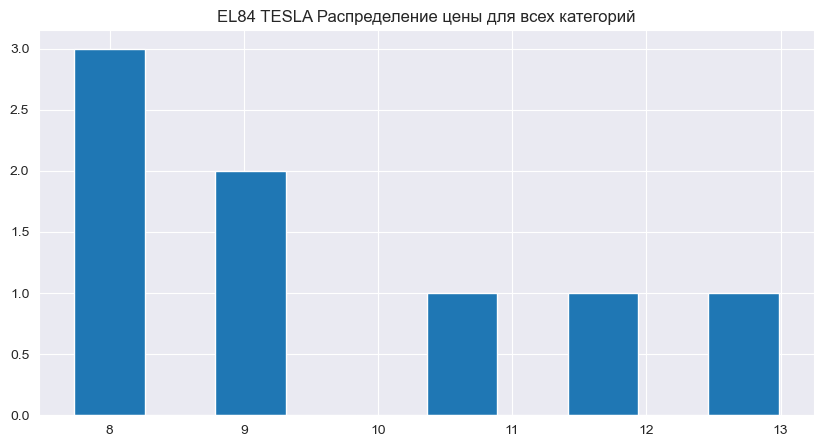

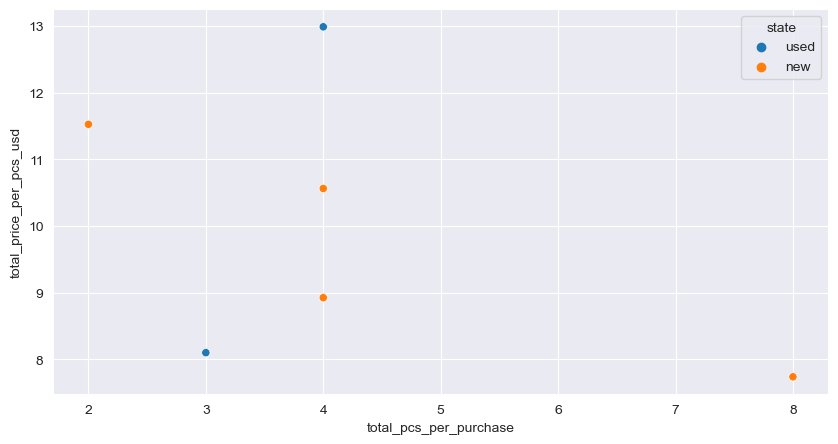

new


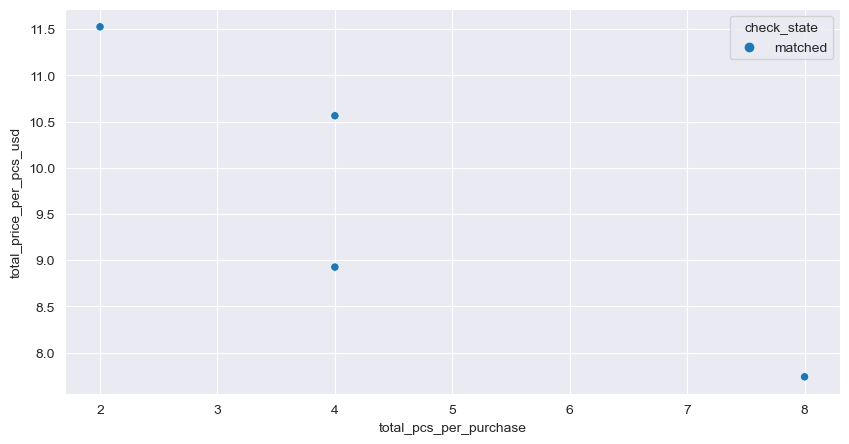

used


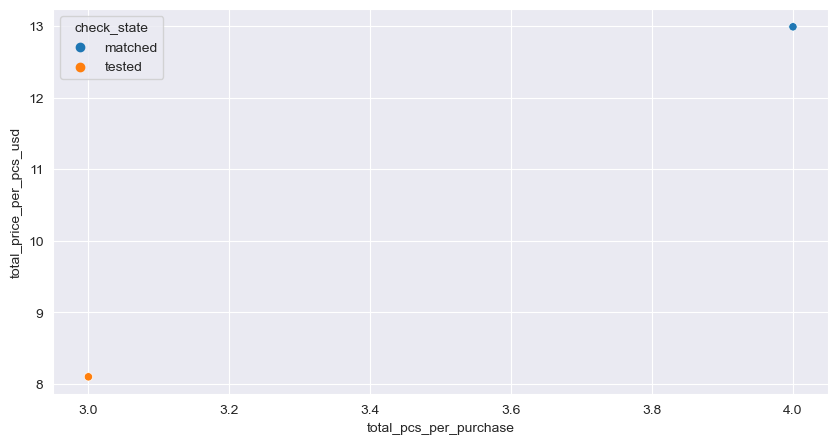


################################################## EL84 TUNGSRAM ##################################################
Продано штук:  4 

Распределение по состоянию (проданных штук): 
newAndTested    4 

Гистограмма цены для всех категорий:


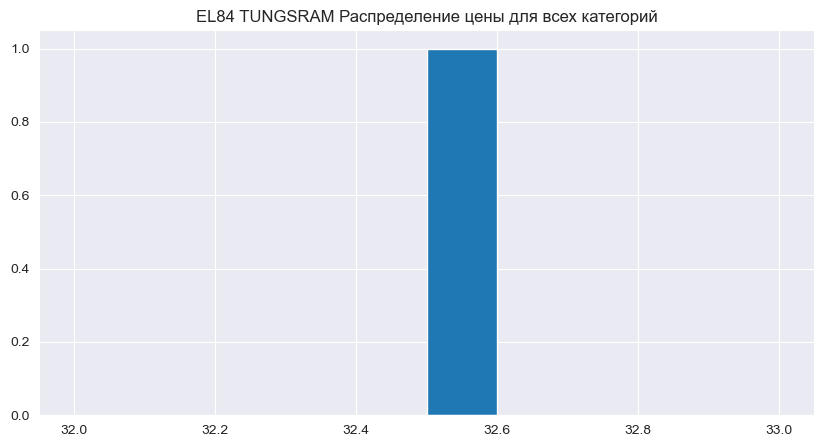

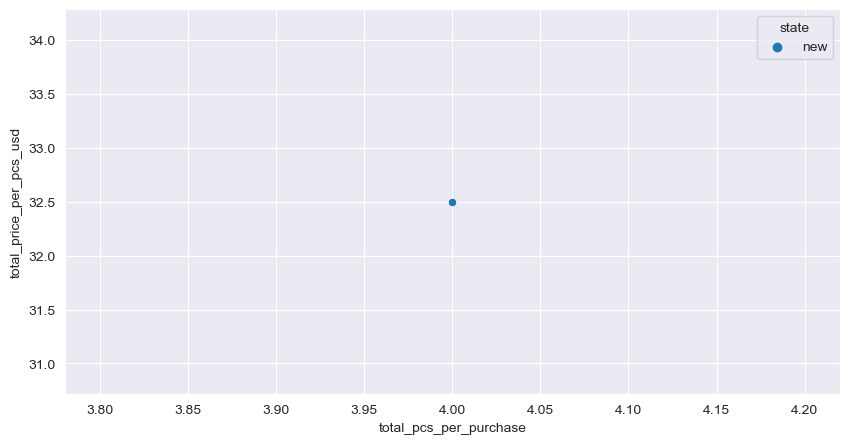

new


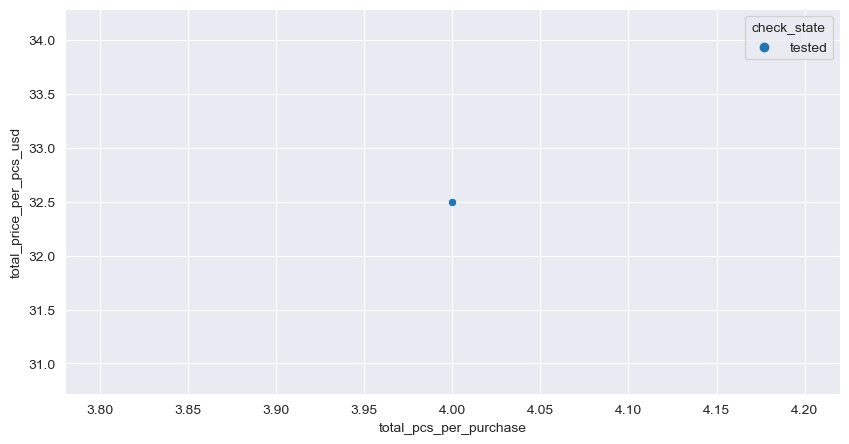

used


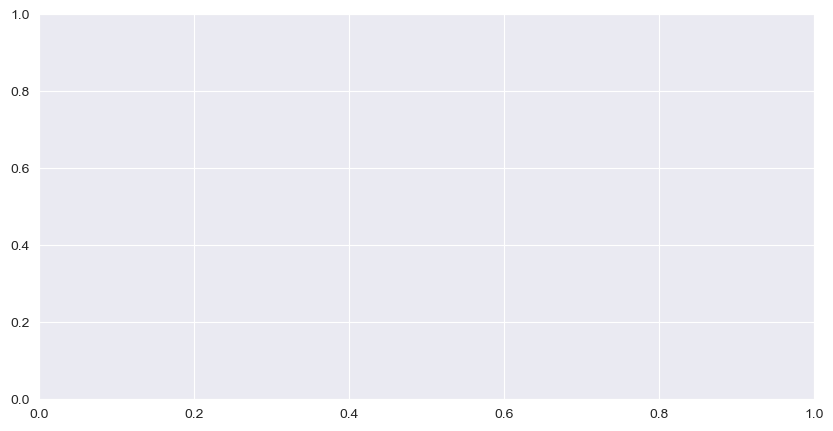


################################################## OD3 TUNGSRAM ##################################################
Продано штук:  20 

Распределение по состоянию (проданных штук): 
newAndMatched    20 

Гистограмма цены для всех категорий:


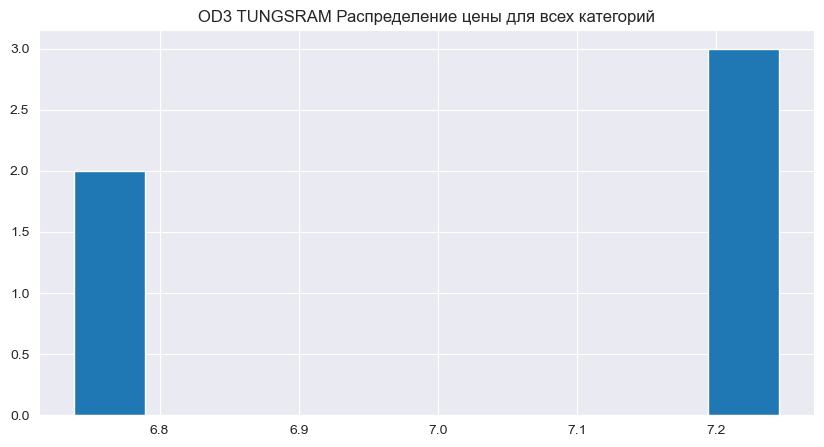

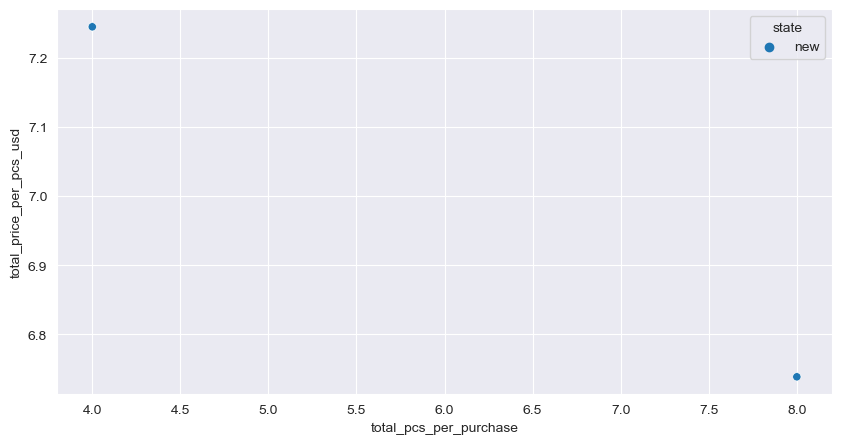

new


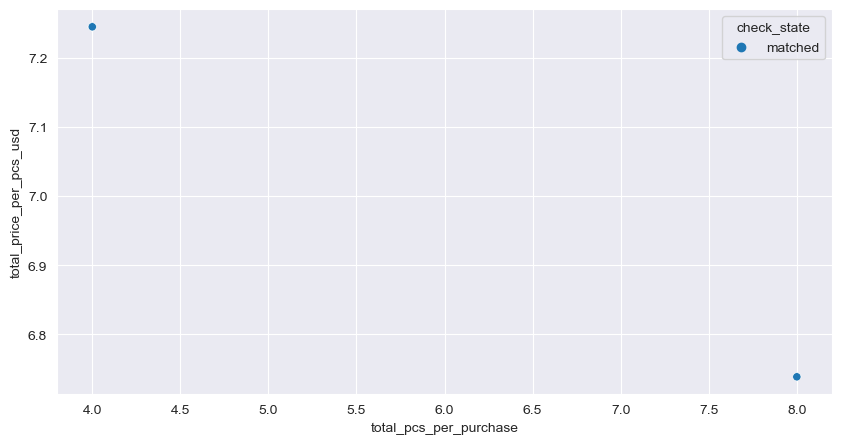

used


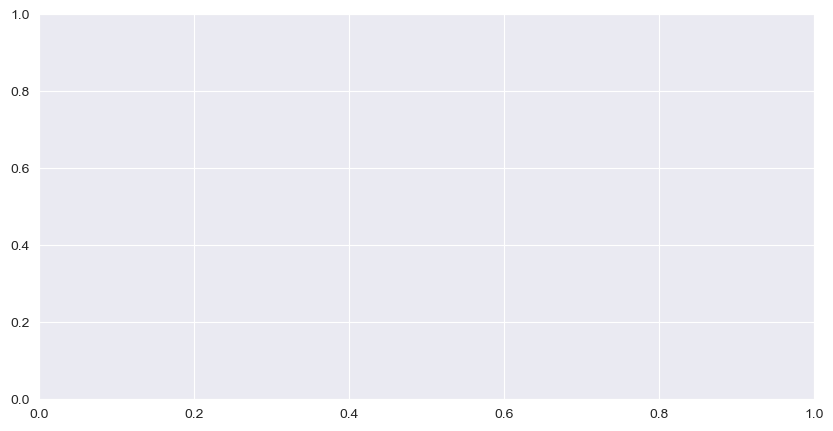


################################################## QQE03-12 TESLA ##################################################
Продано штук:  4 

Распределение по состоянию (проданных штук): 
newNotTested    4 

Гистограмма цены для всех категорий:


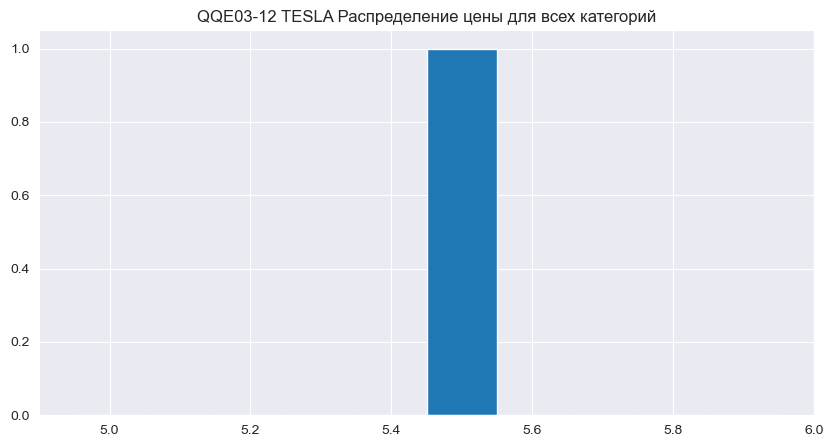

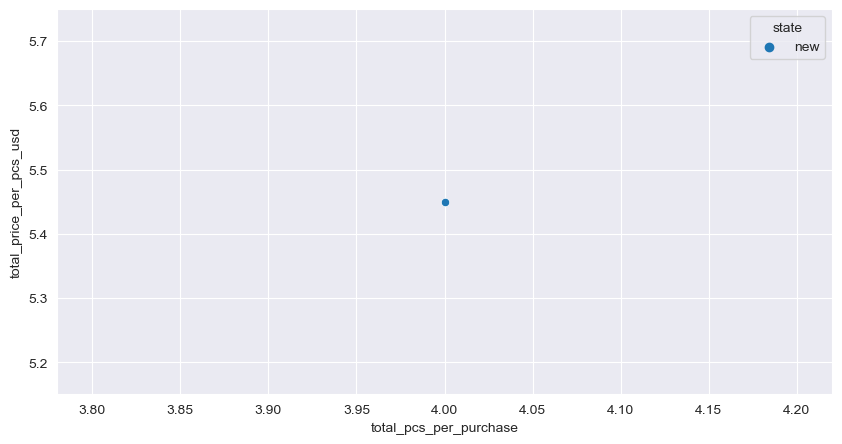

new


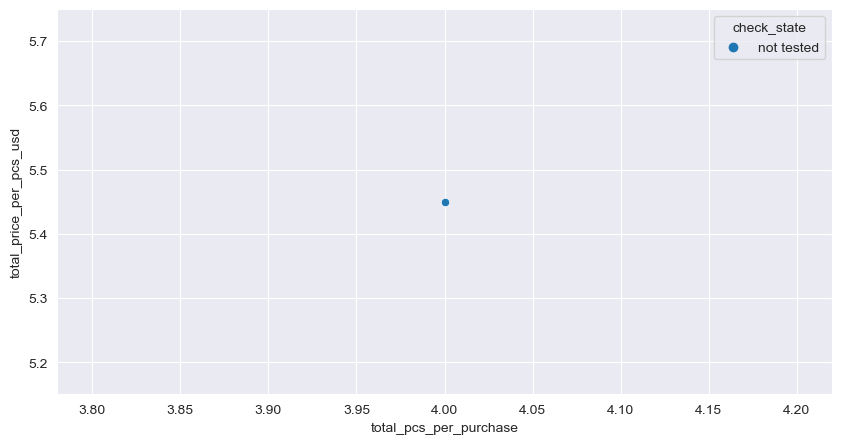

used


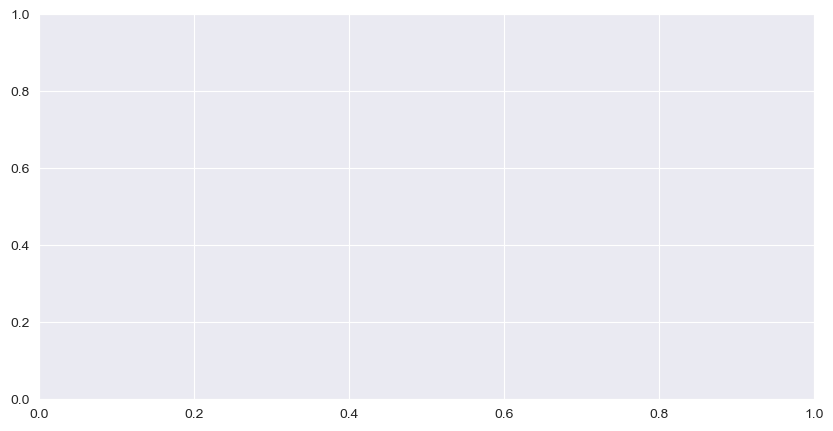


################################################## Z574M RFT ##################################################
Продано штук:  16 

Распределение по состоянию (проданных штук): 
usedAndTested    16 

Гистограмма цены для всех категорий:


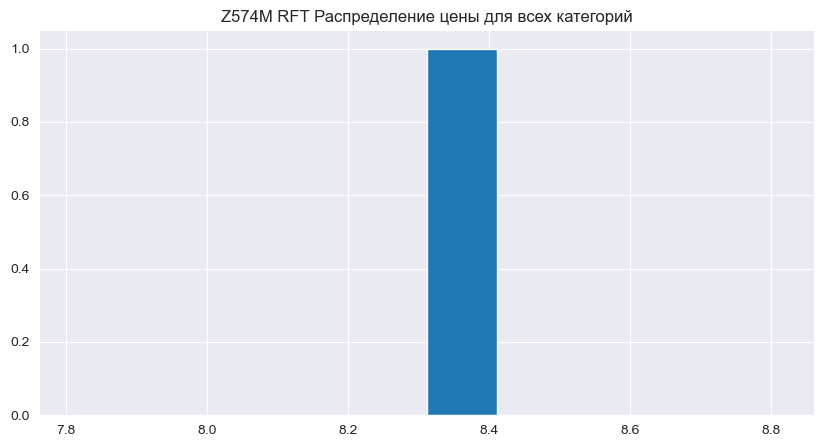

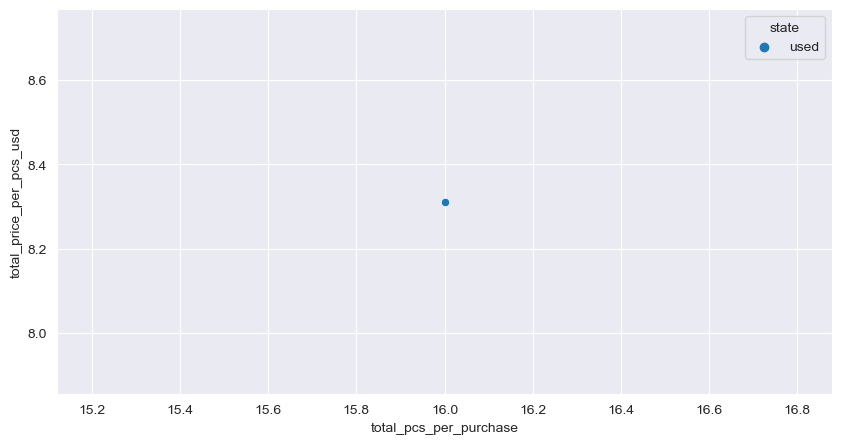

new


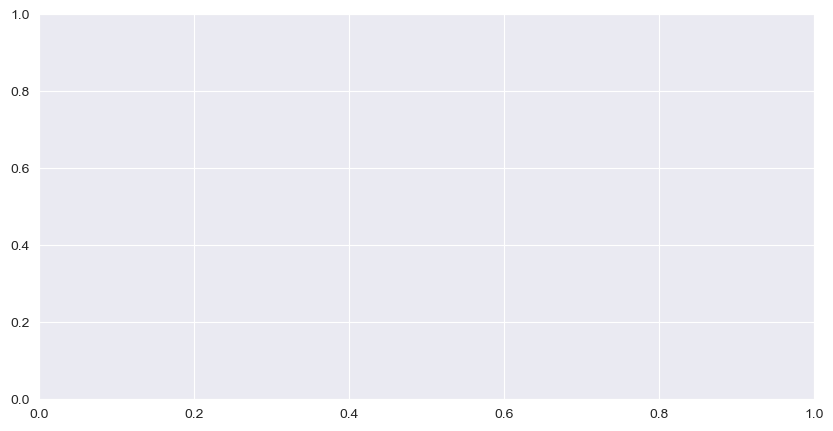

used


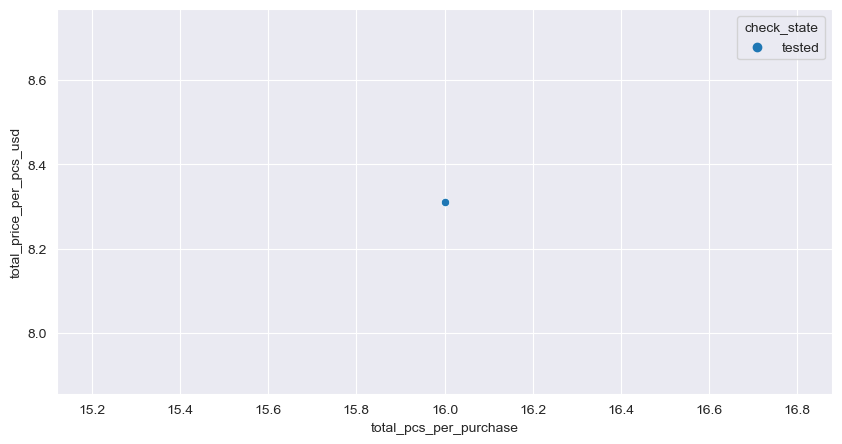


################################################## Г-807 ##################################################
Продано штук:  124 

Распределение по состоянию (проданных штук): 
newAndMatched    48
newNotTested     76 

Гистограмма цены для всех категорий:


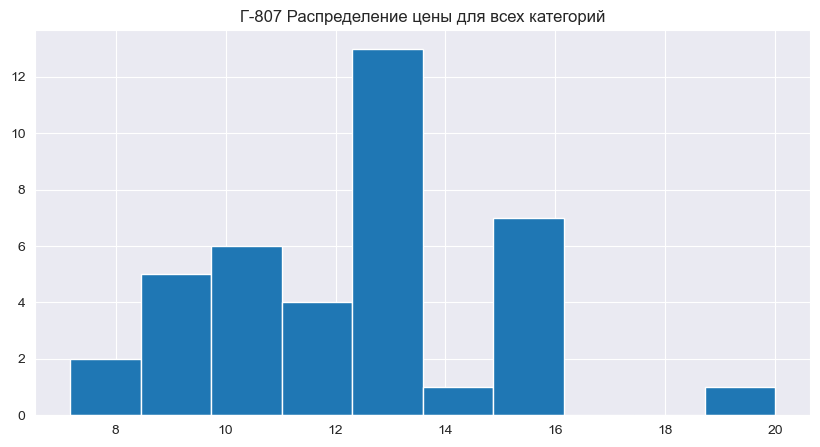

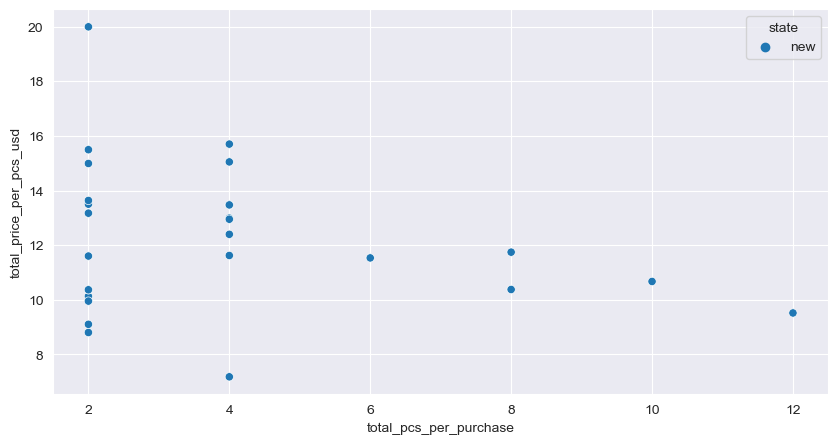

new


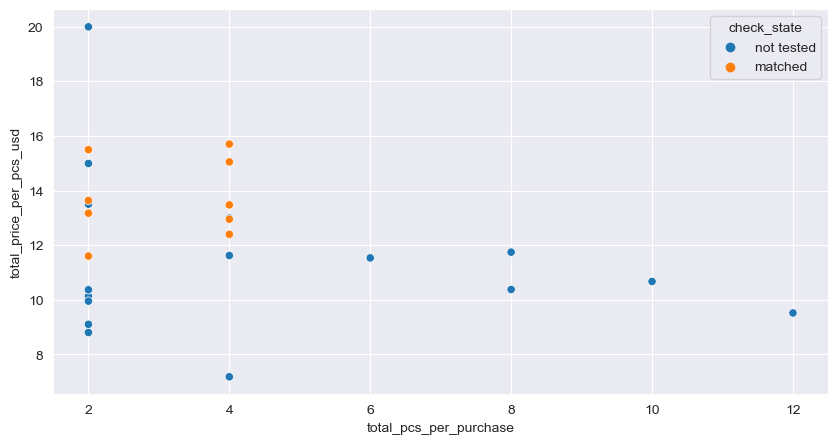

used


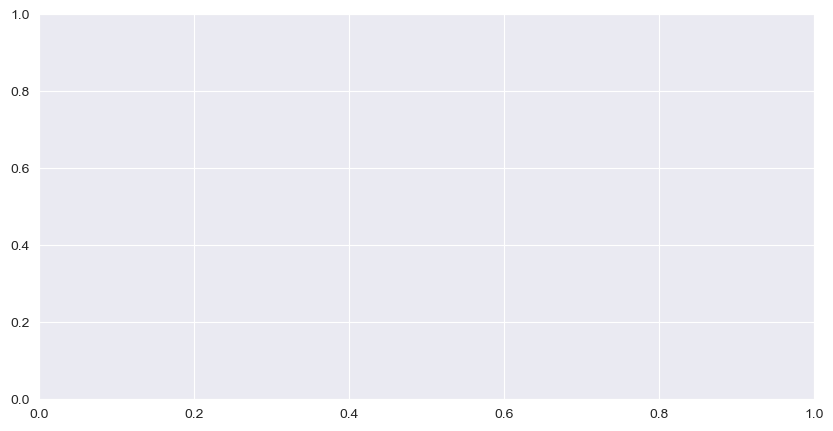


################################################## ГП-5 ##################################################
Нет продаж для лота 

################################################## ГУ-17 ##################################################
Продано штук:  23 

Распределение по состоянию (проданных штук): 
newNotTested        16
usedAndNotTested     7 

Гистограмма цены для всех категорий:


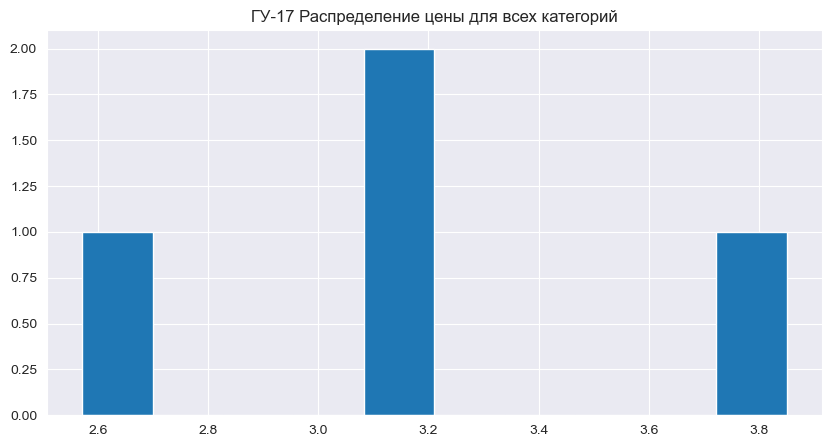

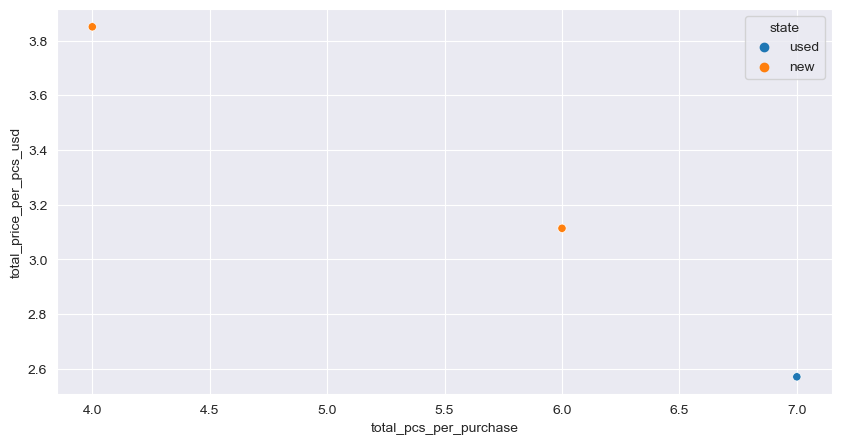

new


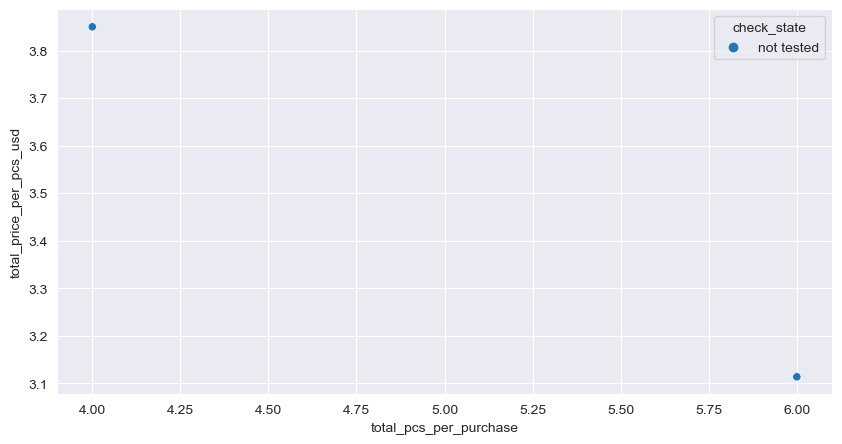

used


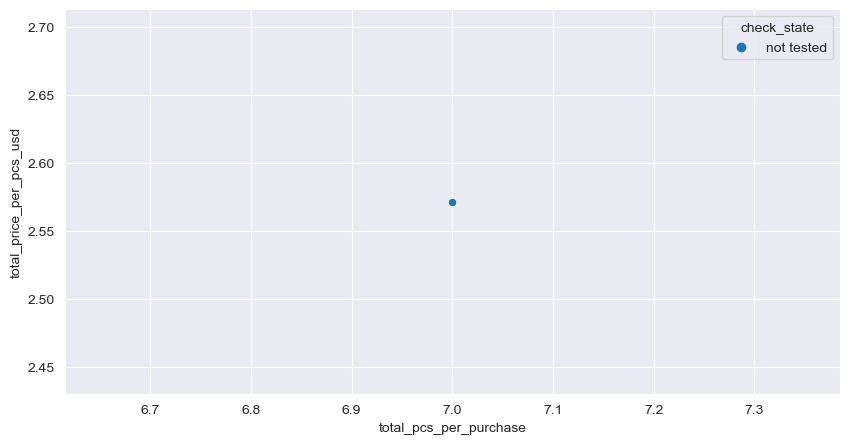


################################################## ДРШ-500М ##################################################
Продано штук:  1 

Распределение по состоянию (проданных штук): 
newNotTested    1 

Гистограмма цены для всех категорий:


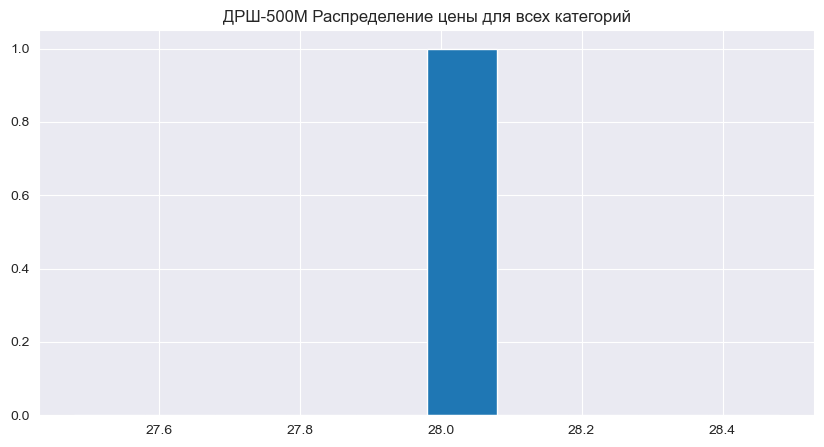

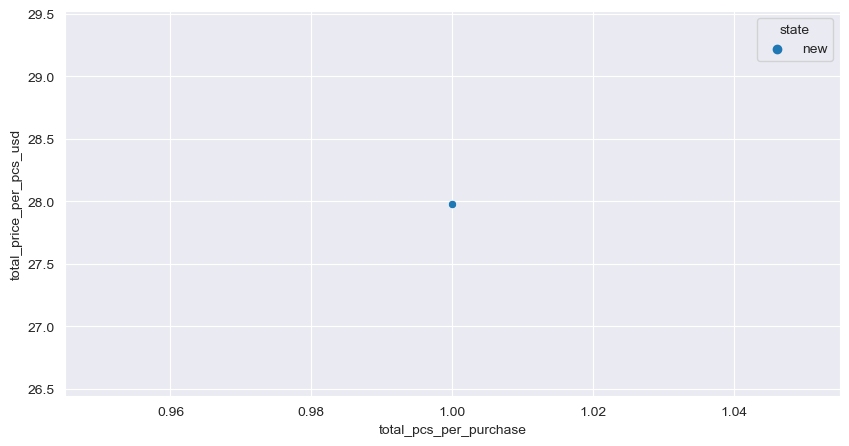

new


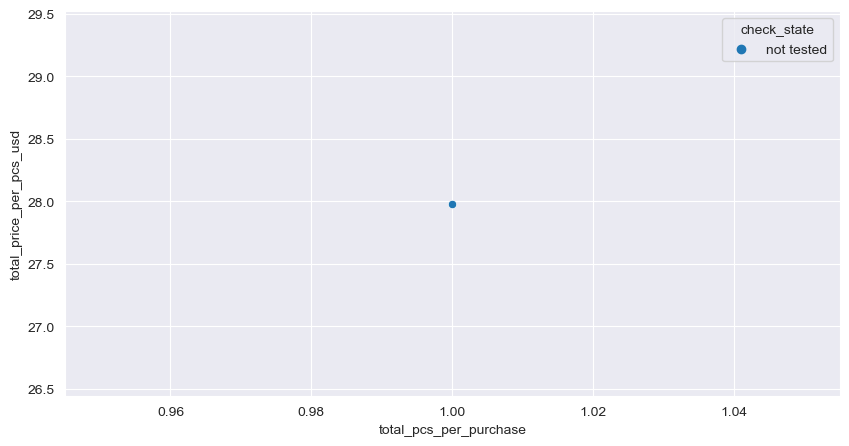

used


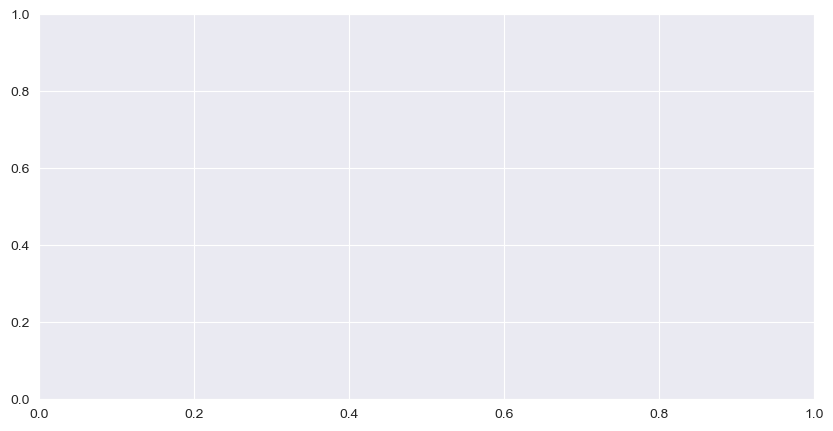


################################################## ИН-14 ##################################################
Продано штук:  51 

Распределение по состоянию (проданных штук): 
newNotTested    51 

Гистограмма цены для всех категорий:


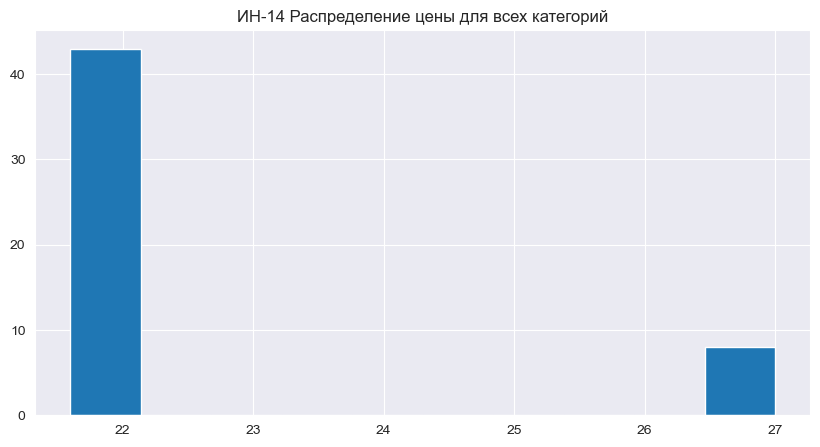

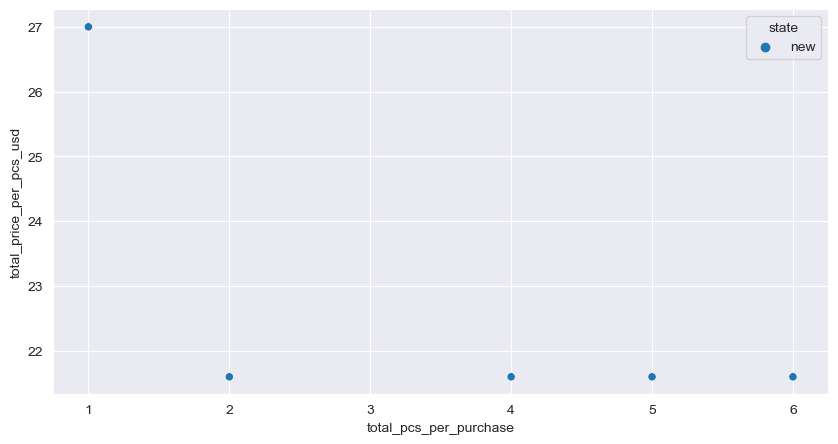

new


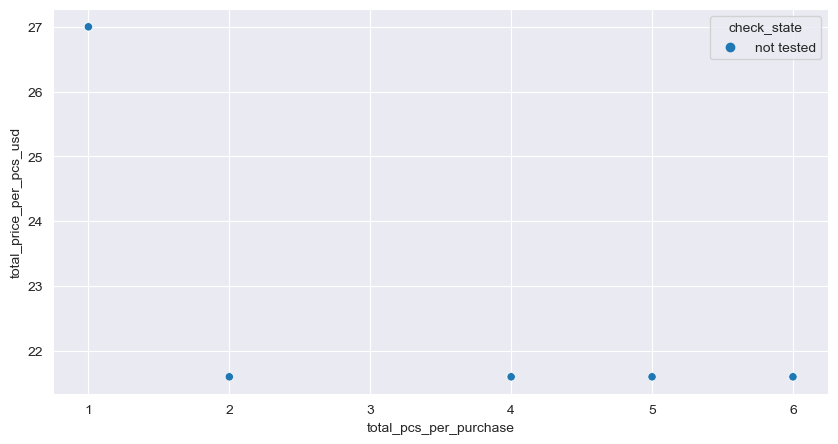

used


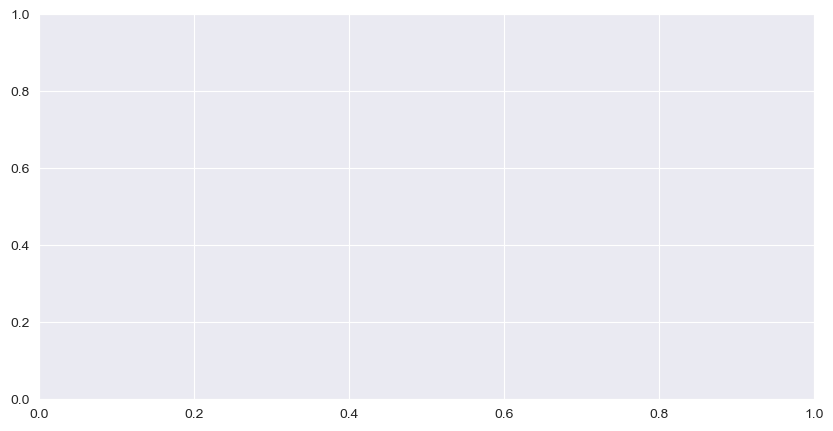


################################################## ИН-16 ##################################################
Продано штук:  467 

Распределение по состоянию (проданных штук): 
dismantledAndTested    146
newAndMatched            6
newAndTested            87
newNotTested            10
usedAndNotTested        60
usedAndTested          158 

Гистограмма цены для всех категорий:


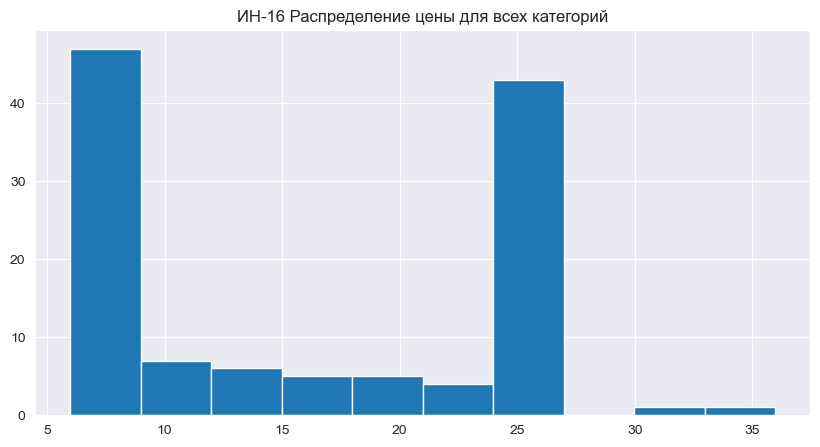

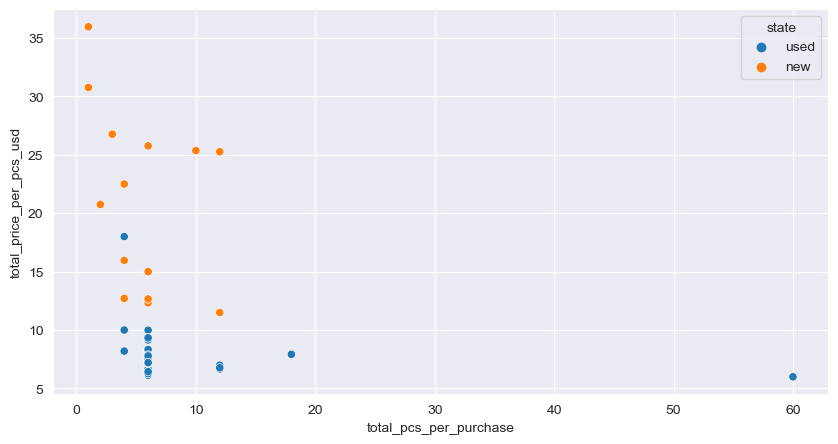

new


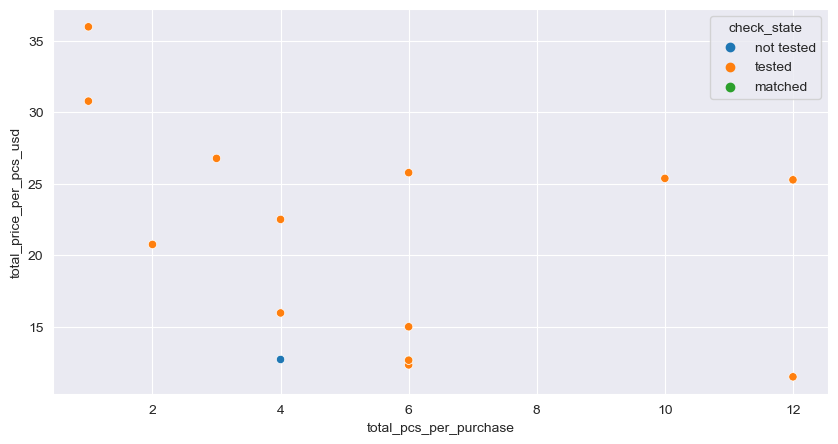

used


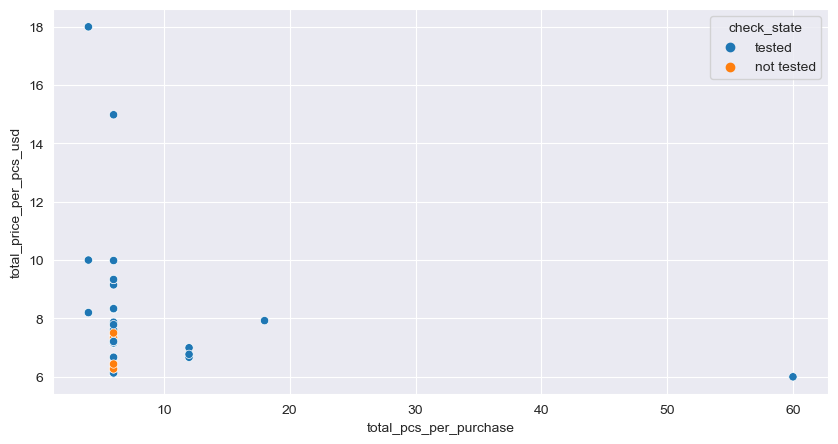


################################################## ИН-2 ##################################################
Продано штук:  499 

Распределение по состоянию (проданных штук): 
newAndTested     104
newNotTested     261
usedAndTested    134 

Гистограмма цены для всех категорий:


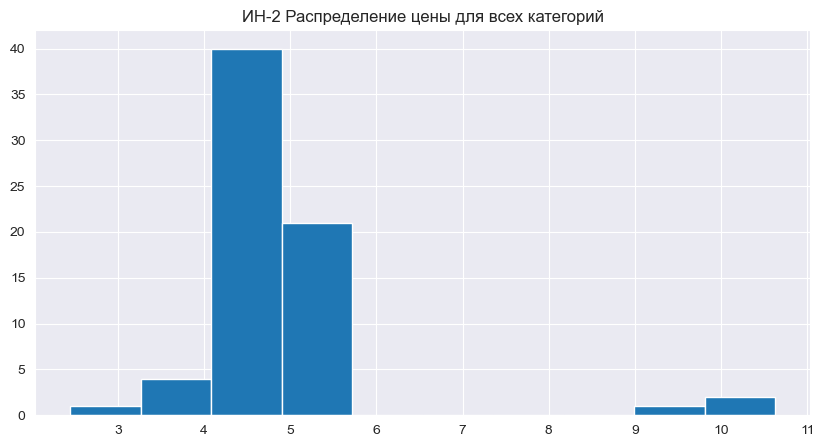

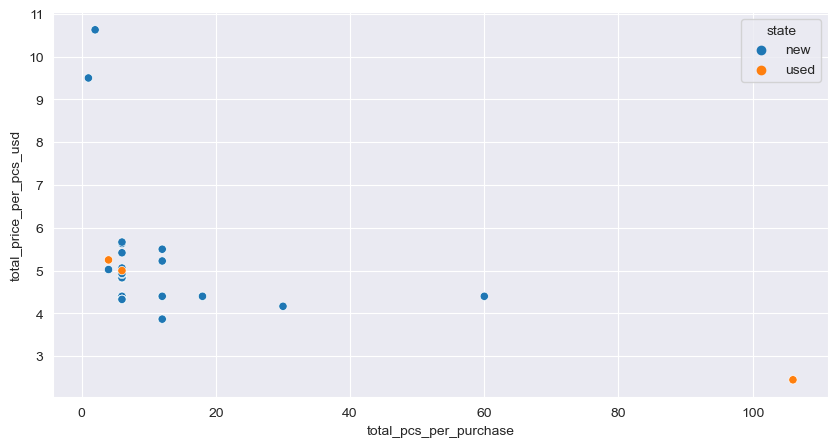

new


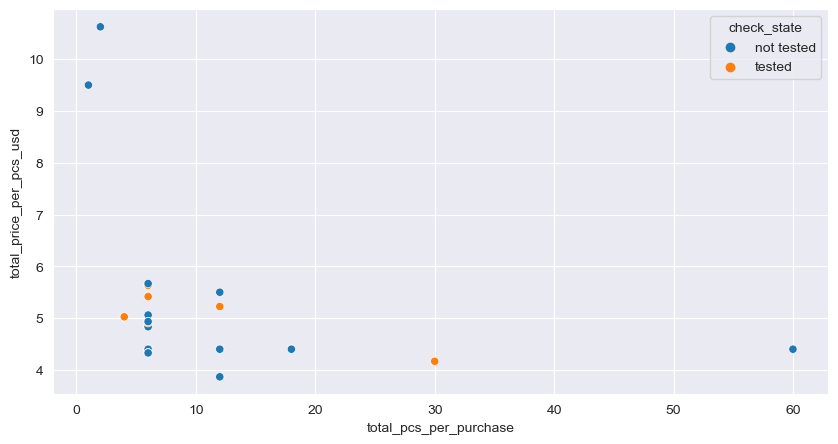

used


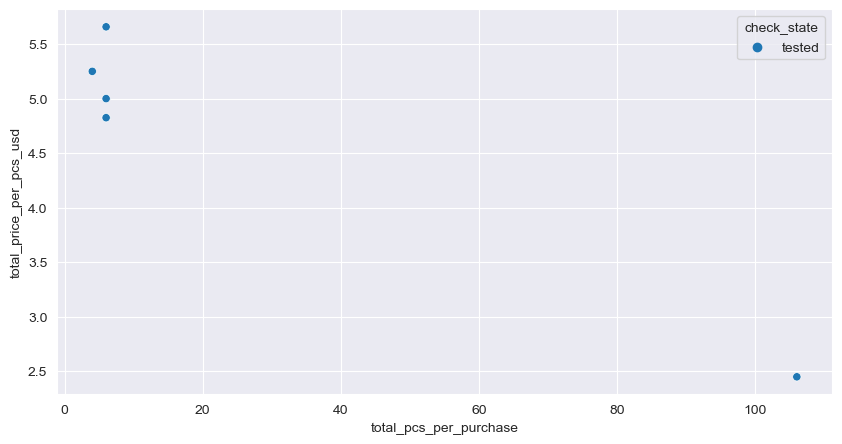


################################################## ИН-4 ##################################################
Продано штук:  18 

Распределение по состоянию (проданных штук): 
newAndTested    18 

Гистограмма цены для всех категорий:


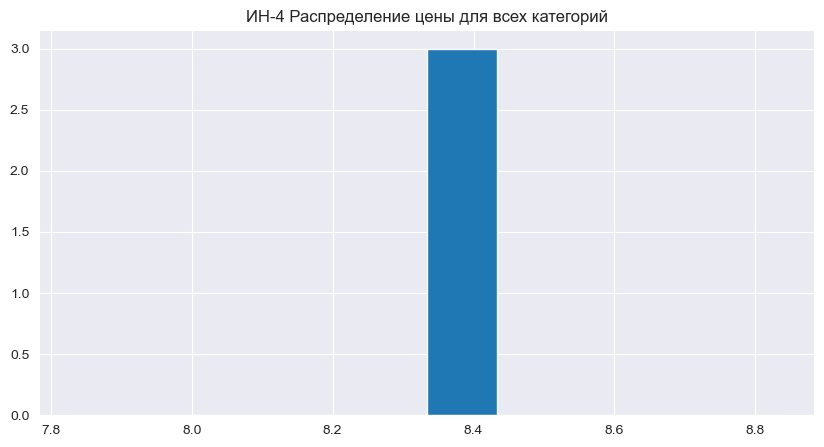

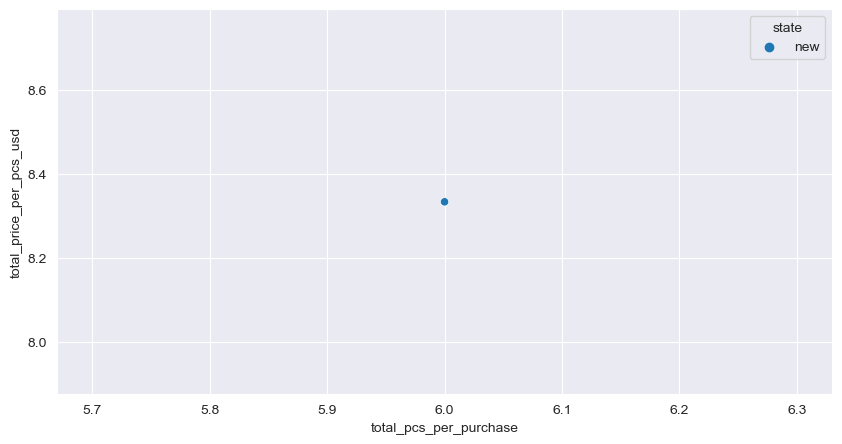

new


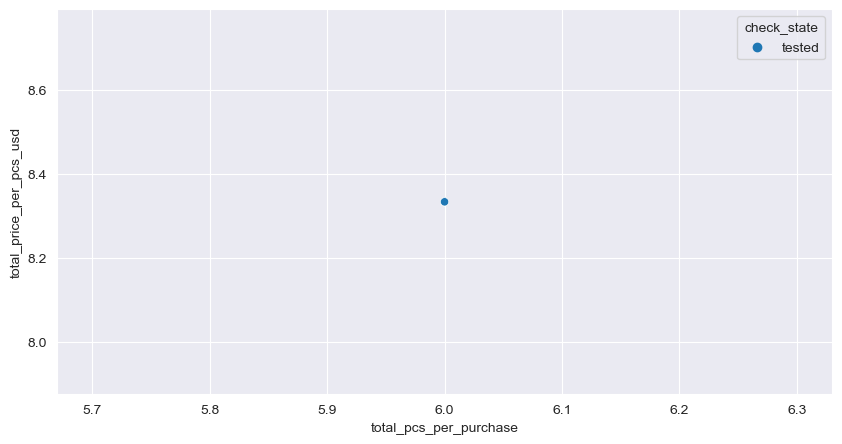

used


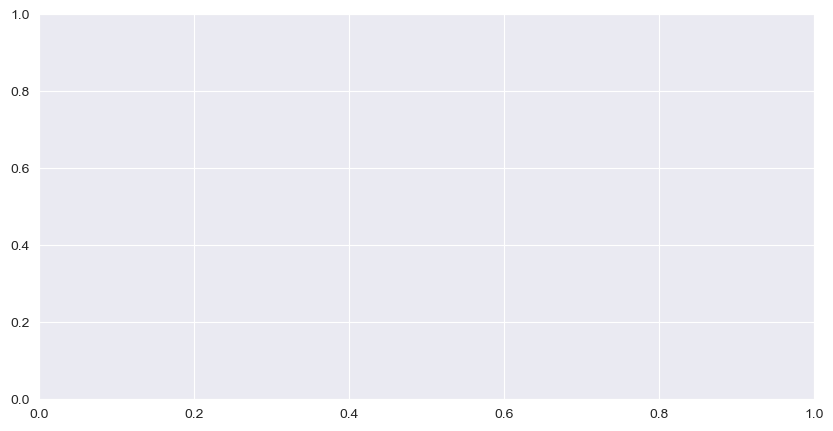


################################################## ИН-7 ##################################################
Продано штук:  18 

Распределение по состоянию (проданных штук): 
newNotTested     10
usedAndTested     8 

Гистограмма цены для всех категорий:


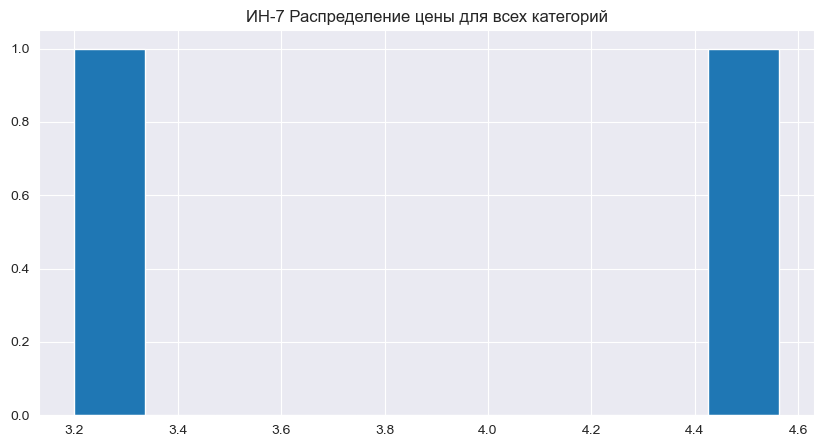

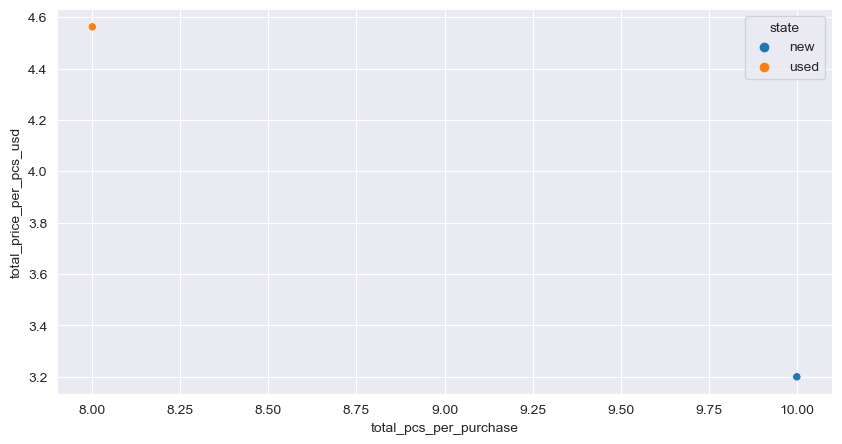

new


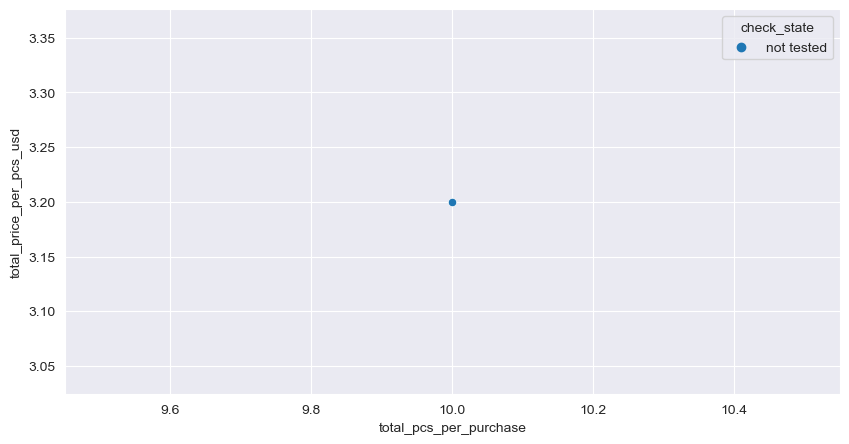

used


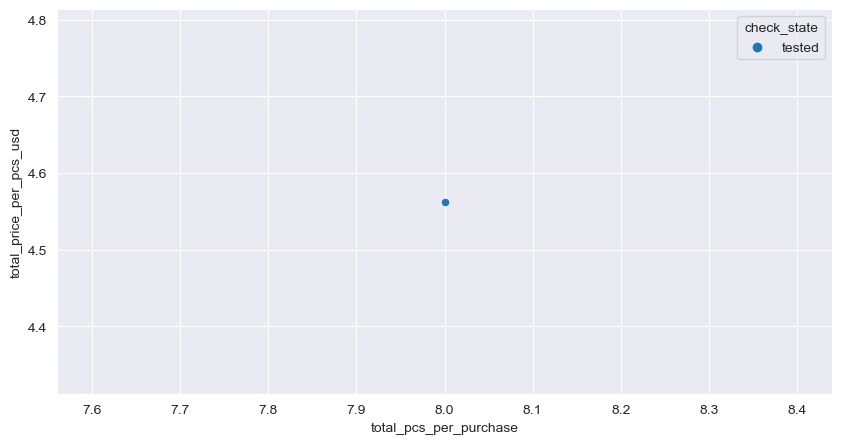


################################################## ИН-7А ##################################################
Нет продаж для лота 

################################################## ИН-7Б ##################################################
Продано штук:  2 

Распределение по состоянию (проданных штук): 
newAndTested    2 

Гистограмма цены для всех категорий:


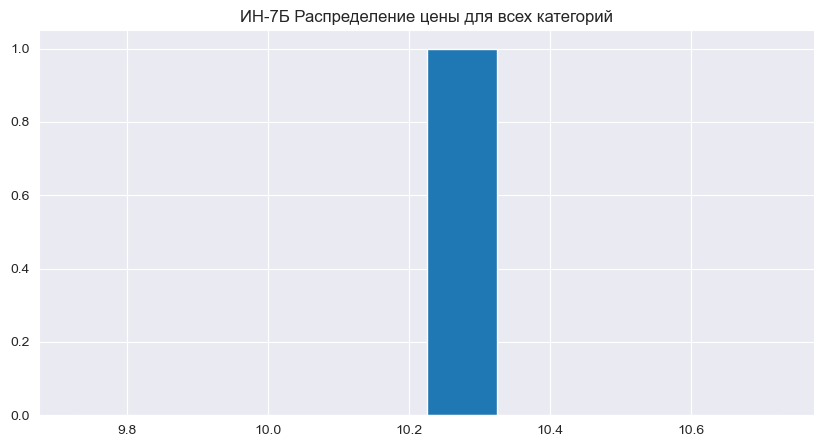

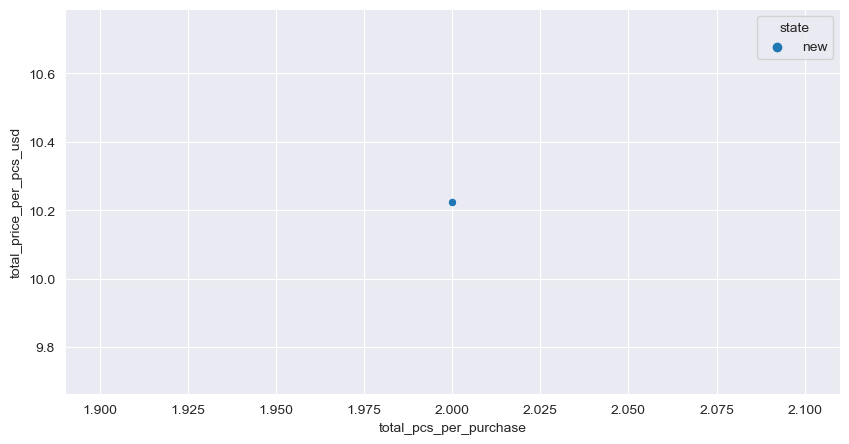

new


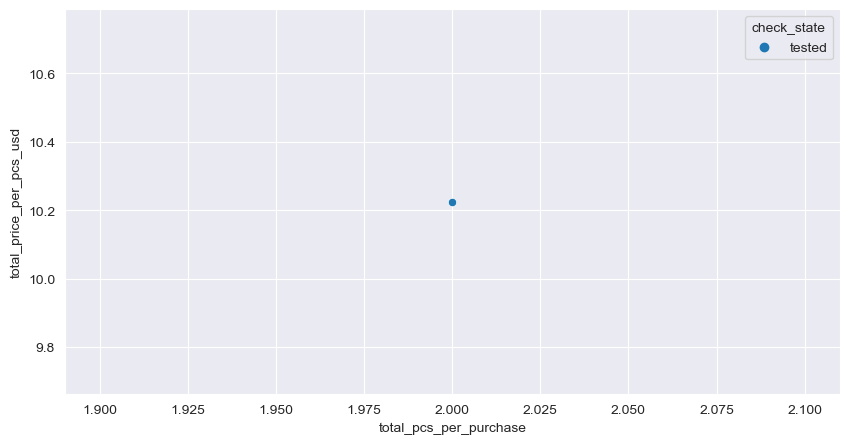

used


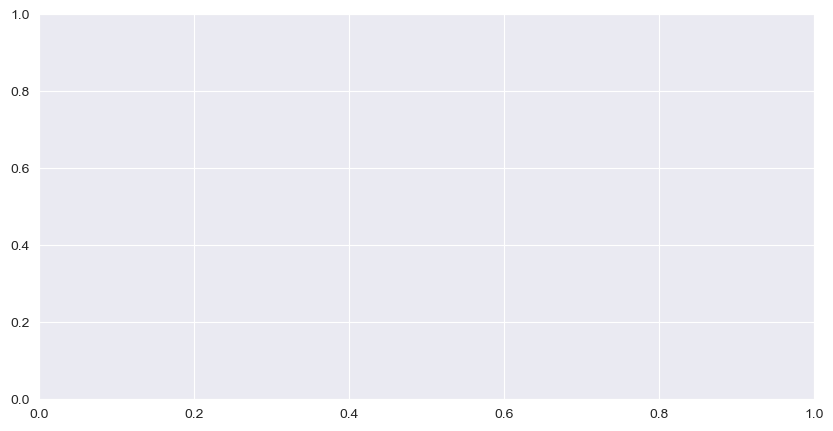


################################################## ИНС-1 ##################################################
Нет продаж для лота 

################################################## ИФП-5000 ##################################################
Нет продаж для лота 

################################################## К15-4 ##################################################
Нет продаж для лота 

################################################## МТХ-90 ##################################################
Продано штук:  4082 

Распределение по состоянию (проданных штук): 
dismantledNotTested       4
newAndTested              3
newNotTested           4075 

Гистограмма цены для всех категорий:


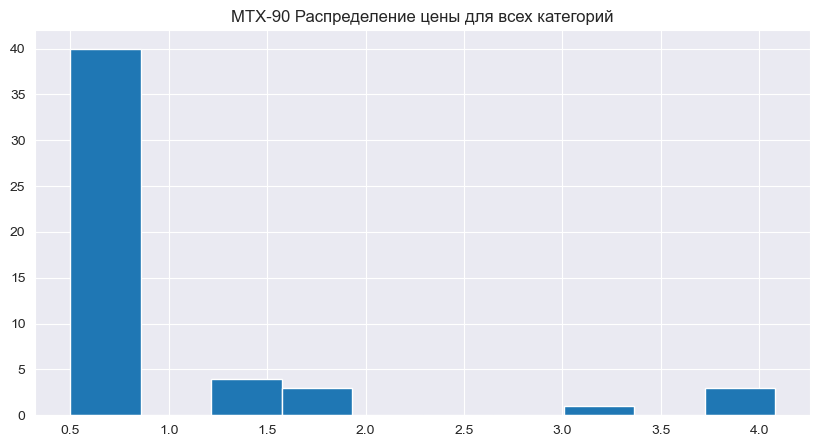

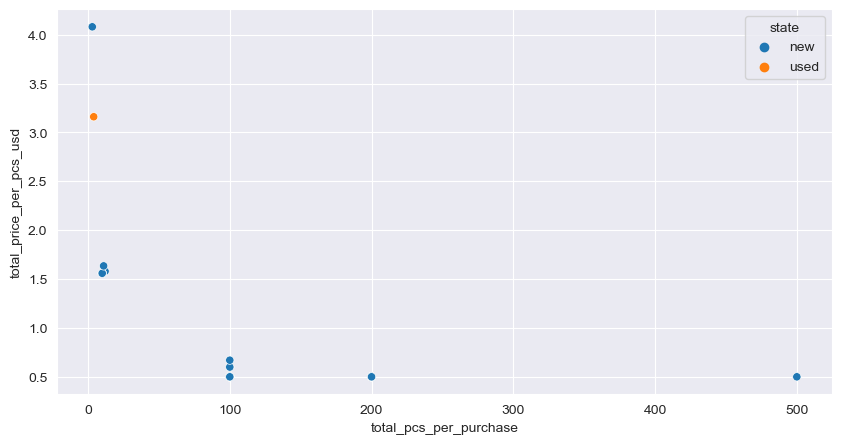

new


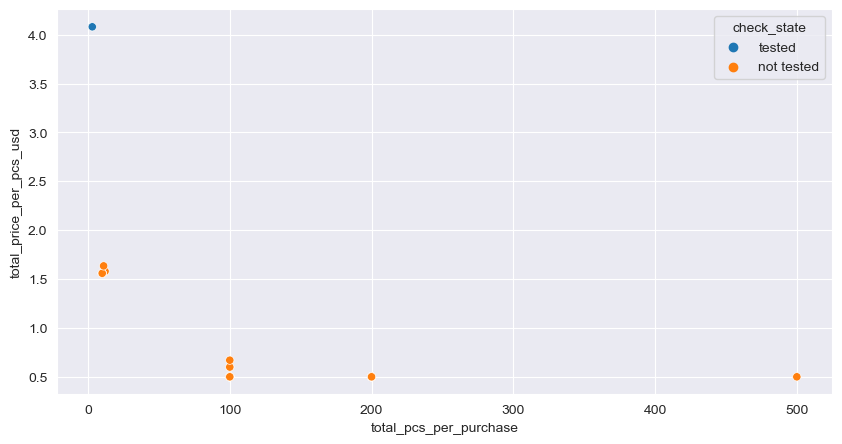

used


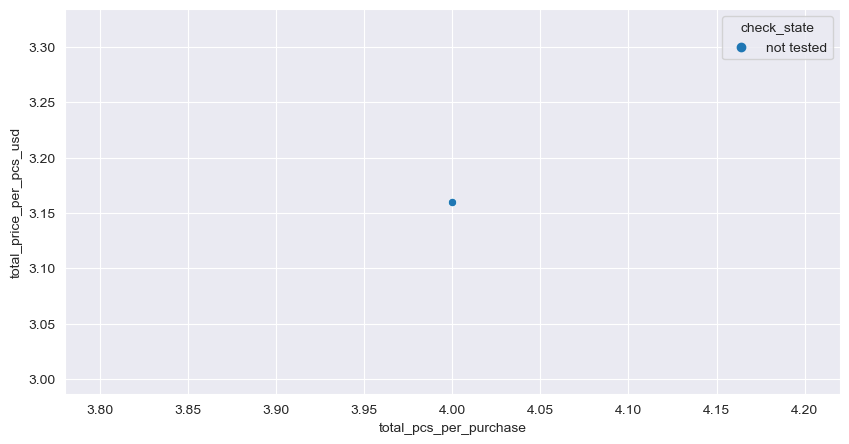


################################################## ОГ-3 металлическое основание ##################################################
Продано штук:  40 

Распределение по состоянию (проданных штук): 
newNotTested    40 

Гистограмма цены для всех категорий:


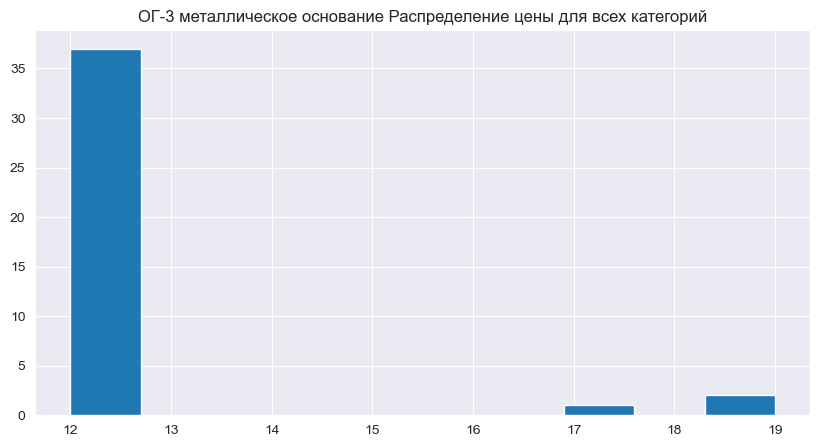

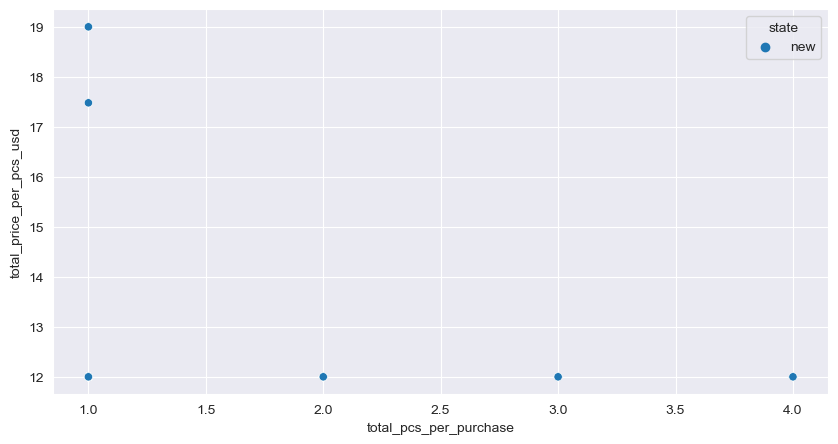

new


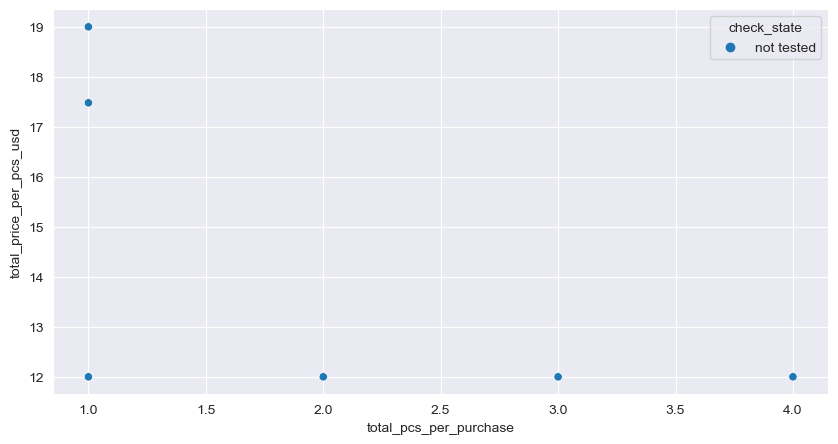

used


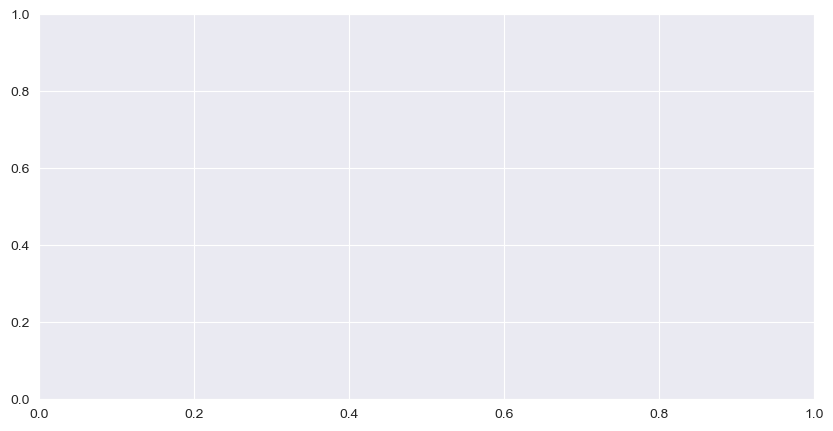


################################################## ОГ-3 пластиковое основание ##################################################
Нет продаж для лота 

################################################## ОГ-8 ##################################################
Продано штук:  8 

Распределение по состоянию (проданных штук): 
newNotTested    8 

Гистограмма цены для всех категорий:


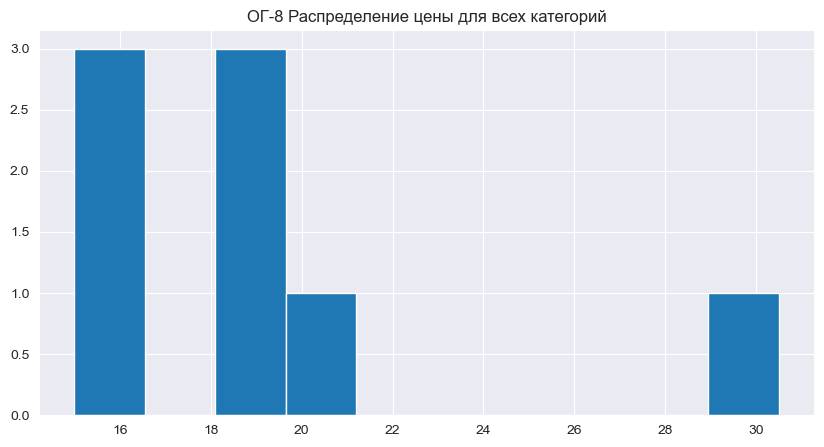

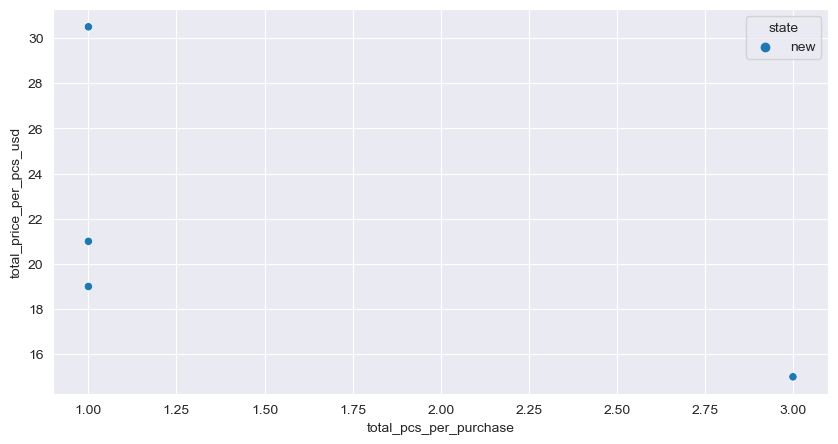

new


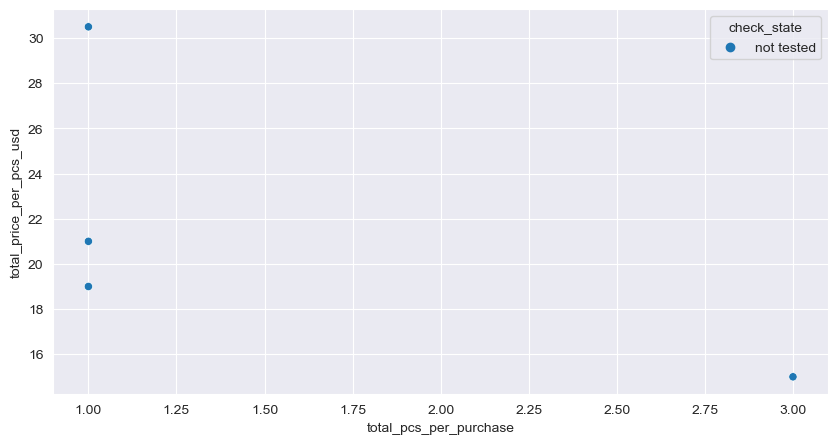

used


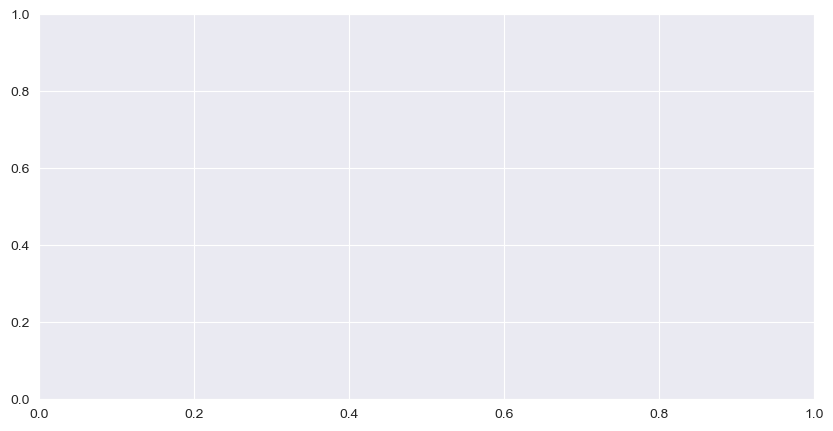


################################################## Р-18 ##################################################
Нет продаж для лота 

################################################## Р-350 ##################################################
Продано штук:  5 

Распределение по состоянию (проданных штук): 
newNotTested    5 

Гистограмма цены для всех категорий:


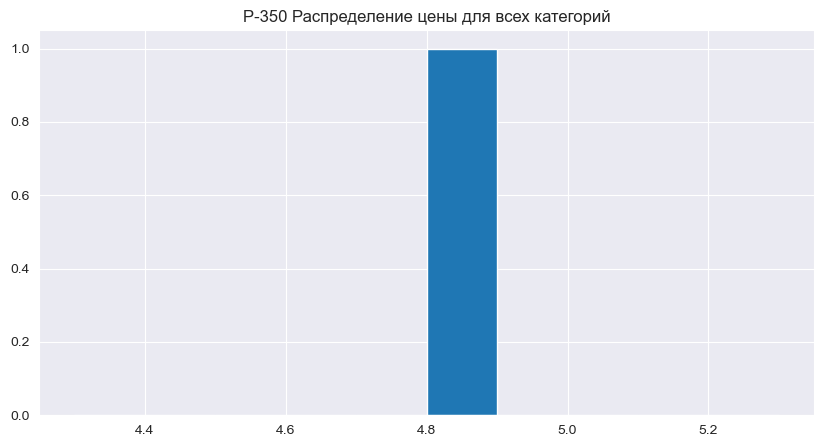

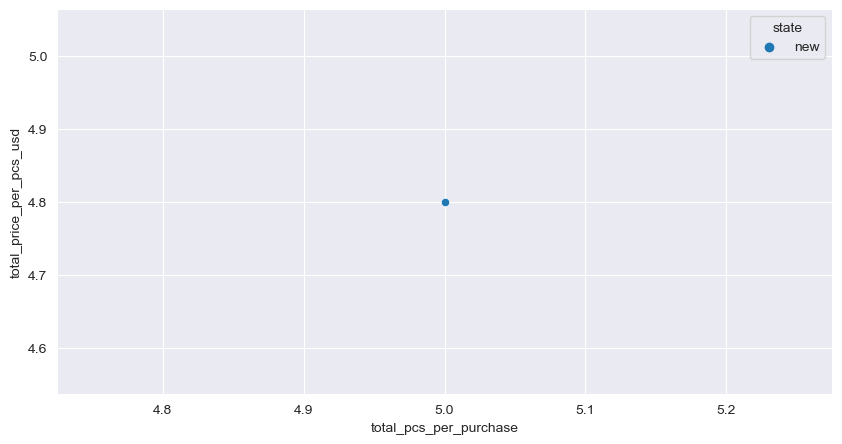

new


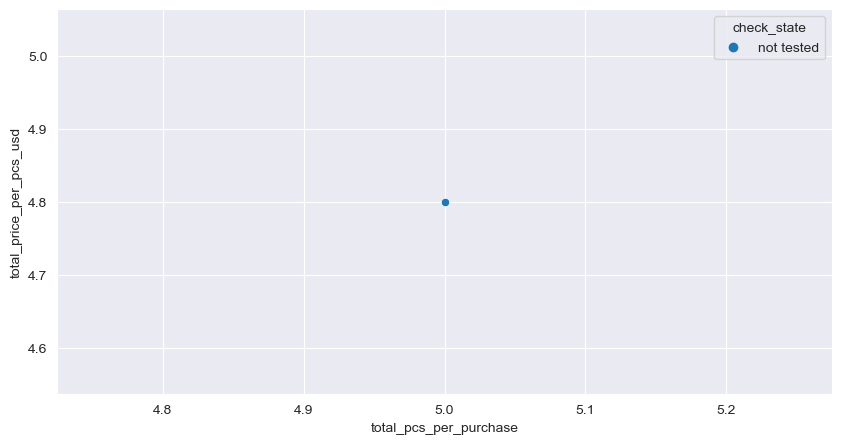

used


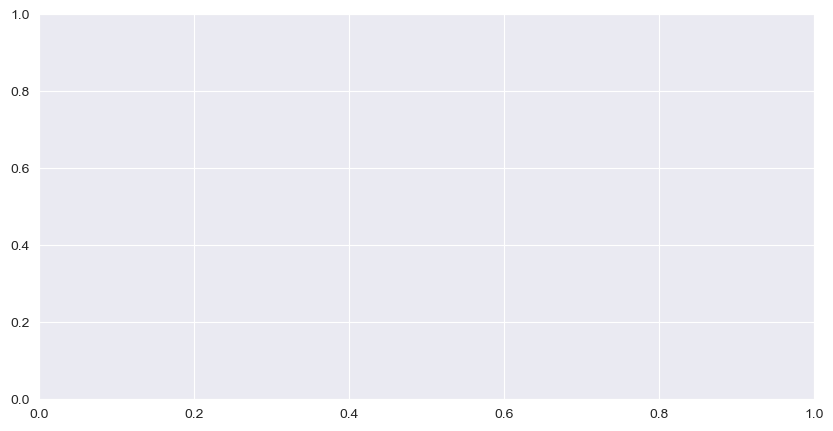


################################################## РБ-5 ##################################################
Продано штук:  25 

Распределение по состоянию (проданных штук): 
newNotTested    25 

Гистограмма цены для всех категорий:


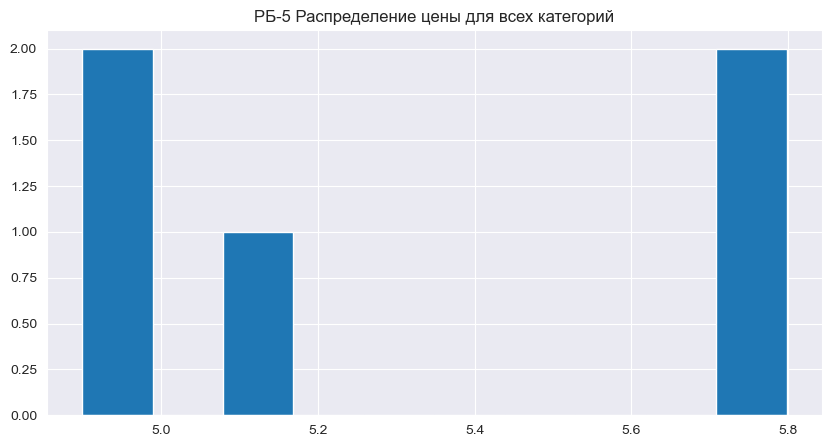

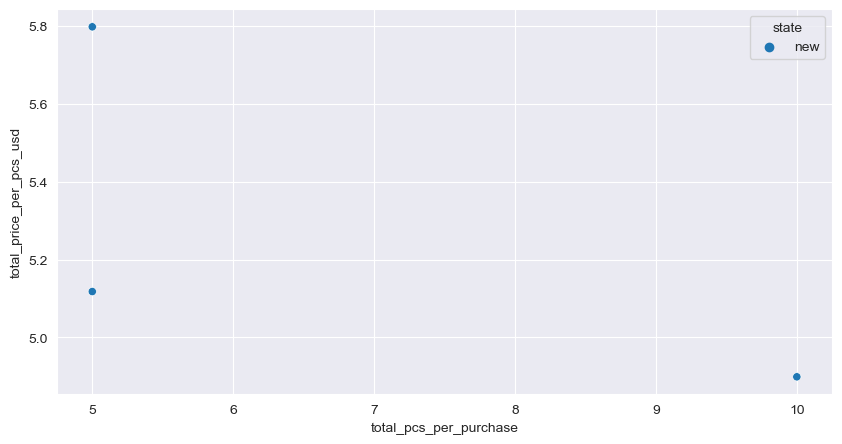

new


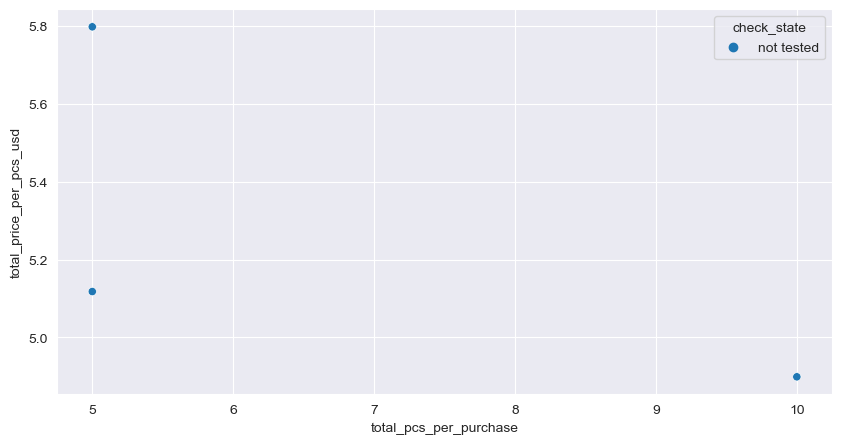

used


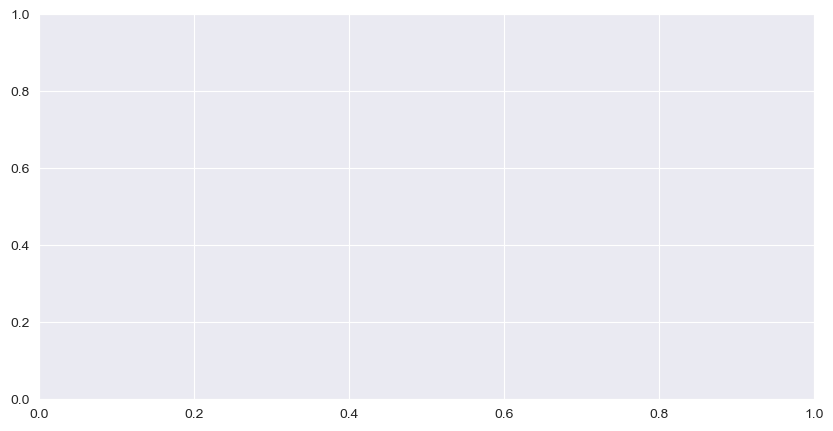


################################################## СГ15П ##################################################
Нет продаж для лота 

################################################## СГ15П-2 ##################################################
Продано штук:  6 

Распределение по состоянию (проданных штук): 
newAndTested    6 

Гистограмма цены для всех категорий:


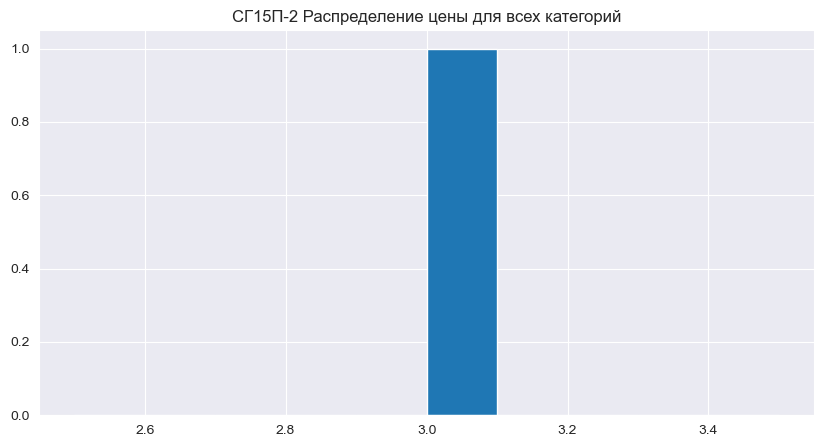

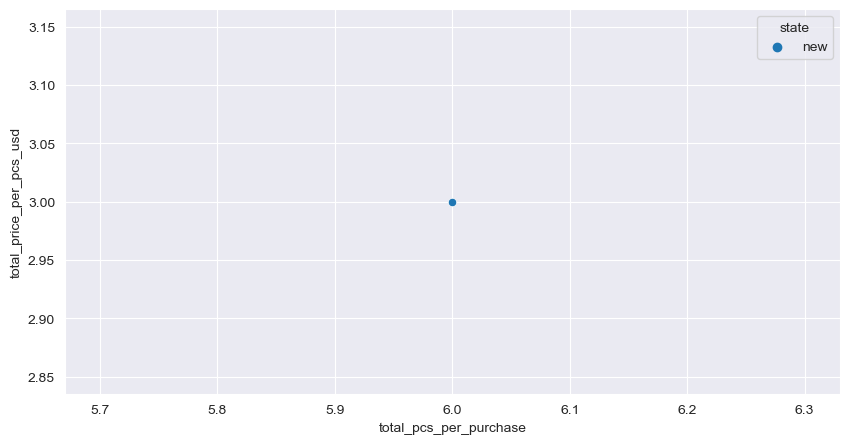

new


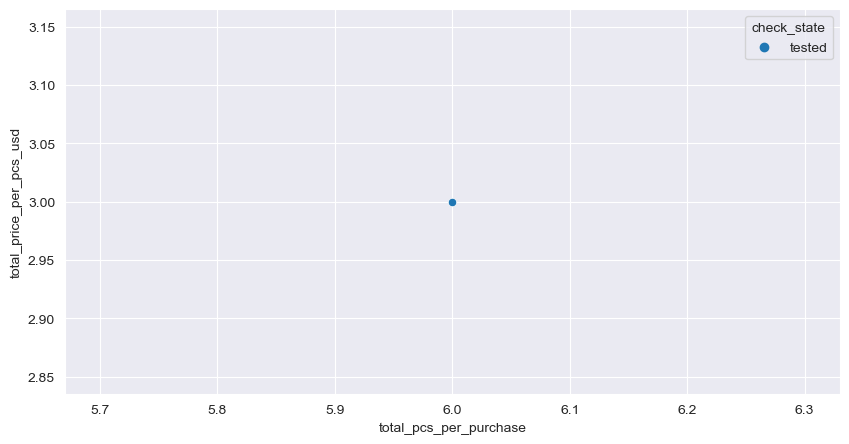

used


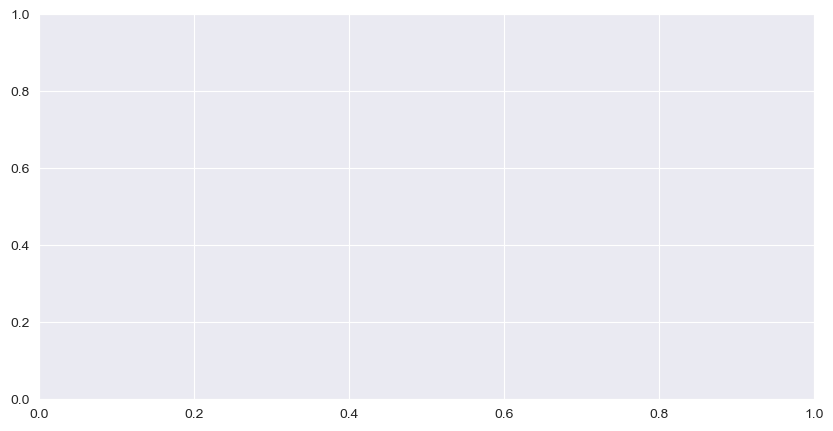


################################################## СГ16П ##################################################
Продано штук:  70 

Распределение по состоянию (проданных штук): 
newNotTested    70 

Гистограмма цены для всех категорий:


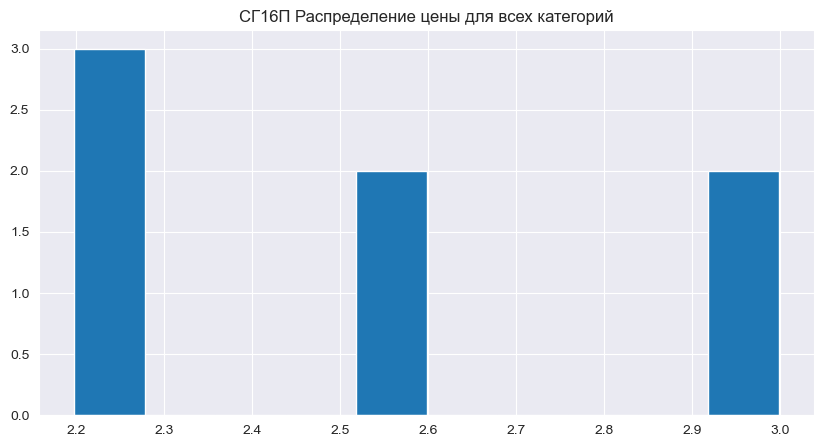

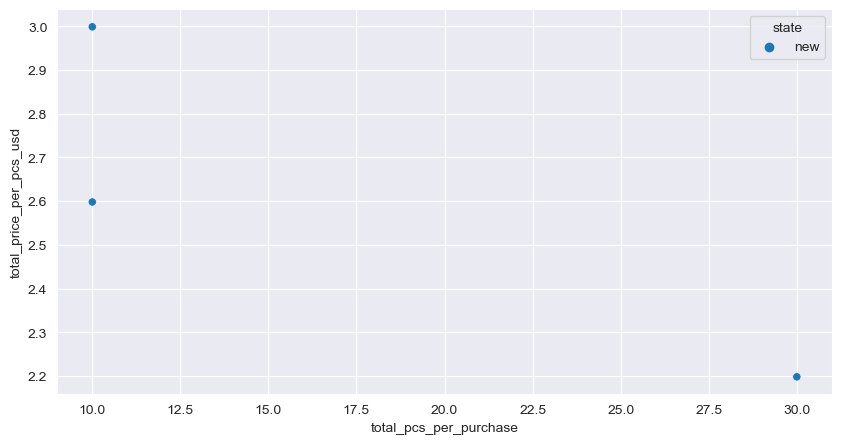

new


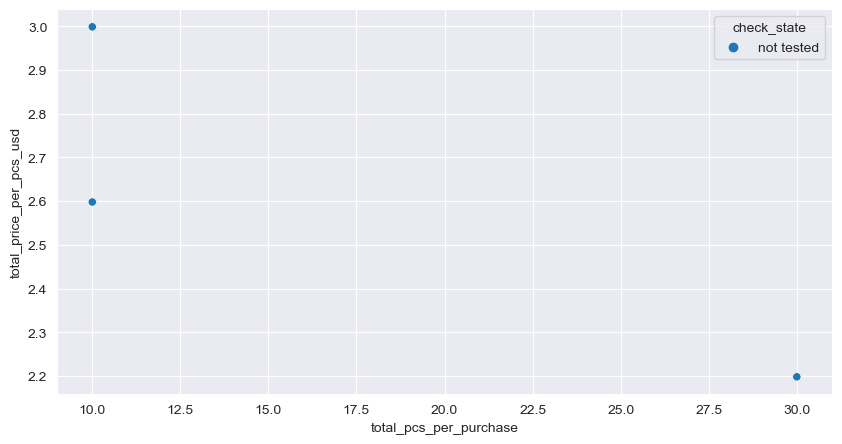

used


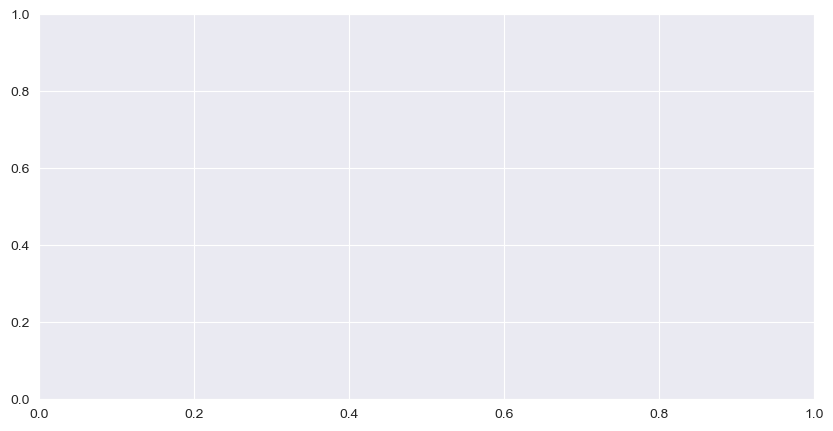


################################################## СГ1П-ЕВ ##################################################
Продано штук:  248 

Распределение по состоянию (проданных штук): 
newNotTested    248 

Гистограмма цены для всех категорий:


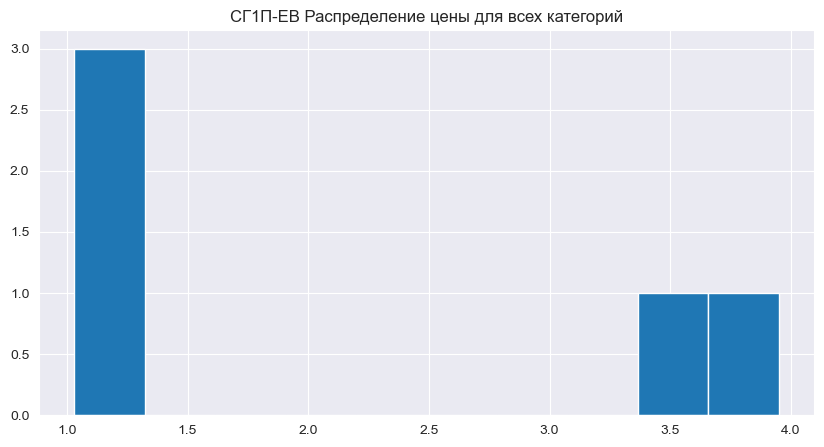

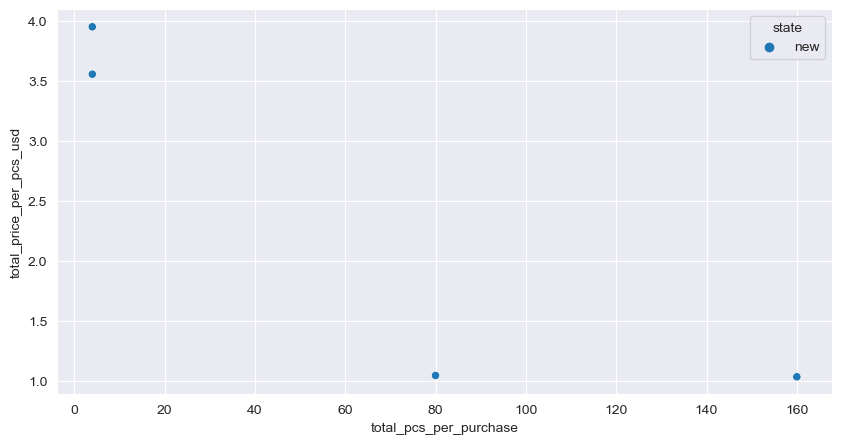

new


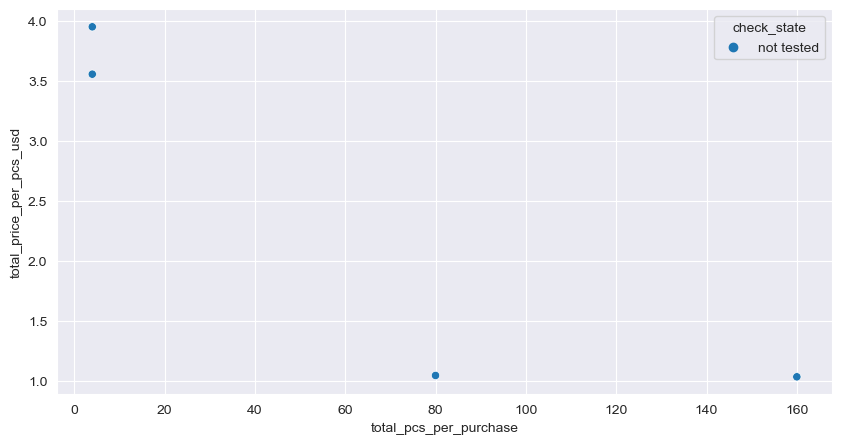

used


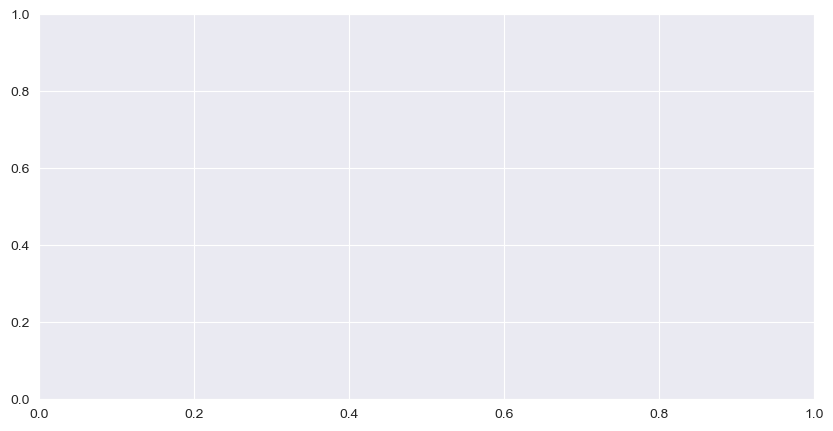


################################################## СГ2П ##################################################
Продано штук:  60 

Распределение по состоянию (проданных штук): 
newAndTested     6
newNotTested    54 

Гистограмма цены для всех категорий:


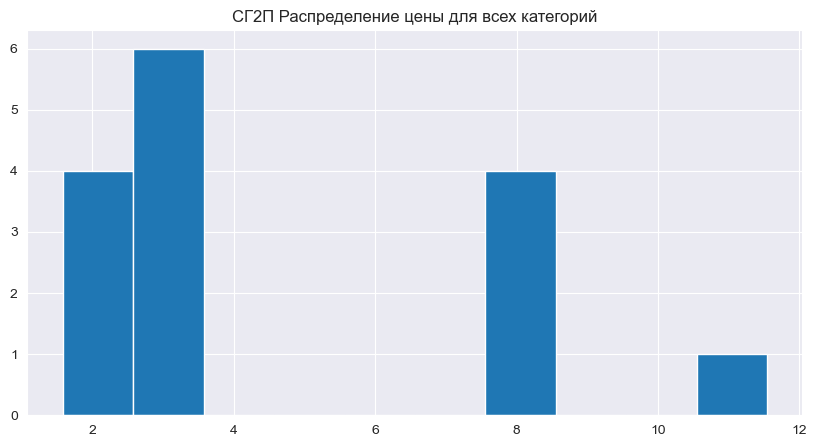

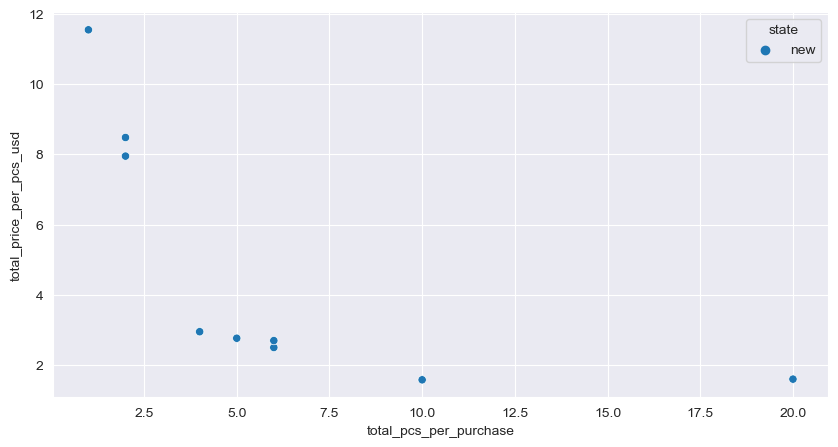

new


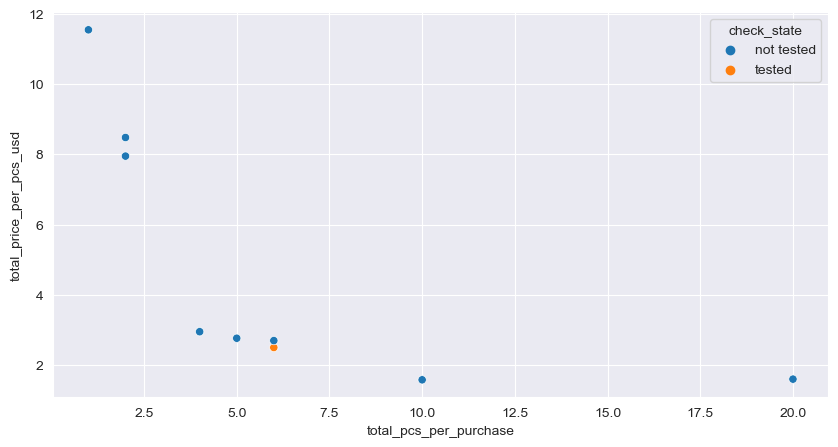

used


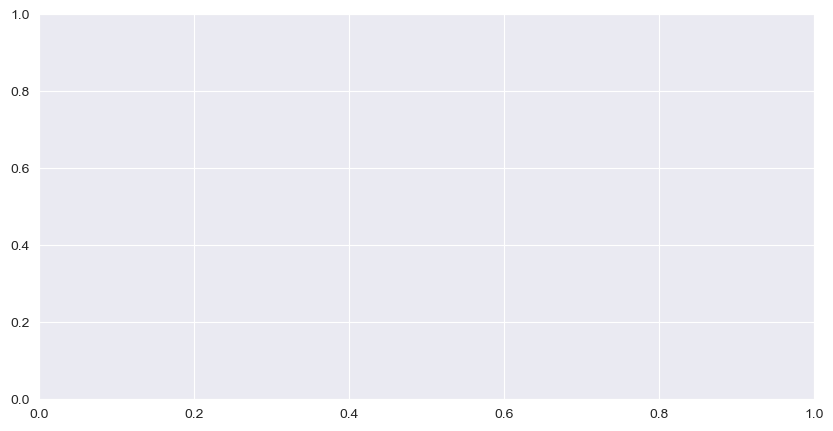


################################################## СГ303С ##################################################
Нет продаж для лота 

################################################## СГ4С ##################################################
Продано штук:  29 

Распределение по состоянию (проданных штук): 
newAndTested     5
newNotTested    24 

Гистограмма цены для всех категорий:


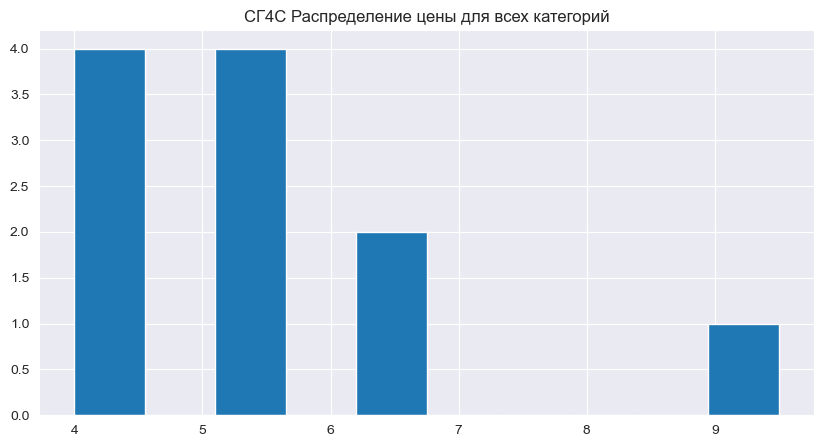

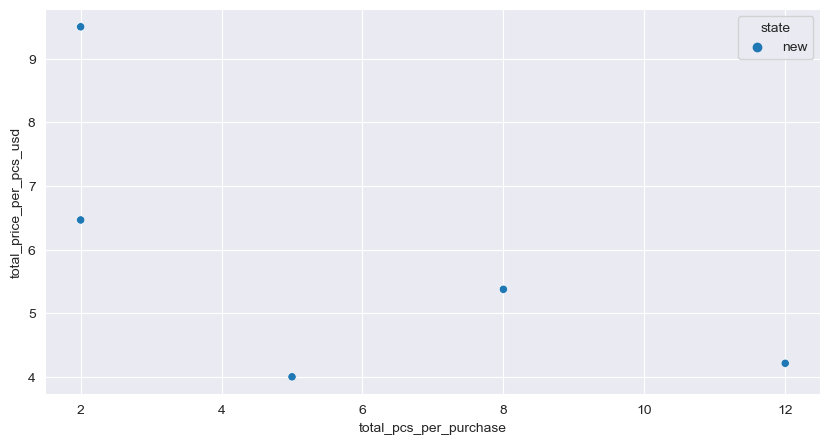

new


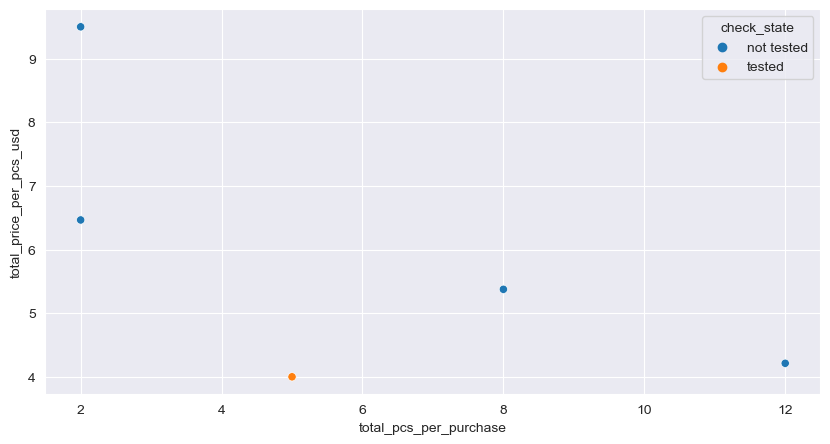

used


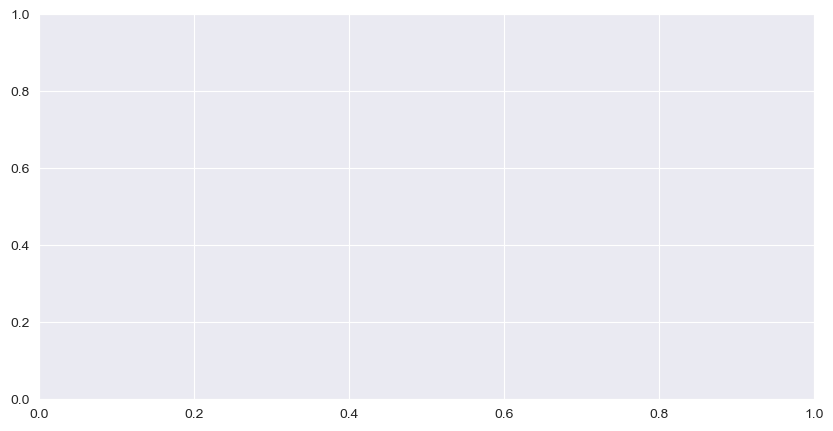


################################################## СИ-21БГ ##################################################
Продано штук:  6 

Распределение по состоянию (проданных штук): 
newNotTested    6 

Гистограмма цены для всех категорий:


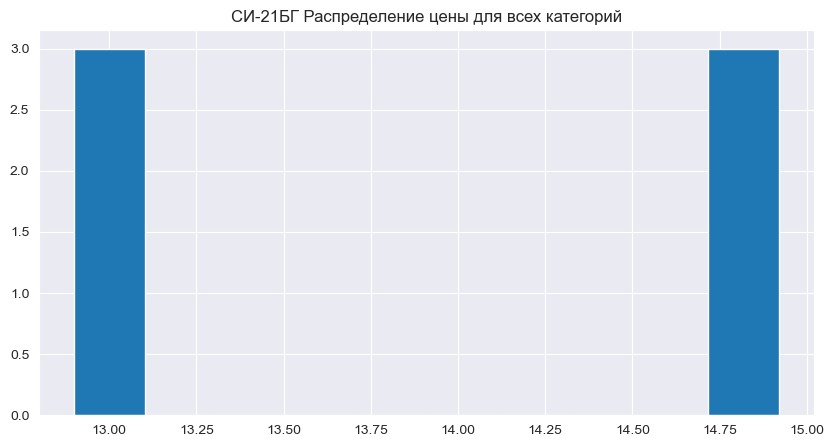

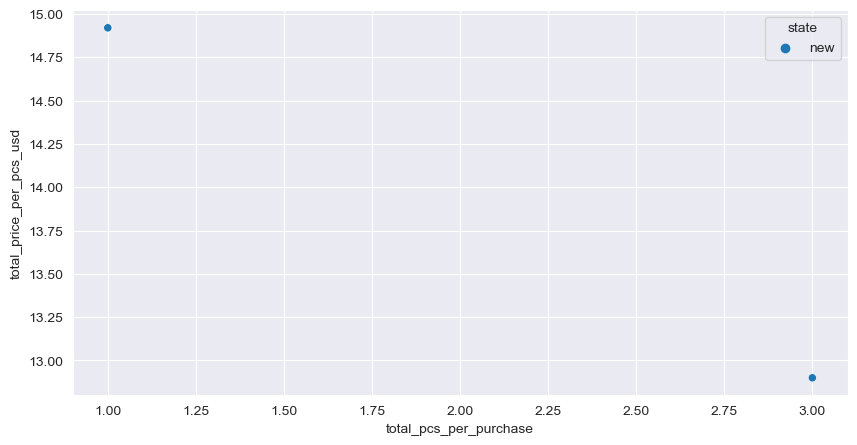

new


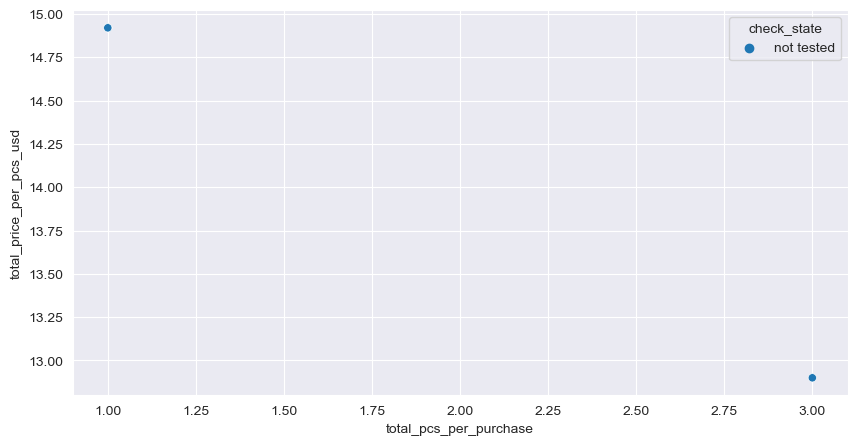

used


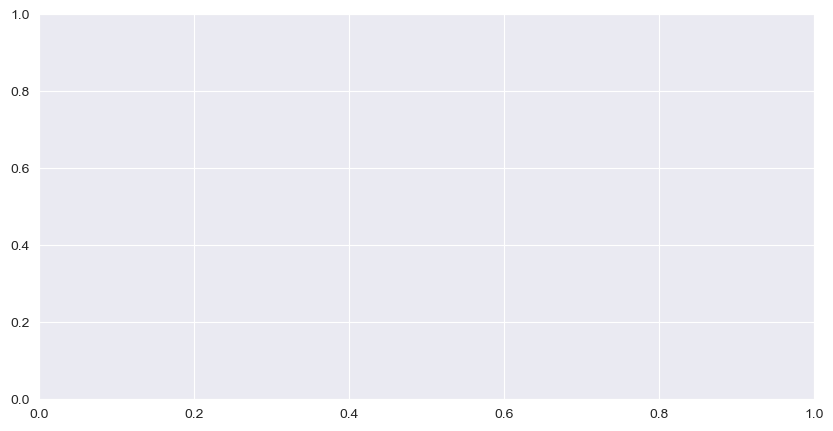


################################################## СМ28-2,8 ##################################################
Нет продаж для лота 

################################################## СМ36 ##################################################
Нет продаж для лота 

################################################## СМ 3V 0,6W ##################################################
Нет продаж для лота 

################################################## ТВБ-4 ##################################################
Нет продаж для лота 

################################################## ТВБ-6 ##################################################
Нет продаж для лота 

################################################## ТГ1-Б ##################################################
Нет продаж для лота 

################################################## ТГ3-0,1/1,3 ##################################################
Продано штук:  4 

Распределение по состоянию (проданных штук): 
newNotTested    4 

Гистограмма ц

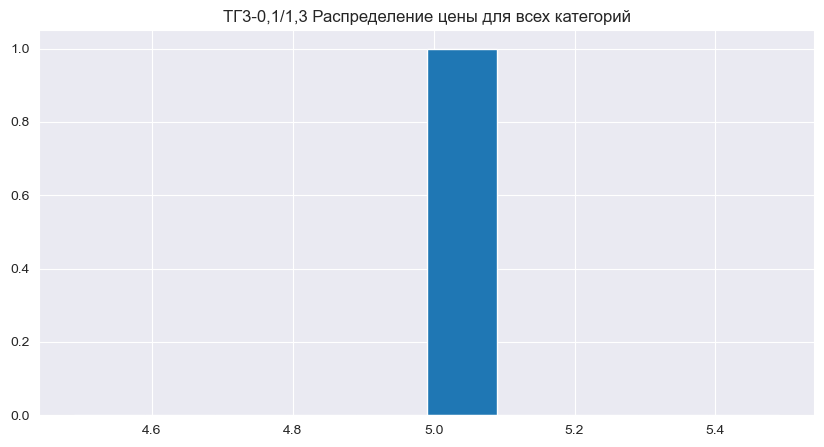

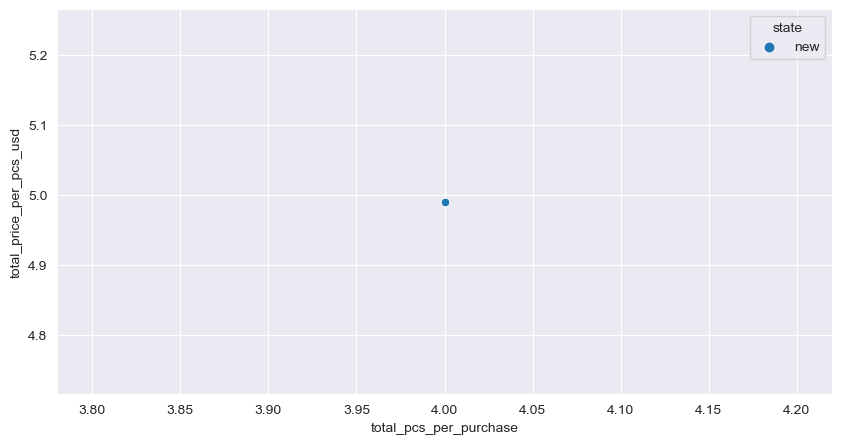

new


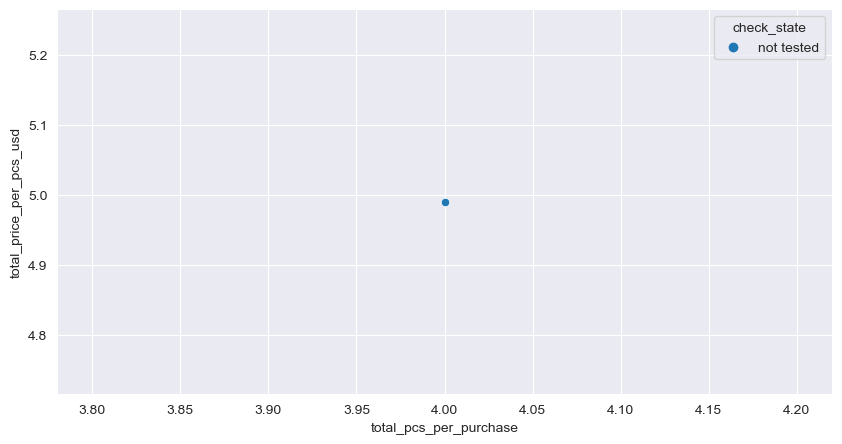

used


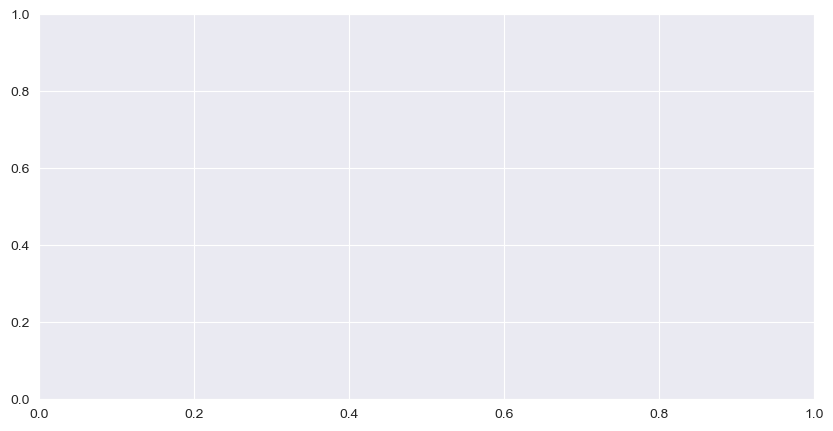


################################################## ТГИ1-3/1 ##################################################
Нет продаж для лота 

################################################## ТХ2 ##################################################
Нет продаж для лота 

################################################## ТХ3Б ##################################################
Нет продаж для лота 

################################################## ТХ5Б ##################################################
Продано штук:  0 

Распределение по состоянию (проданных штук): 
Series([], ) 

Гистограмма цены для всех категорий:


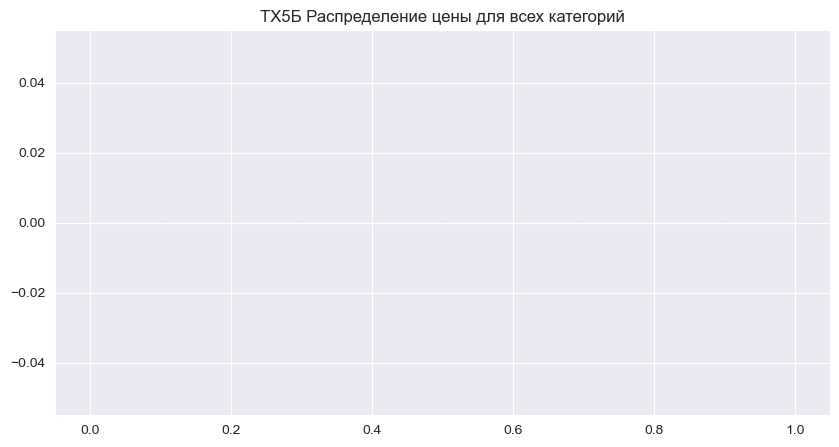

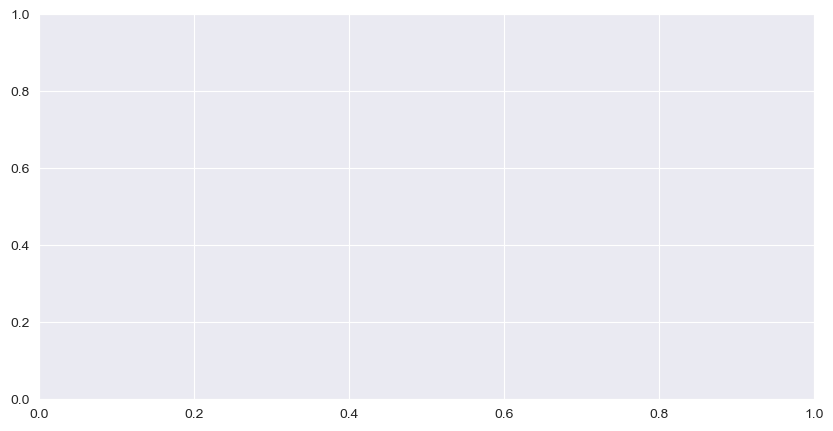

new


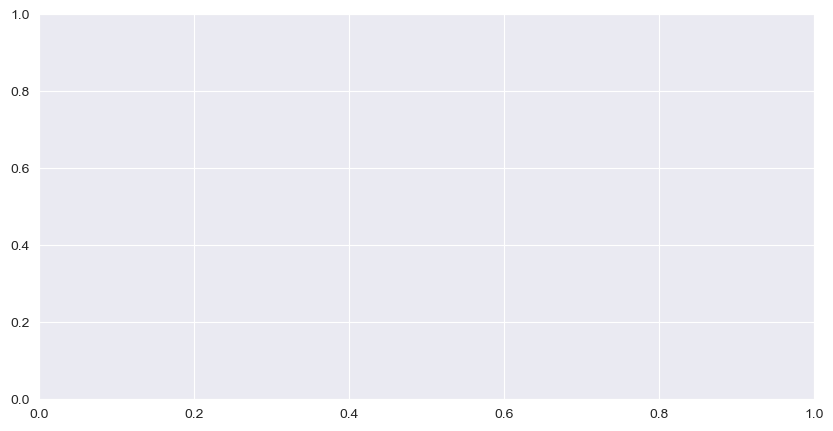

used


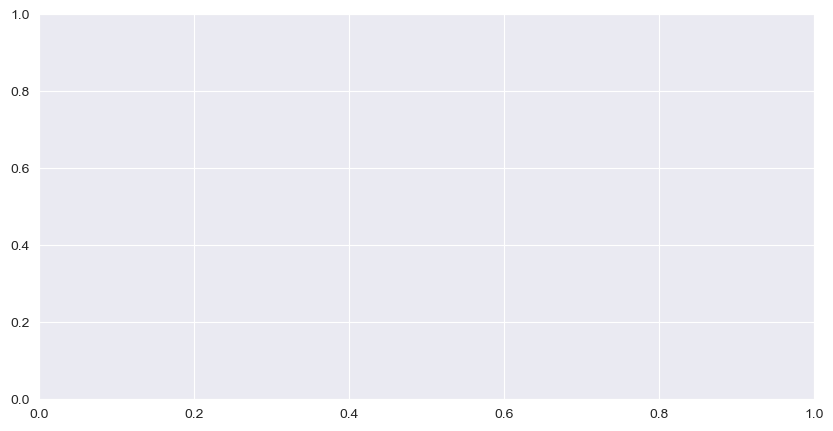


################################################## ФРМ-1В ##################################################
Нет продаж для лота 

################################################## ФЭУ-60 ##################################################
Продано штук:  3 

Распределение по состоянию (проданных штук): 
newNotTested    3 

Гистограмма цены для всех категорий:


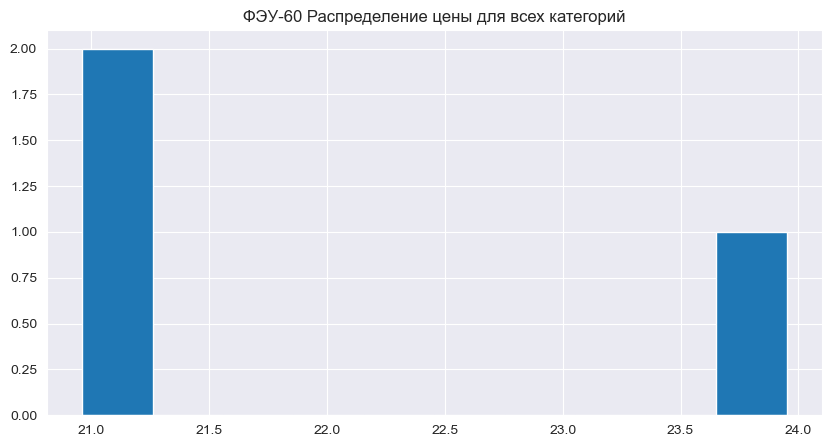

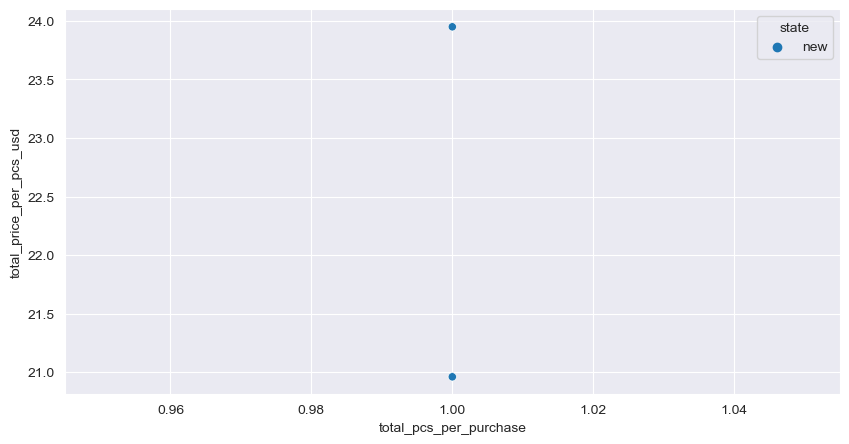

new


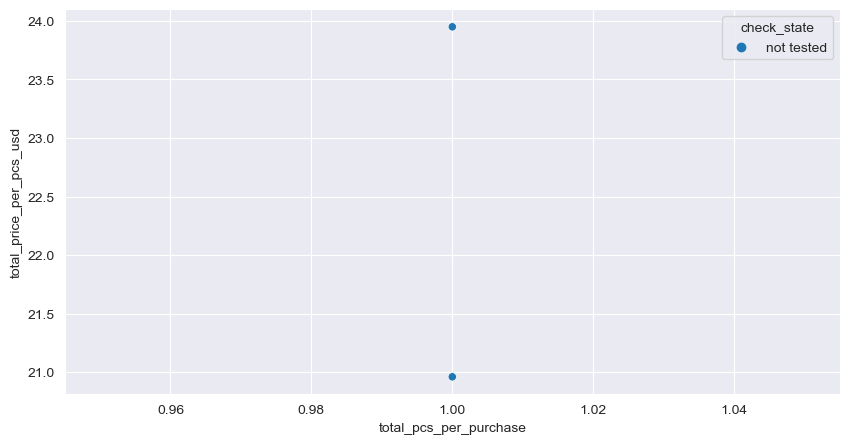

used


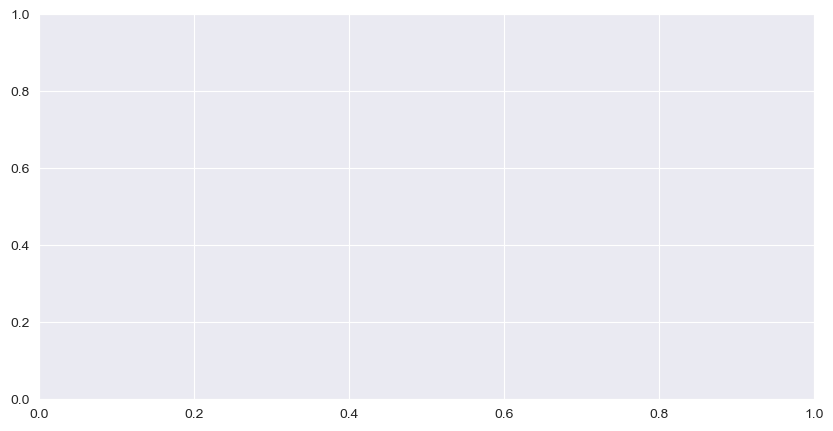


################################################## ЭМ-7 ##################################################
Нет продаж для лота 


In [9]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams["figure.figsize"] = (10,5)

def get_access_token(url, client_id, client_secret):
    response = requests.post(
        url,
        data={"grant_type": "client_credentials"},
        auth=(client_id, client_secret),
    )
    return response.json()["access_token"]

token = get_access_token(f"https://{server}:{port}/connect/token", clientId, secret)

client = ApiClient(
    configuration=Configuration(host=f'https://{server}:{port}/api/ebay/v1'), header_name='Authorization',
    header_value='Bearer ' + token)

api = DefaultApi(client)

currencies = api.get_currencies()
currency_rates = {}
for currency in currencies:
    if (datetime.now() - datetime.strptime(currencies[0].last_update, '%Y-%m-%dT%H:%M:%S.%fZ')).days > 1:
        raise Exception("exchange rate isn't accurate " + currency.ebay_name)
    currency_rates[currency.ebay_name] = currency.rate

productRowsExcluded = {'search_queries'}
lotRowsExcluded = {'seller', 'located_in', 'purchase_history'}
purchaseExcluded = {}

products: List[ProductWithId] = api.get_all_products()


for product in products:
    #if product.name != '6П14П': continue
    
    print(colored('#' * 50 + f' {product.name} ' + '#' * 50, "red"))
    
    lots: List[LotInfoShort] = api.get_lots(product_id=product.id)

    productRow = {}
    for key, value in product.__dict__.items():
        if key not in productRowsExcluded:
            productRow[f'product_{key}'] = value

    dataFrameArray = []
    for lot in lots:
        lotRow = productRow.copy()
        for key, value in lot.__dict__.items():
            if key not in lotRowsExcluded:
                lotRow[f'lot_{key}'] = value

        for purchase in lot.purchase_history:
            purchaseRow = lotRow.copy()
            for key, value in purchase.__dict__.items():
                if key not in purchaseExcluded:
                    purchaseRow[f'purchase_{key}'] = value
            dataFrameArray.append(purchaseRow)
    
    if len(dataFrameArray) == 0:
        print("Нет продаж для лота", '\n')
        continue
    
    df = pd.DataFrame(dataFrameArray)

    df.lot_title_change_date = pd.to_datetime(df.lot_title_change_date)
    df.purchase_var_date = pd.to_datetime(df.purchase_var_date)
    df = df[df.purchase_var_date > df.lot_title_change_date]
    df['purchase_price_filled_nulls'] = df.purchase_price.fillna(df.lot_price * unknown_price_discount)
    df['exchange_rate'] = df.lot_currency.map(currency_rates)
    
    df['purchase_total_price'] = df.purchase_price_filled_nulls * df.purchase_quantity + df.lot_shipping + (df.lot_shipping_additional * (df.purchase_quantity - 1))
    df['purchase_total_price_usd'] = df.purchase_total_price / df.exchange_rate
    df['total_price_per_pcs_usd'] = df.purchase_total_price_usd / (df.lot_pcs * df.purchase_quantity)
    df['total_pcs_per_purchase'] = df.lot_pcs * df.purchase_quantity
    df['state'] = df.lot_manual_condition_id.map(extract_state)
    df['check_state'] = df.lot_manual_condition_id.map(extract_check_state)

    
    print ('Продано штук: ', (df.purchase_quantity * df.lot_pcs).sum(), '\n')
    
    print('Распределение по состоянию (проданных штук): ')
    print(df.groupby('lot_manual_condition_id')['total_pcs_per_purchase'].sum().to_string(header=False), "\n")
    
    print("Гистограмма цены для всех категорий:")
    df.hist('total_price_per_pcs_usd', weights=df.purchase_quantity)
    plt.title(product.name + ' Распределение цены для всех категорий')
    plt.show()
    
    sns.scatterplot(data=df, x="total_pcs_per_purchase", y="total_price_per_pcs_usd", hue="state")
    plt.show()
    print('new')
    sns.scatterplot(data=df[df.state == 'new'], x="total_pcs_per_purchase", y="total_price_per_pcs_usd", hue="check_state")
    plt.show()
    print('used')
    sns.scatterplot(data=df[df.state == 'used'], x="total_pcs_per_purchase", y="total_price_per_pcs_usd", hue="check_state")
    plt.show()
    #печать таблицы с продажами
    #display(df)
    
    print()
